# 31 — Model Report Generation

**Origin:** Consolidates Existing Notebooks 13, 19, 26, 29 and 30  
**Refactor status:** Finished          
**Validation status:** Finished                      
**Completion gate passed:** Yes                       
**Output root:** `outputs/31_model_report_generation/`  
**Depends on:** Notebooks 09–30, including Notebook 12A

## Purpose

Generate one parameterized, self-contained HTML report for each evaluated restoration method without running restoration inference or creating new scientific evidence.

The five reports cover:

- OpenCV Telea;
- LaMa;
- HINT;
- Stable Diffusion 1.5 Inpainting;
- bounded SDXL Inpainting.

Each report consolidates validated upstream evidence about:

- method identity, implementation and intended use;
- eligible dataset and experiment scopes;
- classical, perceptual, feature, texture, colour, seam, semantic and structural evidence;
- damage-size, mask-robustness and synthetic-degradation results where applicable;
- repeated-seed variability and prompt sensitivity where applicable;
- representative successes, failures and specialist-review cases;
- difference, uncertainty, semantic and explanation maps;
- failure categories and rule-derived trustworthiness flags;
- observed runtime, storage and memory;
- transparent scalability projections;
- practical strengths, weaknesses, limitations and human-review needs.

Reports are presentation and synthesis artifacts. They do not introduce new metrics, statistical tests, rankings, exclusions, composite scores or scientific evidence.

## Evaluated model scope

| Model | Evaluation status | Candidate scope | Uncertainty status |
|---|---|---:|---|
| OpenCV Telea | Fully evaluated | 2,620 candidates across 300 paintings | Not applicable: deterministic method |
| LaMa | Fully evaluated | 2,620 candidates across 300 paintings | Not applicable: deterministic method |
| HINT | Fully evaluated | 2,620 candidates across 300 paintings | Not applicable: deterministic method |
| Stable Diffusion 1.5 Inpainting | Fully evaluated | 8,520 candidates across 300 paintings | Canonical and damage-size repeated-seed evidence |
| SDXL Inpainting | Bounded partial evaluation | 35 scheduled cases across 30 paintings; 24 candidates completed | Not applicable: insufficient repeated-seed coverage |

SDXL remains a bounded partial evaluation. Its report must not imply complete dataset coverage, complete experiment coverage, or repeated-seed uncertainty.

## Report structure

Every report preserves the approved structure:

1. method identity;
2. coverage and applicability;
3. overall quality evidence;
4. damage types and experiments;
5. texture, colour and seam behaviour;
6. semantic and structural evidence;
7. uncertainty, prompt and stability evidence;
8. representative successes and failures;
9. difference and explanation maps;
10. failure taxonomy and trustworthiness flags;
11. compute and scalability;
12. decision support;
13. limitations;
14. reproducibility and provenance.

An executive summary appears before these fourteen numbered sections.

Each important numerical result must be followed by a concise plain-language interpretation explaining what it means for restoration behaviour and whether the evidence is better, worse, more stable, less stable or inconclusive within its stated scope.

## Approved visual density

| Model | Representative panels | Analytical views | Visual atlases | Minimum embedded images | Approximate tiles |
|---|---:|---:|---:|---:|---:|
| OpenCV Telea | 8 | 6 | 2 | 16 | 60 |
| LaMa | 8 | 6 | 2 | 16 | 60 |
| HINT | 8 | 6 | 2 | 16 | 60 |
| Stable Diffusion 1.5 Inpainting | 10 | 7 | 2 | 19 | 72 |
| SDXL Inpainting | 6 | 4 | 2 | 12 | 44 |

All required visuals are embedded directly into each HTML report using web-sized data URIs. Downloading an individual report must preserve its visible images and figures without requiring the repository.

The complete machine-readable evidence remains in the canonical upstream tables. Report examples are deterministic illustrations, not the complete evidence population or independent scientific observations.

## Interpretation limits

- Visual plausibility is not equivalent to historical or restoration trustworthiness.
- Controlled synthetic damage does not establish physical-conservation validity.
- Repeated-seed variation is empirical disagreement, not calibrated confidence.
- Prompt sensitivity and mask robustness are not generative uncertainty.
- Style or period, date or period, and medium are recorded for 268 of 300 paintings and remain descriptive metadata.
- Focused extension experiments use controlled 35-painting cohorts and do not independently estimate unrestricted category effects.
- Recorded runtime and memory describe the evaluated workstation, not a universal benchmark.
- Scalability projections are not executed experiments or confidence intervals.
- No report establishes historical authenticity, conservation approval or universal model superiority.

## Canonical outputs

- `reports/opencv_telea.html`
- `reports/lama.html`
- `reports/hint_places2.html`
- `reports/stable_diffusion_inpainting.html`
- `reports/sdxl_inpainting.html`
- `data/report_index.csv`
- `manifests/run_manifest.json`
- `manifests/artifacts.csv`
- `validation/checks.csv`

## Batch 1 — Contract and preflight

This batch:

- locates the repository without assuming the notebook working directory;
- loads the approved Controlled-300 Notebook 31 configuration and helper;
- declares every exact input and output path;
- creates only Notebook 31-owned output directories;
- verifies the refreshed inventory and its zero-error state;
- verifies 40 canonical CSV row-count and schema contracts;
- verifies 23 completed upstream manifests for Notebooks 09–30, including Notebook 12A;
- verifies the roadmap, implementation guidelines, evidence audit, evidence-coverage contract and literature log;
- verifies the pinned 13,879-row Notebook 29 explanation catalogue restored from Hugging Face;
- verifies its exact byte size and SHA-256 checksum;
- locks five model-specific applicability profiles;
- locks the approved executive summary plus fourteen-section report structure;
- locks all 39 mock-to-final traceability roles;
- locks model-specific representative-case quotas and visual-density requirements;
- prohibits new scientific computations and unsupported interpretation.

This batch does not load all scientific tables into memory, select report cases, generate plots, render reports or persist canonical outputs.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import HTML, Markdown, display


def locate_project_root(start: Path) -> Path:
    """Locate the repository from its root or a notebook subdirectory."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (
            (candidate / "src" / "restoration_eval").is_dir()
            and (candidate / "config").is_dir()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise RuntimeError(
        "Could not locate the painting-restoration-eval repository root."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from restoration_eval.model_report_generation import (
    APPLICABILITY_COLUMNS,
    CONFIG_SCHEMA_VERSION,
    MODULE_NAME,
    MODULE_VERSION,
    REPORT_INDEX_COLUMNS,
    REPORT_INDEX_SCHEMA_VERSION,
    SELECTION_COLUMNS,
    SELECTION_SCHEMA_VERSION,
    TRACEABILITY_COLUMNS,
    TRACEABILITY_SCHEMA_VERSION,
    VALIDATION_COLUMNS,
    atomic_write_csv,
    atomic_write_text,
    build_applicability_matrix,
    build_mock_traceability,
    build_report_index_row,
    image_path_to_data_uri,
    load_model_report_config,
    load_upstream_manifests,
    model_specs,
    render_model_report_html,
    resolve_model_report_inputs,
    select_representative_cases,
    validate_applicability_matrix,
    validate_inventory_contract,
    validate_loaded_input_table,
    validate_mock_traceability,
    validate_model_report_html,
    validate_report_index,
    validate_representative_selection,
    validate_upstream_completion,
    visual_html,
)
from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    environment_summary,
    git_state,
    package_versions,
    sha256_file,
    utc_now_iso,
    write_artifact_manifest,
    write_run_manifest,
)
from restoration_eval.validation import ValidationCollector

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 180)

mpl.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
    }
)

RUN_STARTED_AT_UTC = utc_now_iso()
VALIDATION = ValidationCollector()


def reset_validation_stage(
    collector: ValidationCollector,
    stage: str,
) -> ValidationCollector:
    """Remove one validation stage so its cells can be rerun safely."""
    preserved = [
        check
        for check in collector.checks
        if check.validation_stage != stage
    ]
    refreshed = ValidationCollector()
    refreshed.extend(preserved)
    return refreshed


def add_check(
    *,
    stage: str,
    check_id: str,
    description: str,
    expected,
    observed,
    passed: bool,
    severity: str = "blocking",
    details="",
) -> None:
    """Register one JSON-safe validation check."""
    VALIDATION.add(
        validation_stage=stage,
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


def extend_helper_checks(
    checks: pd.DataFrame,
    *,
    description_prefix: str,
) -> None:
    """Add normalized helper validation rows to the notebook collector."""
    for row in checks.to_dict("records"):
        add_check(
            stage=str(row["stage"]),
            check_id=str(row["check_name"]),
            description=(
                f"{description_prefix}: "
                f"{str(row['check_name']).replace('_', ' ')}."
            ),
            severity=str(row["severity"]),
            expected=row["expected"],
            observed=row["observed"],
            passed=bool(row["passed"]),
            details=row["issue"],
        )


print("Notebook 31 environment initialized.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {platform.python_version()}")
print(f"Report helper: {MODULE_NAME} {MODULE_VERSION}")

Notebook 31 environment initialized.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Python: 3.12.6
Report helper: restoration_eval.model_report_generation 2.0.0


In [2]:
BATCH_1_STAGE = "batch_1_preflight"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_1_STAGE,
)

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "model_report_generation.yaml"
)

REPORT_CONFIG = load_model_report_config(
    CONFIG_PATH
)
SETTINGS = REPORT_CONFIG["model_report_generation"]
EXPECTED = SETTINGS["expected_counts"]
REPORT_POLICY = SETTINGS["report"]
EVIDENCE_POLICY = SETTINGS["evidence_policy"]

INPUT_PATHS = resolve_model_report_inputs(
    REPORT_CONFIG,
    PROJECT_ROOT,
)

OUTPUT_SPEC = SETTINGS["output"]
OUTPUT_ROOT = (
    PROJECT_ROOT
    / OUTPUT_SPEC["root"]
).resolve()

REPORT_ROOT = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["reports_dir"]
)

MODEL_SPECS = model_specs(REPORT_CONFIG)

MODEL_REPORT_PATHS = {
    model_id: (
        REPORT_ROOT
        / str(spec["report_filename"])
    )
    for model_id, spec in MODEL_SPECS.items()
}

OUTPUT_PATHS = {
    "report_index": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["report_index_path"]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["run_manifest_path"]
    ),
    "artifacts": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["artifacts_path"]
    ),
    "validation": (
        OUTPUT_ROOT
        / OUTPUT_SPEC["validation_path"]
    ),
}

SMOKE_DIR = (
    OUTPUT_ROOT
    / OUTPUT_SPEC["smoke_dir"]
)

CANONICAL_FILE_PATHS = (
    *MODEL_REPORT_PATHS.values(),
    OUTPUT_PATHS["report_index"],
    OUTPUT_PATHS["run_manifest"],
    OUTPUT_PATHS["artifacts"],
    OUTPUT_PATHS["validation"],
)

preexisting_output_files = (
    sorted(
        path
        for path in OUTPUT_ROOT.rglob("*")
        if path.is_file()
    )
    if OUTPUT_ROOT.exists()
    else []
)

for output_path in CANONICAL_FILE_PATHS:
    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

SMOKE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

paths_inside_output_root = all(
    path.resolve().is_relative_to(OUTPUT_ROOT)
    for path in CANONICAL_FILE_PATHS
)

configured_schema_versions = {
    "configuration": REPORT_CONFIG[
        "config_schema_version"
    ],
    "report_index": SETTINGS[
        "report_index_schema_version"
    ],
    "selection": SETTINGS[
        "selection_schema_version"
    ],
    "traceability": SETTINGS[
        "traceability_schema_version"
    ],
}

expected_schema_versions = {
    "configuration": CONFIG_SCHEMA_VERSION,
    "report_index": REPORT_INDEX_SCHEMA_VERSION,
    "selection": SELECTION_SCHEMA_VERSION,
    "traceability": TRACEABILITY_SCHEMA_VERSION,
}

add_check(
    stage=BATCH_1_STAGE,
    check_id="supported_python_version",
    description="Python uses an approved major and minor version.",
    expected=["3.11", "3.12"],
    observed=(
        f"{sys.version_info.major}."
        f"{sys.version_info.minor}"
    ),
    passed=(
        sys.version_info.major,
        sys.version_info.minor,
    ) in {(3, 11), (3, 12)},
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="configuration_and_schema_versions",
    description=(
        "Configuration and canonical schemas match "
        "the Notebook 31 helper."
    ),
    expected=expected_schema_versions,
    observed=configured_schema_versions,
    passed=(
        configured_schema_versions
        == expected_schema_versions
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="all_declared_inputs_exist",
    description=(
        "Every explicitly declared Notebook 31 input exists."
    ),
    expected=len(SETTINGS["inputs"]),
    observed=sum(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
    passed=all(
        path.exists()
        for path in INPUT_PATHS.values()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="output_root_is_notebook_owned",
    description=(
        "Every canonical output belongs to the exact "
        "Notebook 31 output root."
    ),
    expected=True,
    observed=paths_inside_output_root,
    passed=paths_inside_output_root,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_physical_file_count",
    description=(
        "The Controlled-300 contract declares exactly "
        "nine physical canonical output files."
    ),
    expected=EXPECTED["physical_output_files"],
    observed=len(CANONICAL_FILE_PATHS),
    passed=(
        len(CANONICAL_FILE_PATHS)
        == EXPECTED["physical_output_files"]
        == 9
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="fresh_output_root",
    description=(
        "Notebook 31 starts without pre-existing output files."
    ),
    expected=0,
    observed=len(preexisting_output_files),
    passed=not preexisting_output_files,
)

output_contract = pd.DataFrame(
    [
        {
            "artifact": artifact_name,
            "relative_path": (
                output_path
                .relative_to(PROJECT_ROOT)
                .as_posix()
            ),
            "exists_after_setup": output_path.exists(),
        }
        for artifact_name, output_path in (
            list(OUTPUT_PATHS.items())
            + [
                (
                    f"report_{model_id}",
                    report_path,
                )
                for model_id, report_path
                in MODEL_REPORT_PATHS.items()
            ]
        )
    ]
)

display(output_contract)

print("Configuration and output contract validated.")
print(f"Declared inputs: {len(INPUT_PATHS):,}")
print(
    "Canonical physical files: "
    f"{len(CANONICAL_FILE_PATHS):,}"
)
print(f"Output root: {OUTPUT_ROOT}")

,artifact,relative_path,exists_after_setup
0,report_index,outputs/31_model_report_generation/data/report_index.csv,False
1,run_manifest,outputs/31_model_report_generation/manifests/run_manifest.json,False
2,artifacts,outputs/31_model_report_generation/manifests/artifacts.csv,False
3,validation,outputs/31_model_report_generation/validation/checks.csv,False
4,report_opencv_telea,outputs/31_model_report_generation/reports/opencv_telea.html,False
5,report_lama,outputs/31_model_report_generation/reports/lama.html,False
6,report_hint_places2,outputs/31_model_report_generation/reports/hint_places2.html,False
7,report_stable_diffusion_inpainting,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,False
8,report_sdxl_inpainting,outputs/31_model_report_generation/reports/sdxl_inpainting.html,False


Configuration and output contract validated.
Declared inputs: 73
Canonical physical files: 9
Output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\31_model_report_generation


In [3]:
with INPUT_PATHS["inventory_run_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    INVENTORY_RUN = json.load(handle)

INVENTORY = pd.read_csv(
    INPUT_PATHS["inventory_path"],
    low_memory=False,
)

with INPUT_PATHS["project_paths_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    PROJECT_PATHS_REGISTRY = json.load(handle)

with INPUT_PATHS["evidence_coverage_path"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    EVIDENCE_COVERAGE = yaml.safe_load(handle)

ROADMAP_TEXT = INPUT_PATHS[
    "notebook_roadmap_path"
].read_text(encoding="utf-8-sig")

IMPLEMENTATION_GUIDELINES_TEXT = INPUT_PATHS[
    "implementation_guidelines_path"
].read_text(encoding="utf-8-sig")

EVIDENCE_AUDIT_TEXT = INPUT_PATHS[
    "evidence_dependency_audit_path"
].read_text(encoding="utf-8-sig")

LITERATURE_LOG_TEXT = (
    PROJECT_ROOT
    / "docs"
    / "literature_reference_log.md"
).read_text(encoding="utf-8-sig")

inventory_relative_paths = set(
    INVENTORY["relative_path"]
    .fillna("")
    .astype(str)
    .str.replace("\\", "/", regex=False)
)

required_preparation_paths = {
    "config/evaluation/model_report_generation.yaml",
    "src/restoration_eval/model_report_generation.py",
    "tests/test_model_report_generation.py",
    "notebooks/31_model_report_generation.ipynb",
    "docs/final_notebook_roadmap.md",
    "docs/refactoring_implementation_guidelines.md",
    "docs/evidence_dependency_audit.md",
    "docs/literature_reference_log.md",
    "docs/methodology_notes.md",
    "docs/model_audit_notes.md",
    "config/evaluation/evidence_coverage.yaml",
}

coverage_root = EVIDENCE_COVERAGE.get(
    "evidence_coverage",
    EVIDENCE_COVERAGE,
)

planned_notebooks = {
    str(record["notebook_id"]): record
    for record in coverage_root.get(
        "planned_notebooks",
        [],
    )
}

N31_COVERAGE = planned_notebooks.get(
    "31",
    {},
)

MANIFESTS = load_upstream_manifests(
    INPUT_PATHS
)

UPSTREAM_COMPLETION = validate_upstream_completion(
    MANIFESTS,
    config=REPORT_CONFIG,
)

INPUT_INVENTORY_CHECKS = validate_inventory_contract(
    INVENTORY,
    config=REPORT_CONFIG,
)

inventory_summary = INVENTORY_RUN.get(
    "summary",
    {},
)

inventory_status_ok = (
    INVENTORY_RUN.get("status") == "completed"
    and int(
        inventory_summary.get(
            "read_error_count",
            -1,
        )
    )
    == 0
    and int(
        inventory_summary.get(
            "read_error_file_count",
            -1,
        )
    )
    == 0
)

missing_preparation_paths = sorted(
    required_preparation_paths
    - inventory_relative_paths
)

manual_notebook_policy_present = (
    "must not create, replace, patch, "
    "or otherwise edit an `.ipynb`"
    in IMPLEMENTATION_GUIDELINES_TEXT
)

roadmap_contract_present = (
    "## 31 — Model Report Generation"
    in ROADMAP_TEXT
    and "Five reports:"
    in ROADMAP_TEXT
    and "reports/<model_id>.html"
    in ROADMAP_TEXT
    and "data/report_index.csv"
    in ROADMAP_TEXT
    and (
        "Reports must not create new scientific evidence."
        in ROADMAP_TEXT
    )
)

evidence_audit_contract_present = (
    (
        "Notebook 31 now has an approved "
        "Controlled-300 preparation contract"
        in EVIDENCE_AUDIT_TEXT
    )
    and "five self-contained reports"
    in EVIDENCE_AUDIT_TEXT
    and "39 mock-to-final traceability roles"
    in EVIDENCE_AUDIT_TEXT
)

literature_contract_present = (
    "## Notebook 31 — Model Report Generation"
    in LITERATURE_LOG_TEXT
    and (
        "Notebook 31 introduces no new scientific method"
        in LITERATURE_LOG_TEXT
    )
)

preparation_contract = N31_COVERAGE.get(
    "preparation_contract",
    {},
)

coverage_contract_present = (
    N31_COVERAGE.get("stem")
    == "31_model_report_generation"
    and N31_COVERAGE.get("status")
    == "controlled_300_preparation_complete_pending_rerun"
    and N31_COVERAGE.get("dataset_scope")
    == "controlled_300"
    and N31_COVERAGE.get("dataset_version")
    == "2.0.0"
    and N31_COVERAGE.get("completion_gate_passed")
    is False
    and N31_COVERAGE.get("run_id") is None
    and preparation_contract.get(
        "creates_new_scientific_evidence"
    )
    is False
    and preparation_contract.get(
        "upstream_manifest_count"
    )
    == 23
    and preparation_contract.get(
        "model_count"
    )
    == 5
    and preparation_contract.get(
        "report_count"
    )
    == 5
    and preparation_contract.get(
        "required_sections_per_report"
    )
    == 15
    and preparation_contract.get(
        "mock_traceability_rows"
    )
    == 39
    and preparation_contract.get(
        "explanation_catalog_rows"
    )
    == 13879
    and preparation_contract.get(
        "input_table_contracts"
    )
    == 40
)

hydration_contract = SETTINGS[
    "hydrated_external_inputs"
]["explanation_cases_path"]

hydrated_explanation_path = INPUT_PATHS[
    "explanation_cases_path"
]

hydrated_explanation_observed = {
    "exists": hydrated_explanation_path.is_file(),
    "size_bytes": (
        hydrated_explanation_path.stat().st_size
        if hydrated_explanation_path.is_file()
        else None
    ),
    "sha256": (
        sha256_file(hydrated_explanation_path)
        if hydrated_explanation_path.is_file()
        else None
    ),
}

hydrated_explanation_expected = {
    "exists": True,
    "size_bytes": int(
        hydration_contract["size_bytes"]
    ),
    "sha256": str(
        hydration_contract["sha256"]
    ),
}

hydrated_explanation_ok = (
    hydrated_explanation_observed
    == hydrated_explanation_expected
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="inventory_run_completed",
    description=(
        "The refreshed inventory completed without read errors."
    ),
    expected={
        "status": "completed",
        "read_error_count": 0,
        "read_error_file_count": 0,
    },
    observed={
        "status": INVENTORY_RUN.get("status"),
        "read_error_count": inventory_summary.get(
            "read_error_count"
        ),
        "read_error_file_count": inventory_summary.get(
            "read_error_file_count"
        ),
        "inventory_run_id": (
            INVENTORY_RUN.get("inventory_run_id")
        ),
    },
    passed=inventory_status_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="preparation_files_in_inventory",
    description=(
        "The refreshed inventory contains the complete "
        "Notebook 31 preparation layer."
    ),
    expected=sorted(required_preparation_paths),
    observed=sorted(
        required_preparation_paths
        & inventory_relative_paths
    ),
    passed=not missing_preparation_paths,
    details={
        "missing": missing_preparation_paths,
    },
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="governing_documents_reference_n31",
    description=(
        "All governing documents retain the approved "
        "Controlled-300 Notebook 31 report-only contract."
    ),
    expected=True,
    observed={
        "manual_notebook_policy": (
            manual_notebook_policy_present
        ),
        "roadmap_contract": roadmap_contract_present,
        "evidence_audit_contract": (
            evidence_audit_contract_present
        ),
        "literature_contract": (
            literature_contract_present
        ),
        "machine_readable_coverage": (
            coverage_contract_present
        ),
    },
    passed=all(
        (
            manual_notebook_policy_present,
            roadmap_contract_present,
            evidence_audit_contract_present,
            literature_contract_present,
            coverage_contract_present,
        )
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="hydrated_n29_explanation_catalogue",
    description=(
        "The externally stored Notebook 29 explanation "
        "catalogue matches its pinned byte-size and "
        "SHA-256 contract."
    ),
    expected=hydrated_explanation_expected,
    observed=hydrated_explanation_observed,
    passed=hydrated_explanation_ok,
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="project_paths_registry_schema",
    description=(
        "The project-path registry uses the approved schema."
    ),
    expected="project_paths.v1",
    observed=PROJECT_PATHS_REGISTRY.get(
        "registry_schema_version"
    ),
    passed=(
        PROJECT_PATHS_REGISTRY.get(
            "registry_schema_version"
        )
        == "project_paths.v1"
    ),
)

extend_helper_checks(
    UPSTREAM_COMPLETION,
    description_prefix="Upstream completion contract",
)

extend_helper_checks(
    INPUT_INVENTORY_CHECKS,
    description_prefix="Canonical input inventory contract",
)

upstream_manifest_summary = pd.DataFrame(
    [
        {
            "notebook_id": notebook_id,
            "run_id": manifest.get("run_id"),
            "run_status": manifest.get("run_status"),
            "completion_gate_passed": (
                manifest.get("completion_gate_passed")
            ),
            "blocking_failure_count": (
                manifest.get(
                    "validation_summary",
                    {},
                ).get(
                    "blocking_failure_count",
                    0,
                )
            ),
        }
        for notebook_id, manifest in MANIFESTS.items()
    ]
)

display(upstream_manifest_summary)

print("Inventory and governing documents validated.")
print(
    "Completed upstream manifests: "
    f"{int(upstream_manifest_summary['completion_gate_passed'].sum()):,}/"
    f"{len(upstream_manifest_summary):,}"
)
print(
    "Canonical CSV contracts verified: "
    f"{int(INPUT_INVENTORY_CHECKS['passed'].sum()):,}/"
    f"{len(INPUT_INVENTORY_CHECKS):,}"
)
print(
    "Inventory read errors: "
    f"{inventory_summary['read_error_count']:,}"
)
print(
    "Hydrated N29 explanation catalogue: "
    f"{hydrated_explanation_observed['size_bytes']:,} bytes"
)

,notebook_id,run_id,run_status,completion_gate_passed,blocking_failure_count
0,09,run_350786ea88014b67b0cf9efec7fac23c,completed,True,0
1,10,run_6f81083a17804d36b1495e4932db4e03,completed,True,0
2,11,run_4385124a0cca4d758d357de654a33f13,completed,True,0
3,12,run_1f7af9d329354a56b4275c4af3cd3f75,completed,True,0
4,13,run_41b9c87a3c034f19b6f28868127b3c89,completed,True,0
5,14,run_27cb11ae9aa94133ad474b2f38cab122,completed,True,0
6,15,run_50c1bb5f25b44111a76df998329d69ed,completed,True,0
7,16,run_99b0d8d1af1b43bd8e8cb3d6ae754868,completed,True,0
8,17,run_ed15508895b542e6ac0733c49704ad26,completed,True,0
9,18,run_7c1d7195ed8447c1a878259360b1f5f2,completed,True,0


Inventory and governing documents validated.
Completed upstream manifests: 23/23
Canonical CSV contracts verified: 40/40
Inventory read errors: 0
Hydrated N29 explanation catalogue: 46,809,964 bytes


In [4]:
APPLICABILITY_MATRIX = build_applicability_matrix(
    REPORT_CONFIG
)

APPLICABILITY_CHECKS = validate_applicability_matrix(
    APPLICABILITY_MATRIX,
    config=REPORT_CONFIG,
)

extend_helper_checks(
    APPLICABILITY_CHECKS,
    description_prefix="Model-specific applicability contract",
)

model_status_contract = {
    model_id: spec["evaluation_status"]
    for model_id, spec in MODEL_SPECS.items()
}

expected_model_statuses = {
    "opencv_telea": "fully_evaluated",
    "lama": "fully_evaluated",
    "hint_places2": "fully_evaluated",
    "stable_diffusion_inpainting": (
        "fully_evaluated"
    ),
    "sdxl_inpainting": "partial_evaluation",
}

visual_density_contract = pd.DataFrame(
    [
        {
            "model_id": model_id,
            "evaluation_status": (
                spec["evaluation_status"]
            ),
            "representative_panels": int(
                spec["representative_panel_count"]
            ),
            "analytical_views": int(
                spec["analytical_view_count"]
            ),
            "visual_atlases": int(
                spec["visual_atlas_count"]
            ),
            "minimum_embedded_images": int(
                spec["minimum_embedded_image_count"]
            ),
            "minimum_embedded_tiles": int(
                spec["minimum_embedded_tile_count"]
            ),
            "selection_quota_total": sum(
                int(value)
                for value
                in spec["selection_quotas"].values()
            ),
        }
        for model_id, spec in MODEL_SPECS.items()
    ]
)

visual_density_contract[
    "image_arithmetic_passed"
] = (
    visual_density_contract[
        "minimum_embedded_images"
    ]
    == (
        visual_density_contract[
            "representative_panels"
        ]
        + visual_density_contract[
            "analytical_views"
        ]
        + visual_density_contract[
            "visual_atlases"
        ]
    )
)

visual_density_contract[
    "selection_quota_passed"
] = (
    visual_density_contract[
        "selection_quota_total"
    ]
    == visual_density_contract[
        "representative_panels"
    ]
)

traceability_role_count = sum(
    len(roles)
    for roles
    in REPORT_POLICY[
        "traceability_roles"
    ].values()
)

approved_section_ids = list(
    REPORT_POLICY["required_section_ids"]
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="model_status_contract",
    description=(
        "Four methods are fully evaluated and SDXL "
        "remains a bounded partial evaluation."
    ),
    expected=expected_model_statuses,
    observed=model_status_contract,
    passed=(
        model_status_contract
        == expected_model_statuses
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="approved_report_structure",
    description=(
        "Every model report retains the executive summary "
        "plus fourteen approved sections."
    ),
    expected={
        "section_count": 15,
        "section_ids": approved_section_ids,
    },
    observed={
        "section_count": len(approved_section_ids),
        "section_ids": approved_section_ids,
        "mock_structure_locked": (
            REPORT_POLICY[
                "approved_mock_structure_locked"
            ]
        ),
    },
    passed=(
        len(approved_section_ids) == 15
        and len(set(approved_section_ids)) == 15
        and REPORT_POLICY[
            "approved_mock_structure_locked"
        ]
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="mock_traceability_arithmetic",
    description=(
        "All approved report sections and visual roles "
        "produce exactly 39 traceability rows."
    ),
    expected=EXPECTED["traceability_rows"],
    observed=traceability_role_count,
    passed=(
        traceability_role_count
        == EXPECTED["traceability_rows"]
        == 39
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="visual_density_arithmetic",
    description=(
        "Every model retains its approved visual-density "
        "and representative-selection contract."
    ),
    expected=True,
    observed=visual_density_contract.to_dict("records"),
    passed=(
        visual_density_contract[
            "image_arithmetic_passed"
        ].all()
        and visual_density_contract[
            "selection_quota_passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="canonical_output_arithmetic",
    description=(
        "Five reports plus the report index and three "
        "provenance files produce nine physical files."
    ),
    expected={
        "reports": 5,
        "report_index_rows": 5,
        "artifact_records": 7,
        "physical_files": 9,
    },
    observed={
        "reports": EXPECTED["report_count"],
        "report_index_rows": EXPECTED[
            "report_index_rows"
        ],
        "artifact_records": EXPECTED[
            "artifact_records"
        ],
        "physical_files": EXPECTED[
            "physical_output_files"
        ],
    },
    passed=(
        EXPECTED["report_count"] == 5
        and EXPECTED["report_index_rows"] == 5
        and EXPECTED["artifact_records"] == 7
        and EXPECTED["physical_output_files"] == 9
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="self_contained_report_contract",
    description=(
        "Every required report image is embedded and no "
        "external image dependency is permitted."
    ),
    expected={
        "self_contained_html": True,
        "external_image_dependencies": 0,
    },
    observed={
        "self_contained_html": REPORT_POLICY[
            "self_contained_html"
        ],
        "external_image_dependencies": (
            REPORT_POLICY[
                "required_external_image_dependencies"
            ]
        ),
    },
    passed=(
        REPORT_POLICY["self_contained_html"]
        and REPORT_POLICY[
            "required_external_image_dependencies"
        ]
        == 0
    ),
)

add_check(
    stage=BATCH_1_STAGE,
    check_id="report_only_evidence_policy",
    description=(
        "Notebook 31 remains a presentation-only layer "
        "with no new scientific computation."
    ),
    expected={
        "creates_new_scientific_evidence": False,
        "prohibited_transformations": 6,
    },
    observed={
        "creates_new_scientific_evidence": (
            EVIDENCE_POLICY[
                "creates_new_scientific_evidence"
            ]
        ),
        "prohibited_transformations": len(
            EVIDENCE_POLICY[
                "prohibited_transformations"
            ]
        ),
        "independent_units": (
            EVIDENCE_POLICY[
                "independent_units"
            ]
        ),
    },
    passed=(
        EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
        is False
        and len(
            EVIDENCE_POLICY[
                "prohibited_transformations"
            ]
        )
        == 6
    ),
)

display(
    APPLICABILITY_MATRIX.pivot(
        index="evidence_component",
        columns="model_id",
        values="applicability_status",
    )
)

display(visual_density_contract)

BATCH_1_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_1_ROWS = (
    BATCH_1_VALIDATION.loc[
        BATCH_1_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_1_STAGE,
                "upstream_preflight",
                "inventory_preflight",
                "applicability",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_1_ROWS["severity"].eq("blocking")
        & ~BATCH_1_ROWS["passed"]
    ).sum()
)

validation_stage_summary = (
    BATCH_1_ROWS.groupby(
        ["validation_stage", "severity"],
        dropna=False,
    )
    .agg(
        checks=("check_id", "size"),
        passed=("passed", "sum"),
    )
    .reset_index()
)

display(validation_stage_summary)
display(
    BATCH_1_ROWS.loc[
        ~BATCH_1_ROWS["passed"]
    ]
)

print("Batch 1 contract and preflight complete.")
print(
    "Validation checks: "
    f"{len(BATCH_1_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Upstream manifests: "
    f"{len(MANIFESTS):,}"
)
print(
    "Canonical table contracts: "
    f"{len(SETTINGS['input_table_contracts']):,}"
)
print(
    "Approved reports: "
    f"{EXPECTED['report_count']:,}"
)
print(
    "Mock-to-final roles: "
    f"{traceability_role_count:,}"
)

VALIDATION.raise_for_blocking()

model_id,hint_places2,lama,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
evidence_component,,,,,
canonical_and_extended_quality,applicable_complete_scope,applicable_complete_scope,applicable_complete_scope,applicable_bounded_35_case_30_painting_schedule_with_24_completed_candidates,applicable_complete_scope
damage_size_sensitivity,applicable_controlled_35_painting_cohort,applicable_controlled_35_painting_cohort,applicable_controlled_35_painting_cohort,not_evaluated,applicable_controlled_35_painting_cohort
explanation_and_retrieval,applicable_complete_catalog,applicable_complete_catalog,applicable_complete_catalog,applicable_24_completed_candidate_catalog,applicable_complete_catalog
mask_robustness,applicable_controlled_35_painting_cohort,applicable_controlled_35_painting_cohort,applicable_controlled_35_painting_cohort,not_evaluated,applicable_controlled_35_painting_cohort
prompt_ablation,not_applicable_not_prompt_conditioned,not_applicable_not_prompt_conditioned,not_applicable_not_prompt_conditioned,not_evaluated,applicable_scratch_thin_controlled_ablation
repeated_seed_uncertainty,not_applicable_deterministic_method,not_applicable_deterministic_method,not_applicable_deterministic_method,not_applicable_insufficient_seed_coverage,applicable_canonical_and_damage_size
synthetic_degradation,applicable_controlled_35_painting_cohort,applicable_controlled_35_painting_cohort,applicable_controlled_35_painting_cohort,partially_evaluated_selected_cases,applicable_controlled_35_painting_cohort


,model_id,evaluation_status,representative_panels,analytical_views,visual_atlases,minimum_embedded_images,minimum_embedded_tiles,selection_quota_total,image_arithmetic_passed,selection_quota_passed
0,opencv_telea,fully_evaluated,8,6,2,16,60,8,True,True
1,lama,fully_evaluated,8,6,2,16,60,8,True,True
2,hint_places2,fully_evaluated,8,6,2,16,60,8,True,True
3,stable_diffusion_inpainting,fully_evaluated,10,7,2,19,72,10,True,True
4,sdxl_inpainting,partial_evaluation,6,4,2,12,44,6,True,True


,validation_stage,severity,checks,passed
0,applicability,blocking,2,2
1,batch_1_preflight,blocking,18,18
2,inventory_preflight,blocking,40,40
3,upstream_preflight,blocking,24,24


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 1 contract and preflight complete.
Validation checks: 84
Blocking failures: 0
Upstream manifests: 23
Canonical table contracts: 40
Approved reports: 5
Mock-to-final roles: 39


## Batch 2 — Canonical evidence loading

This batch:

- loads all 40 declared canonical CSV inputs from Notebooks 01 and 08–30, including Notebook 12A;
- retains only report-relevant columns for the three largest evidence tables to control memory use;
- validates every loaded table against its exact row-count and required-column contract;
- reports loading progress after every ten tables;
- builds normalized candidate and runtime-table collections for five methods;
- validates the 16,415-row scheduled candidate population;
- distinguishes 16,404 completed candidates from the bounded SDXL skipped and timed-out cases;
- validates candidate-to-case and candidate-to-model eligibility;
- verifies every completed restoration file and the case-level clean, damaged and mask images;
- verifies model coverage across every applicable evidence table;
- verifies the 13,879-row explanation catalogue and its exact model counts;
- verifies 780 canonical Stable Diffusion uncertainty groups and 245 damage-size uncertainty groups;
- preserves the complete four-method population and bounded SDXL subset.

This batch does not aggregate metrics, select representative report cases, generate figures, render reports or write canonical outputs.

In [5]:
BATCH_2_STAGE = "batch_2_input_loading"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

# These three tables dominate memory use. Their selected columns retain all
# evidence required for model reporting while omitting unused technical fields.
REPORT_USECOLS = {
    "local_consistency_path": [
        "local_consistency_id",
        "case_id",
        "candidate_id",
        "model_id",
        "painting_id",
        "dataset_scope",
        "experiment_id",
        "damage_or_degradation_type",
        "target_damage_fraction",
        "realized_damage_fraction",
        "prompt_policy_id",
        "prompt_variant_id",
        "execution_role",
        "is_zero_control",
        "metric_family",
        "metric_name",
        "evidence_component",
        "region_id",
        "region_type",
        "damaged_value",
        "restored_value",
        "improvement_value",
        "improvement_direction",
        "evidence_role",
        "status",
        "issue",
    ],
    "semantic_metrics_path": [
        "semantic_metric_id",
        "case_id",
        "candidate_id",
        "model_id",
        "painting_id",
        "category",
        "style_or_period",
        "dataset_scope",
        "experiment_id",
        "damage_or_degradation_type",
        "target_damage_fraction",
        "realized_damage_fraction",
        "prompt_policy_id",
        "prompt_variant_id",
        "execution_role",
        "is_zero_control",
        "semantic_target_scope",
        "applicability_status",
        "evidence_family",
        "metric_name",
        "feature_model_id",
        "region_id",
        "summary_statistic",
        "damaged_value",
        "restored_value",
        "improvement_value",
        "improvement_direction",
        "evidence_role",
        "status",
        "issue",
    ],
    "model_comparison_path": [
        "comparison_row_id",
        "population_id",
        "analysis_scope",
        "scope_value",
        "source_notebook_id",
        "evidence_family",
        "metric_family",
        "metric_id",
        "metric_name",
        "feature_model_id",
        "region_id",
        "summary_statistic",
        "value_unit",
        "comparison_basis",
        "comparison_direction",
        "quality_ranking_eligible",
        "anchor_id",
        "model_id",
        "population_case_count",
        "paired_case_count",
        "paired_painting_count",
        "coverage_fraction",
        "damaged_mean",
        "damaged_median",
        "restored_mean",
        "restored_std",
        "restored_median",
        "restored_q25",
        "restored_q75",
        "improvement_mean",
        "improvement_median",
        "directional_utility_mean",
        "aggregate_rank",
        "winner_model_id",
        "winner_status",
        "tie_model_ids",
        "loo_replicate_count",
        "loo_top_rank_fraction",
        "loo_rank_min",
        "loo_rank_max",
        "selection_policy_id",
        "status",
        "issue",
    ],
}

TABLES = {}
table_load_records = []
table_contracts = SETTINGS["input_table_contracts"]
inventory_lookup = (
    INVENTORY.assign(
        normalized_path=(
            INVENTORY["relative_path"]
            .fillna("")
            .astype(str)
            .str.replace("\\", "/", regex=False)
        )
    )
    .set_index("normalized_path")
)

load_started = pd.Timestamp.now(tz="UTC")
table_total = len(table_contracts)

for table_number, (
    input_key,
    contract,
) in enumerate(
    table_contracts.items(),
    start=1,
):
    input_path = INPUT_PATHS[input_key]

    header_columns = list(
        pd.read_csv(
            input_path,
            nrows=0,
        ).columns
    )

    requested_columns = REPORT_USECOLS.get(
        input_key,
        header_columns,
    )

    requested_columns = list(
        dict.fromkeys(
            [
                *contract["required_columns"],
                *requested_columns,
            ]
        )
    )

    missing_requested_columns = sorted(
        set(requested_columns)
        - set(header_columns)
    )

    if missing_requested_columns:
        raise KeyError(
            f"{input_key} is missing requested columns: "
            f"{missing_requested_columns}"
        )

    frame = pd.read_csv(
        input_path,
        usecols=requested_columns,
        low_memory=False,
    )

    TABLES[input_key] = frame

    table_checks = validate_loaded_input_table(
        frame,
        input_key=input_key,
        config=REPORT_CONFIG,
    )

    extend_helper_checks(
        table_checks,
        description_prefix=(
            f"Loaded table contract for {input_key}"
        ),
    )

    relative_path = SETTINGS["inputs"][input_key]
    inventory_row = inventory_lookup.loc[
        relative_path
    ]

    memory_bytes = int(
        frame.memory_usage(
            index=True,
            deep=True,
        ).sum()
    )

    table_load_records.append(
        {
            "input_key": input_key,
            "relative_path": relative_path,
            "rows": len(frame),
            "loaded_columns": len(frame.columns),
            "source_columns": len(header_columns),
            "source_size_bytes": int(
                inventory_row["size_bytes"]
            ),
            "memory_bytes": memory_bytes,
            "selective_load": (
                input_key in REPORT_USECOLS
            ),
            "validation_passed": bool(
                table_checks["passed"].all()
            ),
        }
    )

    if (
        table_number % 10 == 0
        or table_number == table_total
    ):
        elapsed_seconds = (
            pd.Timestamp.now(tz="UTC")
            - load_started
        ).total_seconds()

        print(
            f"Loaded {table_number:,}/{table_total:,} tables "
            f"({100 * table_number / table_total:.1f}%) | "
            f"elapsed {elapsed_seconds:.1f}s | "
            f"latest {input_key}"
        )

TABLE_LOAD_SUMMARY = pd.DataFrame(
    table_load_records
)

display(TABLE_LOAD_SUMMARY)

print("Canonical table loading complete.")
print(f"Tables loaded: {len(TABLES):,}")
print(
    "Rows retained in memory: "
    f"{TABLE_LOAD_SUMMARY['rows'].sum():,}"
)
print(
    "Approximate dataframe memory: "
    f"{TABLE_LOAD_SUMMARY['memory_bytes'].sum() / (1024 ** 3):.3f} GiB"
)
print(
    "Selectively loaded tables: "
    f"{int(TABLE_LOAD_SUMMARY['selective_load'].sum()):,}"
)

Loaded 10/40 tables (25.0%) | elapsed 1.0s | latest stable_diffusion_candidates_path
Loaded 20/40 tables (50.0%) | elapsed 107.3s | latest local_map_manifest_path
Loaded 30/40 tables (75.0%) | elapsed 194.3s | latest degradation_analysis_path
Loaded 40/40 tables (100.0%) | elapsed 214.7s | latest compute_scalability_path


,input_key,relative_path,rows,loaded_columns,source_columns,source_size_bytes,memory_bytes,selective_load,validation_passed
0,artworks_path,outputs/01_dataset_verification/data/artworks.csv,300,36,36,280991,672344,False,True
1,case_registry_path,outputs/08_experiment_contracts_and_region_policy/data/case_registry.csv,3425,14,14,1734032,3703107,False,True
2,model_eligibility_path,outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv,17125,7,7,4942499,9783832,False,True
3,telea_candidates_path,outputs/09_opencv_telea_restoration/data/restorations.csv,2620,30,30,2212716,5055832,False,True
4,telea_runtime_path,outputs/09_opencv_telea_restoration/metrics/runtime_summary.csv,5,12,12,1025,1405,False,True
5,lama_candidates_path,outputs/10_lama_restoration/data/restorations.csv,2620,40,40,2930181,6547532,False,True
6,lama_runtime_path,outputs/10_lama_restoration/metrics/runtime_summary.csv,5,12,12,1022,1405,False,True
7,hint_candidates_path,outputs/12a_hint_restoration/data/restorations.csv,2620,30,30,1974624,4634312,False,True
8,hint_runtime_path,outputs/12a_hint_restoration/metrics/runtime_summary.csv,5,12,12,692,1405,False,True
9,stable_diffusion_candidates_path,outputs/11_stable_diffusion_restoration/data/candidates.csv,8520,57,57,15634741,30960481,False,True


Canonical table loading complete.
Tables loaded: 40
Rows retained in memory: 4,710,656
Approximate dataframe memory: 6.479 GiB
Selectively loaded tables: 3


In [6]:
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_2_STAGE,
)

ARTWORKS = TABLES["artworks_path"]
CASE_REGISTRY = TABLES["case_registry_path"]
MODEL_ELIGIBILITY = TABLES[
    "model_eligibility_path"
]

CANDIDATE_TABLES = {
    "opencv_telea": TABLES[
        "telea_candidates_path"
    ],
    "lama": TABLES[
        "lama_candidates_path"
    ],
    "hint_places2": TABLES[
        "hint_candidates_path"
    ],
    "stable_diffusion_inpainting": TABLES[
        "stable_diffusion_candidates_path"
    ],
    "sdxl_inpainting": TABLES[
        "sdxl_candidates_path"
    ],
}

RUNTIME_TABLES = {
    "opencv_telea": TABLES[
        "telea_runtime_path"
    ],
    "lama": TABLES[
        "lama_runtime_path"
    ],
    "hint_places2": TABLES[
        "hint_runtime_path"
    ],
    "stable_diffusion_inpainting": TABLES[
        "stable_diffusion_runtime_path"
    ],
    "sdxl_inpainting": TABLES[
        "sdxl_runtime_path"
    ],
}

MODEL_OUTPUT_ROOTS = {
    "opencv_telea": (
        PROJECT_ROOT
        / "outputs"
        / "09_opencv_telea_restoration"
    ),
    "lama": (
        PROJECT_ROOT
        / "outputs"
        / "10_lama_restoration"
    ),
    "hint_places2": (
        PROJECT_ROOT
        / "outputs"
        / "12a_hint_restoration"
    ),
    "stable_diffusion_inpainting": (
        PROJECT_ROOT
        / "outputs"
        / "11_stable_diffusion_restoration"
    ),
    "sdxl_inpainting": (
        PROJECT_ROOT
        / "outputs"
        / "12_sdxl_feasibility_or_restoration"
    ),
}

source_input_keys = {
    "opencv_telea": "telea_candidates_path",
    "lama": "lama_candidates_path",
    "hint_places2": "hint_candidates_path",
    "stable_diffusion_inpainting": (
        "stable_diffusion_candidates_path"
    ),
    "sdxl_inpainting": (
        "sdxl_candidates_path"
    ),
}

candidate_records = []

for model_id, source_frame in CANDIDATE_TABLES.items():
    normalized = source_frame[
        [
            "case_id",
            "candidate_id",
            "model_id",
            "restored_path",
            "runtime_seconds",
            "status",
        ]
    ].copy()

    normalized["source_model_id"] = model_id
    normalized["source_input_key"] = (
        source_input_keys[model_id]
    )

    candidate_records.append(normalized)

CANDIDATE_REGISTRY = pd.concat(
    candidate_records,
    ignore_index=True,
)

CANDIDATE_REGISTRY[
    "normalized_status"
] = (
    CANDIDATE_REGISTRY["status"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.casefold()
)

expected_candidate_counts = {
    "opencv_telea": 2620,
    "lama": 2620,
    "hint_places2": 2620,
    "stable_diffusion_inpainting": 8520,
    "sdxl_inpainting": 35,
}

observed_candidate_counts = (
    CANDIDATE_REGISTRY.groupby(
        "model_id"
    )["candidate_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

expected_candidate_status_rows = [
    {
        "model_id": "hint_places2",
        "status": "completed",
        "rows": 2620,
    },
    {
        "model_id": "lama",
        "status": "completed",
        "rows": 2620,
    },
    {
        "model_id": "opencv_telea",
        "status": "completed",
        "rows": 2620,
    },
    {
        "model_id": "sdxl_inpainting",
        "status": "completed",
        "rows": 24,
    },
    {
        "model_id": "sdxl_inpainting",
        "status": "skipped",
        "rows": 10,
    },
    {
        "model_id": "sdxl_inpainting",
        "status": "timed_out",
        "rows": 1,
    },
    {
        "model_id": "stable_diffusion_inpainting",
        "status": "completed",
        "rows": 8520,
    },
]

EXPECTED_CANDIDATE_STATUS_COUNTS = (
    pd.DataFrame(
        expected_candidate_status_rows
    )
    .sort_values(
        ["model_id", "status"]
    )
    .reset_index(drop=True)
)

CANDIDATE_STATUS_COUNTS = (
    CANDIDATE_REGISTRY.groupby(
        ["model_id", "normalized_status"],
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
    .rename(
        columns={
            "normalized_status": "status",
        }
    )
    .sort_values(
        ["model_id", "status"]
    )
    .reset_index(drop=True)
)

candidate_status_ok = bool(
    CANDIDATE_STATUS_COUNTS.equals(
        EXPECTED_CANDIDATE_STATUS_COUNTS
    )
)

completed_candidate_mask = (
    CANDIDATE_REGISTRY[
        "normalized_status"
    ].eq("completed")
)

COMPLETED_CANDIDATES = (
    CANDIDATE_REGISTRY.loc[
        completed_candidate_mask
    ]
    .copy()
    .reset_index(drop=True)
)

candidate_model_identity_ok = bool(
    CANDIDATE_REGISTRY[
        "model_id"
    ].eq(
        CANDIDATE_REGISTRY[
            "source_model_id"
        ]
    ).all()
)

candidate_key_unique = bool(
    ~CANDIDATE_REGISTRY.duplicated(
        ["model_id", "candidate_id"]
    ).any()
)

case_ids = set(
    CASE_REGISTRY["case_id"].astype(str)
)

candidate_case_coverage_ok = bool(
    CANDIDATE_REGISTRY[
        "case_id"
    ].astype(str).isin(case_ids).all()
)

eligibility = MODEL_ELIGIBILITY[
    [
        "case_id",
        "model_id",
        "eligible",
    ]
].copy()

eligibility["eligible_normalized"] = (
    eligibility["eligible"]
    .astype(str)
    .str.strip()
    .str.casefold()
    .isin({"true", "1", "1.0", "yes"})
)

candidate_eligibility = (
    CANDIDATE_REGISTRY[
        [
            "case_id",
            "model_id",
            "candidate_id",
        ]
    ]
    .merge(
        eligibility,
        on=["case_id", "model_id"],
        how="left",
        validate="many_to_one",
    )
)

candidate_eligibility_ok = bool(
    candidate_eligibility[
        "eligible_normalized"
    ].fillna(False).all()
)

model_eligibility_key_unique = bool(
    ~MODEL_ELIGIBILITY.duplicated(
        ["case_id", "model_id"]
    ).any()
)

expected_eligibility_rows = (
    len(CASE_REGISTRY)
    * len(MODEL_SPECS)
)


def resolve_declared_file(
    value,
) -> Path | None:
    """Resolve a repository-relative or absolute file path."""
    if pd.isna(value):
        return None

    text = str(value).strip()

    if not text:
        return None

    path = Path(text)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    return path.resolve()


def resolve_candidate_restored_file(
    model_id: str,
    value,
) -> Path | None:
    """Resolve a candidate path under repository or producer ownership."""
    if pd.isna(value):
        return None

    text = str(value).strip()

    if not text:
        return None

    declared = Path(text)

    if declared.is_absolute():
        return declared.resolve()

    repository_candidate = (
        PROJECT_ROOT
        / declared
    ).resolve()

    if repository_candidate.is_file():
        return repository_candidate

    producer_candidate = (
        MODEL_OUTPUT_ROOTS[model_id]
        / declared
    ).resolve()

    return producer_candidate


candidate_path_rows = (
    COMPLETED_CANDIDATES[
        [
            "model_id",
            "restored_path",
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

missing_restored_paths = []

for record in candidate_path_rows.to_dict(
    "records"
):
    resolved_path = resolve_candidate_restored_file(
        str(record["model_id"]),
        record["restored_path"],
    )

    if (
        resolved_path is None
        or not resolved_path.is_file()
    ):
        missing_restored_paths.append(
            {
                "model_id": record["model_id"],
                "declared_path": (
                    record["restored_path"]
                ),
                "resolved_path": (
                    ""
                    if resolved_path is None
                    else str(resolved_path)
                ),
            }
        )

case_visual_columns = [
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
]

missing_case_visual_paths = []

for column in case_visual_columns:
    for value in sorted(
        {
            str(item).strip()
            for item
            in CASE_REGISTRY[column].dropna()
            if str(item).strip()
        }
    ):
        resolved_path = resolve_declared_file(
            value
        )

        if (
            resolved_path is None
            or not resolved_path.is_file()
        ):
            missing_case_visual_paths.append(
                {
                    "column": column,
                    "declared_path": value,
                    "resolved_path": (
                        ""
                        if resolved_path is None
                        else str(resolved_path)
                    ),
                }
            )

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_population_counts",
    description=(
        "The five candidate tables retain the exact "
        "approved scheduled populations."
    ),
    expected=expected_candidate_counts,
    observed=observed_candidate_counts,
    passed=(
        observed_candidate_counts
        == expected_candidate_counts
        and len(CANDIDATE_REGISTRY) == 16415
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_status_contract",
    description=(
        "All full-evaluation candidates completed, while "
        "the bounded SDXL schedule retains its exact "
        "completed, skipped and timed-out outcomes."
    ),
    expected=(
        EXPECTED_CANDIDATE_STATUS_COUNTS
        .to_dict("records")
    ),
    observed=(
        CANDIDATE_STATUS_COUNTS
        .to_dict("records")
    ),
    passed=(
        candidate_status_ok
        and len(COMPLETED_CANDIDATES)
        == 16404
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_model_identity",
    description=(
        "Every candidate row retains its declared "
        "source-model identity."
    ),
    expected=True,
    observed=candidate_model_identity_ok,
    passed=candidate_model_identity_ok,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_key_uniqueness",
    description=(
        "Model and candidate ID form a unique "
        "candidate-registry key."
    ),
    expected=16415,
    observed=int(
        CANDIDATE_REGISTRY[
            ["model_id", "candidate_id"]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=candidate_key_unique,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="candidate_case_registry_coverage",
    description=(
        "Every scheduled candidate maps to an "
        "authoritative Notebook 08 case."
    ),
    expected=16415,
    observed=int(
        CANDIDATE_REGISTRY[
            "case_id"
        ].astype(str).isin(case_ids).sum()
    ),
    passed=candidate_case_coverage_ok,
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_eligibility_contract",
    description=(
        "The eligibility table contains one row per "
        "case and model and approves every scheduled candidate."
    ),
    expected={
        "eligibility_rows": expected_eligibility_rows,
        "scheduled_candidates_eligible": 16415,
    },
    observed={
        "eligibility_rows": len(
            MODEL_ELIGIBILITY
        ),
        "unique_case_model_rows": int(
            MODEL_ELIGIBILITY[
                ["case_id", "model_id"]
            ]
            .drop_duplicates()
            .shape[0]
        ),
        "scheduled_candidates_eligible": int(
            candidate_eligibility[
                "eligible_normalized"
            ].fillna(False).sum()
        ),
    },
    passed=(
        len(MODEL_ELIGIBILITY)
        == expected_eligibility_rows
        and model_eligibility_key_unique
        and candidate_eligibility_ok
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="completed_restored_image_paths_exist",
    description=(
        "Every completed candidate restoration resolves "
        "under its canonical producer output root."
    ),
    expected=0,
    observed=len(missing_restored_paths),
    passed=not missing_restored_paths,
    details={
        "missing_examples": (
            missing_restored_paths[:20]
        )
    },
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="case_visual_paths_exist",
    description=(
        "Every authoritative clean, damaged and mask "
        "path resolves to an existing file."
    ),
    expected=0,
    observed=len(missing_case_visual_paths),
    passed=not missing_case_visual_paths,
    details={
        "missing_examples": (
            missing_case_visual_paths[:20]
        )
    },
)

candidate_population_summary = (
    CANDIDATE_REGISTRY.groupby(
        "model_id"
    )
    .agg(
        scheduled_rows=("candidate_id", "size"),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=("case_id", "nunique"),
        completed=(
            "normalized_status",
            lambda values: int(
                values.eq("completed").sum()
            ),
        ),
        total_runtime_seconds=(
            "runtime_seconds",
            "sum",
        ),
    )
    .reset_index()
)

display(candidate_population_summary)
display(CANDIDATE_STATUS_COUNTS)

print("Candidate and path validation complete.")
print(
    "Scheduled candidate rows: "
    f"{len(CANDIDATE_REGISTRY):,}"
)
print(
    "Completed candidate rows: "
    f"{len(COMPLETED_CANDIDATES):,}"
)
print(
    "Unique completed restoration paths checked: "
    f"{len(candidate_path_rows):,}"
)
print(
    "Missing completed restoration paths: "
    f"{len(missing_restored_paths):,}"
)
print(
    "Missing case visual paths: "
    f"{len(missing_case_visual_paths):,}"
)

,model_id,scheduled_rows,candidates,cases,completed,total_runtime_seconds
0,hint_places2,2620,2620,2620,2620,16025.750000
1,lama,2620,2620,2620,2620,3570.486736
2,opencv_telea,2620,2620,2620,2620,1446.740916
3,sdxl_inpainting,35,35,35,24,4788.453000
4,stable_diffusion_inpainting,8520,8520,2620,8520,71737.585875


,model_id,status,rows
0,hint_places2,completed,2620
1,lama,completed,2620
2,opencv_telea,completed,2620
3,sdxl_inpainting,completed,24
4,sdxl_inpainting,skipped,10
5,sdxl_inpainting,timed_out,1
6,stable_diffusion_inpainting,completed,8520


Candidate and path validation complete.
Scheduled candidate rows: 16,415
Completed candidate rows: 16,404
Unique completed restoration paths checked: 16,404
Missing completed restoration paths: 0
Missing case visual paths: 0


In [7]:
METRIC_TABLES = {
    "classical": TABLES[
        "classical_metrics_path"
    ],
    "lpips": TABLES[
        "lpips_metrics_path"
    ],
    "features": TABLES[
        "feature_metrics_path"
    ],
    "spatial": TABLES[
        "spatial_diagnostics_path"
    ],
    "local_consistency": TABLES[
        "local_consistency_path"
    ],
    "canonical_uncertainty": TABLES[
        "canonical_uncertainty_path"
    ],
    "semantic_structural": TABLES[
        "semantic_metrics_path"
    ],
    "damage_size_uncertainty": TABLES[
        "damage_size_uncertainty_path"
    ],
}

MAP_TABLES = {
    "spatial_maps": TABLES[
        "spatial_map_manifest_path"
    ],
    "local_maps": TABLES[
        "local_map_manifest_path"
    ],
    "uncertainty_maps": TABLES[
        "uncertainty_map_manifest_path"
    ],
    "semantic_maps": TABLES[
        "semantic_map_manifest_path"
    ],
}

ANALYSIS_TABLES = {
    "model_comparison": TABLES[
        "model_comparison_path"
    ],
    "metric_disagreement": TABLES[
        "metric_disagreement_path"
    ],
    "damage_size": TABLES[
        "damage_size_analysis_path"
    ],
    "mask_robustness": TABLES[
        "mask_robustness_path"
    ],
    "synthetic_degradation": TABLES[
        "degradation_analysis_path"
    ],
    "statistical_results": TABLES[
        "statistical_results_path"
    ],
    "ranking_stability": TABLES[
        "ranking_stability_path"
    ],
    "ablation_results": TABLES[
        "ablation_results_path"
    ],
    "flag_stability": TABLES[
        "flag_stability_path"
    ],
}

DECISION_TABLES = {
    "failure_assignments": TABLES[
        "failure_assignments_path"
    ],
    "trustworthiness_flags": TABLES[
        "trustworthiness_flags_path"
    ],
    "explanation_cases": TABLES[
        "explanation_cases_path"
    ],
    "case_neighbors": TABLES[
        "case_neighbors_path"
    ],
    "model_cards": TABLES[
        "model_cards_path"
    ],
    "compute_scalability": TABLES[
        "compute_scalability_path"
    ],
}

evidence_coverage_records = []

for input_key, frame in TABLES.items():
    if "model_id" not in frame.columns:
        continue

    grouped = (
        frame.groupby(
            "model_id",
            dropna=False,
        )
        .size()
    )

    for model_id, row_count in grouped.items():
        evidence_coverage_records.append(
            {
                "input_key": input_key,
                "model_id": str(model_id),
                "rows": int(row_count),
                "candidate_count": (
                    int(
                        frame.loc[
                            frame["model_id"].eq(
                                model_id
                            ),
                            "candidate_id",
                        ].nunique()
                    )
                    if "candidate_id" in frame.columns
                    else pd.NA
                ),
                "case_count": (
                    int(
                        frame.loc[
                            frame["model_id"].eq(
                                model_id
                            ),
                            "case_id",
                        ].nunique()
                    )
                    if "case_id" in frame.columns
                    else pd.NA
                ),
            }
        )

EVIDENCE_MODEL_COVERAGE = pd.DataFrame(
    evidence_coverage_records
)

EXPLANATION_CASES = DECISION_TABLES[
    "explanation_cases"
]

expected_explanation_counts = {
    "opencv_telea": 2620,
    "lama": 2620,
    "hint_places2": 2620,
    "stable_diffusion_inpainting": 5995,
    "sdxl_inpainting": 24,
}

observed_explanation_counts = (
    EXPLANATION_CASES.groupby(
        "model_id"
    )["candidate_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

canonical_uncertainty = METRIC_TABLES[
    "canonical_uncertainty"
]

damage_size_uncertainty = METRIC_TABLES[
    "damage_size_uncertainty"
]

canonical_uncertainty_groups = int(
    canonical_uncertainty[
        "uncertainty_group_id"
    ].nunique()
)

damage_size_uncertainty_groups = int(
    damage_size_uncertainty[
        "uncertainty_group_id"
    ].nunique()
)

uncertainty_models = {
    str(value)
    for value
    in pd.concat(
        [
            canonical_uncertainty[
                "model_id"
            ],
            damage_size_uncertainty[
                "model_id"
            ],
        ],
        ignore_index=True,
    )
    .dropna()
    .unique()
}

MODEL_CARDS = DECISION_TABLES[
    "model_cards"
]

model_card_statuses = (
    MODEL_CARDS.set_index(
        "model_id"
    )["evaluation_status"]
    .astype(str)
    .to_dict()
)

error_like_statuses = {
    "error",
    "failed",
    "invalid",
}

table_status_records = []

for input_key, frame in TABLES.items():
    if "status" not in frame.columns:
        continue

    normalized_status = (
        frame["status"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.casefold()
    )

    error_count = int(
        normalized_status.isin(
            error_like_statuses
        ).sum()
    )

    table_status_records.append(
        {
            "input_key": input_key,
            "rows": len(frame),
            "status_values": sorted(
                normalized_status.unique()
            ),
            "error_like_rows": error_count,
        }
    )

TABLE_STATUS_SUMMARY = pd.DataFrame(
    table_status_records
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="explanation_catalog_model_counts",
    description=(
        "The complete explanation catalogue retains "
        "13,879 approved completed candidates."
    ),
    expected=expected_explanation_counts,
    observed=observed_explanation_counts,
    passed=(
        observed_explanation_counts
        == expected_explanation_counts
        and len(EXPLANATION_CASES)
        == EXPECTED["explanation_case_rows"]
        == 13879
        and EXPLANATION_CASES[
            "candidate_id"
        ].nunique() == 13879
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="uncertainty_group_contract",
    description=(
        "Stable Diffusion retains 780 canonical and "
        "245 damage-size repeated-seed groups."
    ),
    expected={
        "canonical_groups": 780,
        "damage_size_groups": 245,
        "models": [
            "stable_diffusion_inpainting"
        ],
    },
    observed={
        "canonical_groups": (
            canonical_uncertainty_groups
        ),
        "damage_size_groups": (
            damage_size_uncertainty_groups
        ),
        "models": sorted(
            uncertainty_models
        ),
    },
    passed=(
        canonical_uncertainty_groups == 780
        and damage_size_uncertainty_groups == 245
        and uncertainty_models
        == {
            "stable_diffusion_inpainting"
        }
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="model_card_scope_alignment",
    description=(
        "Notebook 30 model-card evaluation statuses "
        "match the Notebook 31 report contract."
    ),
    expected=expected_model_statuses,
    observed=model_card_statuses,
    passed=(
        model_card_statuses
        == expected_model_statuses
    ),
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="loaded_table_status_integrity",
    description=(
        "No canonical input table contains an "
        "error-like persisted row status."
    ),
    expected=0,
    observed=int(
        TABLE_STATUS_SUMMARY[
            "error_like_rows"
        ].sum()
    ),
    passed=bool(
        TABLE_STATUS_SUMMARY[
            "error_like_rows"
        ].eq(0).all()
    ),
    details={
        "affected_tables": (
            TABLE_STATUS_SUMMARY.loc[
                TABLE_STATUS_SUMMARY[
                    "error_like_rows"
                ].gt(0),
                "input_key",
            ].tolist()
        )
    },
)

output_files_after_batch_2 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_2_STAGE,
    check_id="batch_2_has_no_persistence",
    description=(
        "Canonical evidence loading creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_2
    ),
    passed=not output_files_after_batch_2,
    details={
        "unexpected_files": [
            path.relative_to(
                PROJECT_ROOT
            ).as_posix()
            for path
            in output_files_after_batch_2
        ]
    },
)

display(
    EVIDENCE_MODEL_COVERAGE.pivot_table(
        index="input_key",
        columns="model_id",
        values="rows",
        aggfunc="sum",
        fill_value=0,
    )
)

display(TABLE_STATUS_SUMMARY)

BATCH_2_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_2_ROWS = (
    BATCH_2_VALIDATION.loc[
        BATCH_2_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_2_STAGE,
                "input_loading",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_2_ROWS["severity"].eq(
            "blocking"
        )
        & ~BATCH_2_ROWS["passed"]
    ).sum()
)

display(
    BATCH_2_ROWS.loc[
        ~BATCH_2_ROWS["passed"]
    ]
)

print("Batch 2 canonical evidence loading complete.")
print(
    "Validation checks: "
    f"{len(BATCH_2_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Evidence tables with model coverage: "
    f"{EVIDENCE_MODEL_COVERAGE['input_key'].nunique():,}"
)
print(
    "Explanation candidates: "
    f"{len(EXPLANATION_CASES):,}"
)
print(
    "Uncertainty groups: "
    f"{canonical_uncertainty_groups + damage_size_uncertainty_groups:,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_2):,}"
)

VALIDATION.raise_for_blocking()

model_id,all_core_models,evaluated_deterministic_methods,hint_places2,hint_places2;lama,hint_places2;opencv_telea,hint_places2;stable_diffusion_inpainting,lama,lama;opencv_telea,lama;stable_diffusion_inpainting,nan,not_applicable,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
input_key,,,,,,,,,,,,,,
ablation_results_path,0,0,18,0,0,0,18,0,0,47436,0,18,0,18
canonical_uncertainty_path,0,0,0,0,0,0,0,0,0,0,0,0,0,124800
classical_metrics_path,0,0,73950,0,0,0,73950,0,0,0,0,73950,753,255150
compute_scalability_path,0,0,7,0,0,0,7,0,0,0,0,7,5,16
damage_size_analysis_path,0,22,1130,0,0,0,1152,0,0,0,49,1174,0,3508
damage_size_uncertainty_path,0,0,0,0,0,0,0,0,0,0,0,0,0,33320
degradation_analysis_path,0,0,8350,0,0,0,8471,0,0,0,0,8592,1335,8229
explanation_cases_path,0,0,2620,0,0,0,2620,0,0,0,0,2620,24,5995
failure_assignments_path,0,0,36680,0,0,0,36680,0,0,0,0,36680,336,83930


,input_key,rows,status_values,error_like_rows
0,case_registry_path,3425,[passed],0
1,telea_candidates_path,2620,[completed],0
2,telea_runtime_path,5,[completed],0
3,lama_candidates_path,2620,[completed],0
4,lama_runtime_path,5,[completed],0
5,hint_candidates_path,2620,[completed],0
6,hint_runtime_path,5,[completed],0
7,stable_diffusion_candidates_path,8520,[completed],0
8,stable_diffusion_runtime_path,14,[completed],0
9,sdxl_candidates_path,35,"[completed, skipped, timed_out]",0


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 2 canonical evidence loading complete.
Validation checks: 93
Blocking failures: 0
Evidence tables with model coverage: 31
Explanation candidates: 13,879
Uncertainty groups: 1,025
Canonical files written: 0


## Batch 3 — Per-model evidence normalization

This batch:

- reconciles five restoration-table schemas into one normalized completed-candidate registry;
- retains the complete 16,415-row scheduled-candidate contract separately;
- attaches authoritative case, painting, eligibility and explanation metadata;
- converts producer-relative restoration paths into canonical repository-relative paths;
- retains prompt, seed, configuration, execution-role and candidate-role distinctions;
- builds one normalized 32-row runtime registry;
- builds a model-by-source evidence registry without copying the large metric tables;
- distinguishes direct model rows from shared or aggregate evidence;
- attaches the model-specific applicability status approved in Batch 1;
- validates scheduled, completed, painting, case, zero-control, explanation and runtime coverage against Notebook 30 model cards;
- preserves all Stable Diffusion prompt and repeated-seed roles;
- preserves 735 additional Notebook 22 damage-size uncertainty candidates;
- preserves SDXL as a bounded 35-case schedule across 30 paintings, with 24 completed candidates.

This batch does not aggregate scientific metrics, select representative report cases, create plots, render reports or persist canonical outputs.

In [8]:
BATCH_3_STAGE = "batch_3_model_normalization"
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_3_STAGE,
)


def optional_series(
    frame: pd.DataFrame,
    column: str,
    default=pd.NA,
) -> pd.Series:
    """Return an existing column or an aligned default series."""
    if column in frame.columns:
        return frame[column].copy()

    return pd.Series(
        default,
        index=frame.index,
        dtype="object",
    )


def normalize_boolean_series(
    values: pd.Series,
) -> pd.Series:
    """Normalize common persisted Boolean representations."""
    normalized = (
        values.astype("string")
        .fillna("")
        .str.strip()
        .str.casefold()
    )

    return normalized.isin(
        {
            "true",
            "1",
            "1.0",
            "yes",
            "y",
        }
    )


CASE_METADATA = (
    CASE_REGISTRY[
        [
            "case_id",
            "dataset_id",
            "dataset_scope",
            "experiment_id",
            "painting_id",
            "input_image_path",
            "clean_image_path",
            "mask_or_effect_id",
            "mask_or_effect_path",
            "damage_or_degradation_type",
            "target_damage_fraction",
            "realized_damage_fraction",
            "status",
        ]
    ]
    .rename(
        columns={
            "damage_or_degradation_type": (
                "case_damage_semantics"
            ),
            "status": "case_status",
        }
    )
)

ARTWORK_METADATA = (
    ARTWORKS[
        [
            "painting_id",
            "title",
            "artist",
            "date_or_period",
            "style_or_period",
            "category",
            "medium",
            "source_url",
            "acceptance_status",
        ]
    ]
    .copy()
)

ELIGIBILITY_METADATA = (
    MODEL_ELIGIBILITY[
        [
            "case_id",
            "model_id",
            "eligible",
            "eligibility_reason",
        ]
    ]
    .copy()
)

ELIGIBILITY_METADATA[
    "eligible"
] = normalize_boolean_series(
    ELIGIBILITY_METADATA["eligible"]
)

EXPLANATION_BRIDGE = (
    EXPLANATION_CASES[
        [
            "candidate_id",
            "case_id",
            "model_id",
            "degradation_family",
            "severity",
            "recommendation_category",
            "manual_review_required",
            "triggered_flag_ids_json",
            "insufficient_flag_ids_json",
            "report_selected",
            "report_selection_roles_json",
            "uncertainty_group_id",
            "uncertainty_applicability",
            "retrieval_lane",
            "evidence_coverage_status",
            "scope_status",
            "scope_note",
        ]
    ]
    .copy()
)

EXPLANATION_BRIDGE[
    "report_selected"
] = normalize_boolean_series(
    EXPLANATION_BRIDGE[
        "report_selected"
    ]
)

EXPLANATION_BRIDGE[
    "manual_review_required"
] = normalize_boolean_series(
    EXPLANATION_BRIDGE[
        "manual_review_required"
    ]
)

source_input_keys = {
    "opencv_telea": "telea_candidates_path",
    "lama": "lama_candidates_path",
    "hint_places2": "hint_candidates_path",
    "stable_diffusion_inpainting": (
        "stable_diffusion_candidates_path"
    ),
    "sdxl_inpainting": (
        "sdxl_candidates_path"
    ),
}

normalized_candidate_parts = []

for model_id, source_frame in CANDIDATE_TABLES.items():
    completed_source = (
        source_frame.loc[
            source_frame["status"]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.casefold()
            .eq("completed")
        ]
        .copy()
        .reset_index(drop=True)
    )

    normalized = pd.DataFrame(
        {
            "candidate_id": (
                completed_source[
                    "candidate_id"
                ].astype(str)
            ),
            "case_id": (
                completed_source[
                    "case_id"
                ].astype(str)
            ),
            "model_id": (
                completed_source[
                    "model_id"
                ].astype(str)
            ),
            "candidate_index": (
                pd.to_numeric(
                    optional_series(
                        completed_source,
                        "candidate_index",
                    ),
                    errors="coerce",
                )
            ),
            "seed": (
                pd.to_numeric(
                    optional_series(
                        completed_source,
                        "seed",
                    ),
                    errors="coerce",
                )
            ),
            "prompt_policy_id": (
                optional_series(
                    completed_source,
                    "prompt_policy_id",
                )
            ),
            "prompt_variant_id": (
                optional_series(
                    completed_source,
                    "prompt_variant_id",
                    "not_applicable",
                )
            ),
            "configuration_id": (
                optional_series(
                    completed_source,
                    "configuration_id",
                )
            ),
            "execution_role": (
                optional_series(
                    completed_source,
                    "execution_role",
                    "primary_candidate",
                )
            ),
            "execution_action": (
                optional_series(
                    completed_source,
                    "execution_action",
                )
            ),
            "is_primary_candidate": (
                normalize_boolean_series(
                    optional_series(
                        completed_source,
                        "is_primary_candidate",
                        True,
                    )
                )
            ),
            "is_prompt_ablation_candidate": (
                normalize_boolean_series(
                    optional_series(
                        completed_source,
                        "is_prompt_ablation_candidate",
                        False,
                    )
                )
            ),
            "is_uncertainty_candidate": (
                normalize_boolean_series(
                    optional_series(
                        completed_source,
                        "is_uncertainty_candidate",
                        False,
                    )
                )
            ),
            "declared_restored_path": (
                completed_source[
                    "restored_path"
                ].astype(str)
            ),
            "runtime_seconds": (
                pd.to_numeric(
                    completed_source[
                        "runtime_seconds"
                    ],
                    errors="coerce",
                )
            ),
            "candidate_status": (
                completed_source[
                    "status"
                ].astype(str)
            ),
            "source_input_key": (
                source_input_keys[model_id]
            ),
        }
    )

    normalized_candidate_parts.append(
        normalized
    )

NORMALIZED_CANDIDATES = pd.concat(
    normalized_candidate_parts,
    ignore_index=True,
)

NORMALIZED_CANDIDATES = (
    NORMALIZED_CANDIDATES.merge(
        CASE_METADATA,
        on="case_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        ARTWORK_METADATA,
        on="painting_id",
        how="left",
        validate="many_to_one",
    )
    .merge(
        ELIGIBILITY_METADATA,
        on=[
            "case_id",
            "model_id",
        ],
        how="left",
        validate="many_to_one",
    )
    .merge(
        EXPLANATION_BRIDGE,
        on=[
            "candidate_id",
            "case_id",
            "model_id",
        ],
        how="left",
        validate="one_to_one",
        indicator="explanation_merge_status",
    )
)

NORMALIZED_CANDIDATES[
    "is_zero_control"
] = (
    NORMALIZED_CANDIDATES[
        "case_id"
    ]
    .astype(str)
    .str.endswith("__zero_control")
)

NORMALIZED_CANDIDATES[
    "explanation_available"
] = (
    NORMALIZED_CANDIDATES[
        "explanation_merge_status"
    ].eq("both")
)

resolved_restored_paths = []

for record in NORMALIZED_CANDIDATES[
    [
        "model_id",
        "declared_restored_path",
    ]
].to_dict("records"):
    resolved_path = resolve_candidate_restored_file(
        str(record["model_id"]),
        record["declared_restored_path"],
    )

    if resolved_path is None:
        resolved_restored_paths.append(
            ""
        )
    else:
        resolved_restored_paths.append(
            resolved_path.relative_to(
                PROJECT_ROOT
            ).as_posix()
        )

NORMALIZED_CANDIDATES[
    "restored_path"
] = resolved_restored_paths

NORMALIZED_CANDIDATES[
    "report_evidence_eligible"
] = (
    NORMALIZED_CANDIDATES[
        "candidate_status"
    ]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("completed")
    & NORMALIZED_CANDIDATES[
        "eligible"
    ].fillna(False)
)

candidate_required_metadata = [
    "candidate_id",
    "case_id",
    "model_id",
    "painting_id",
    "category",
    "dataset_scope",
    "experiment_id",
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "restored_path",
    "configuration_id",
    "candidate_status",
]

candidate_missing_metadata = {
    column: int(
        NORMALIZED_CANDIDATES[
            column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    for column
    in candidate_required_metadata
}

candidate_missing_metadata = {
    column: count
    for column, count
    in candidate_missing_metadata.items()
    if count > 0
}

expected_completed_candidate_counts = {
    "opencv_telea": 2620,
    "lama": 2620,
    "hint_places2": 2620,
    "stable_diffusion_inpainting": 8520,
    "sdxl_inpainting": 24,
}

observed_completed_candidate_counts = (
    NORMALIZED_CANDIDATES.groupby(
        "model_id"
    )["candidate_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_rows",
    description=(
        "The normalized candidate registry retains all "
        "16,404 completed candidates."
    ),
    expected=expected_completed_candidate_counts,
    observed=observed_completed_candidate_counts,
    passed=(
        observed_completed_candidate_counts
        == expected_completed_candidate_counts
        and len(NORMALIZED_CANDIDATES)
        == 16404
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_key",
    description=(
        "Model and candidate ID remain unique after "
        "metadata normalization."
    ),
    expected=16404,
    observed=int(
        NORMALIZED_CANDIDATES[
            [
                "model_id",
                "candidate_id",
            ]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=bool(
        ~NORMALIZED_CANDIDATES.duplicated(
            [
                "model_id",
                "candidate_id",
            ]
        ).any()
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_metadata",
    description=(
        "Every completed candidate retains the required "
        "case, painting, configuration and visual-path metadata."
    ),
    expected={},
    observed=candidate_missing_metadata,
    passed=not candidate_missing_metadata,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="normalized_candidate_eligibility",
    description=(
        "Every normalized candidate is completed and "
        "eligible for its restoration contract."
    ),
    expected=16404,
    observed=int(
        NORMALIZED_CANDIDATES[
            "report_evidence_eligible"
        ].sum()
    ),
    passed=bool(
        NORMALIZED_CANDIDATES[
            "report_evidence_eligible"
        ].all()
    ),
)

normalized_candidate_summary = (
    NORMALIZED_CANDIDATES.groupby(
        "model_id"
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        zero_controls=(
            "is_zero_control",
            "sum",
        ),
        explanation_candidates=(
            "explanation_available",
            "sum",
        ),
        prompt_variants=(
            "prompt_variant_id",
            lambda values: int(
                values.fillna("")
                .astype(str)
                .loc[
                    lambda series: (
                        series.str.strip().ne("")
                    )
                ]
                .nunique()
            ),
        ),
    )
    .reset_index()
)

display(normalized_candidate_summary)

print("Candidate normalization complete.")
print(
    "Normalized completed candidates: "
    f"{len(NORMALIZED_CANDIDATES):,}"
)
print(
    "Candidates with explanation evidence: "
    f"{int(NORMALIZED_CANDIDATES['explanation_available'].sum()):,}"
)
print(
    "Candidates eligible for report evidence: "
    f"{int(NORMALIZED_CANDIDATES['report_evidence_eligible'].sum()):,}"
)

,model_id,candidates,cases,paintings,zero_controls,explanation_candidates,prompt_variants
0,hint_places2,2620,2620,300,300,2620,1
1,lama,2620,2620,300,300,2620,1
2,opencv_telea,2620,2620,300,300,2620,1
3,sdxl_inpainting,24,24,19,0,24,1
4,stable_diffusion_inpainting,8520,2620,300,300,5260,6


Candidate normalization complete.
Normalized completed candidates: 16,404
Candidates with explanation evidence: 13,144
Candidates eligible for report evidence: 16,404


In [9]:
runtime_parts = []

for model_id, runtime_frame in RUNTIME_TABLES.items():
    normalized_runtime = runtime_frame.copy()
    normalized_runtime.insert(
        0,
        "model_id",
        model_id,
    )
    runtime_parts.append(
        normalized_runtime
    )

RUNTIME_REGISTRY = pd.concat(
    runtime_parts,
    ignore_index=True,
)

RUNTIME_REGISTRY[
    "normalized_status"
] = (
    RUNTIME_REGISTRY["status"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.casefold()
)

expected_runtime_status_rows = [
    {
        "model_id": "hint_places2",
        "status": "completed",
        "rows": 5,
    },
    {
        "model_id": "lama",
        "status": "completed",
        "rows": 5,
    },
    {
        "model_id": "opencv_telea",
        "status": "completed",
        "rows": 5,
    },
    {
        "model_id": "sdxl_inpainting",
        "status": "has_failures",
        "rows": 3,
    },
    {
        "model_id": "stable_diffusion_inpainting",
        "status": "completed",
        "rows": 14,
    },
]

EXPECTED_RUNTIME_STATUS = (
    pd.DataFrame(
        expected_runtime_status_rows
    )
    .sort_values(
        ["model_id", "status"]
    )
    .reset_index(drop=True)
)

OBSERVED_RUNTIME_STATUS = (
    RUNTIME_REGISTRY.groupby(
        ["model_id", "normalized_status"],
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
    .rename(
        columns={
            "normalized_status": "status",
        }
    )
    .sort_values(
        ["model_id", "status"]
    )
    .reset_index(drop=True)
)

EVIDENCE_SOURCE_SPECS = {
    "classical_metrics_path": {
        "notebook_id": "13",
        "evidence_domain": "classical_metrics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "lpips_metrics_path": {
        "notebook_id": "14",
        "evidence_domain": "perceptual_metrics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "feature_metrics_path": {
        "notebook_id": "15",
        "evidence_domain": "feature_metrics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "spatial_diagnostics_path": {
        "notebook_id": "16",
        "evidence_domain": "spatial_diagnostics",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "spatial_map_manifest_path": {
        "notebook_id": "16",
        "evidence_domain": "difference_maps",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "local_consistency_path": {
        "notebook_id": "17",
        "evidence_domain": (
            "texture_colour_seam_metrics"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "local_map_manifest_path": {
        "notebook_id": "17",
        "evidence_domain": (
            "texture_colour_seam_maps"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "canonical_uncertainty_path": {
        "notebook_id": "18",
        "evidence_domain": (
            "canonical_seed_uncertainty"
        ),
        "applicability_component": (
            "repeated_seed_uncertainty"
        ),
    },
    "uncertainty_map_manifest_path": {
        "notebook_id": "19",
        "evidence_domain": (
            "uncertainty_explanation_maps"
        ),
        "applicability_component": (
            "repeated_seed_uncertainty"
        ),
    },
    "semantic_metrics_path": {
        "notebook_id": "20",
        "evidence_domain": (
            "semantic_structural_metrics"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "semantic_map_manifest_path": {
        "notebook_id": "20",
        "evidence_domain": (
            "semantic_structural_maps"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "model_comparison_path": {
        "notebook_id": "21",
        "evidence_domain": (
            "multi_model_comparison"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "metric_disagreement_path": {
        "notebook_id": "21",
        "evidence_domain": (
            "metric_disagreement"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "damage_size_uncertainty_path": {
        "notebook_id": "22",
        "evidence_domain": (
            "damage_size_seed_uncertainty"
        ),
        "applicability_component": (
            "repeated_seed_uncertainty"
        ),
    },
    "damage_size_analysis_path": {
        "notebook_id": "23",
        "evidence_domain": (
            "damage_size_sensitivity"
        ),
        "applicability_component": (
            "damage_size_sensitivity"
        ),
    },
    "mask_robustness_path": {
        "notebook_id": "24",
        "evidence_domain": "mask_robustness",
        "applicability_component": (
            "mask_robustness"
        ),
    },
    "degradation_analysis_path": {
        "notebook_id": "25",
        "evidence_domain": (
            "synthetic_degradation"
        ),
        "applicability_component": (
            "synthetic_degradation"
        ),
    },
    "statistical_results_path": {
        "notebook_id": "26",
        "evidence_domain": (
            "grouped_statistical_evidence"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "ranking_stability_path": {
        "notebook_id": "26",
        "evidence_domain": (
            "ranking_stability"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "failure_assignments_path": {
        "notebook_id": "27",
        "evidence_domain": "failure_taxonomy",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "trustworthiness_flags_path": {
        "notebook_id": "27",
        "evidence_domain": (
            "trustworthiness_flags"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "ablation_results_path": {
        "notebook_id": "28",
        "evidence_domain": (
            "metric_region_ablation"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "flag_stability_path": {
        "notebook_id": "28",
        "evidence_domain": (
            "flag_stability"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "explanation_cases_path": {
        "notebook_id": "29",
        "evidence_domain": (
            "candidate_explanations"
        ),
        "applicability_component": (
            "explanation_and_retrieval"
        ),
    },
    "case_neighbors_path": {
        "notebook_id": "29",
        "evidence_domain": "case_retrieval",
        "applicability_component": (
            "explanation_and_retrieval"
        ),
    },
    "model_cards_path": {
        "notebook_id": "30",
        "evidence_domain": "method_cards",
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
    "compute_scalability_path": {
        "notebook_id": "30",
        "evidence_domain": (
            "compute_scalability"
        ),
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
    },
}

applicability_lookup = (
    APPLICABILITY_MATRIX.set_index(
        [
            "model_id",
            "evidence_component",
        ]
    )["applicability_status"]
    .to_dict()
)

canonical_model_ids = set(
    MODEL_SPECS
)

source_registry_records = []

for input_key, source_spec in (
    EVIDENCE_SOURCE_SPECS.items()
):
    frame = TABLES[input_key]
    has_model_id = (
        "model_id" in frame.columns
    )

    if has_model_id:
        normalized_model_ids = (
            frame["model_id"]
            .fillna("")
            .astype(str)
            .str.strip()
        )
        canonical_rows = int(
            normalized_model_ids.isin(
                canonical_model_ids
            ).sum()
        )
        shared_rows = (
            len(frame)
            - canonical_rows
        )
    else:
        normalized_model_ids = None
        shared_rows = len(frame)

    for model_id in MODEL_SPECS:
        direct_rows = (
            int(
                normalized_model_ids.eq(
                    model_id
                ).sum()
            )
            if has_model_id
            else 0
        )

        if direct_rows > 0 and shared_rows > 0:
            coverage_role = (
                "direct_and_shared"
            )
        elif direct_rows > 0:
            coverage_role = "direct_only"
        elif shared_rows > 0:
            coverage_role = "shared_only"
        else:
            coverage_role = "unavailable"

        component = source_spec[
            "applicability_component"
        ]

        source_registry_records.append(
            {
                "model_id": model_id,
                "input_key": input_key,
                "notebook_id": source_spec[
                    "notebook_id"
                ],
                "evidence_domain": source_spec[
                    "evidence_domain"
                ],
                "applicability_component": (
                    component
                ),
                "configured_applicability": (
                    applicability_lookup[
                        (
                            model_id,
                            component,
                        )
                    ]
                ),
                "source_path": SETTINGS[
                    "inputs"
                ][input_key],
                "source_rows": len(frame),
                "direct_model_rows": (
                    direct_rows
                ),
                "shared_or_aggregate_rows": (
                    shared_rows
                ),
                "coverage_role": coverage_role,
            }
        )

MODEL_SOURCE_REGISTRY = pd.DataFrame(
    source_registry_records
)

runtime_status_ok = bool(
    OBSERVED_RUNTIME_STATUS.equals(
        EXPECTED_RUNTIME_STATUS
    )
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="runtime_registry_rows",
    description=(
        "The normalized runtime registry retains all "
        "32 observed Notebook 09–12A summaries and the "
        "bounded SDXL failure status."
    ),
    expected=(
        EXPECTED_RUNTIME_STATUS
        .to_dict("records")
    ),
    observed=(
        OBSERVED_RUNTIME_STATUS
        .to_dict("records")
    ),
    passed=(
        len(RUNTIME_REGISTRY) == 32
        and runtime_status_ok
    ),
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_source_registry_rows",
    description=(
        "Every approved evidence source is mapped once "
        "to each of the five model reports."
    ),
    expected=(
        len(EVIDENCE_SOURCE_SPECS)
        * len(MODEL_SPECS)
    ),
    observed=len(
        MODEL_SOURCE_REGISTRY
    ),
    passed=(
        len(MODEL_SOURCE_REGISTRY)
        == (
            len(EVIDENCE_SOURCE_SPECS)
            * len(MODEL_SPECS)
        )
        and not MODEL_SOURCE_REGISTRY.duplicated(
            [
                "model_id",
                "input_key",
            ]
        ).any()
    ),
)

source_paths_exist = (
    MODEL_SOURCE_REGISTRY[
        "source_path"
    ]
    .drop_duplicates()
    .map(
        lambda value: (
            PROJECT_ROOT
            / str(value)
        ).is_file()
    )
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_source_paths_exist",
    description=(
        "Every normalized evidence source resolves to "
        "an existing canonical artifact."
    ),
    expected=True,
    observed=bool(
        source_paths_exist.all()
    ),
    passed=bool(
        source_paths_exist.all()
    ),
)

uncertainty_source_keys = {
    "canonical_uncertainty_path",
    "uncertainty_map_manifest_path",
    "damage_size_uncertainty_path",
}

uncertainty_source_rows = (
    MODEL_SOURCE_REGISTRY.loc[
        MODEL_SOURCE_REGISTRY[
            "input_key"
        ].isin(
            uncertainty_source_keys
        )
    ]
    .groupby("model_id")[
        "direct_model_rows"
    ]
    .sum()
    .astype(int)
    .to_dict()
)

uncertainty_source_contract_ok = (
    uncertainty_source_rows.get(
        "opencv_telea",
        -1,
    )
    == 0
    and uncertainty_source_rows.get(
        "lama",
        -1,
    )
    == 0
    and uncertainty_source_rows.get(
        "hint_places2",
        -1,
    )
    == 0
    and uncertainty_source_rows.get(
        "sdxl_inpainting",
        -1,
    )
    == 0
    and uncertainty_source_rows.get(
        "stable_diffusion_inpainting",
        0,
    )
    > 0
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="uncertainty_source_scope",
    description=(
        "Repeated-seed uncertainty rows belong only "
        "to Stable Diffusion."
    ),
    expected={
        "opencv_telea": 0,
        "lama": 0,
        "hint_places2": 0,
        "sdxl_inpainting": 0,
        "stable_diffusion_inpainting": "> 0",
    },
    observed=uncertainty_source_rows,
    passed=uncertainty_source_contract_ok,
)

display(
    MODEL_SOURCE_REGISTRY.pivot_table(
        index="evidence_domain",
        columns="model_id",
        values="direct_model_rows",
        aggfunc="sum",
        fill_value=0,
    )
)

print("Runtime and evidence-source normalization complete.")
print(
    "Runtime rows: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Evidence sources: "
    f"{len(EVIDENCE_SOURCE_SPECS):,}"
)
print(
    "Model-source mappings: "
    f"{len(MODEL_SOURCE_REGISTRY):,}"
)

model_id,hint_places2,lama,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
evidence_domain,,,,,
candidate_explanations,2620,2620,2620,24,5995
canonical_seed_uncertainty,0,0,0,0,124800
case_retrieval,0,0,0,0,0
classical_metrics,73950,73950,73950,753,255150
compute_scalability,7,7,7,5,16
damage_size_seed_uncertainty,0,0,0,0,33320
damage_size_sensitivity,1130,1152,1174,0,3508
difference_maps,11602,11602,11602,122,41102
failure_taxonomy,36680,36680,36680,336,83930


Runtime and evidence-source normalization complete.
Runtime rows: 32
Evidence sources: 27
Model-source mappings: 135


In [10]:
normalized_candidate_ids = set(
    NORMALIZED_CANDIDATES[
        "candidate_id"
    ].astype(str)
)

EXPLANATION_EXTENSION_CASES = (
    EXPLANATION_CASES.loc[
        ~EXPLANATION_CASES[
            "candidate_id"
        ].astype(str).isin(
            normalized_candidate_ids
        )
    ]
    .copy()
)

explanation_catalog_counts = (
    EXPLANATION_CASES.groupby(
        "model_id"
    )["candidate_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

SCHEDULED_CANDIDATE_CONTEXT = (
    CANDIDATE_REGISTRY[
        [
            "candidate_id",
            "case_id",
            "model_id",
        ]
    ]
    .merge(
        CASE_METADATA[
            [
                "case_id",
                "painting_id",
            ]
        ],
        on="case_id",
        how="left",
        validate="many_to_one",
    )
)

model_context_records = []

for model_id, model_spec in MODEL_SPECS.items():
    candidates = NORMALIZED_CANDIDATES.loc[
        NORMALIZED_CANDIDATES[
            "model_id"
        ].eq(model_id)
    ]

    scheduled = (
        SCHEDULED_CANDIDATE_CONTEXT.loc[
            SCHEDULED_CANDIDATE_CONTEXT[
                "model_id"
            ].eq(model_id)
        ]
    )

    runtime = RUNTIME_REGISTRY.loc[
        RUNTIME_REGISTRY[
            "model_id"
        ].eq(model_id)
    ]

    sources = MODEL_SOURCE_REGISTRY.loc[
        MODEL_SOURCE_REGISTRY[
            "model_id"
        ].eq(model_id)
    ]

    card = MODEL_CARDS.loc[
        MODEL_CARDS[
            "model_id"
        ].eq(model_id)
    ].iloc[0]

    model_context_records.append(
        {
            "model_id": model_id,
            "display_name": model_spec[
                "display_name"
            ],
            "evaluation_status": (
                model_spec[
                    "evaluation_status"
                ]
            ),
            "scheduled_candidate_count": int(
                scheduled[
                    "candidate_id"
                ].nunique()
            ),
            "scheduled_case_count": int(
                scheduled[
                    "case_id"
                ].nunique()
            ),
            "scheduled_painting_count": int(
                scheduled[
                    "painting_id"
                ].nunique()
            ),
            "candidate_count": int(
                candidates[
                    "candidate_id"
                ].nunique()
            ),
            "case_count": int(
                candidates[
                    "case_id"
                ].nunique()
            ),
            "painting_count": int(
                candidates[
                    "painting_id"
                ].nunique()
            ),
            "zero_control_count": int(
                candidates[
                    "is_zero_control"
                ].sum()
            ),
            "candidate_explanation_overlap_count": int(
                candidates[
                    "explanation_available"
                ].sum()
            ),
            "explanation_catalog_count": int(
                explanation_catalog_counts.get(
                    model_id,
                    0,
                )
            ),
            "runtime_summary_rows": len(
                runtime
            ),
            "total_runtime_seconds": float(
                pd.to_numeric(
                    candidates[
                        "runtime_seconds"
                    ],
                    errors="coerce",
                ).sum()
            ),
            "direct_evidence_sources": int(
                sources[
                    "direct_model_rows"
                ].gt(0).sum()
            ),
            "shared_evidence_sources": int(
                sources[
                    "shared_or_aggregate_rows"
                ].gt(0).sum()
            ),
            "model_card_completed_count": int(
                card["completed_count"]
            ),
            "model_card_case_count": int(
                card[
                    "evaluated_case_count"
                ]
            ),
            "model_card_painting_count": int(
                card[
                    "evaluated_painting_count"
                ]
            ),
            "model_card_zero_controls": int(
                card["zero_control_count"]
            ),
        }
    )

MODEL_CONTEXT_SUMMARY = pd.DataFrame(
    model_context_records
)

expected_context = pd.DataFrame(
    [
        {
            "model_id": "opencv_telea",
            "scheduled_candidate_count": 2620,
            "scheduled_case_count": 2620,
            "scheduled_painting_count": 300,
            "candidate_count": 2620,
            "case_count": 2620,
            "painting_count": 300,
            "explanation_catalog_count": 2620,
            "runtime_summary_rows": 5,
        },
        {
            "model_id": "lama",
            "scheduled_candidate_count": 2620,
            "scheduled_case_count": 2620,
            "scheduled_painting_count": 300,
            "candidate_count": 2620,
            "case_count": 2620,
            "painting_count": 300,
            "explanation_catalog_count": 2620,
            "runtime_summary_rows": 5,
        },
        {
            "model_id": "hint_places2",
            "scheduled_candidate_count": 2620,
            "scheduled_case_count": 2620,
            "scheduled_painting_count": 300,
            "candidate_count": 2620,
            "case_count": 2620,
            "painting_count": 300,
            "explanation_catalog_count": 2620,
            "runtime_summary_rows": 5,
        },
        {
            "model_id": (
                "stable_diffusion_inpainting"
            ),
            "scheduled_candidate_count": 8520,
            "scheduled_case_count": 2620,
            "scheduled_painting_count": 300,
            "candidate_count": 8520,
            "case_count": 2620,
            "painting_count": 300,
            "explanation_catalog_count": 5995,
            "runtime_summary_rows": 14,
        },
        {
            "model_id": "sdxl_inpainting",
            "scheduled_candidate_count": 35,
            "scheduled_case_count": 35,
            "scheduled_painting_count": 30,
            "candidate_count": 24,
            "case_count": 24,
            "painting_count": 19,
            "explanation_catalog_count": 24,
            "runtime_summary_rows": 3,
        },
    ]
)

observed_context = (
    MODEL_CONTEXT_SUMMARY[
        list(expected_context.columns)
    ]
    .sort_values("model_id")
    .reset_index(drop=True)
)

expected_context_sorted = (
    expected_context
    .sort_values("model_id")
    .reset_index(drop=True)
)

context_population_ok = (
    observed_context.equals(
        expected_context_sorted
    )
)

extension_scope_ok = (
    len(EXPLANATION_EXTENSION_CASES) == 735
    and EXPLANATION_EXTENSION_CASES[
        "candidate_id"
    ].nunique() == 735
    and set(
        EXPLANATION_EXTENSION_CASES[
            "model_id"
        ].astype(str)
    )
    == {
        "stable_diffusion_inpainting"
    }
    and set(
        EXPLANATION_EXTENSION_CASES[
            "experiment_id"
        ].astype(str)
    )
    == {
        "damage_size_sensitivity"
    }
    and set(
        EXPLANATION_EXTENSION_CASES[
            "scope_status"
        ].astype(str)
    )
    == {
        "supported_uncertainty_extension"
    }
)

model_card_alignment_ok = bool(
    MODEL_CONTEXT_SUMMARY[
        "candidate_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_completed_count"
        ]
    ).all()
    and MODEL_CONTEXT_SUMMARY[
        "scheduled_case_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_case_count"
        ]
    ).all()
    and MODEL_CONTEXT_SUMMARY[
        "scheduled_painting_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_painting_count"
        ]
    ).all()
    and MODEL_CONTEXT_SUMMARY[
        "zero_control_count"
    ].eq(
        MODEL_CONTEXT_SUMMARY[
            "model_card_zero_controls"
        ]
    ).all()
)

full_evaluation_models = {
    "opencv_telea",
    "lama",
    "hint_places2",
    "stable_diffusion_inpainting",
}

full_scope_ok = bool(
    MODEL_CONTEXT_SUMMARY.loc[
        MODEL_CONTEXT_SUMMARY[
            "model_id"
        ].isin(full_evaluation_models),
        "painting_count",
    ].eq(300).all()
)

sdxl_scope = MODEL_CONTEXT_SUMMARY.loc[
    MODEL_CONTEXT_SUMMARY[
        "model_id"
    ].eq("sdxl_inpainting")
].iloc[0]

sdxl_scope_ok = (
    int(
        sdxl_scope[
            "scheduled_candidate_count"
        ]
    )
    == 35
    and int(
        sdxl_scope[
            "scheduled_case_count"
        ]
    )
    == 35
    and int(
        sdxl_scope[
            "scheduled_painting_count"
        ]
    )
    == 30
    and int(
        sdxl_scope[
            "candidate_count"
        ]
    )
    == 24
    and int(
        sdxl_scope[
            "case_count"
        ]
    )
    == 24
    and int(
        sdxl_scope[
            "painting_count"
        ]
    )
    == 19
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_context_populations",
    description=(
        "Every model context retains its exact scheduled, "
        "completed, case, painting, explanation and runtime coverage."
    ),
    expected=(
        expected_context_sorted.to_dict(
            "records"
        )
    ),
    observed=(
        observed_context.to_dict(
            "records"
        )
    ),
    passed=context_population_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="explanation_extension_ownership",
    description=(
        "The 735 explanation candidates outside Notebook 11 "
        "belong exclusively to Notebook 22's damage-size "
        "uncertainty extension."
    ),
    expected={
        "rows": 735,
        "model_id": (
            "stable_diffusion_inpainting"
        ),
        "experiment_id": (
            "damage_size_sensitivity"
        ),
        "scope_status": (
            "supported_uncertainty_extension"
        ),
    },
    observed={
        "rows": len(
            EXPLANATION_EXTENSION_CASES
        ),
        "unique_candidates": int(
            EXPLANATION_EXTENSION_CASES[
                "candidate_id"
            ].nunique()
        ),
        "model_ids": sorted(
            EXPLANATION_EXTENSION_CASES[
                "model_id"
            ].astype(str).unique()
        ),
        "experiment_ids": sorted(
            EXPLANATION_EXTENSION_CASES[
                "experiment_id"
            ].astype(str).unique()
        ),
        "scope_statuses": sorted(
            EXPLANATION_EXTENSION_CASES[
                "scope_status"
            ].astype(str).unique()
        ),
    },
    passed=extension_scope_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="model_card_population_alignment",
    description=(
        "Completed candidates and scheduled case/painting "
        "coverage match the Notebook 30 model cards."
    ),
    expected=True,
    observed=(
        MODEL_CONTEXT_SUMMARY[
            [
                "model_id",
                "candidate_count",
                "model_card_completed_count",
                "scheduled_case_count",
                "model_card_case_count",
                "scheduled_painting_count",
                "model_card_painting_count",
                "zero_control_count",
                "model_card_zero_controls",
            ]
        ].to_dict("records")
    ),
    passed=model_card_alignment_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="complete_four_model_scope",
    description=(
        "Telea, LaMa, HINT and Stable Diffusion retain "
        "complete 300-painting coverage."
    ),
    expected={
        "models": sorted(
            full_evaluation_models
        ),
        "paintings_per_model": 300,
    },
    observed=(
        MODEL_CONTEXT_SUMMARY.loc[
            MODEL_CONTEXT_SUMMARY[
                "model_id"
            ].isin(full_evaluation_models),
            [
                "model_id",
                "painting_count",
            ],
        ].to_dict("records")
    ),
    passed=full_scope_ok,
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="bounded_sdxl_scope",
    description=(
        "SDXL retains its bounded 35-case, 30-painting "
        "schedule and 24 completed candidates."
    ),
    expected={
        "scheduled_candidates": 35,
        "scheduled_cases": 35,
        "scheduled_paintings": 30,
        "completed_candidates": 24,
        "completed_cases": 24,
        "completed_paintings": 19,
    },
    observed={
        "scheduled_candidates": int(
            sdxl_scope[
                "scheduled_candidate_count"
            ]
        ),
        "scheduled_cases": int(
            sdxl_scope[
                "scheduled_case_count"
            ]
        ),
        "scheduled_paintings": int(
            sdxl_scope[
                "scheduled_painting_count"
            ]
        ),
        "completed_candidates": int(
            sdxl_scope[
                "candidate_count"
            ]
        ),
        "completed_cases": int(
            sdxl_scope[
                "case_count"
            ]
        ),
        "completed_paintings": int(
            sdxl_scope[
                "painting_count"
            ]
        ),
    },
    passed=sdxl_scope_ok,
)

output_files_after_batch_3 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_3_STAGE,
    check_id="batch_3_has_no_persistence",
    description=(
        "Model evidence normalization creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_3
    ),
    passed=not output_files_after_batch_3,
)

display(MODEL_CONTEXT_SUMMARY)

extension_summary = (
    EXPLANATION_EXTENSION_CASES.groupby(
        [
            "model_id",
            "experiment_id",
            "scope_status",
        ],
        dropna=False,
    )
    .agg(
        candidates=(
            "candidate_id",
            "nunique",
        ),
        cases=(
            "case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

display(extension_summary)

BATCH_3_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_3_ROWS = (
    BATCH_3_VALIDATION.loc[
        BATCH_3_VALIDATION[
            "validation_stage"
        ].eq(BATCH_3_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_3_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_3_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_3_ROWS.loc[
        ~BATCH_3_ROWS[
            "passed"
        ]
    ]
)

print("Batch 3 per-model evidence normalization complete.")
print(
    "Validation checks: "
    f"{len(BATCH_3_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Normalized completed candidates: "
    f"{len(NORMALIZED_CANDIDATES):,}"
)
print(
    "Explanation-catalog candidates: "
    f"{len(EXPLANATION_CASES):,}"
)
print(
    "Notebook 22 extension candidates: "
    f"{len(EXPLANATION_EXTENSION_CASES):,}"
)
print(
    "Runtime rows: "
    f"{len(RUNTIME_REGISTRY):,}"
)
print(
    "Model-source mappings: "
    f"{len(MODEL_SOURCE_REGISTRY):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_3):,}"
)

VALIDATION.raise_for_blocking()

,model_id,display_name,evaluation_status,scheduled_candidate_count,scheduled_case_count,scheduled_painting_count,candidate_count,case_count,painting_count,zero_control_count,candidate_explanation_overlap_count,explanation_catalog_count,runtime_summary_rows,total_runtime_seconds,direct_evidence_sources,shared_evidence_sources,model_card_completed_count,model_card_case_count,model_card_painting_count,model_card_zero_controls
0,opencv_telea,OpenCV Telea,fully_evaluated,2620,2620,300,2620,2620,300,300,2620,2620,5,1446.740916,22,8,2620,2620,300,300
1,lama,LaMa,fully_evaluated,2620,2620,300,2620,2620,300,300,2620,2620,5,3570.486736,22,8,2620,2620,300,300
2,hint_places2,HINT,fully_evaluated,2620,2620,300,2620,2620,300,300,2620,2620,5,16025.750000,22,8,2620,2620,300,300
3,stable_diffusion_inpainting,Stable Diffusion Inpainting,fully_evaluated,8520,2620,300,8520,2620,300,300,5260,5995,14,71737.585875,25,8,8520,2620,300,300
4,sdxl_inpainting,SDXL Inpainting,partial_evaluation,35,35,30,24,24,19,0,24,24,3,4788.453000,18,8,24,35,30,0


,model_id,experiment_id,scope_status,candidates,cases,paintings
0,stable_diffusion_inpainting,damage_size_sensitivity,supported_uncertainty_extension,735,245,35


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 3 per-model evidence normalization complete.
Validation checks: 14
Blocking failures: 0
Normalized completed candidates: 16,404
Explanation-catalog candidates: 13,879
Notebook 22 extension candidates: 735
Runtime rows: 32
Model-source mappings: 135
Canonical files written: 0


## Batch 4 — Deterministic representative and atlas selection

This batch:

- selects 40 representative candidates using the locked model-specific recommendation-category quotas;
- covers OpenCV Telea, LaMa, HINT, Stable Diffusion and bounded SDXL;
- preserves both generic and scratch-aware Stable Diffusion prompt arms;
- enriches every selected candidate with artwork, damage, scope and review metadata;
- extracts only renderable diagnostic images from the upstream explanation catalogue;
- verifies every clean, damaged, restored, mask and diagnostic image path;
- constructs two deterministic visual atlases per model:
  - category coverage;
  - experiment and damage coverage;
- produces ten atlases containing 107 selected tiles overall;
- allocates atlas tiles from the approved model-specific visual-density arithmetic;
- checks painting, category, experiment and prompt-arm diversity;
- keeps representative examples illustrative rather than treating them as independent scientific evidence.

Atlas selections may overlap representative panels because the atlases provide different views of the evidence population.

This batch does not compute new metrics, generate figures, render reports or persist canonical outputs.

In [11]:
BATCH_4_STAGE = "batch_4_representative_selection"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "representative_selection",
)

REPRESENTATIVE_PARTS = []

representative_metadata_columns = [
    "model_id",
    "candidate_id",
    "case_id",
    "category",
    "style_or_period",
    "degradation_family",
    "severity",
    "manual_review_required",
    "evidence_coverage_status",
    "scope_status",
    "scope_note",
]

representative_metadata = (
    EXPLANATION_CASES[
        representative_metadata_columns
    ]
    .copy()
)

for model_id in MODEL_SPECS:
    selected = select_representative_cases(
        EXPLANATION_CASES,
        model_id=model_id,
        config=REPORT_CONFIG,
    )

    helper_checks = (
        validate_representative_selection(
            selected,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

    extend_helper_checks(
        helper_checks,
        description_prefix=(
            f"Representative selection for {model_id}"
        ),
    )

    selected = selected.merge(
        representative_metadata,
        on=[
            "model_id",
            "candidate_id",
            "case_id",
        ],
        how="left",
        validate="one_to_one",
    )

    REPRESENTATIVE_PARTS.append(selected)

REPRESENTATIVE_SELECTIONS = pd.concat(
    REPRESENTATIVE_PARTS,
    ignore_index=True,
)

REPRESENTATIVE_SELECTIONS[
    "manual_review_required"
] = normalize_boolean_series(
    REPRESENTATIVE_SELECTIONS[
        "manual_review_required"
    ]
)

representative_required_metadata = [
    "category",
    "degradation_family",
    "severity",
    "evidence_coverage_status",
    "scope_status",
]

representative_missing_metadata = {
    column: int(
        REPRESENTATIVE_SELECTIONS[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    for column in representative_required_metadata
}

expected_representative_counts = {
    model_id: int(
        spec["representative_panel_count"]
    )
    for model_id, spec in MODEL_SPECS.items()
}

observed_representative_counts = (
    REPRESENTATIVE_SELECTIONS.groupby(
        "model_id"
    )["candidate_id"]
    .size()
    .astype(int)
    .to_dict()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_total_count",
    description=(
        "The five model selections contain exactly "
        "40 approved representative candidates."
    ),
    expected=expected_representative_counts,
    observed=observed_representative_counts,
    passed=(
        observed_representative_counts
        == expected_representative_counts
        and len(REPRESENTATIVE_SELECTIONS)
        == 40
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_global_key",
    description=(
        "Model and candidate ID uniquely identify every "
        "representative selection."
    ),
    expected=40,
    observed=int(
        REPRESENTATIVE_SELECTIONS[
            ["model_id", "candidate_id"]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=bool(
        len(REPRESENTATIVE_SELECTIONS)
        == 40
        and not REPRESENTATIVE_SELECTIONS.duplicated(
            ["model_id", "candidate_id"]
        ).any()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_metadata_complete",
    description=(
        "Every representative candidate retains the "
        "required artwork, damage and evidence metadata."
    ),
    expected={
        column: 0
        for column in representative_required_metadata
    },
    observed=representative_missing_metadata,
    passed=all(
        count == 0
        for count in representative_missing_metadata.values()
    ),
)

representative_summary = (
    REPRESENTATIVE_SELECTIONS.groupby(
        "model_id"
    )
    .agg(
        selections=("candidate_id", "size"),
        candidates=("candidate_id", "nunique"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        categories=("category", "nunique"),
        experiments=("experiment_id", "nunique"),
        damage_families=(
            "degradation_family",
            "nunique",
        ),
    )
    .reset_index()
)

representative_quota_summary = (
    REPRESENTATIVE_SELECTIONS.groupby(
        [
            "model_id",
            "recommendation_category",
        ],
        dropna=False,
    )
    .size()
    .rename("selections")
    .reset_index()
)

display(representative_summary)
display(representative_quota_summary)

print("Representative selection complete.")
print(
    "Representative candidates: "
    f"{len(REPRESENTATIVE_SELECTIONS):,}"
)
print(
    "Models represented: "
    f"{REPRESENTATIVE_SELECTIONS['model_id'].nunique():,}"
)

,model_id,selections,candidates,cases,paintings,categories,experiments,damage_families
0,hint_places2,8,8,8,6,2,2,3
1,lama,8,8,8,5,3,4,3
2,opencv_telea,8,8,8,5,3,3,3
3,sdxl_inpainting,6,6,6,5,5,2,3
4,stable_diffusion_inpainting,10,10,10,7,2,2,2


,model_id,recommendation_category,selections
0,hint_places2,do_not_rely_automatically,2
1,hint_places2,specialist_review_required,4
2,hint_places2,suitable_for_preliminary_inspection,2
3,lama,do_not_rely_automatically,2
4,lama,specialist_review_required,4
5,lama,suitable_for_preliminary_inspection,2
6,opencv_telea,do_not_rely_automatically,2
7,opencv_telea,specialist_review_required,4
8,opencv_telea,suitable_for_preliminary_inspection,2
9,sdxl_inpainting,do_not_rely_automatically,1


Representative selection complete.
Representative candidates: 40
Models represented: 5


In [12]:
IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".webp",
}


def normalize_repository_image_path(
    value,
) -> tuple[str, Path]:
    """Normalize one image path and keep it inside the repository."""
    text = str(value).strip()

    if not text:
        raise ValueError(
            "An empty image path was supplied."
        )

    declared_path = Path(text)

    resolved_path = (
        declared_path.resolve()
        if declared_path.is_absolute()
        else (PROJECT_ROOT / declared_path).resolve()
    )

    if not resolved_path.is_relative_to(PROJECT_ROOT):
        raise ValueError(
            "Image path escapes the repository: "
            f"{resolved_path}"
        )

    relative_path = (
        resolved_path
        .relative_to(PROJECT_ROOT)
        .as_posix()
    )

    return relative_path, resolved_path


diagnostic_records = []
diagnostic_path_lists = []
diagnostic_domain_lists = []
diagnostic_counts = []

for selection in REPRESENTATIVE_SELECTIONS.to_dict(
    "records"
):
    raw_payload = selection[
        "diagnostic_paths_json"
    ]

    if isinstance(raw_payload, dict):
        payload = raw_payload
    elif (
        pd.isna(raw_payload)
        or not str(raw_payload).strip()
    ):
        payload = {}
    else:
        payload = json.loads(str(raw_payload))

    selected_paths = {}
    selected_domains = set()

    for domain, declared_values in payload.items():
        values = (
            declared_values
            if isinstance(declared_values, list)
            else []
        )

        for declared_value in values:
            declared_text = str(
                declared_value
            ).strip()

            if not declared_text:
                continue

            if (
                Path(declared_text).suffix.lower()
                not in IMAGE_EXTENSIONS
            ):
                continue

            relative_path, resolved_path = (
                normalize_repository_image_path(
                    declared_text
                )
            )

            selected_paths[relative_path] = (
                resolved_path
            )
            selected_domains.add(str(domain))

            diagnostic_records.append(
                {
                    "selection_id": selection[
                        "selection_id"
                    ],
                    "model_id": selection[
                        "model_id"
                    ],
                    "candidate_id": selection[
                        "candidate_id"
                    ],
                    "case_id": selection[
                        "case_id"
                    ],
                    "diagnostic_domain": str(
                        domain
                    ),
                    "relative_path": relative_path,
                    "resolved_path": str(
                        resolved_path
                    ),
                    "exists": (
                        resolved_path.is_file()
                    ),
                }
            )

    normalized_paths = sorted(
        selected_paths
    )

    diagnostic_path_lists.append(
        json.dumps(
            normalized_paths,
            separators=(",", ":"),
        )
    )
    diagnostic_domain_lists.append(
        json.dumps(
            sorted(selected_domains),
            separators=(",", ":"),
        )
    )
    diagnostic_counts.append(
        len(normalized_paths)
    )

REPRESENTATIVE_SELECTIONS[
    "diagnostic_image_paths_json"
] = diagnostic_path_lists

REPRESENTATIVE_SELECTIONS[
    "diagnostic_domains_json"
] = diagnostic_domain_lists

REPRESENTATIVE_SELECTIONS[
    "diagnostic_image_count"
] = diagnostic_counts

DIAGNOSTIC_IMAGE_REFERENCES = pd.DataFrame(
    diagnostic_records,
    columns=[
        "selection_id",
        "model_id",
        "candidate_id",
        "case_id",
        "diagnostic_domain",
        "relative_path",
        "resolved_path",
        "exists",
    ],
)


def select_balanced_cases(
    frame: pd.DataFrame,
    *,
    target_count: int,
    balance_columns: list[str],
) -> pd.DataFrame:
    """Select deterministic cases while retaining broad coverage."""
    if target_count <= 0:
        return frame.head(0).copy()

    order_columns = [
        "_report_selected",
        *balance_columns,
        "painting_id",
        "case_id",
        "candidate_id",
    ]

    ascending = [
        False,
        *([True] * len(balance_columns)),
        True,
        True,
        True,
    ]

    ordered = (
        frame.sort_values(
            order_columns,
            ascending=ascending,
            kind="stable",
        )
        .drop_duplicates(
            "case_id",
            keep="first",
        )
    )

    chosen_indices = list(
        ordered.drop_duplicates(
            balance_columns,
            keep="first",
        )
        .head(target_count)
        .index
    )

    chosen_set = set(chosen_indices)

    chosen_paintings = set(
        ordered.loc[
            chosen_indices,
            "painting_id",
        ].astype(str)
    )

    for row_index, row in ordered.iterrows():
        if len(chosen_indices) >= target_count:
            break

        painting_id = str(
            row["painting_id"]
        )

        if (
            row_index in chosen_set
            or painting_id in chosen_paintings
        ):
            continue

        chosen_indices.append(row_index)
        chosen_set.add(row_index)
        chosen_paintings.add(painting_id)

    for row_index in ordered.index:
        if len(chosen_indices) >= target_count:
            break

        if row_index in chosen_set:
            continue

        chosen_indices.append(row_index)
        chosen_set.add(row_index)

    if len(chosen_indices) != target_count:
        raise ValueError(
            "Atlas selection requested "
            f"{target_count} rows but only "
            f"{len(chosen_indices)} were available."
        )

    return (
        ordered.loc[chosen_indices]
        .reset_index(drop=True)
    )


atlas_records = []
atlas_density_records = []

for model_id, spec in MODEL_SPECS.items():
    representative_panel_count = int(
        spec["representative_panel_count"]
    )
    analytical_view_count = int(
        spec["analytical_view_count"]
    )
    minimum_tile_count = int(
        spec["minimum_embedded_tile_count"]
    )

    remaining_atlas_tiles = (
        minimum_tile_count
        - representative_panel_count * 4
        - analytical_view_count
    )

    category_tile_count = (
        remaining_atlas_tiles // 2
    )
    experiment_tile_count = (
        remaining_atlas_tiles
        - category_tile_count
    )

    model_pool = (
        EXPLANATION_CASES.loc[
            EXPLANATION_CASES[
                "model_id"
            ].astype(str).eq(model_id)
            & EXPLANATION_CASES[
                "status"
            ].astype(str).eq("ok")
            & EXPLANATION_CASES[
                "scope_status"
            ].astype(str).ne("excluded")
        ]
        .copy()
    )

    model_pool[
        "_report_selected"
    ] = normalize_boolean_series(
        model_pool["report_selected"]
    )

    category_selection = select_balanced_cases(
        model_pool,
        target_count=category_tile_count,
        balance_columns=["category"],
    )

    experiment_selection = select_balanced_cases(
        model_pool,
        target_count=experiment_tile_count,
        balance_columns=["experiment_id"],
    )

    atlas_definitions = [
        (
            "category_coverage",
            "Category coverage",
            1,
            category_selection,
        ),
        (
            "experiment_damage_coverage",
            "Experiment and damage coverage",
            2,
            experiment_selection,
        ),
    ]

    for (
        atlas_id,
        atlas_title,
        atlas_order,
        atlas_selection,
    ) in atlas_definitions:
        for tile_order, row in enumerate(
            atlas_selection.to_dict("records"),
            start=1,
        ):
            atlas_records.append(
                {
                    "atlas_id": atlas_id,
                    "atlas_title": atlas_title,
                    "atlas_order": atlas_order,
                    "tile_order": tile_order,
                    "model_id": model_id,
                    "candidate_id": row[
                        "candidate_id"
                    ],
                    "case_id": row["case_id"],
                    "painting_id": row[
                        "painting_id"
                    ],
                    "category": row["category"],
                    "experiment_id": row[
                        "experiment_id"
                    ],
                    "degradation_family": row[
                        "degradation_family"
                    ],
                    "severity": row["severity"],
                    "recommendation_category": row[
                        "recommendation_category"
                    ],
                    "clean_path": row[
                        "clean_path"
                    ],
                    "damaged_path": row[
                        "damaged_path"
                    ],
                    "restored_path": row[
                        "restored_path"
                    ],
                    "mask_path": row[
                        "mask_path"
                    ],
                }
            )

    atlas_density_records.append(
        {
            "model_id": model_id,
            "representative_tiles": (
                representative_panel_count * 4
            ),
            "analytical_tiles": (
                analytical_view_count
            ),
            "category_atlas_tiles": (
                category_tile_count
            ),
            "experiment_atlas_tiles": (
                experiment_tile_count
            ),
            "total_embedded_tiles": (
                representative_panel_count * 4
                + analytical_view_count
                + category_tile_count
                + experiment_tile_count
            ),
            "required_embedded_tiles": (
                minimum_tile_count
            ),
        }
    )

ATLAS_SELECTIONS = pd.DataFrame(
    atlas_records
)

ATLAS_DENSITY = pd.DataFrame(
    atlas_density_records
)

diagnostic_summary = (
    REPRESENTATIVE_SELECTIONS.groupby(
        "model_id"
    )
    .agg(
        representative_cases=(
            "candidate_id",
            "size",
        ),
        minimum_diagnostics=(
            "diagnostic_image_count",
            "min",
        ),
        total_diagnostics=(
            "diagnostic_image_count",
            "sum",
        ),
    )
    .reset_index()
)

atlas_summary = (
    ATLAS_SELECTIONS.groupby(
        ["model_id", "atlas_id"],
        dropna=False,
    )
    .agg(
        tiles=("candidate_id", "size"),
        cases=("case_id", "nunique"),
        paintings=("painting_id", "nunique"),
        categories=("category", "nunique"),
        experiments=("experiment_id", "nunique"),
        damage_families=(
            "degradation_family",
            "nunique",
        ),
    )
    .reset_index()
)

display(diagnostic_summary)
display(ATLAS_DENSITY)
display(atlas_summary)

print("Diagnostic and atlas selection complete.")
print(
    "Diagnostic image references: "
    f"{len(DIAGNOSTIC_IMAGE_REFERENCES):,}"
)
print(
    "Atlas tiles: "
    f"{len(ATLAS_SELECTIONS):,}"
)

,model_id,representative_cases,minimum_diagnostics,total_diagnostics
0,hint_places2,8,0,63
1,lama,8,9,72
2,opencv_telea,8,9,72
3,sdxl_inpainting,6,9,54
4,stable_diffusion_inpainting,10,9,102


,model_id,representative_tiles,analytical_tiles,category_atlas_tiles,experiment_atlas_tiles,total_embedded_tiles,required_embedded_tiles
0,opencv_telea,32,6,11,11,60,60
1,lama,32,6,11,11,60,60
2,hint_places2,32,6,11,11,60,60
3,stable_diffusion_inpainting,40,7,12,13,72,72
4,sdxl_inpainting,24,4,8,8,44,44


,model_id,atlas_id,tiles,cases,paintings,categories,experiments,damage_families
0,hint_places2,category_coverage,11,11,11,5,2,2
1,hint_places2,experiment_damage_coverage,11,11,9,2,4,2
2,lama,category_coverage,11,11,11,5,3,2
3,lama,experiment_damage_coverage,11,11,9,3,4,2
4,opencv_telea,category_coverage,11,11,11,5,2,2
5,opencv_telea,experiment_damage_coverage,11,11,9,3,4,2
6,sdxl_inpainting,category_coverage,8,8,8,5,2,5
7,sdxl_inpainting,experiment_damage_coverage,8,8,7,5,2,5
8,stable_diffusion_inpainting,category_coverage,12,12,12,5,2,2
9,stable_diffusion_inpainting,experiment_damage_coverage,13,13,11,3,4,3


Diagnostic and atlas selection complete.
Diagnostic image references: 458
Atlas tiles: 107


In [14]:
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_4_STAGE,
)

core_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]


def inspect_core_image_paths(
    frame: pd.DataFrame,
    *,
    source_name: str,
) -> pd.DataFrame:
    """Inspect selected core images without modifying their paths."""
    records = []

    for row in frame.to_dict("records"):
        for column in core_path_columns:
            try:
                relative_path, resolved_path = (
                    normalize_repository_image_path(
                        row[column]
                    )
                )
                inside_repository = True
                exists = resolved_path.is_file()
                issue = ""
            except Exception as exc:
                relative_path = ""
                resolved_path = None
                inside_repository = False
                exists = False
                issue = (
                    f"{type(exc).__name__}: {exc}"
                )

            records.append(
                {
                    "source_name": source_name,
                    "model_id": row["model_id"],
                    "candidate_id": row["candidate_id"],
                    "case_id": row["case_id"],
                    "path_role": column,
                    "relative_path": relative_path,
                    "resolved_path": (
                        ""
                        if resolved_path is None
                        else str(resolved_path)
                    ),
                    "inside_repository": (
                        inside_repository
                    ),
                    "exists": exists,
                    "issue": issue,
                }
            )

    return pd.DataFrame(records)


REPRESENTATIVE_CORE_PATH_AUDIT = (
    inspect_core_image_paths(
        REPRESENTATIVE_SELECTIONS,
        source_name="representative_selection",
    )
)

ATLAS_CORE_PATH_AUDIT = (
    inspect_core_image_paths(
        ATLAS_SELECTIONS,
        source_name="atlas_selection",
    )
)

CORE_PATH_AUDIT = pd.concat(
    [
        REPRESENTATIVE_CORE_PATH_AUDIT,
        ATLAS_CORE_PATH_AUDIT,
    ],
    ignore_index=True,
)

missing_core_paths = (
    CORE_PATH_AUDIT.loc[
        ~CORE_PATH_AUDIT["exists"]
        | ~CORE_PATH_AUDIT[
            "inside_repository"
        ]
    ]
    .reset_index(drop=True)
)

missing_diagnostic_paths = (
    DIAGNOSTIC_IMAGE_REFERENCES.loc[
        ~DIAGNOSTIC_IMAGE_REFERENCES[
            "exists"
        ]
    ]
    .reset_index(drop=True)
)

# Zero controls intentionally have no damage-localized diagnostic obligation.
REPRESENTATIVE_SELECTIONS[
    "diagnostic_applicability"
] = np.where(
    REPRESENTATIVE_SELECTIONS[
        "degradation_family"
    ]
    .fillna("")
    .astype(str)
    .eq("zero_control"),
    "not_applicable_zero_control",
    "applicable",
)

diagnostic_applicable = (
    REPRESENTATIVE_SELECTIONS[
        "diagnostic_applicability"
    ].eq("applicable")
)

diagnostic_available = (
    REPRESENTATIVE_SELECTIONS[
        "diagnostic_image_count"
    ].gt(0)
)

missing_applicable_diagnostics = (
    REPRESENTATIVE_SELECTIONS.loc[
        diagnostic_applicable
        & ~diagnostic_available,
        [
            "model_id",
            "candidate_id",
            "case_id",
            "degradation_family",
            "diagnostic_image_count",
        ],
    ]
    .reset_index(drop=True)
)

diagnostic_not_applicable = (
    REPRESENTATIVE_SELECTIONS.loc[
        ~diagnostic_applicable,
        [
            "model_id",
            "candidate_id",
            "case_id",
            "degradation_family",
            "diagnostic_image_count",
            "diagnostic_applicability",
        ],
    ]
    .reset_index(drop=True)
)

# Representative panels must provide basic visual breadth.
# Complete five-category coverage is enforced separately by each model's
# dedicated category atlas, rather than being forced into the much smaller
# recommendation-quota representative set.
selection_diversity_requirements = {
    model_id: {
        "paintings": 5,
        "categories": 2,
        "experiments": 2,
    }
    for model_id in MODEL_SPECS
}

selection_diversity_records = []

for model_id, requirements in (
    selection_diversity_requirements.items()
):
    model_selection = (
        REPRESENTATIVE_SELECTIONS.loc[
            REPRESENTATIVE_SELECTIONS[
                "model_id"
            ].eq(model_id)
        ]
    )

    observed = {
        "paintings": int(
            model_selection[
                "painting_id"
            ].nunique()
        ),
        "categories": int(
            model_selection[
                "category"
            ].nunique()
        ),
        "experiments": int(
            model_selection[
                "experiment_id"
            ].nunique()
        ),
    }

    selection_diversity_records.append(
        {
            "model_id": model_id,
            "minimum_paintings": (
                requirements["paintings"]
            ),
            "minimum_categories": (
                requirements["categories"]
            ),
            "minimum_experiments": (
                requirements["experiments"]
            ),
            "observed_paintings": (
                observed["paintings"]
            ),
            "observed_categories": (
                observed["categories"]
            ),
            "observed_experiments": (
                observed["experiments"]
            ),
            "passed": all(
                observed[key]
                >= requirements[key]
                for key in requirements
            ),
        }
    )

SELECTION_DIVERSITY = pd.DataFrame(
    selection_diversity_records
)

stable_diffusion_prompt_arms = set(
    REPRESENTATIVE_SELECTIONS.loc[
        REPRESENTATIVE_SELECTIONS[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        ),
        "prompt_variant_id",
    ]
    .fillna("")
    .astype(str)
)

expected_atlas_counts = {}

for record in atlas_density_records:
    model_id = str(record["model_id"])

    expected_atlas_counts[
        (
            model_id,
            "category_coverage",
        )
    ] = int(
        record["category_atlas_tiles"]
    )

    expected_atlas_counts[
        (
            model_id,
            "experiment_damage_coverage",
        )
    ] = int(
        record["experiment_atlas_tiles"]
    )

observed_atlas_counts = {
    (
        str(model_id),
        str(atlas_id),
    ): int(count)
    for (
        model_id,
        atlas_id,
    ), count in (
        ATLAS_SELECTIONS.groupby(
            ["model_id", "atlas_id"]
        )
        .size()
        .to_dict()
        .items()
    )
}

expected_categories = set(
    ARTWORKS["category"]
    .dropna()
    .astype(str)
    .str.strip()
    .loc[
        lambda values: values.ne("")
    ]
)

category_atlas_coverage = {
    str(model_id): set(
        values.dropna()
        .astype(str)
        .str.strip()
    )
    for model_id, values in (
        ATLAS_SELECTIONS.loc[
            ATLAS_SELECTIONS[
                "atlas_id"
            ].eq("category_coverage")
        ]
        .groupby("model_id")["category"]
    )
}

experiment_atlas_coverage = {
    str(model_id): int(count)
    for model_id, count in (
        ATLAS_SELECTIONS.loc[
            ATLAS_SELECTIONS[
                "atlas_id"
            ].eq(
                "experiment_damage_coverage"
            )
        ]
        .groupby("model_id")[
            "experiment_id"
        ]
        .nunique()
        .to_dict()
        .items()
    )
}

tile_arithmetic_ok = bool(
    ATLAS_DENSITY[
        "total_embedded_tiles"
    ].eq(
        ATLAS_DENSITY[
            "required_embedded_tiles"
        ]
    ).all()
)

# Re-register the earlier Batch 4 checks because this cell resets the stage.
add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_total_count",
    description=(
        "The five model selections contain exactly "
        "40 approved representative candidates."
    ),
    expected=expected_representative_counts,
    observed=observed_representative_counts,
    passed=(
        observed_representative_counts
        == expected_representative_counts
        and len(REPRESENTATIVE_SELECTIONS)
        == 40
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_global_key",
    description=(
        "Model and candidate ID uniquely identify every "
        "representative selection."
    ),
    expected=40,
    observed=int(
        REPRESENTATIVE_SELECTIONS[
            ["model_id", "candidate_id"]
        ]
        .drop_duplicates()
        .shape[0]
    ),
    passed=bool(
        len(REPRESENTATIVE_SELECTIONS)
        == 40
        and not REPRESENTATIVE_SELECTIONS.duplicated(
            ["model_id", "candidate_id"]
        ).any()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_metadata_complete",
    description=(
        "Every representative candidate retains its "
        "required artwork, damage and evidence metadata."
    ),
    expected={
        column: 0
        for column
        in representative_required_metadata
    },
    observed=representative_missing_metadata,
    passed=all(
        count == 0
        for count
        in representative_missing_metadata.values()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_selection_diversity",
    description=(
        "Every representative population provides basic "
        "painting, category and experiment breadth; complete "
        "category coverage is enforced by the category atlases."
    ),
    expected=selection_diversity_requirements,
    observed=SELECTION_DIVERSITY.to_dict(
        "records"
    ),
    passed=bool(
        SELECTION_DIVERSITY[
            "passed"
        ].all()
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="stable_diffusion_prompt_arm_diversity",
    description=(
        "Stable Diffusion representatives include both "
        "generic and scratch-aware prompt arms."
    ),
    expected=[
        "p00_generic",
        "p05_scratch_aware",
    ],
    observed=sorted(
        stable_diffusion_prompt_arms
    ),
    passed={
        "p00_generic",
        "p05_scratch_aware",
    }.issubset(
        stable_diffusion_prompt_arms
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_diagnostic_availability",
    description=(
        "Every diagnostic-applicable representative has "
        "at least one renderable diagnostic image; zero "
        "controls are explicitly not applicable."
    ),
    expected={
        "applicable_representatives": int(
            diagnostic_applicable.sum()
        ),
        "missing_applicable_diagnostics": 0,
        "zero_control_exemptions": int(
            (~diagnostic_applicable).sum()
        ),
    },
    observed={
        "applicable_representatives": int(
            diagnostic_applicable.sum()
        ),
        "applicable_with_diagnostics": int(
            (
                diagnostic_applicable
                & diagnostic_available
            ).sum()
        ),
        "missing_applicable_diagnostics": int(
            len(
                missing_applicable_diagnostics
            )
        ),
        "zero_control_exemptions": int(
            (~diagnostic_applicable).sum()
        ),
    },
    passed=missing_applicable_diagnostics.empty,
    details={
        "zero_control_rows": (
            diagnostic_not_applicable.to_dict(
                "records"
            )
        )
    },
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="representative_and_atlas_core_paths",
    description=(
        "Every selected clean, damaged, restored and mask "
        "image exists inside the repository."
    ),
    expected=0,
    observed=len(missing_core_paths),
    passed=missing_core_paths.empty,
    details={
        "missing_examples": (
            missing_core_paths
            .head(20)
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="diagnostic_image_paths",
    description=(
        "Every declared selected diagnostic image resolves "
        "to an existing repository file."
    ),
    expected=0,
    observed=len(missing_diagnostic_paths),
    passed=missing_diagnostic_paths.empty,
    details={
        "missing_examples": (
            missing_diagnostic_paths
            .head(20)
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="atlas_count_contract",
    description=(
        "All ten atlases retain their exact "
        "deterministic tile allocations."
    ),
    expected={
        "|".join(key): value
        for key, value
        in expected_atlas_counts.items()
    },
    observed={
        "|".join(key): value
        for key, value
        in observed_atlas_counts.items()
    },
    passed=(
        observed_atlas_counts
        == expected_atlas_counts
        and len(ATLAS_SELECTIONS) == 107
        and ATLAS_SELECTIONS[
            ["model_id", "atlas_id"]
        ]
        .drop_duplicates()
        .shape[0]
        == 10
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="category_atlas_coverage",
    description=(
        "Each category atlas covers all five "
        "painting categories."
    ),
    expected={
        model_id: sorted(
            expected_categories
        )
        for model_id in MODEL_SPECS
    },
    observed={
        model_id: sorted(
            category_atlas_coverage.get(
                model_id,
                set(),
            )
        )
        for model_id in MODEL_SPECS
    },
    passed=all(
        category_atlas_coverage.get(
            model_id,
            set(),
        )
        == expected_categories
        for model_id in MODEL_SPECS
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="experiment_atlas_coverage",
    description=(
        "Each experiment-and-damage atlas covers at least "
        "two experiment families."
    ),
    expected={
        model_id: "at_least_2"
        for model_id in MODEL_SPECS
    },
    observed=experiment_atlas_coverage,
    passed=all(
        experiment_atlas_coverage.get(
            model_id,
            0,
        )
        >= 2
        for model_id in MODEL_SPECS
    ),
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="embedded_tile_arithmetic",
    description=(
        "Representative panels, analytical views and "
        "atlases meet every model's minimum tile count."
    ),
    expected=True,
    observed=ATLAS_DENSITY.to_dict(
        "records"
    ),
    passed=tile_arithmetic_ok,
)

output_files_after_batch_4 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_4_STAGE,
    check_id="batch_4_has_no_persistence",
    description=(
        "Representative and atlas selection creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_4
    ),
    passed=not output_files_after_batch_4,
)

display(SELECTION_DIVERSITY)
display(diagnostic_not_applicable)

BATCH_4_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_4_ROWS = (
    BATCH_4_VALIDATION.loc[
        BATCH_4_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_4_STAGE,
                "representative_selection",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_4_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_4_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_4_ROWS.loc[
        ~BATCH_4_ROWS["passed"]
    ]
)

print("Batch 4 representative and atlas selection complete.")
print(
    "Validation checks: "
    f"{len(BATCH_4_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Representative selections: "
    f"{len(REPRESENTATIVE_SELECTIONS):,}"
)
print(
    "Diagnostic-applicable representatives: "
    f"{int(diagnostic_applicable.sum()):,}"
)
print(
    "Zero-control diagnostic exemptions: "
    f"{int((~diagnostic_applicable).sum()):,}"
)
print(
    "Atlas selections: "
    f"{len(ATLAS_SELECTIONS):,}"
)
print(
    "Diagnostic image references: "
    f"{len(DIAGNOSTIC_IMAGE_REFERENCES):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_4):,}"
)

VALIDATION.raise_for_blocking()

,model_id,minimum_paintings,minimum_categories,minimum_experiments,observed_paintings,observed_categories,observed_experiments,passed
0,opencv_telea,5,2,2,5,3,3,True
1,lama,5,2,2,5,3,4,True
2,hint_places2,5,2,2,6,2,2,True
3,stable_diffusion_inpainting,5,2,2,7,2,2,True
4,sdxl_inpainting,5,2,2,5,5,2,True


,model_id,candidate_id,case_id,degradation_family,diagnostic_image_count,diagnostic_applicability
0,hint_places2,candidate__hint_places2__canonical__p001__zero_control__c00,canonical__p001__zero_control,zero_control,0,not_applicable_zero_control


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 4 representative and atlas selection complete.
Validation checks: 34
Blocking failures: 0
Representative selections: 40
Diagnostic-applicable representatives: 39
Zero-control diagnostic exemptions: 1
Atlas selections: 107
Diagnostic image references: 458
Canonical files written: 0


## Batch 5 — Report traceability and model evidence packets

This batch:

- binds all 39 approved mock-report roles to canonical Notebook 09–30 sources;
- preserves the executive summary plus fourteen-section report order;
- creates one evidence packet for each of five models and every report section;
- records section-specific applicability instead of forcing unsupported evidence;
- distinguishes applicable, mixed, partial and not-applicable report sections;
- preserves the full four-method scope and bounded SDXL scope;
- attaches model context, method-card, runtime, source, representative and atlas evidence;
- verifies every declared section source and upstream provenance path;
- prepares validated in-memory inputs for later analytical views and report rendering.

The uncertainty section remains present for every report, but:

- Telea, LaMa and HINT state that repeated-seed uncertainty is not applicable because they are deterministic;
- Stable Diffusion reports supported canonical and damage-size repeated-seed evidence plus prompt-ablation evidence;
- SDXL states that repeated-seed uncertainty is not applicable because its completed cases have insufficient seed coverage.

This batch does not compute metrics, create scientific rankings, generate figures, render HTML or persist canonical outputs.

In [15]:
BATCH_5_STAGE = "batch_5_report_evidence_packets"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_5_STAGE,
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "mock_traceability",
)

REPORT_SECTION_IDS = list(
    REPORT_POLICY["required_section_ids"]
)

manifest_input_keys = sorted(
    key
    for key in SETTINGS["inputs"]
    if key.startswith("manifest_")
)

SECTION_SOURCE_KEYS = {
    "executive-summary": [
        "model_cards_path",
        "model_comparison_path",
        "trustworthiness_flags_path",
        "compute_scalability_path",
    ],
    "method-identity": [
        "model_cards_path",
    ],
    "coverage-applicability": [
        "model_eligibility_path",
        "telea_candidates_path",
        "lama_candidates_path",
        "hint_candidates_path",
        "stable_diffusion_candidates_path",
        "sdxl_candidates_path",
        "model_cards_path",
    ],
    "overall-quality": [
        "classical_metrics_path",
        "lpips_metrics_path",
        "feature_metrics_path",
        "model_comparison_path",
        "metric_disagreement_path",
    ],
    "damage-and-experiments": [
        "damage_size_analysis_path",
        "mask_robustness_path",
        "degradation_analysis_path",
        "statistical_results_path",
        "ranking_stability_path",
    ],
    "texture-colour-seam": [
        "local_consistency_path",
        "local_map_manifest_path",
    ],
    "semantic-structural": [
        "semantic_metrics_path",
        "semantic_map_manifest_path",
    ],
    "uncertainty-prompt-stability": [
        "canonical_uncertainty_path",
        "uncertainty_map_manifest_path",
        "damage_size_uncertainty_path",
        "stable_diffusion_candidates_path",
    ],
    "representative-successes-failures": [
        "explanation_cases_path",
        "case_neighbors_path",
    ],
    "difference-explanation-maps": [
        "spatial_diagnostics_path",
        "spatial_map_manifest_path",
        "local_map_manifest_path",
        "uncertainty_map_manifest_path",
        "semantic_map_manifest_path",
        "explanation_cases_path",
    ],
    "failure-taxonomy-flags": [
        "failure_assignments_path",
        "trustworthiness_flags_path",
        "ablation_results_path",
        "flag_stability_path",
    ],
    "compute-scalability": [
        "telea_runtime_path",
        "lama_runtime_path",
        "hint_runtime_path",
        "stable_diffusion_runtime_path",
        "sdxl_runtime_path",
        "compute_scalability_path",
        "quality_vs_compute_figure_path",
        "scaling_projection_figure_path",
    ],
    "decision-support": [
        "model_comparison_path",
        "failure_assignments_path",
        "trustworthiness_flags_path",
        "model_cards_path",
    ],
    "limitations": [
        "model_cards_path",
        "evidence_dependency_audit_path",
        "evidence_coverage_path",
    ],
    "reproducibility-provenance": [
        "model_cards_path",
        "compute_scalability_path",
        "evidence_dependency_audit_path",
        "evidence_coverage_path",
        *manifest_input_keys,
    ],
}

SECTION_COMPONENTS = {
    "executive-summary": [],
    "method-identity": [],
    "coverage-applicability": [],
    "overall-quality": [
        "canonical_and_extended_quality",
    ],
    "damage-and-experiments": [
        "damage_size_sensitivity",
        "mask_robustness",
        "synthetic_degradation",
    ],
    "texture-colour-seam": [
        "canonical_and_extended_quality",
    ],
    "semantic-structural": [
        "canonical_and_extended_quality",
    ],
    "uncertainty-prompt-stability": [
        "repeated_seed_uncertainty",
        "prompt_ablation",
    ],
    "representative-successes-failures": [
        "explanation_and_retrieval",
    ],
    "difference-explanation-maps": [
        "canonical_and_extended_quality",
    ],
    "failure-taxonomy-flags": [
        "canonical_and_extended_quality",
    ],
    "compute-scalability": [],
    "decision-support": [],
    "limitations": [],
    "reproducibility-provenance": [],
}

section_contract_complete = (
    list(SECTION_SOURCE_KEYS)
    == REPORT_SECTION_IDS
    and list(SECTION_COMPONENTS)
    == REPORT_SECTION_IDS
)

declared_section_source_keys = sorted(
    {
        input_key
        for input_keys
        in SECTION_SOURCE_KEYS.values()
        for input_key in input_keys
    }
)

unknown_section_source_keys = sorted(
    set(declared_section_source_keys)
    - set(SETTINGS["inputs"])
)

CANONICAL_SECTION_SOURCES = {
    section_id: "; ".join(
        SETTINGS["inputs"][input_key]
        for input_key
        in SECTION_SOURCE_KEYS[section_id]
    )
    for section_id in REPORT_SECTION_IDS
}

MOCK_TRACEABILITY = build_mock_traceability(
    CANONICAL_SECTION_SOURCES,
    config=REPORT_CONFIG,
)

mock_traceability_checks = (
    validate_mock_traceability(
        MOCK_TRACEABILITY,
        config=REPORT_CONFIG,
    )
)

extend_helper_checks(
    mock_traceability_checks,
    description_prefix=(
        "Approved mock-to-final report traceability"
    ),
)


def classify_section_applicability(
    applicability_statuses: list[str],
) -> str:
    """Summarize existing applicability labels without changing them."""
    if not applicability_statuses:
        return "applicable_report_section"

    normalized = [
        str(status).strip()
        for status in applicability_statuses
    ]

    supported = [
        status.startswith("applicable")
        or status.startswith(
            "partially_evaluated"
        )
        for status in normalized
    ]

    partial = [
        status.startswith(
            "partially_evaluated"
        )
        for status in normalized
    ]

    if all(supported):
        if any(partial):
            return "partially_applicable"
        return "applicable"

    if any(supported):
        return "mixed_applicability"

    return "not_applicable"


applicability_lookup = (
    APPLICABILITY_MATRIX.set_index(
        [
            "model_id",
            "evidence_component",
        ]
    )["applicability_status"]
    .astype(str)
    .to_dict()
)

source_registry_lookup = {
    (
        str(row["model_id"]),
        str(row["input_key"]),
    ): row
    for row in MODEL_SOURCE_REGISTRY.to_dict(
        "records"
    )
}

section_evidence_records = []

for model_id in MODEL_SPECS:
    for section_order, section_id in enumerate(
        REPORT_SECTION_IDS,
        start=1,
    ):
        components = SECTION_COMPONENTS[
            section_id
        ]

        component_statuses = [
            applicability_lookup[
                (
                    model_id,
                    component,
                )
            ]
            for component in components
        ]

        input_keys = SECTION_SOURCE_KEYS[
            section_id
        ]

        source_paths = [
            SETTINGS["inputs"][input_key]
            for input_key in input_keys
        ]

        direct_rows = 0
        shared_rows = 0

        for input_key in input_keys:
            registry_row = (
                source_registry_lookup.get(
                    (
                        model_id,
                        input_key,
                    )
                )
            )

            if registry_row is None:
                continue

            direct_rows += int(
                registry_row[
                    "direct_model_rows"
                ]
            )
            shared_rows += int(
                registry_row[
                    "shared_or_aggregate_rows"
                ]
            )

        section_evidence_records.append(
            {
                "model_id": model_id,
                "section_order": section_order,
                "section_id": section_id,
                "section_applicability": (
                    classify_section_applicability(
                        component_statuses
                    )
                ),
                "applicability_components_json": (
                    json.dumps(
                        components,
                        separators=(",", ":"),
                    )
                ),
                "applicability_statuses_json": (
                    json.dumps(
                        component_statuses,
                        separators=(",", ":"),
                    )
                ),
                "source_input_keys_json": (
                    json.dumps(
                        input_keys,
                        separators=(",", ":"),
                    )
                ),
                "source_paths_json": (
                    json.dumps(
                        source_paths,
                        separators=(",", ":"),
                    )
                ),
                "direct_model_rows": (
                    direct_rows
                ),
                "shared_or_aggregate_rows": (
                    shared_rows
                ),
                "status": "ok",
                "issue": "",
            }
        )

MODEL_SECTION_EVIDENCE = pd.DataFrame(
    section_evidence_records
)

print("Report traceability registry prepared.")
print(
    "Mock traceability rows: "
    f"{len(MOCK_TRACEABILITY):,}"
)
print(
    "Model-section evidence rows: "
    f"{len(MODEL_SECTION_EVIDENCE):,}"
)

Report traceability registry prepared.
Mock traceability rows: 39
Model-section evidence rows: 75


In [16]:
MODEL_EVIDENCE_PACKETS = {}

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ] = {
        "context": (
            MODEL_CONTEXT_SUMMARY.loc[
                MODEL_CONTEXT_SUMMARY[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "applicability": (
            APPLICABILITY_MATRIX.loc[
                APPLICABILITY_MATRIX[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "model_card": (
            MODEL_CARDS.loc[
                MODEL_CARDS[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "runtime": (
            RUNTIME_REGISTRY.loc[
                RUNTIME_REGISTRY[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "source_registry": (
            MODEL_SOURCE_REGISTRY.loc[
                MODEL_SOURCE_REGISTRY[
                    "model_id"
                ].eq(model_id)
            ]
            .reset_index(drop=True)
        ),
        "section_evidence": (
            MODEL_SECTION_EVIDENCE.loc[
                MODEL_SECTION_EVIDENCE[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                "section_order",
                kind="stable",
            )
            .reset_index(drop=True)
        ),
        "representatives": (
            REPRESENTATIVE_SELECTIONS.loc[
                REPRESENTATIVE_SELECTIONS[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                "selection_order",
                kind="stable",
            )
            .reset_index(drop=True)
        ),
        "atlases": (
            ATLAS_SELECTIONS.loc[
                ATLAS_SELECTIONS[
                    "model_id"
                ].eq(model_id)
            ]
            .sort_values(
                [
                    "atlas_order",
                    "tile_order",
                ],
                kind="stable",
            )
            .reset_index(drop=True)
        ),
    }

section_source_path_records = []

for section_id in REPORT_SECTION_IDS:
    for input_key in SECTION_SOURCE_KEYS[
        section_id
    ]:
        declared_path = SETTINGS[
            "inputs"
        ][input_key]

        candidate_path = Path(
            declared_path
        )

        resolved_path = (
            candidate_path.resolve()
            if candidate_path.is_absolute()
            else (
                PROJECT_ROOT
                / candidate_path
            ).resolve()
        )

        section_source_path_records.append(
            {
                "section_id": section_id,
                "input_key": input_key,
                "declared_path": declared_path,
                "resolved_path": str(
                    resolved_path
                ),
                "inside_repository": (
                    resolved_path.is_relative_to(
                        PROJECT_ROOT
                    )
                ),
                "exists": (
                    resolved_path.exists()
                ),
            }
        )

SECTION_SOURCE_PATH_AUDIT = (
    pd.DataFrame(
        section_source_path_records
    )
    .drop_duplicates(
        [
            "section_id",
            "input_key",
        ]
    )
    .reset_index(drop=True)
)

invalid_section_source_paths = (
    SECTION_SOURCE_PATH_AUDIT.loc[
        ~SECTION_SOURCE_PATH_AUDIT[
            "inside_repository"
        ]
        | ~SECTION_SOURCE_PATH_AUDIT[
            "exists"
        ]
    ]
    .reset_index(drop=True)
)

section_rows_per_model = (
    MODEL_SECTION_EVIDENCE.groupby(
        "model_id"
    )["section_id"]
    .nunique()
    .astype(int)
    .to_dict()
)

section_order_ok = all(
    packet[
        "section_evidence"
    ]["section_id"].tolist()
    == REPORT_SECTION_IDS
    for packet
    in MODEL_EVIDENCE_PACKETS.values()
)

packet_component_counts = pd.DataFrame(
    [
        {
            "model_id": model_id,
            "context_rows": len(
                packet["context"]
            ),
            "applicability_rows": len(
                packet["applicability"]
            ),
            "model_card_rows": len(
                packet["model_card"]
            ),
            "runtime_rows": len(
                packet["runtime"]
            ),
            "source_rows": len(
                packet["source_registry"]
            ),
            "section_rows": len(
                packet["section_evidence"]
            ),
            "representative_rows": len(
                packet["representatives"]
            ),
            "atlas_rows": len(
                packet["atlases"]
            ),
        }
        for model_id, packet
        in MODEL_EVIDENCE_PACKETS.items()
    ]
)

packet_integrity_ok = bool(
    set(MODEL_EVIDENCE_PACKETS)
    == set(MODEL_SPECS)
    and packet_component_counts[
        "context_rows"
    ].eq(1).all()
    and packet_component_counts[
        "model_card_rows"
    ].eq(1).all()
    and packet_component_counts[
        "applicability_rows"
    ].eq(7).all()
    and packet_component_counts[
        "source_rows"
    ].eq(
        len(EVIDENCE_SOURCE_SPECS)
    ).all()
    and packet_component_counts[
        "section_rows"
    ].eq(
        len(REPORT_SECTION_IDS)
    ).all()
)

expected_section_status = {
    (
        "opencv_telea",
        "uncertainty-prompt-stability",
    ): "not_applicable",
    (
        "lama",
        "uncertainty-prompt-stability",
    ): "not_applicable",
    (
        "hint_places2",
        "uncertainty-prompt-stability",
    ): "not_applicable",
    (
        "stable_diffusion_inpainting",
        "uncertainty-prompt-stability",
    ): "applicable",
    (
        "sdxl_inpainting",
        "uncertainty-prompt-stability",
    ): "not_applicable",
    (
        "opencv_telea",
        "damage-and-experiments",
    ): "applicable",
    (
        "lama",
        "damage-and-experiments",
    ): "applicable",
    (
        "hint_places2",
        "damage-and-experiments",
    ): "applicable",
    (
        "stable_diffusion_inpainting",
        "damage-and-experiments",
    ): "applicable",
    (
        "sdxl_inpainting",
        "damage-and-experiments",
    ): "mixed_applicability",
}

observed_section_status = {
    (
        str(row["model_id"]),
        str(row["section_id"]),
    ): str(
        row["section_applicability"]
    )
    for row in (
        MODEL_SECTION_EVIDENCE.loc[
            MODEL_SECTION_EVIDENCE[
                "section_id"
            ].isin(
                {
                    "uncertainty-prompt-stability",
                    "damage-and-experiments",
                }
            )
        ]
        .to_dict("records")
    )
}

observed_required_status = {
    key: observed_section_status.get(
        key,
        "missing",
    )
    for key in expected_section_status
}

add_check(
    stage=BATCH_5_STAGE,
    check_id="section_contract_complete",
    description=(
        "The source and applicability registries preserve "
        "all 15 report sections in their approved order."
    ),
    expected=REPORT_SECTION_IDS,
    observed={
        "source_sections": list(
            SECTION_SOURCE_KEYS
        ),
        "component_sections": list(
            SECTION_COMPONENTS
        ),
    },
    passed=section_contract_complete,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="section_source_keys_known",
    description=(
        "Every report-section source is a declared "
        "Notebook 31 input."
    ),
    expected=[],
    observed=unknown_section_source_keys,
    passed=not unknown_section_source_keys,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="model_section_row_contract",
    description=(
        "Each of the five reports retains exactly "
        "15 ordered section-evidence rows."
    ),
    expected={
        model_id: 15
        for model_id in MODEL_SPECS
    },
    observed=section_rows_per_model,
    passed=(
        len(MODEL_SECTION_EVIDENCE) == 75
        and section_order_ok
        and all(
            count == 15
            for count
            in section_rows_per_model.values()
        )
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="model_packet_integrity",
    description=(
        "Every model packet contains one context, one "
        "method card, seven applicability components, "
        "all evidence sources and all report sections."
    ),
    expected=True,
    observed=(
        packet_component_counts.to_dict(
            "records"
        )
    ),
    passed=packet_integrity_ok,
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="critical_section_applicability",
    description=(
        "Damage and uncertainty sections retain the exact "
        "model-specific applicability boundaries."
    ),
    expected={
        "|".join(key): value
        for key, value
        in expected_section_status.items()
    },
    observed={
        "|".join(key): value
        for key, value
        in observed_required_status.items()
    },
    passed=(
        observed_required_status
        == expected_section_status
    ),
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="section_source_paths_exist",
    description=(
        "Every canonical source used by the report "
        "traceability registry exists inside the repository."
    ),
    expected=0,
    observed=len(
        invalid_section_source_paths
    ),
    passed=invalid_section_source_paths.empty,
    details={
        "invalid_examples": (
            invalid_section_source_paths
            .head(20)
            .to_dict("records")
        )
    },
)

output_files_after_batch_5 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_5_STAGE,
    check_id="batch_5_has_no_persistence",
    description=(
        "Traceability and evidence-packet assembly creates "
        "no Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_5
    ),
    passed=not output_files_after_batch_5,
)

display(packet_component_counts)

display(
    MODEL_SECTION_EVIDENCE.pivot(
        index="section_id",
        columns="model_id",
        values="section_applicability",
    )
    .reindex(REPORT_SECTION_IDS)
)

BATCH_5_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_5_ROWS = (
    BATCH_5_VALIDATION.loc[
        BATCH_5_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_5_STAGE,
                "mock_traceability",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_5_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_5_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_5_ROWS.loc[
        ~BATCH_5_ROWS["passed"]
    ]
)

print("Batch 5 report evidence packets complete.")
print(
    "Validation checks: "
    f"{len(BATCH_5_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Mock traceability rows: "
    f"{len(MOCK_TRACEABILITY):,}"
)
print(
    "Model-section evidence rows: "
    f"{len(MODEL_SECTION_EVIDENCE):,}"
)
print(
    "Model evidence packets: "
    f"{len(MODEL_EVIDENCE_PACKETS):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_5):,}"
)

VALIDATION.raise_for_blocking()

,model_id,context_rows,applicability_rows,model_card_rows,runtime_rows,source_rows,section_rows,representative_rows,atlas_rows
0,opencv_telea,1,7,1,5,27,15,8,22
1,lama,1,7,1,5,27,15,8,22
2,hint_places2,1,7,1,5,27,15,8,22
3,stable_diffusion_inpainting,1,7,1,14,27,15,10,25
4,sdxl_inpainting,1,7,1,3,27,15,6,16


model_id,hint_places2,lama,opencv_telea,sdxl_inpainting,stable_diffusion_inpainting
section_id,,,,,
executive-summary,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section
method-identity,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section
coverage-applicability,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section,applicable_report_section
overall-quality,applicable,applicable,applicable,applicable,applicable
damage-and-experiments,applicable,applicable,applicable,mixed_applicability,applicable
texture-colour-seam,applicable,applicable,applicable,applicable,applicable
semantic-structural,applicable,applicable,applicable,applicable,applicable
uncertainty-prompt-stability,not_applicable,not_applicable,not_applicable,not_applicable,applicable
representative-successes-failures,applicable,applicable,applicable,applicable,applicable


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 5 report evidence packets complete.
Validation checks: 12
Blocking failures: 0
Mock traceability rows: 39
Model-section evidence rows: 75
Model evidence packets: 5
Canonical files written: 0


## Batch 6 — Analytical-view planning and evidence binding

This batch:

- defines the exact analytical views required by each model report;
- assigns every view to an approved report section;
- binds every view to existing canonical Notebook 13–25 evidence;
- verifies that each model has rows in every source assigned to its report;
- preserves the approved model-specific analytical-view counts:
  - six for OpenCV Telea;
  - six for LaMa;
  - six for HINT;
  - seven for Stable Diffusion;
  - four for SDXL;
- produces 29 analytical-view definitions overall;
- adds the validated view plan to each model evidence packet;
- prevents unsupported SDXL damage-size, mask-robustness, prompt-ablation or uncertainty views;
- records Stable Diffusion uncertainty as canonical plus damage-size repeated-seed evidence;
- keeps every planned view presentation-only.

Failure, compute, applicability, limitations and provenance evidence may appear as tables, indicators or concise text and therefore do not require separate analytical plots.

This batch does not aggregate new scientific results, recompute metrics, create rankings, generate figures, render reports or persist canonical outputs.

In [17]:
BATCH_6_STAGE = "batch_6_analytical_view_planning"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_6_STAGE,
)

CORE_ANALYTICAL_VIEWS = [
    {
        "view_key": "overall_quality",
        "section_id": "overall-quality",
        "title": (
            "Validated quality evidence by metric family"
        ),
        "source_input_keys": [
            "model_comparison_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "quality_anchor_summary"
        ),
    },
    {
        "view_key": "damage_size",
        "section_id": "damage-and-experiments",
        "title": (
            "Restoration behaviour across damage sizes"
        ),
        "source_input_keys": [
            "damage_size_analysis_path",
        ],
        "applicability_component": (
            "damage_size_sensitivity"
        ),
        "presentation_form": (
            "damage_size_trend"
        ),
    },
    {
        "view_key": "mask_robustness",
        "section_id": "damage-and-experiments",
        "title": (
            "Sensitivity to mask placement and geometry"
        ),
        "source_input_keys": [
            "mask_robustness_path",
        ],
        "applicability_component": (
            "mask_robustness"
        ),
        "presentation_form": (
            "mask_robustness_summary"
        ),
    },
    {
        "view_key": "synthetic_degradation",
        "section_id": "damage-and-experiments",
        "title": (
            "Behaviour under synthetic degradation"
        ),
        "source_input_keys": [
            "degradation_analysis_path",
        ],
        "applicability_component": (
            "synthetic_degradation"
        ),
        "presentation_form": (
            "degradation_summary"
        ),
    },
    {
        "view_key": "texture_colour_seam",
        "section_id": "texture-colour-seam",
        "title": (
            "Local texture, colour, and seam evidence"
        ),
        "source_input_keys": [
            "local_consistency_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "local_consistency_summary"
        ),
    },
    {
        "view_key": "semantic_structural",
        "section_id": "semantic-structural",
        "title": (
            "Semantic and structural consistency evidence"
        ),
        "source_input_keys": [
            "semantic_metrics_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "semantic_structural_summary"
        ),
    },
]

STABLE_DIFFUSION_UNCERTAINTY_VIEW = {
    "view_key": "uncertainty_prompt_stability",
    "section_id": "uncertainty-prompt-stability",
    "title": (
        "Repeated-seed uncertainty and prompt stability"
    ),
    "source_input_keys": [
        "canonical_uncertainty_path",
        "damage_size_uncertainty_path",
        "stable_diffusion_candidates_path",
    ],
    "applicability_component": (
        "repeated_seed_uncertainty"
    ),
    "presentation_form": (
        "uncertainty_and_prompt_summary"
    ),
}

SDXL_ANALYTICAL_VIEWS = [
    {
        "view_key": "overall_quality",
        "section_id": "overall-quality",
        "title": (
            "Validated quality evidence in the evaluated subset"
        ),
        "source_input_keys": [
            "model_comparison_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "quality_anchor_summary"
        ),
    },
    {
        "view_key": "synthetic_degradation",
        "section_id": "damage-and-experiments",
        "title": (
            "Synthetic-degradation evidence in the evaluated subset"
        ),
        "source_input_keys": [
            "degradation_analysis_path",
        ],
        "applicability_component": (
            "synthetic_degradation"
        ),
        "presentation_form": (
            "degradation_summary"
        ),
    },
    {
        "view_key": "texture_colour_seam",
        "section_id": "texture-colour-seam",
        "title": (
            "Local texture, colour, and seam evidence"
        ),
        "source_input_keys": [
            "local_consistency_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "local_consistency_summary"
        ),
    },
    {
        "view_key": "semantic_structural",
        "section_id": "semantic-structural",
        "title": (
            "Semantic and structural consistency evidence"
        ),
        "source_input_keys": [
            "semantic_metrics_path",
        ],
        "applicability_component": (
            "canonical_and_extended_quality"
        ),
        "presentation_form": (
            "semantic_structural_summary"
        ),
    },
]

ANALYTICAL_VIEW_TEMPLATES = {
    "opencv_telea": list(
        CORE_ANALYTICAL_VIEWS
    ),
    "lama": list(
        CORE_ANALYTICAL_VIEWS
    ),
    "hint_places2": list(
        CORE_ANALYTICAL_VIEWS
    ),
    "stable_diffusion_inpainting": [
        *CORE_ANALYTICAL_VIEWS,
        STABLE_DIFFUSION_UNCERTAINTY_VIEW,
    ],
    "sdxl_inpainting": list(
        SDXL_ANALYTICAL_VIEWS
    ),
}

def source_model_row_count(
    input_key: str,
    model_id: str,
) -> int:
    """Count existing model rows without aggregating scientific values."""
    frame = TABLES[input_key]

    if "model_id" not in frame.columns:
        return int(len(frame))

    normalized_model_ids = (
        frame["model_id"]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    return int(
        normalized_model_ids.eq(
            model_id
        ).sum()
    )


source_notebook_overrides = {
    "stable_diffusion_candidates_path": "11",
}

analytical_view_records = []

for model_id, templates in (
    ANALYTICAL_VIEW_TEMPLATES.items()
):
    for view_order, template in enumerate(
        templates,
        start=1,
    ):
        source_input_keys = list(
            template["source_input_keys"]
        )

        source_paths = [
            SETTINGS["inputs"][input_key]
            for input_key in source_input_keys
        ]

        source_notebook_ids = []

        for input_key in source_input_keys:
            if input_key in EVIDENCE_SOURCE_SPECS:
                notebook_id = str(
                    EVIDENCE_SOURCE_SPECS[
                        input_key
                    ]["notebook_id"]
                )
            else:
                notebook_id = (
                    source_notebook_overrides[
                        input_key
                    ]
                )

            source_notebook_ids.append(
                notebook_id
            )

        source_row_counts = {
            input_key: source_model_row_count(
                input_key,
                model_id,
            )
            for input_key in source_input_keys
        }

        applicability_component = str(
            template[
                "applicability_component"
            ]
        )

        applicability_status = str(
            applicability_lookup[
                (
                    model_id,
                    applicability_component,
                )
            ]
        )

        is_supported = (
            applicability_status.startswith(
                "applicable"
            )
            or applicability_status.startswith(
                "partially_evaluated"
            )
        )

        analytical_view_records.append(
            {
                "view_id": (
                    f"analytical_view__"
                    f"{model_id}__"
                    f"{view_order:02d}"
                ),
                "model_id": model_id,
                "view_order": view_order,
                "view_key": template[
                    "view_key"
                ],
                "section_id": template[
                    "section_id"
                ],
                "title": template["title"],
                "presentation_form": template[
                    "presentation_form"
                ],
                "applicability_component": (
                    applicability_component
                ),
                "applicability_status": (
                    applicability_status
                ),
                "is_supported": is_supported,
                "source_input_keys_json": (
                    json.dumps(
                        source_input_keys,
                        separators=(",", ":"),
                    )
                ),
                "source_paths_json": (
                    json.dumps(
                        source_paths,
                        separators=(",", ":"),
                    )
                ),
                "source_notebook_ids_json": (
                    json.dumps(
                        source_notebook_ids,
                        separators=(",", ":"),
                    )
                ),
                "source_model_row_counts_json": (
                    json.dumps(
                        source_row_counts,
                        sort_keys=True,
                        separators=(",", ":"),
                    )
                ),
                "source_rows_available": all(
                    count > 0
                    for count
                    in source_row_counts.values()
                ),
                "evidence_role": (
                    "presentation_only_existing_evidence"
                ),
                "status": "ok",
                "issue": "",
            }
        )

ANALYTICAL_VIEW_PLAN = pd.DataFrame(
    analytical_view_records
)

print("Analytical-view plan prepared.")
print(
    "Planned analytical views: "
    f"{len(ANALYTICAL_VIEW_PLAN):,}"
)

Analytical-view plan prepared.
Planned analytical views: 29


In [18]:
expected_view_counts = {
    model_id: int(
        spec["analytical_view_count"]
    )
    for model_id, spec
    in MODEL_SPECS.items()
}

observed_view_counts = (
    ANALYTICAL_VIEW_PLAN.groupby(
        "model_id"
    )["view_id"]
    .size()
    .astype(int)
    .to_dict()
)

view_order_contract = {}

for model_id, expected_count in (
    expected_view_counts.items()
):
    observed_order = (
        ANALYTICAL_VIEW_PLAN.loc[
            ANALYTICAL_VIEW_PLAN[
                "model_id"
            ].eq(model_id),
            "view_order",
        ]
        .astype(int)
        .tolist()
    )

    view_order_contract[
        model_id
    ] = {
        "expected": list(
            range(
                1,
                expected_count + 1,
            )
        ),
        "observed": observed_order,
        "passed": (
            observed_order
            == list(
                range(
                    1,
                    expected_count + 1,
                )
            )
        ),
    }

declared_view_source_keys = sorted(
    {
        input_key
        for payload in ANALYTICAL_VIEW_PLAN[
            "source_input_keys_json"
        ]
        for input_key in json.loads(
            payload
        )
    }
)

unknown_view_source_keys = sorted(
    set(declared_view_source_keys)
    - set(TABLES)
)

invalid_view_sections = sorted(
    set(
        ANALYTICAL_VIEW_PLAN[
            "section_id"
        ].astype(str)
    )
    - set(REPORT_SECTION_IDS)
)

unsupported_planned_views = (
    ANALYTICAL_VIEW_PLAN.loc[
        ~ANALYTICAL_VIEW_PLAN[
            "is_supported"
        ]
    ]
    .reset_index(drop=True)
)

views_without_source_rows = (
    ANALYTICAL_VIEW_PLAN.loc[
        ~ANALYTICAL_VIEW_PLAN[
            "source_rows_available"
        ]
    ]
    .reset_index(drop=True)
)

view_ids_unique = bool(
    ANALYTICAL_VIEW_PLAN[
        "view_id"
    ].nunique()
    == len(ANALYTICAL_VIEW_PLAN)
)

view_keys_unique_within_model = bool(
    ~ANALYTICAL_VIEW_PLAN.duplicated(
        [
            "model_id",
            "view_key",
        ]
    ).any()
)

sdxl_prohibited_view_keys = {
    "damage_size",
    "mask_robustness",
    "uncertainty_prompt_stability",
}

sdxl_observed_view_keys = set(
    ANALYTICAL_VIEW_PLAN.loc[
        ANALYTICAL_VIEW_PLAN[
            "model_id"
        ].eq("sdxl_inpainting"),
        "view_key",
    ].astype(str)
)

sdxl_scope_ok = not bool(
    sdxl_observed_view_keys
    & sdxl_prohibited_view_keys
)

stable_diffusion_uncertainty_rows = (
    ANALYTICAL_VIEW_PLAN.loc[
        ANALYTICAL_VIEW_PLAN[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & ANALYTICAL_VIEW_PLAN[
            "view_key"
        ].eq(
            "uncertainty_prompt_stability"
        )
    ]
)

stable_diffusion_uncertainty_ok = (
    len(
        stable_diffusion_uncertainty_rows
    )
    == 1
    and json.loads(
        stable_diffusion_uncertainty_rows.iloc[
            0
        ]["source_input_keys_json"]
    )
    == [
        "canonical_uncertainty_path",
        "damage_size_uncertainty_path",
        "stable_diffusion_candidates_path",
    ]
    and bool(
        stable_diffusion_uncertainty_rows.iloc[
            0
        ]["source_rows_available"]
    )
)

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["analytical_view_plan"] = (
        ANALYTICAL_VIEW_PLAN.loc[
            ANALYTICAL_VIEW_PLAN[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_count_contract",
    description=(
        "Each model retains its exact approved number "
        "of analytical views."
    ),
    expected=expected_view_counts,
    observed=observed_view_counts,
    passed=(
        observed_view_counts
        == expected_view_counts
        and len(
            ANALYTICAL_VIEW_PLAN
        )
        == 29
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_order_contract",
    description=(
        "Analytical-view order is contiguous and "
        "deterministic within every model report."
    ),
    expected=True,
    observed=view_order_contract,
    passed=all(
        record["passed"]
        for record
        in view_order_contract.values()
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_identity",
    description=(
        "View IDs are globally unique and view keys "
        "are unique within each model."
    ),
    expected=True,
    observed={
        "view_ids_unique": (
            view_ids_unique
        ),
        "view_keys_unique_within_model": (
            view_keys_unique_within_model
        ),
    },
    passed=(
        view_ids_unique
        and view_keys_unique_within_model
    ),
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_sources_declared",
    description=(
        "Every analytical-view source is an already "
        "loaded canonical Notebook 31 input."
    ),
    expected=[],
    observed=unknown_view_source_keys,
    passed=not unknown_view_source_keys,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_sections_known",
    description=(
        "Every analytical view belongs to an approved "
        "report section."
    ),
    expected=[],
    observed=invalid_view_sections,
    passed=not invalid_view_sections,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_applicability",
    description=(
        "No analytical view is planned for an unsupported "
        "model and evidence component."
    ),
    expected=0,
    observed=len(
        unsupported_planned_views
    ),
    passed=unsupported_planned_views.empty,
    details={
        "unsupported_views": (
            unsupported_planned_views[
                [
                    "model_id",
                    "view_key",
                    "applicability_status",
                ]
            ]
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="analytical_view_source_rows",
    description=(
        "Every planned analytical view has existing "
        "model-specific rows in every assigned source."
    ),
    expected=0,
    observed=len(
        views_without_source_rows
    ),
    passed=views_without_source_rows.empty,
    details={
        "missing_source_views": (
            views_without_source_rows[
                [
                    "model_id",
                    "view_key",
                    "source_model_row_counts_json",
                ]
            ]
            .to_dict("records")
        )
    },
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="sdxl_analytical_scope",
    description=(
        "SDXL has no unsupported damage-size, "
        "mask-robustness, uncertainty or prompt view."
    ),
    expected=[],
    observed=sorted(
        sdxl_observed_view_keys
        & sdxl_prohibited_view_keys
    ),
    passed=sdxl_scope_ok,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="stable_diffusion_uncertainty_sources",
    description=(
        "The Stable Diffusion uncertainty view binds "
        "canonical uncertainty, damage-size uncertainty "
        "and prompt-conditioned candidate evidence."
    ),
    expected=True,
    observed=(
        stable_diffusion_uncertainty_rows[
            [
                "source_input_keys_json",
                "source_model_row_counts_json",
                "source_rows_available",
            ]
        ].to_dict("records")
    ),
    passed=stable_diffusion_uncertainty_ok,
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="presentation_only_view_policy",
    description=(
        "All planned analytical views are declared as "
        "presentation-only uses of existing evidence."
    ),
    expected={
        "presentation_only_existing_evidence": 29
    },
    observed=(
        ANALYTICAL_VIEW_PLAN[
            "evidence_role"
        ].value_counts().to_dict()
    ),
    passed=bool(
        len(ANALYTICAL_VIEW_PLAN) == 29
        and ANALYTICAL_VIEW_PLAN[
            "evidence_role"
        ].eq(
            "presentation_only_existing_evidence"
        ).all()
    ),
)

output_files_after_batch_6 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_6_STAGE,
    check_id="batch_6_has_no_persistence",
    description=(
        "Analytical-view planning creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_6
    ),
    passed=not output_files_after_batch_6,
)

analytical_view_summary = (
    ANALYTICAL_VIEW_PLAN[
        [
            "model_id",
            "view_order",
            "view_key",
            "section_id",
            "applicability_status",
            "source_rows_available",
        ]
    ]
    .sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(analytical_view_summary)

BATCH_6_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_6_ROWS = (
    BATCH_6_VALIDATION.loc[
        BATCH_6_VALIDATION[
            "validation_stage"
        ].eq(BATCH_6_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_6_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_6_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_6_ROWS.loc[
        ~BATCH_6_ROWS["passed"]
    ]
)

print("Batch 6 analytical-view planning complete.")
print(
    "Validation checks: "
    f"{len(BATCH_6_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Analytical views: "
    f"{len(ANALYTICAL_VIEW_PLAN):,}"
)
print(
    "OpenCV Telea views: "
    f"{observed_view_counts['opencv_telea']:,}"
)
print(
    "LaMa views: "
    f"{observed_view_counts['lama']:,}"
)
print(
    "HINT views: "
    f"{observed_view_counts['hint_places2']:,}"
)
print(
    "Stable Diffusion views: "
    f"{observed_view_counts['stable_diffusion_inpainting']:,}"
)
print(
    "SDXL views: "
    f"{observed_view_counts['sdxl_inpainting']:,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_6):,}"
)

VALIDATION.raise_for_blocking()

,model_id,view_order,view_key,section_id,applicability_status,source_rows_available
0,hint_places2,1,overall_quality,overall-quality,applicable_complete_scope,True
1,hint_places2,2,damage_size,damage-and-experiments,applicable_controlled_35_painting_cohort,True
2,hint_places2,3,mask_robustness,damage-and-experiments,applicable_controlled_35_painting_cohort,True
3,hint_places2,4,synthetic_degradation,damage-and-experiments,applicable_controlled_35_painting_cohort,True
4,hint_places2,5,texture_colour_seam,texture-colour-seam,applicable_complete_scope,True
5,hint_places2,6,semantic_structural,semantic-structural,applicable_complete_scope,True
6,lama,1,overall_quality,overall-quality,applicable_complete_scope,True
7,lama,2,damage_size,damage-and-experiments,applicable_controlled_35_painting_cohort,True
8,lama,3,mask_robustness,damage-and-experiments,applicable_controlled_35_painting_cohort,True
9,lama,4,synthetic_degradation,damage-and-experiments,applicable_controlled_35_painting_cohort,True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 6 analytical-view planning complete.
Validation checks: 11
Blocking failures: 0
Analytical views: 29
OpenCV Telea views: 6
LaMa views: 6
HINT views: 6
Stable Diffusion views: 7
SDXL views: 4
Canonical files written: 0


## Batch 7 — Analytical display-evidence extraction

This batch:

- extracts exact persisted summary rows for all 29 analytical views;
- uses the complete four-method population for Telea, LaMa, HINT and Stable Diffusion;
- uses the bounded SDXL comparison population only for SDXL;
- retains the eleven approved transparent quality anchors;
- retains target-fraction damage-size trends from Notebook 23;
- retains overall mask-dispersion summaries from Notebook 24;
- retains degradation-family severity summaries from Notebook 25;
- uses Notebook 21’s canonical aggregate rows for local and semantic display views while preserving their Notebook 17 and 20 provenance;
- combines, without scientific aggregation, 780 canonical and 245 damage-size Stable Diffusion uncertainty groups;
- validates exact row counts, value fields, status fields, prompt arms and uncertainty-group uniqueness;
- attaches the validated display evidence to each model evidence packet.

The extracted rows remain existing scientific evidence. Concatenation, filtering, ordering and display-source annotation do not create new measurements.

This batch does not calculate averages, recompute metrics, perform tests, create rankings, generate figures, render reports or persist canonical outputs.

In [19]:
BATCH_7_STAGE = "batch_7_display_evidence_extraction"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_7_STAGE,
)

QUALITY_ANCHORS = [
    "classical_masked_mae",
    "colour_masked_delta_e",
    "feature_clip_crop",
    "feature_dino_crop",
    "perceptual_crop_lpips",
    "seam_boundary_gradient",
    "semantic_local_dino",
    "spatial_masked_error",
    "structural_affinity_correlation",
    "structural_crop_ssim",
    "texture_crop_p95",
]

LOCAL_ANCHORS = [
    "texture_crop_p95",
    "colour_masked_delta_e",
    "seam_boundary_gradient",
]

SEMANTIC_STRUCTURAL_ANCHORS = [
    "semantic_local_dino",
    "structural_affinity_correlation",
    "structural_crop_ssim",
]

MODEL_COMPARISON = TABLES[
    "model_comparison_path"
]

DAMAGE_SIZE_ANALYSIS = TABLES[
    "damage_size_analysis_path"
]

MASK_ROBUSTNESS_ANALYSIS = TABLES[
    "mask_robustness_path"
]

DEGRADATION_ANALYSIS = TABLES[
    "degradation_analysis_path"
]

CANONICAL_UNCERTAINTY = TABLES[
    "canonical_uncertainty_path"
]

DAMAGE_SIZE_UNCERTAINTY = TABLES[
    "damage_size_uncertainty_path"
]

view_id_lookup = (
    ANALYTICAL_VIEW_PLAN.set_index(
        [
            "model_id",
            "view_key",
        ]
    )["view_id"]
    .to_dict()
)


def annotate_display_source(
    frame: pd.DataFrame,
    *,
    input_key: str,
    notebook_id: str,
) -> pd.DataFrame:
    """Annotate filtered rows without changing their scientific values."""
    annotated = frame.copy()

    annotated[
        "display_source_input_key"
    ] = input_key

    annotated[
        "display_source_notebook_id"
    ] = str(notebook_id)

    annotated[
        "presentation_transform"
    ] = "validated_population_filtering"

    return annotated.reset_index(
        drop=True
    )


def overall_comparison_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select the correct canonical comparison population for one model."""
    population_id = (
        "sdxl_four_model_subset"
        if model_id == "sdxl_inpainting"
        else "core_three_model"
    )

    rows = MODEL_COMPARISON.loc[
        MODEL_COMPARISON[
            "population_id"
        ].astype(str).eq(population_id)
        & MODEL_COMPARISON[
            "analysis_scope"
        ].astype(str).eq("overall")
        & MODEL_COMPARISON[
            "model_id"
        ].astype(str).eq(model_id)
        & MODEL_COMPARISON[
            "anchor_id"
        ].astype(str).isin(
            QUALITY_ANCHORS
        )
        & MODEL_COMPARISON[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    return annotate_display_source(
        rows,
        input_key="model_comparison_path",
        notebook_id="21",
    )


def damage_size_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select one target-fraction trend row per approved anchor."""
    rows = DAMAGE_SIZE_ANALYSIS.loc[
        DAMAGE_SIZE_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq("damage_trend")
        & DAMAGE_SIZE_ANALYSIS[
            "model_id"
        ].astype(str).eq(model_id)
        & DAMAGE_SIZE_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            QUALITY_ANCHORS
        )
        & DAMAGE_SIZE_ANALYSIS[
            "exposure_definition"
        ].astype(str).eq(
            "target_damage_fraction"
        )
        & DAMAGE_SIZE_ANALYSIS[
            "estimate_name"
        ].astype(str).eq(
            "median_adverse_theil_sen_slope_per_10_percentage_points"
        )
        & DAMAGE_SIZE_ANALYSIS[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    return annotate_display_source(
        rows,
        input_key="damage_size_analysis_path",
        notebook_id="23",
    )


def mask_robustness_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select the overall dispersion row for each quality anchor."""
    rows = MASK_ROBUSTNESS_ANALYSIS.loc[
        MASK_ROBUSTNESS_ANALYSIS[
            "analysis_kind"
        ].astype(str).eq(
            "model_dispersion_summary"
        )
        & MASK_ROBUSTNESS_ANALYSIS[
            "model_id"
        ].astype(str).eq(model_id)
        & MASK_ROBUSTNESS_ANALYSIS[
            "anchor_id"
        ].astype(str).isin(
            QUALITY_ANCHORS
        )
        & MASK_ROBUSTNESS_ANALYSIS[
            "scope_type"
        ].astype(str).eq("overall")
        & MASK_ROBUSTNESS_ANALYSIS[
            "estimate_name"
        ].astype(str).eq(
            "median_painting_group_mad"
        )
        & MASK_ROBUSTNESS_ANALYSIS[
            "status"
        ].astype(str).eq("ok")
    ].copy()

    return annotate_display_source(
        rows,
        input_key="mask_robustness_path",
        notebook_id="24",
    )


def degradation_rows(
    model_id: str,
) -> pd.DataFrame:
    """Select the supported degradation summary for one model."""
    if model_id == "sdxl_inpainting":
        rows = DEGRADATION_ANALYSIS.loc[
            DEGRADATION_ANALYSIS[
                "analysis_kind"
            ].astype(str).eq(
                "sdxl_subset_anchor_summary"
            )
            & DEGRADATION_ANALYSIS[
                "model_id"
            ].astype(str).eq(model_id)
            & DEGRADATION_ANALYSIS[
                "anchor_id"
            ].astype(str).isin(
                QUALITY_ANCHORS
            )
            & DEGRADATION_ANALYSIS[
                "status"
            ].astype(str).eq("ok")
        ].copy()
    else:
        rows = DEGRADATION_ANALYSIS.loc[
            DEGRADATION_ANALYSIS[
                "analysis_kind"
            ].astype(str).eq(
                "model_severity_summary"
            )
            & DEGRADATION_ANALYSIS[
                "model_id"
            ].astype(str).eq(model_id)
            & DEGRADATION_ANALYSIS[
                "anchor_id"
            ].astype(str).isin(
                QUALITY_ANCHORS
            )
            & DEGRADATION_ANALYSIS[
                "estimate_name"
            ].astype(str).eq(
                "median_adverse_slope_per_severity_level"
            )
            & DEGRADATION_ANALYSIS[
                "status"
            ].astype(str).eq("ok")
        ].copy()

    return annotate_display_source(
        rows,
        input_key="degradation_analysis_path",
        notebook_id="25",
    )


ANALYTICAL_VIEW_DATA = {}

for model_id in MODEL_SPECS:
    comparison_rows = overall_comparison_rows(
        model_id
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "overall_quality",
            )
        ]
    ] = comparison_rows.copy()

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "texture_colour_seam",
            )
        ]
    ] = (
        comparison_rows.loc[
            comparison_rows[
                "anchor_id"
            ].astype(str).isin(
                LOCAL_ANCHORS
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "semantic_structural",
            )
        ]
    ] = (
        comparison_rows.loc[
            comparison_rows[
                "anchor_id"
            ].astype(str).isin(
                SEMANTIC_STRUCTURAL_ANCHORS
            )
        ]
        .copy()
        .reset_index(drop=True)
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "synthetic_degradation",
            )
        ]
    ] = degradation_rows(
        model_id
    )

for model_id in [
    "opencv_telea",
    "lama",
    "hint_places2",
    "stable_diffusion_inpainting",
]:
    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "damage_size",
            )
        ]
    ] = damage_size_rows(
        model_id
    )

    ANALYTICAL_VIEW_DATA[
        view_id_lookup[
            (
                model_id,
                "mask_robustness",
            )
        ]
    ] = mask_robustness_rows(
        model_id
    )

canonical_uncertainty_display = (
    CANONICAL_UNCERTAINTY.loc[
        CANONICAL_UNCERTAINTY[
            "model_id"
        ].astype(str).eq(
            "stable_diffusion_inpainting"
        )
        & CANONICAL_UNCERTAINTY[
            "observation_level"
        ].astype(str).eq(
            "group_summary"
        )
        & CANONICAL_UNCERTAINTY[
            "metric_name"
        ].astype(str).eq(
            "pixel_rgb_std_mean"
        )
        & CANONICAL_UNCERTAINTY[
            "region_id"
        ].astype(str).eq(
            "masked_region"
        )
        & CANONICAL_UNCERTAINTY[
            "summary_statistic"
        ].astype(str).eq("mean")
        & CANONICAL_UNCERTAINTY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

canonical_uncertainty_display[
    "uncertainty_scope"
] = "canonical"

canonical_uncertainty_display = (
    annotate_display_source(
        canonical_uncertainty_display,
        input_key=(
            "canonical_uncertainty_path"
        ),
        notebook_id="18",
    )
)

damage_size_uncertainty_display = (
    DAMAGE_SIZE_UNCERTAINTY.loc[
        DAMAGE_SIZE_UNCERTAINTY[
            "model_id"
        ].astype(str).eq(
            "stable_diffusion_inpainting"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "observation_level"
        ].astype(str).eq(
            "group_summary"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "metric_name"
        ].astype(str).eq(
            "pixel_rgb_std_mean"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "region_id"
        ].astype(str).eq(
            "masked_region"
        )
        & DAMAGE_SIZE_UNCERTAINTY[
            "summary_statistic"
        ].astype(str).eq("mean")
        & DAMAGE_SIZE_UNCERTAINTY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

damage_size_uncertainty_display[
    "uncertainty_scope"
] = "damage_size"

damage_size_uncertainty_display = (
    annotate_display_source(
        damage_size_uncertainty_display,
        input_key=(
            "damage_size_uncertainty_path"
        ),
        notebook_id="22",
    )
)

stable_diffusion_uncertainty_display = (
    pd.concat(
        [
            canonical_uncertainty_display,
            damage_size_uncertainty_display,
        ],
        ignore_index=True,
    )
)

ANALYTICAL_VIEW_DATA[
    view_id_lookup[
        (
            "stable_diffusion_inpainting",
            "uncertainty_prompt_stability",
        )
    ]
] = stable_diffusion_uncertainty_display

print("Analytical display evidence extracted.")
print(
    "View datasets: "
    f"{len(ANALYTICAL_VIEW_DATA):,}"
)
print(
    "Extracted display rows: "
    f"{sum(len(frame) for frame in ANALYTICAL_VIEW_DATA.values()):,}"
)

Analytical display evidence extracted.
View datasets: 29
Extracted display rows: 1,341


In [20]:
EXPECTED_VIEW_ROWS = {}

for model_id in [
    "opencv_telea",
    "lama",
    "hint_places2",
    "stable_diffusion_inpainting",
]:
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "overall_quality",
        )
    ] = 11
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "damage_size",
        )
    ] = 11
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "mask_robustness",
        )
    ] = 11
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "synthetic_degradation",
        )
    ] = 33
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "texture_colour_seam",
        )
    ] = 3
    EXPECTED_VIEW_ROWS[
        (
            model_id,
            "semantic_structural",
        )
    ] = 3

EXPECTED_VIEW_ROWS[
    (
        "stable_diffusion_inpainting",
        "uncertainty_prompt_stability",
    )
] = 1025

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "overall_quality",
    )
] = 11

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "synthetic_degradation",
    )
] = 11

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "texture_colour_seam",
    )
] = 3

EXPECTED_VIEW_ROWS[
    (
        "sdxl_inpainting",
        "semantic_structural",
    )
] = 3

VIEW_VALUE_COLUMNS = {
    "overall_quality": "aggregate_rank",
    "damage_size": "estimate",
    "mask_robustness": "estimate",
    "synthetic_degradation": "estimate",
    "texture_colour_seam": "aggregate_rank",
    "semantic_structural": "aggregate_rank",
    "uncertainty_prompt_stability": "value",
}

view_data_summary_records = []
view_data_failures = []

for plan_row in ANALYTICAL_VIEW_PLAN.to_dict(
    "records"
):
    model_id = str(
        plan_row["model_id"]
    )
    view_key = str(
        plan_row["view_key"]
    )
    view_id = str(
        plan_row["view_id"]
    )

    frame = ANALYTICAL_VIEW_DATA.get(
        view_id
    )

    expected_rows = EXPECTED_VIEW_ROWS[
        (
            model_id,
            view_key,
        )
    ]

    if frame is None:
        view_data_failures.append(
            {
                "model_id": model_id,
                "view_key": view_key,
                "issue": "missing_view_dataset",
            }
        )
        continue

    value_column = VIEW_VALUE_COLUMNS[
        view_key
    ]

    numeric_values = pd.to_numeric(
        frame[value_column],
        errors="coerce",
    )

    status_ok = bool(
        frame["status"]
        .astype(str)
        .eq("ok")
        .all()
    )

    issues_empty = bool(
        frame["issue"]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .all()
    )

    transform_ok = bool(
        frame[
            "presentation_transform"
        ]
        .astype(str)
        .eq(
            "validated_population_filtering"
        )
        .all()
    )

    finite_value_count = int(
        np.isfinite(
            numeric_values.to_numpy(
                dtype=float
            )
        ).sum()
    )

    row_count_ok = (
        len(frame) == expected_rows
    )

    values_ok = (
        finite_value_count
        == len(frame)
    )

    if not (
        row_count_ok
        and values_ok
        and status_ok
        and issues_empty
        and transform_ok
    ):
        view_data_failures.append(
            {
                "model_id": model_id,
                "view_key": view_key,
                "expected_rows": (
                    expected_rows
                ),
                "observed_rows": len(frame),
                "finite_value_count": (
                    finite_value_count
                ),
                "status_ok": status_ok,
                "issues_empty": issues_empty,
                "transform_ok": transform_ok,
            }
        )

    view_data_summary_records.append(
        {
            "view_id": view_id,
            "model_id": model_id,
            "view_order": int(
                plan_row["view_order"]
            ),
            "view_key": view_key,
            "expected_rows": (
                expected_rows
            ),
            "observed_rows": len(frame),
            "value_column": value_column,
            "finite_value_count": (
                finite_value_count
            ),
            "anchor_count": (
                int(
                    frame[
                        "anchor_id"
                    ]
                    .fillna("")
                    .astype(str)
                    .loc[
                        lambda values: (
                            values.str.strip().ne("")
                        )
                    ]
                    .nunique()
                )
                if "anchor_id" in frame.columns
                else 0
            ),
            "painting_count": (
                int(
                    frame[
                        "painting_id"
                    ]
                    .fillna("")
                    .astype(str)
                    .loc[
                        lambda values: (
                            values.str.strip().ne("")
                        )
                    ]
                    .nunique()
                )
                if "painting_id" in frame.columns
                else 0
            ),
            "source_keys": (
                sorted(
                    frame[
                        "display_source_input_key"
                    ]
                    .astype(str)
                    .unique()
                )
            ),
            "passed": (
                row_count_ok
                and values_ok
                and status_ok
                and issues_empty
                and transform_ok
            ),
        }
    )

ANALYTICAL_VIEW_DATA_SUMMARY = (
    pd.DataFrame(
        view_data_summary_records
    )
    .sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

view_dataset_keys_ok = (
    set(ANALYTICAL_VIEW_DATA)
    == set(
        ANALYTICAL_VIEW_PLAN[
            "view_id"
        ].astype(str)
    )
)

uncertainty_scope_counts = (
    stable_diffusion_uncertainty_display[
        "uncertainty_scope"
    ]
    .value_counts()
    .astype(int)
    .to_dict()
)

uncertainty_group_unique = bool(
    stable_diffusion_uncertainty_display[
        "uncertainty_group_id"
    ].nunique()
    == len(
        stable_diffusion_uncertainty_display
    )
    == 1025
)

uncertainty_prompt_arms = set(
    stable_diffusion_uncertainty_display[
        "prompt_variant_id"
    ]
    .fillna("")
    .astype(str)
)

uncertainty_seed_coverage_ok = bool(
    pd.to_numeric(
        stable_diffusion_uncertainty_display[
            "seed_count"
        ],
        errors="coerce",
    )
    .eq(4)
    .all()
    and stable_diffusion_uncertainty_display[
        "seed_coverage_status"
    ]
    .astype(str)
    .eq("complete")
    .all()
)

for model_id in MODEL_SPECS:
    model_plan = (
        ANALYTICAL_VIEW_PLAN.loc[
            ANALYTICAL_VIEW_PLAN[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
    )

    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["analytical_view_data"] = {
        str(row["view_key"]): (
            ANALYTICAL_VIEW_DATA[
                str(row["view_id"])
            ]
        )
        for row in model_plan.to_dict(
            "records"
        )
    }

add_check(
    stage=BATCH_7_STAGE,
    check_id="analytical_view_dataset_keys",
    description=(
        "Every planned analytical view has exactly one "
        "in-memory display dataset."
    ),
    expected=29,
    observed={
        "planned_views": int(
            len(ANALYTICAL_VIEW_PLAN)
        ),
        "view_datasets": int(
            len(ANALYTICAL_VIEW_DATA)
        ),
    },
    passed=(
        view_dataset_keys_ok
        and len(ANALYTICAL_VIEW_PLAN) == 29
        and len(ANALYTICAL_VIEW_DATA) == 29
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="analytical_view_row_contracts",
    description=(
        "Every analytical view retains its exact approved "
        "upstream display-row population."
    ),
    expected=0,
    observed=len(
        view_data_failures
    ),
    passed=not view_data_failures,
    details={
        "failures": view_data_failures
    },
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="quality_anchor_contract",
    description=(
        "Overall-quality views retain all eleven approved "
        "transparent quality anchors."
    ),
    expected={
        model_id: 11
        for model_id in MODEL_SPECS
    },
    observed={
        model_id: int(
            ANALYTICAL_VIEW_DATA_SUMMARY.loc[
                ANALYTICAL_VIEW_DATA_SUMMARY[
                    "model_id"
                ].eq(model_id)
                & ANALYTICAL_VIEW_DATA_SUMMARY[
                    "view_key"
                ].eq("overall_quality"),
                "anchor_count",
            ].iloc[0]
        )
        for model_id in MODEL_SPECS
    },
    passed=all(
        int(
            ANALYTICAL_VIEW_DATA_SUMMARY.loc[
                ANALYTICAL_VIEW_DATA_SUMMARY[
                    "model_id"
                ].eq(model_id)
                & ANALYTICAL_VIEW_DATA_SUMMARY[
                    "view_key"
                ].eq("overall_quality"),
                "anchor_count",
            ].iloc[0]
        )
        == 11
        for model_id in MODEL_SPECS
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="uncertainty_scope_contract",
    description=(
        "Stable Diffusion display evidence retains "
        "780 canonical and 245 damage-size uncertainty groups."
    ),
    expected={
        "canonical": 780,
        "damage_size": 245,
    },
    observed=uncertainty_scope_counts,
    passed=(
        uncertainty_scope_counts
        == {
            "canonical": 780,
            "damage_size": 245,
        }
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="uncertainty_group_and_seed_contract",
    description=(
        "All 1,025 uncertainty rows represent unique "
        "complete four-seed groups."
    ),
    expected={
        "groups": 1025,
        "seed_count": 4,
        "coverage": "complete",
    },
    observed={
        "groups": int(
            stable_diffusion_uncertainty_display[
                "uncertainty_group_id"
            ].nunique()
        ),
        "rows": int(
            len(
                stable_diffusion_uncertainty_display
            )
        ),
        "seed_counts": sorted(
            pd.to_numeric(
                stable_diffusion_uncertainty_display[
                    "seed_count"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "coverage_statuses": sorted(
            stable_diffusion_uncertainty_display[
                "seed_coverage_status"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
    },
    passed=(
        uncertainty_group_unique
        and uncertainty_seed_coverage_ok
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="uncertainty_prompt_arm_contract",
    description=(
        "Canonical uncertainty display evidence retains "
        "both generic and scratch-aware prompt arms."
    ),
    expected=[
        "p00_generic",
        "p05_scratch_aware",
    ],
    observed=sorted(
        uncertainty_prompt_arms
    ),
    passed={
        "p00_generic",
        "p05_scratch_aware",
    }.issubset(
        uncertainty_prompt_arms
    ),
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="display_evidence_policy",
    description=(
        "Every extracted row uses only validated "
        "population filtering and source annotation."
    ),
    expected={
        "validated_population_filtering": int(
            sum(
                len(frame)
                for frame
                in ANALYTICAL_VIEW_DATA.values()
            )
        )
    },
    observed={
        str(key): int(value)
        for key, value in pd.concat(
            ANALYTICAL_VIEW_DATA.values(),
            ignore_index=True,
        )[
            "presentation_transform"
        ]
        .value_counts()
        .to_dict()
        .items()
    },
    passed=all(
        frame[
            "presentation_transform"
        ]
        .astype(str)
        .eq(
            "validated_population_filtering"
        )
        .all()
        for frame
        in ANALYTICAL_VIEW_DATA.values()
    ),
)

output_files_after_batch_7 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_7_STAGE,
    check_id="batch_7_has_no_persistence",
    description=(
        "Display-evidence extraction creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_7
    ),
    passed=not output_files_after_batch_7,
)

display(
    ANALYTICAL_VIEW_DATA_SUMMARY[
        [
            "model_id",
            "view_order",
            "view_key",
            "expected_rows",
            "observed_rows",
            "value_column",
            "finite_value_count",
            "anchor_count",
            "source_keys",
            "passed",
        ]
    ]
)

BATCH_7_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_7_ROWS = (
    BATCH_7_VALIDATION.loc[
        BATCH_7_VALIDATION[
            "validation_stage"
        ].eq(BATCH_7_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_7_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_7_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_7_ROWS.loc[
        ~BATCH_7_ROWS["passed"]
    ]
)

print("Batch 7 analytical display-evidence extraction complete.")
print(
    "Validation checks: "
    f"{len(BATCH_7_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Analytical view datasets: "
    f"{len(ANALYTICAL_VIEW_DATA):,}"
)
print(
    "Extracted display rows: "
    f"{sum(len(frame) for frame in ANALYTICAL_VIEW_DATA.values()):,}"
)
print(
    "Uncertainty groups: "
    f"{len(stable_diffusion_uncertainty_display):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_7):,}"
)

VALIDATION.raise_for_blocking()

,model_id,view_order,view_key,expected_rows,observed_rows,value_column,finite_value_count,anchor_count,source_keys,passed
0,hint_places2,1,overall_quality,11,11,aggregate_rank,11,11,[model_comparison_path],True
1,hint_places2,2,damage_size,11,11,estimate,11,11,[damage_size_analysis_path],True
2,hint_places2,3,mask_robustness,11,11,estimate,11,11,[mask_robustness_path],True
3,hint_places2,4,synthetic_degradation,33,33,estimate,33,11,[degradation_analysis_path],True
4,hint_places2,5,texture_colour_seam,3,3,aggregate_rank,3,3,[model_comparison_path],True
5,hint_places2,6,semantic_structural,3,3,aggregate_rank,3,3,[model_comparison_path],True
6,lama,1,overall_quality,11,11,aggregate_rank,11,11,[model_comparison_path],True
7,lama,2,damage_size,11,11,estimate,11,11,[damage_size_analysis_path],True
8,lama,3,mask_robustness,11,11,estimate,11,11,[mask_robustness_path],True
9,lama,4,synthetic_degradation,33,33,estimate,33,11,[degradation_analysis_path],True


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 7 analytical display-evidence extraction complete.
Validation checks: 8
Blocking failures: 0
Analytical view datasets: 29
Extracted display rows: 1,341
Uncertainty groups: 1,025
Canonical files written: 0


## Batch 8 — Analytical figure generation and visual QA

This batch:

- generates all 29 approved analytical figures from the exact Batch 7 display rows;
- uses upstream aggregate ranks for cross-metric quality, local-consistency and semantic views;
- presents damage-size slopes, mask dispersion and degradation evidence without comparing incompatible metric scales;
- preserves confidence intervals where Notebook 23 provides them;
- presents the bounded SDXL degradation evidence descriptively;
- plots all 1,025 Stable Diffusion uncertainty groups without calculating a new aggregate;
- embeds every analytical figure as an in-memory PNG data URI;
- constructs the final analytical-view HTML fragments;
- renders a compact five-model QA sample inside the notebook;
- validates image payloads, visual roles, tile counts and per-model figure counts.

Metric-native slopes and dispersion values are shown in table-style figures because their magnitudes are not directly comparable across metric families.

This batch does not recompute metrics, calculate new summary statistics, create rankings, write image files, render complete reports or persist canonical outputs.

In [21]:
BATCH_8_STAGE = "batch_8_analytical_figures"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_8_STAGE,
)

import base64
import io


ANCHOR_LABELS = {
    "classical_masked_mae": (
        "Masked MAE"
    ),
    "colour_masked_delta_e": (
        "Masked colour ΔE"
    ),
    "feature_clip_crop": (
        "CLIP crop similarity"
    ),
    "feature_dino_crop": (
        "DINOv2 crop similarity"
    ),
    "perceptual_crop_lpips": (
        "LPIPS crop distance"
    ),
    "seam_boundary_gradient": (
        "Boundary seam mismatch"
    ),
    "semantic_local_dino": (
        "Local semantic DINO"
    ),
    "spatial_masked_error": (
        "Masked spatial error"
    ),
    "structural_affinity_correlation": (
        "Structural affinity"
    ),
    "structural_crop_ssim": (
        "Structural SSIM"
    ),
    "texture_crop_p95": (
        "Local texture error"
    ),
}

MODEL_COLOURS = {
    "opencv_telea": "#2f6f9f",
    "lama": "#2f855a",
    "hint_places2": "#c24180",
    "stable_diffusion_inpainting": (
        "#8b5cf6"
    ),
    "sdxl_inpainting": "#d97706",
}


def format_display_number(
    value,
    *,
    digits: int = 4,
) -> str:
    """Format an existing value without changing it."""
    numeric_value = pd.to_numeric(
        pd.Series([value]),
        errors="coerce",
    ).iloc[0]

    if pd.isna(numeric_value):
        return "not reported"

    numeric_value = float(
        numeric_value
    )

    if numeric_value == 0:
        return "0"

    if (
        abs(numeric_value) >= 1000
        or abs(numeric_value) < 0.001
    ):
        return (
            f"{numeric_value:.{digits - 1}e}"
        )

    return f"{numeric_value:.{digits}g}"


def figure_to_png_data_uri(
    figure: mpl.figure.Figure,
) -> tuple[str, int]:
    """Encode one presentation figure without writing it to disk."""
    buffer = io.BytesIO()

    figure.savefig(
        buffer,
        format="png",
        dpi=160,
        bbox_inches="tight",
        facecolor="white",
    )

    payload = buffer.getvalue()

    data_uri = (
        "data:image/png;base64,"
        + base64.b64encode(
            payload
        ).decode("ascii")
    )

    return data_uri, len(payload)


def rank_figure(
    frame: pd.DataFrame,
    *,
    model_id: str,
    title: str,
) -> mpl.figure.Figure:
    """Render existing upstream aggregate ranks."""
    ordered_anchor_ids = [
        anchor_id
        for anchor_id in QUALITY_ANCHORS
        if anchor_id
        in set(
            frame["anchor_id"]
            .astype(str)
        )
    ]

    ordered = (
        frame.set_index("anchor_id")
        .reindex(ordered_anchor_ids)
        .reset_index()
    )

    ranks = pd.to_numeric(
        ordered["aggregate_rank"],
        errors="raise",
    ).astype(float)

    labels = [
        ANCHOR_LABELS[
            anchor_id
        ]
        for anchor_id
        in ordered["anchor_id"]
    ]

    figure_height = max(
        3.4,
        0.44 * len(ordered) + 1.6,
    )

    figure, axis = plt.subplots(
        figsize=(9.5, figure_height)
    )

    positions = np.arange(
        len(ordered)
    )

    axis.barh(
        positions,
        ranks,
        color=MODEL_COLOURS[model_id],
        alpha=0.86,
    )

    axis.set_yticks(
        positions,
        labels=labels,
    )

    axis.invert_yaxis()

    maximum_rank = max(
        4.0,
        float(ranks.max()),
    )

    axis.set_xlim(
        0.5,
        maximum_rank + 0.55,
    )

    axis.set_xlabel(
        "Upstream aggregate rank "
        "(lower is better)"
    )

    axis.set_title(
        title,
        loc="left",
        fontweight="bold",
    )

    for position, rank in zip(
        positions,
        ranks,
    ):
        axis.text(
            rank + 0.06,
            position,
            format_display_number(
                rank,
                digits=3,
            ),
            va="center",
            fontsize=9,
        )

    axis.grid(
        axis="x",
        alpha=0.22,
    )

    axis.grid(
        axis="y",
        visible=False,
    )

    figure.tight_layout()

    return figure


def table_figure(
    *,
    title: str,
    subtitle: str,
    headers: list[str],
    rows: list[list[str]],
    column_widths: list[float],
) -> mpl.figure.Figure:
    """Render compact metric-native evidence without implying comparable scales."""
    figure_height = max(
        3.5,
        0.38 * len(rows) + 1.65,
    )

    figure = plt.figure(
        figsize=(12.5, figure_height)
    )

    axis = figure.add_axes(
        [0.03, 0.04, 0.94, 0.76]
    )

    axis.axis("off")

    figure.text(
        0.03,
        0.95,
        title,
        fontsize=15,
        fontweight="bold",
        va="top",
    )

    figure.text(
        0.03,
        0.885,
        subtitle,
        fontsize=9.5,
        color="#4b5563",
        va="top",
    )

    table = axis.table(
        cellText=rows,
        colLabels=headers,
        cellLoc="left",
        colLoc="left",
        colWidths=column_widths,
        bbox=[0.0, 0.0, 1.0, 1.0],
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8.6)

    for (
        row_index,
        column_index,
    ), cell in table.get_celld().items():
        cell.set_edgecolor(
            "#d7dee8"
        )

        if row_index == 0:
            cell.set_facecolor(
                "#eaf0f7"
            )
            cell.set_text_props(
                fontweight="bold"
            )
        elif row_index % 2 == 0:
            cell.set_facecolor(
                "#f8fafc"
            )

    return figure


def damage_size_figure(
    frame: pd.DataFrame,
    *,
    title: str,
) -> mpl.figure.Figure:
    """Show persisted target-fraction slopes and interval-aware interpretations."""
    indexed = frame.set_index(
        "anchor_id"
    )

    rows = []

    for anchor_id in QUALITY_ANCHORS:
        row = indexed.loc[
            anchor_id
        ]

        estimate = float(
            pd.to_numeric(
                row["estimate"],
                errors="raise",
            )
        )

        ci_lower = float(
            pd.to_numeric(
                row["ci_lower"],
                errors="raise",
            )
        )

        ci_upper = float(
            pd.to_numeric(
                row["ci_upper"],
                errors="raise",
            )
        )

        if (
            ci_lower <= 0
            and ci_upper >= 0
        ):
            interpretation = (
                "inconclusive: interval crosses zero"
            )
        elif estimate > 0:
            interpretation = (
                "quality worsened as damage grew"
            )
        elif estimate < 0:
            interpretation = (
                "quality improved as damage grew"
            )
        else:
            interpretation = (
                "no directional change"
            )

        rows.append(
            [
                ANCHOR_LABELS[
                    anchor_id
                ],
                format_display_number(
                    estimate
                ),
                (
                    "["
                    + format_display_number(
                        ci_lower
                    )
                    + ", "
                    + format_display_number(
                        ci_upper
                    )
                    + "]"
                ),
                interpretation,
            ]
        )

    return table_figure(
        title=title,
        subtitle=(
            "Persisted adverse slope per ten percentage "
            "points of target damage. Interval-crossing "
            "results are explicitly inconclusive. Values "
            "use each metric's native scale."
        ),
        headers=[
            "Quality anchor",
            "Adverse slope",
            "95% interval",
            "Interpretation",
        ],
        rows=rows,
        column_widths=[
            0.27,
            0.15,
            0.22,
            0.36,
        ],
    )


def mask_robustness_figure(
    frame: pd.DataFrame,
    *,
    title: str,
) -> mpl.figure.Figure:
    """Show existing overall median mask dispersion."""
    indexed = frame.set_index(
        "anchor_id"
    )

    rows = []

    for anchor_id in QUALITY_ANCHORS:
        row = indexed.loc[
            anchor_id
        ]

        rows.append(
            [
                ANCHOR_LABELS[
                    anchor_id
                ],
                format_display_number(
                    row["estimate"]
                ),
                str(
                    row["estimate_name"]
                ).replace("_", " "),
            ]
        )

    return table_figure(
        title=title,
        subtitle=(
            "Lower median absolute deviation means greater "
            "stability across evaluated mask variants. "
            "Metric-native magnitudes are not compared "
            "between rows."
        ),
        headers=[
            "Quality anchor",
            "Median dispersion",
            "Persisted estimate",
        ],
        rows=rows,
        column_widths=[
            0.34,
            0.22,
            0.44,
        ],
    )


def degradation_figure(
    frame: pd.DataFrame,
    *,
    model_id: str,
    title: str,
) -> mpl.figure.Figure:
    """Render core severity slopes or the bounded SDXL summary."""
    if model_id == "sdxl_inpainting":
        indexed = frame.set_index(
            "anchor_id"
        )

        rows = []

        for anchor_id in QUALITY_ANCHORS:
            row = indexed.loc[
                anchor_id
            ]

            rows.append(
                [
                    ANCHOR_LABELS[
                        anchor_id
                    ],
                    format_display_number(
                        row["estimate"]
                    ),
                    str(
                        row["scope_value"]
                    ).replace("_", " "),
                    (
                        f"{int(float(row['n_paintings']))} "
                        "paintings / "
                        f"{int(float(row['n_cases']))} cases"
                    ),
                ]
            )

        return table_figure(
            title=title,
            subtitle=(
                "Descriptive mean directional utility for "
                "the bounded SDXL subset. Values use each "
                "anchor's native scale and do not support "
                "full-population inference."
            ),
            headers=[
                "Quality anchor",
                "Directional utility",
                "Evaluated scope",
                "Coverage",
            ],
            rows=rows,
            column_widths=[
                0.31,
                0.19,
                0.27,
                0.23,
            ],
        )

    degradation_families = sorted(
        frame[
            "degradation_family"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

    rows = []

    for anchor_id in QUALITY_ANCHORS:
        anchor_rows = (
            frame.loc[
                frame[
                    "anchor_id"
                ].astype(str).eq(
                    anchor_id
                )
            ]
            .set_index(
                "degradation_family"
            )
        )

        values = [
            format_display_number(
                anchor_rows.loc[
                    degradation_family,
                    "estimate",
                ]
            )
            for degradation_family
            in degradation_families
        ]

        rows.append(
            [
                ANCHOR_LABELS[
                    anchor_id
                ],
                *values,
            ]
        )

    return table_figure(
        title=title,
        subtitle=(
            "Persisted adverse slope per severity level. "
            "Positive values mean worse quality as severity "
            "increased. Values use metric-native scales."
        ),
        headers=[
            "Quality anchor",
            *[
                family.replace(
                    "_",
                    " ",
                ).title()
                for family
                in degradation_families
            ],
        ],
        rows=rows,
        column_widths=[
            0.34,
            *(
                [0.22]
                * len(
                    degradation_families
                )
            ),
        ],
    )


def uncertainty_figure(
    frame: pd.DataFrame,
    *,
    title: str,
) -> mpl.figure.Figure:
    """Plot every retained uncertainty group without aggregation."""
    figure, axis = plt.subplots(
        figsize=(10.5, 6.2)
    )

    display_groups = [
        (
            "canonical",
            "p00_generic",
            "Canonical — generic prompt",
            "#2563eb",
            "o",
        ),
        (
            "canonical",
            "p05_scratch_aware",
            "Canonical — scratch-aware prompt",
            "#7c3aed",
            "^",
        ),
        (
            "damage_size",
            "p00_generic",
            "Damage-size — generic prompt",
            "#dc2626",
            "s",
        ),
    ]

    for (
        uncertainty_scope,
        prompt_variant_id,
        label,
        colour,
        marker,
    ) in display_groups:
        subset = frame.loc[
            frame[
                "uncertainty_scope"
            ].astype(str).eq(
                uncertainty_scope
            )
            & frame[
                "prompt_variant_id"
            ].astype(str).eq(
                prompt_variant_id
            )
        ]

        axis.scatter(
            pd.to_numeric(
                subset[
                    "target_damage_fraction"
                ],
                errors="raise",
            )
            * 100.0,
            pd.to_numeric(
                subset["value"],
                errors="raise",
            ),
            label=label,
            color=colour,
            marker=marker,
            alpha=0.72,
            s=34,
            edgecolors="white",
            linewidths=0.45,
        )

    axis.set_xlabel(
        "Target damage fraction (%)"
    )

    axis.set_ylabel(
        "Mean masked-region RGB standard deviation"
    )

    axis.set_title(
        title,
        loc="left",
        fontweight="bold",
    )

    axis.legend(
        frameon=False,
        fontsize=9,
    )

    axis.grid(
        alpha=0.22
    )

    figure.tight_layout()

    return figure


print("Analytical figure helpers initialized.")

Analytical figure helpers initialized.


,model_id,analytical_views,total_png_bytes,minimum_png_bytes,maximum_png_bytes
0,hint_places2,6,617783,38703,180259
1,lama,6,615520,38050,178296
2,opencv_telea,6,616867,38204,181656
3,sdxl_inpainting,4,317351,33603,170233
4,stable_diffusion_inpainting,7,737878,38732,181554



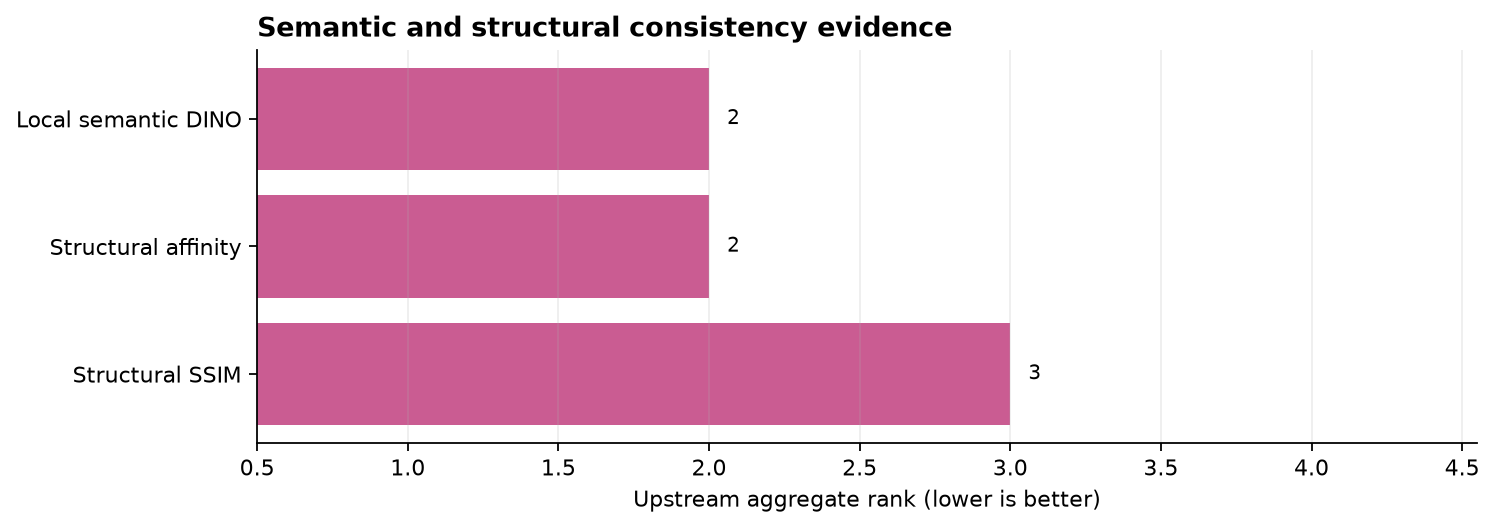
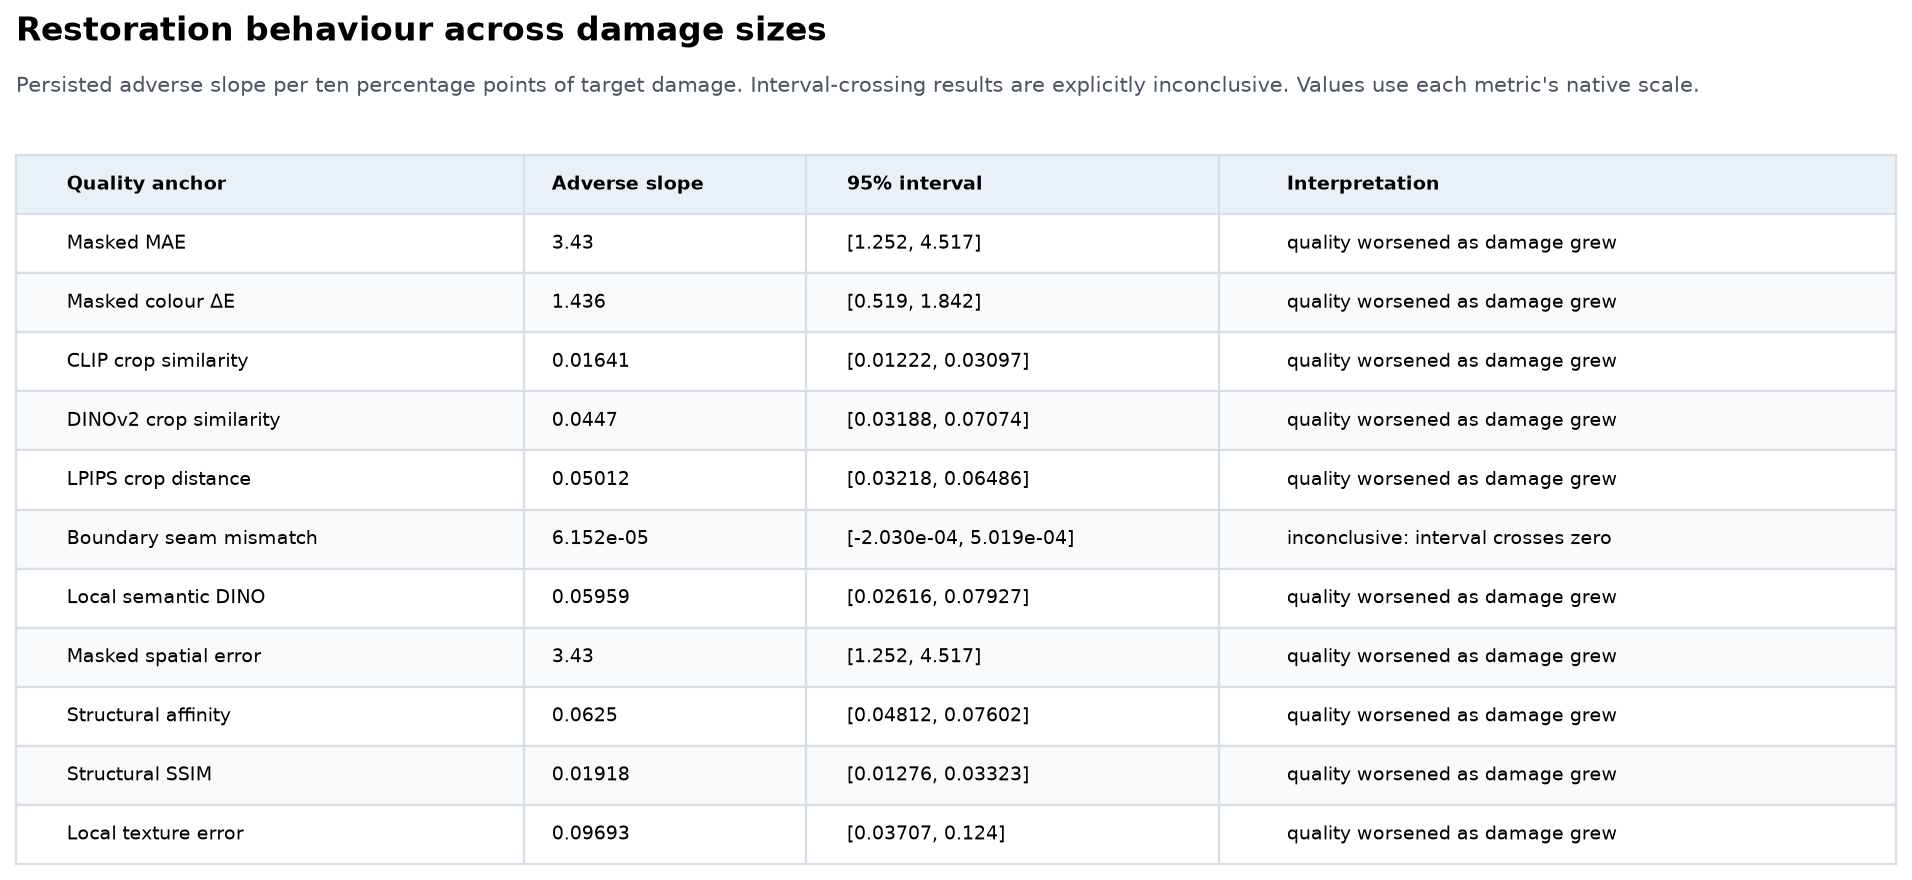
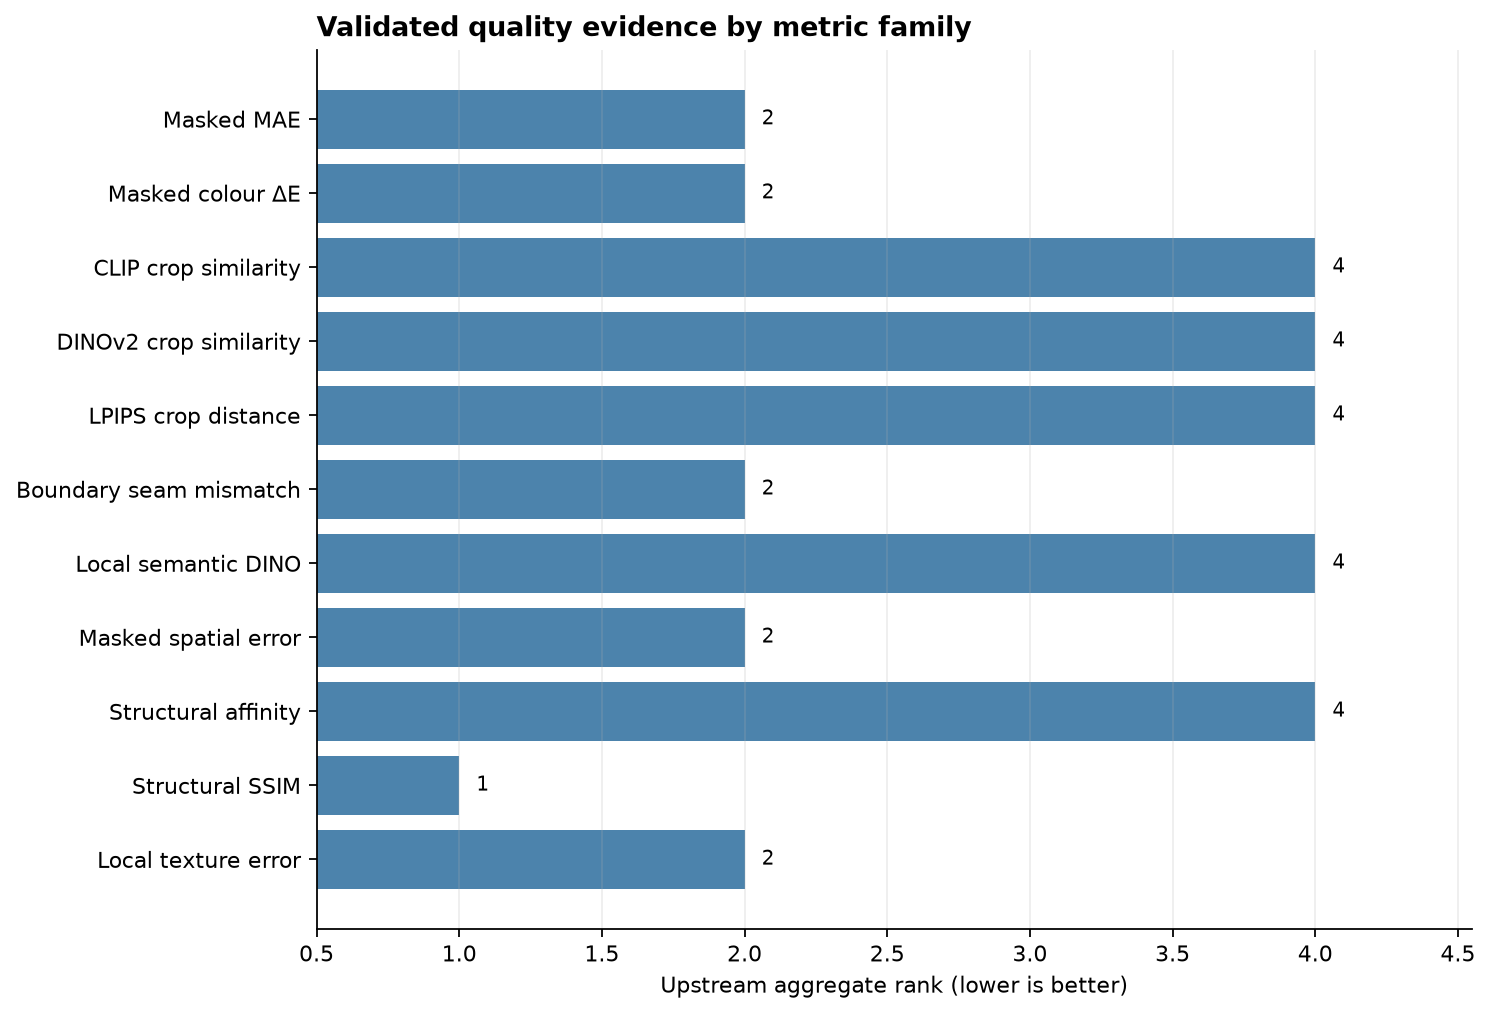
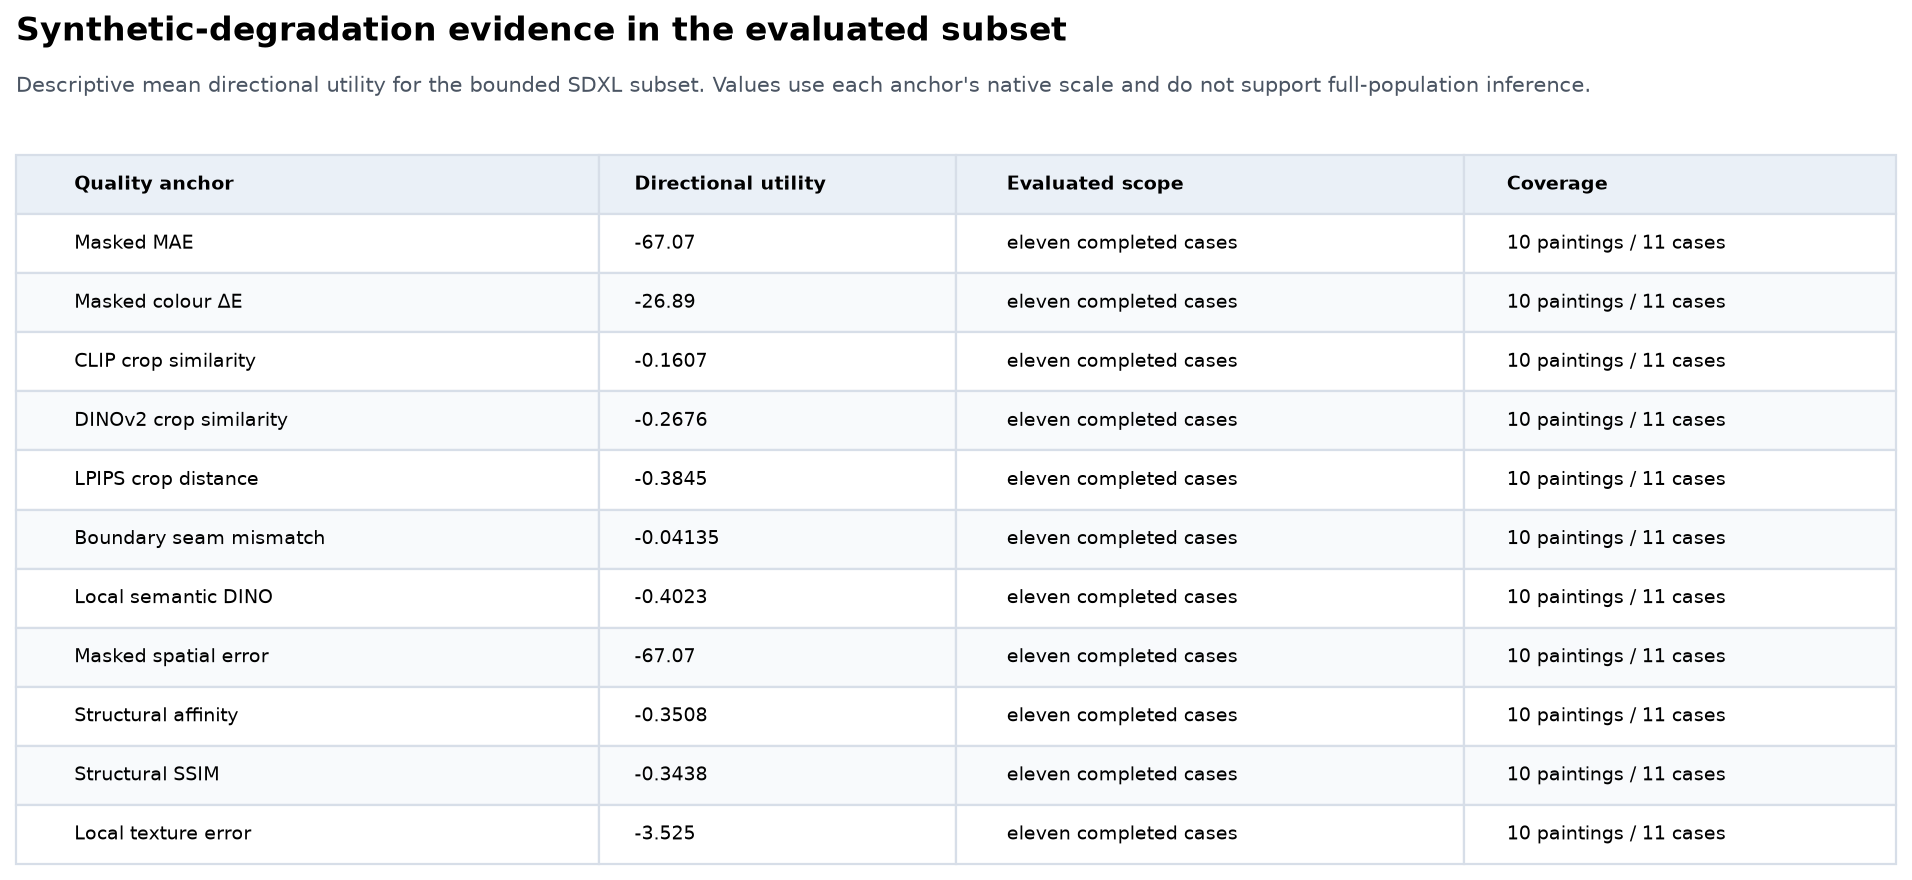
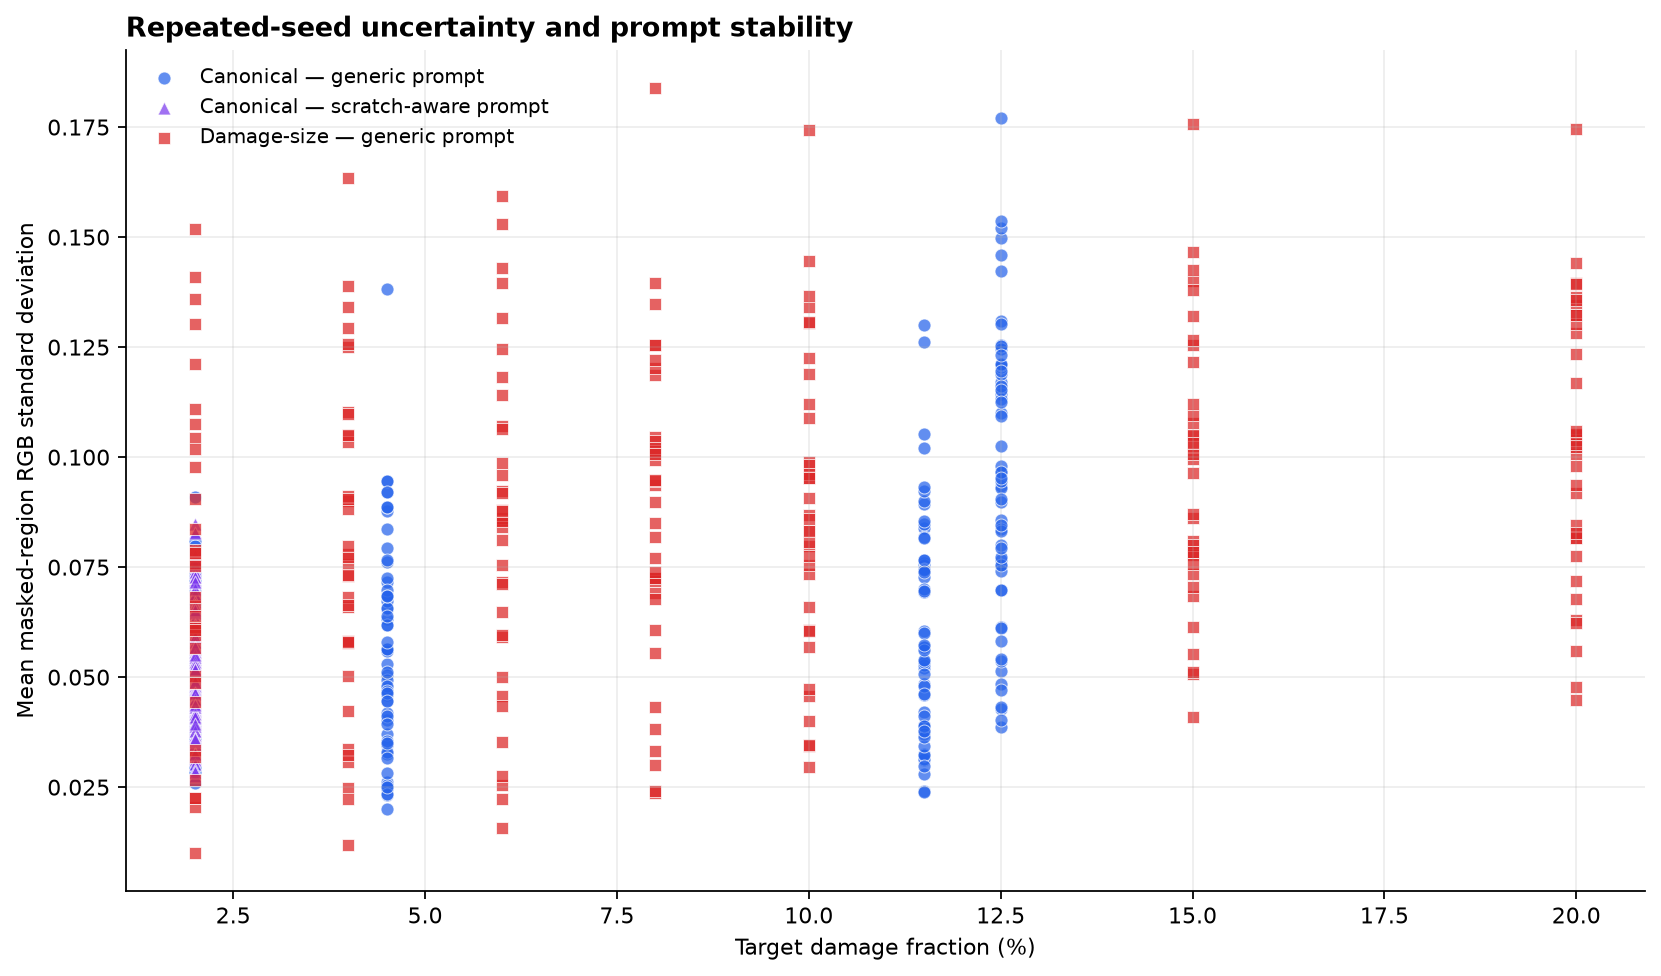

,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 8 analytical figure generation complete.
Validation checks: 5
Blocking failures: 0
Analytical assets: 29
Embedded PNG bytes: 2,905,399
QA figures rendered: 5
Canonical files written: 0


In [22]:
ANALYTICAL_ASSET_RECORDS = []

for plan_row in (
    ANALYTICAL_VIEW_PLAN.sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
    .to_dict("records")
):
    view_id = str(
        plan_row["view_id"]
    )
    model_id = str(
        plan_row["model_id"]
    )
    view_key = str(
        plan_row["view_key"]
    )
    title = str(
        plan_row["title"]
    )

    frame = ANALYTICAL_VIEW_DATA[
        view_id
    ]

    if view_key in {
        "overall_quality",
        "texture_colour_seam",
        "semantic_structural",
    }:
        figure = rank_figure(
            frame,
            model_id=model_id,
            title=title,
        )
        caption = (
            "Ranks are copied from Notebook 21's "
            "validated comparison table. Lower is better; "
            "the figure does not create a new ranking."
        )

    elif view_key == "damage_size":
        figure = damage_size_figure(
            frame,
            title=title,
        )
        caption = (
            "Notebook 23 target-fraction slopes and "
            "painting-cluster intervals. Positive adverse "
            "slopes indicate worse quality as damage grows."
        )

    elif view_key == "mask_robustness":
        figure = mask_robustness_figure(
            frame,
            title=title,
        )
        caption = (
            "Notebook 24 overall mask-variant dispersion. "
            "Lower dispersion means greater robustness "
            "within the evaluated 35-painting cohort."
        )

    elif view_key == "synthetic_degradation":
        figure = degradation_figure(
            frame,
            model_id=model_id,
            title=title,
        )

        if model_id == "sdxl_inpainting":
            caption = (
                "Notebook 25 descriptive SDXL evidence "
                "covers eleven completed degradation cases "
                "from ten paintings and is not a full "
                "population comparison."
            )
        else:
            caption = (
                "Notebook 25 painting-level degradation "
                "severity slopes. Metric-native magnitudes "
                "must be interpreted within each row."
            )

    elif (
        view_key
        == "uncertainty_prompt_stability"
    ):
        figure = uncertainty_figure(
            frame,
            title=title,
        )
        caption = (
            "All 780 canonical and 245 damage-size "
            "four-seed uncertainty groups are shown. "
            "Variability is empirical and is not "
            "calibrated confidence."
        )

    else:
        raise ValueError(
            "Unsupported analytical view: "
            f"{view_key}"
        )

    data_uri, image_size_bytes = (
        figure_to_png_data_uri(
            figure
        )
    )

    plt.close(
        figure
    )

    alt_text = (
        f"{MODEL_SPECS[model_id]['display_name']}: "
        f"{title}"
    )

    html_fragment = visual_html(
        data_uri,
        alt=alt_text,
        caption=caption,
        report_role="analytical_view",
        tile_count=1,
    )

    ANALYTICAL_ASSET_RECORDS.append(
        {
            "view_id": view_id,
            "model_id": model_id,
            "view_order": int(
                plan_row["view_order"]
            ),
            "view_key": view_key,
            "section_id": str(
                plan_row["section_id"]
            ),
            "title": title,
            "caption": caption,
            "data_uri": data_uri,
            "html_fragment": (
                html_fragment
            ),
            "image_size_bytes": int(
                image_size_bytes
            ),
            "report_role": (
                "analytical_view"
            ),
            "tile_count": 1,
            "status": "ok",
            "issue": "",
        }
    )

ANALYTICAL_VIEW_ASSETS = pd.DataFrame(
    ANALYTICAL_ASSET_RECORDS
)

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["analytical_view_assets"] = (
        ANALYTICAL_VIEW_ASSETS.loc[
            ANALYTICAL_VIEW_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

observed_asset_counts = (
    ANALYTICAL_VIEW_ASSETS.groupby(
        "model_id"
    )["view_id"]
    .size()
    .astype(int)
    .to_dict()
)

asset_ids_match_plan = (
    set(
        ANALYTICAL_VIEW_ASSETS[
            "view_id"
        ].astype(str)
    )
    == set(
        ANALYTICAL_VIEW_PLAN[
            "view_id"
        ].astype(str)
    )
)

asset_payloads_valid = bool(
    ANALYTICAL_VIEW_ASSETS[
        "data_uri"
    ]
    .astype(str)
    .str.startswith(
        "data:image/png;base64,"
    )
    .all()
    and ANALYTICAL_VIEW_ASSETS[
        "image_size_bytes"
    ].gt(1000).all()
)

asset_html_valid = bool(
    ANALYTICAL_VIEW_ASSETS[
        "html_fragment"
    ]
    .astype(str)
    .str.contains(
        'data-report-role="analytical_view"',
        regex=False,
    )
    .all()
    and ANALYTICAL_VIEW_ASSETS[
        "html_fragment"
    ]
    .astype(str)
    .str.contains(
        'data-tile-count="1"',
        regex=False,
    )
    .all()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_count_contract",
    description=(
        "All 29 planned analytical views have exactly "
        "one generated in-memory asset."
    ),
    expected=expected_view_counts,
    observed=observed_asset_counts,
    passed=(
        observed_asset_counts
        == expected_view_counts
        and len(
            ANALYTICAL_VIEW_ASSETS
        )
        == 29
        and asset_ids_match_plan
    ),
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_payloads",
    description=(
        "Every analytical asset is a non-empty embedded "
        "PNG data URI."
    ),
    expected=29,
    observed=int(
        ANALYTICAL_VIEW_ASSETS[
            "data_uri"
        ]
        .astype(str)
        .str.startswith(
            "data:image/png;base64,"
        )
        .sum()
    ),
    passed=asset_payloads_valid,
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_html",
    description=(
        "Every analytical HTML fragment has the approved "
        "visual role and one-tile declaration."
    ),
    expected=29,
    observed=int(
        ANALYTICAL_VIEW_ASSETS[
            "html_fragment"
        ]
        .astype(str)
        .str.contains(
            'data-report-role="analytical_view"',
            regex=False,
        )
        .sum()
    ),
    passed=asset_html_valid,
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="analytical_asset_status",
    description=(
        "Every analytical asset completed without "
        "an issue marker."
    ),
    expected={
        "ok": 29
    },
    observed=(
        ANALYTICAL_VIEW_ASSETS[
            "status"
        ].value_counts().to_dict()
    ),
    passed=bool(
        len(ANALYTICAL_VIEW_ASSETS)
        == 29
        and ANALYTICAL_VIEW_ASSETS[
            "status"
        ].eq("ok").all()
        and ANALYTICAL_VIEW_ASSETS[
            "issue"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .all()
    ),
)

output_files_after_batch_8 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_8_STAGE,
    check_id="batch_8_has_no_persistence",
    description=(
        "Analytical figure generation creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_8
    ),
    passed=not output_files_after_batch_8,
)

asset_summary = (
    ANALYTICAL_VIEW_ASSETS.groupby(
        "model_id"
    )
    .agg(
        analytical_views=(
            "view_id",
            "size",
        ),
        total_png_bytes=(
            "image_size_bytes",
            "sum",
        ),
        minimum_png_bytes=(
            "image_size_bytes",
            "min",
        ),
        maximum_png_bytes=(
            "image_size_bytes",
            "max",
        ),
    )
    .reset_index()
)

display(asset_summary)

qa_view_keys = {
    (
        "opencv_telea",
        "overall_quality",
    ),
    (
        "lama",
        "damage_size",
    ),
    (
        "hint_places2",
        "semantic_structural",
    ),
    (
        "stable_diffusion_inpainting",
        "uncertainty_prompt_stability",
    ),
    (
        "sdxl_inpainting",
        "synthetic_degradation",
    ),
}

qa_assets = (
    ANALYTICAL_VIEW_ASSETS.loc[
        [
            (
                str(row["model_id"]),
                str(row["view_key"]),
            )
            in qa_view_keys
            for row in (
                ANALYTICAL_VIEW_ASSETS[
                    [
                        "model_id",
                        "view_key",
                    ]
                ]
                .to_dict("records")
            )
        ]
    ]
    .sort_values(
        [
            "model_id",
            "view_order",
        ],
        kind="stable",
    )
)

display(
    HTML(
        "<h3>Batch 8 analytical visual QA</h3>"
        + "".join(
            qa_assets[
                "html_fragment"
            ].astype(str)
        )
    )
)

BATCH_8_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_8_ROWS = (
    BATCH_8_VALIDATION.loc[
        BATCH_8_VALIDATION[
            "validation_stage"
        ].eq(BATCH_8_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_8_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_8_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_8_ROWS.loc[
        ~BATCH_8_ROWS["passed"]
    ]
)

print("Batch 8 analytical figure generation complete.")
print(
    "Validation checks: "
    f"{len(BATCH_8_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Analytical assets: "
    f"{len(ANALYTICAL_VIEW_ASSETS):,}"
)
print(
    "Embedded PNG bytes: "
    f"{int(ANALYTICAL_VIEW_ASSETS['image_size_bytes'].sum()):,}"
)
print(
    "QA figures rendered: "
    f"{len(qa_assets):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_8):,}"
)

VALIDATION.raise_for_blocking()

## Batch 9 — Generate representative panels and visual atlases

### Purpose

This batch converts the validated analytical views and representative selections into the publication-facing visual layer.

It generates:

- 40 representative case panels across Telea, LaMa, HINT, Stable Diffusion and the bounded SDXL branch;
- 10 model-level atlases, with two complementary atlases per model;
- 107 atlas tiles selected across the controlled experiment population;
- embedded analytical, representative and atlas imagery for the five model reports;
- visual-density and payload validation without prematurely writing final report files.

Representative panels combine:

1. the clean reference;
2. the damaged input;
3. the selected restoration;
4. the applied mask;
5. the model-versus-reference absolute-difference view, where applicable;
6. the restoration-versus-reference absolute-difference view, where applicable.

The single HINT zero-control representative is retained as an explicit diagnostic exemption because an undamaged control does not require meaningful mask-derived difference diagnostics.

The generated assets remain in memory during this batch. Final HTML report construction and filesystem persistence occur only in the subsequent report-writing batches.

In [23]:
BATCH_9_STAGE = "batch_9_representative_and_atlas_assets"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_9_STAGE,
)

from PIL import Image


DIAGNOSTIC_DOMAIN_PRIORITY = [
    "uncertainty",
    "difference",
    "semantic",
    "texture",
    "colour",
    "seam",
    "mask_boundary",
]


def load_report_tile(
    declared_path,
) -> np.ndarray:
    """Load one previously validated repository image."""
    _, resolved_path = (
        normalize_repository_image_path(
            declared_path
        )
    )

    return plt.imread(
        resolved_path
    )


def figure_to_jpeg_data_uri(
    figure: mpl.figure.Figure,
    *,
    quality: int,
) -> tuple[str, int]:
    """Encode a photographic composite without writing it to disk."""
    png_buffer = io.BytesIO()

    figure.savefig(
        png_buffer,
        format="png",
        dpi=125,
        bbox_inches="tight",
        facecolor="white",
    )

    png_buffer.seek(0)

    jpeg_buffer = io.BytesIO()

    with Image.open(
        png_buffer
    ) as rendered:
        rendered.convert(
            "RGB"
        ).save(
            jpeg_buffer,
            format="JPEG",
            quality=int(quality),
            optimize=True,
            progressive=True,
        )

    payload = jpeg_buffer.getvalue()

    data_uri = (
        "data:image/jpeg;base64,"
        + base64.b64encode(
            payload
        ).decode("ascii")
    )

    return data_uri, len(payload)


def render_image_grid(
    *,
    tiles: list[dict],
    title: str,
    columns: int,
) -> mpl.figure.Figure:
    """Render one auditable composite from existing image tiles."""
    if not tiles:
        raise ValueError(
            "Cannot render an empty image grid."
        )

    columns = max(
        1,
        int(columns),
    )

    row_count = int(
        np.ceil(
            len(tiles) / columns
        )
    )

    figure, axes = plt.subplots(
        row_count,
        columns,
        figsize=(
            3.25 * columns,
            3.15 * row_count + 0.65,
        ),
        squeeze=False,
    )

    flat_axes = axes.ravel()

    for axis, tile in zip(
        flat_axes,
        tiles,
    ):
        image_array = load_report_tile(
            tile["path"]
        )

        if tile.get(
            "is_mask",
            False,
        ):
            axis.imshow(
                image_array,
                cmap="gray",
                vmin=0,
                vmax=1,
            )
        else:
            axis.imshow(
                image_array
            )

        axis.set_title(
            str(tile["label"]),
            fontsize=8.5,
            pad=5,
        )

        axis.axis("off")

    for axis in flat_axes[
        len(tiles):
    ]:
        axis.axis("off")

    figure.suptitle(
        title,
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )

    figure.tight_layout(
        rect=[
            0.0,
            0.0,
            1.0,
            0.96,
        ],
        pad=0.7,
    )

    return figure


def representative_diagnostic_tiles(
    selection: dict,
    *,
    maximum_count: int = 2,
) -> list[dict]:
    """Select at most one image from each prioritized diagnostic domain."""
    raw_payload = selection[
        "diagnostic_paths_json"
    ]

    if isinstance(raw_payload, dict):
        payload = raw_payload
    elif (
        pd.isna(raw_payload)
        or not str(raw_payload).strip()
    ):
        payload = {}
    else:
        payload = json.loads(
            str(raw_payload)
        )

    selected_tiles = []
    selected_paths = set()

    for domain in (
        DIAGNOSTIC_DOMAIN_PRIORITY
    ):
        declared_values = payload.get(
            domain,
            [],
        )

        if not isinstance(
            declared_values,
            list,
        ):
            continue

        for declared_value in (
            declared_values
        ):
            declared_text = str(
                declared_value
            ).strip()

            if not declared_text:
                continue

            if (
                Path(
                    declared_text
                ).suffix.lower()
                not in IMAGE_EXTENSIONS
            ):
                continue

            relative_path, resolved_path = (
                normalize_repository_image_path(
                    declared_text
                )
            )

            if (
                not resolved_path.is_file()
                or relative_path
                in selected_paths
            ):
                continue

            selected_tiles.append(
                {
                    "path": relative_path,
                    "label": (
                        domain.replace(
                            "_",
                            " ",
                        ).title()
                        + " diagnostic"
                    ),
                    "diagnostic_domain": (
                        domain
                    ),
                    "is_mask": False,
                }
            )

            selected_paths.add(
                relative_path
            )

            break

        if (
            len(selected_tiles)
            >= maximum_count
        ):
            break

    return selected_tiles


print("Representative and atlas image helpers initialized.")

Representative and atlas image helpers initialized.


In [24]:
REPRESENTATIVE_ASSET_RECORDS = []

for selection in (
    REPRESENTATIVE_SELECTIONS.sort_values(
        [
            "model_id",
            "selection_order",
        ],
        kind="stable",
    )
    .to_dict("records")
):
    model_id = str(
        selection["model_id"]
    )

    core_tiles = [
        {
            "path": selection[
                "clean_path"
            ],
            "label": "Clean reference",
            "is_mask": False,
        },
        {
            "path": selection[
                "damaged_path"
            ],
            "label": "Damaged input",
            "is_mask": False,
        },
        {
            "path": selection[
                "mask_path"
            ],
            "label": "Mask or effect support",
            "is_mask": True,
        },
        {
            "path": selection[
                "restored_path"
            ],
            "label": "Restored output",
            "is_mask": False,
        },
    ]

    if (
        str(
            selection[
                "diagnostic_applicability"
            ]
        )
        == "applicable"
    ):
        diagnostic_tiles = (
            representative_diagnostic_tiles(
                selection,
                maximum_count=2,
            )
        )
    else:
        diagnostic_tiles = []

    panel_tiles = [
        *core_tiles,
        *diagnostic_tiles,
    ]

    panel_title = (
        f"{MODEL_SPECS[model_id]['display_name']} | "
        f"{selection['painting_id']} | "
        f"{str(selection['degradation_family']).replace('_', ' ')}"
    )

    figure = render_image_grid(
        tiles=panel_tiles,
        title=panel_title,
        columns=3,
    )

    data_uri, image_size_bytes = (
        figure_to_jpeg_data_uri(
            figure,
            quality=int(
                REPORT_POLICY[
                    "photographic_quality"
                ]
            ),
        )
    )

    plt.close(
        figure
    )

    caption = (
        f"Candidate {selection['candidate_id']}. "
        f"Recommendation category: "
        f"{str(selection['recommendation_category']).replace('_', ' ')}. "
        "This deterministic report selection is illustrative "
        "and is not an independent scientific observation."
    )

    html_fragment = visual_html(
        data_uri,
        alt=(
            f"{MODEL_SPECS[model_id]['display_name']} "
            f"representative restoration panel for "
            f"{selection['case_id']}"
        ),
        caption=caption,
        report_role=(
            "representative_panel"
        ),
        tile_count=len(
            panel_tiles
        ),
    )

    REPRESENTATIVE_ASSET_RECORDS.append(
        {
            "selection_id": selection[
                "selection_id"
            ],
            "model_id": model_id,
            "selection_order": int(
                selection[
                    "selection_order"
                ]
            ),
            "candidate_id": selection[
                "candidate_id"
            ],
            "case_id": selection[
                "case_id"
            ],
            "painting_id": selection[
                "painting_id"
            ],
            "recommendation_category": (
                selection[
                    "recommendation_category"
                ]
            ),
            "diagnostic_applicability": (
                selection[
                    "diagnostic_applicability"
                ]
            ),
            "diagnostic_tile_count": len(
                diagnostic_tiles
            ),
            "tile_count": len(
                panel_tiles
            ),
            "data_uri": data_uri,
            "html_fragment": (
                html_fragment
            ),
            "image_size_bytes": int(
                image_size_bytes
            ),
            "report_role": (
                "representative_panel"
            ),
            "status": "ok",
            "issue": "",
        }
    )

REPRESENTATIVE_PANEL_ASSETS = (
    pd.DataFrame(
        REPRESENTATIVE_ASSET_RECORDS
    )
)

ATLAS_ASSET_RECORDS = []

for (
    model_id,
    atlas_id,
), atlas_rows in (
    ATLAS_SELECTIONS.groupby(
        [
            "model_id",
            "atlas_id",
        ],
        sort=False,
    )
):
    atlas_rows = (
        atlas_rows.sort_values(
            "tile_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    atlas_title = str(
        atlas_rows.iloc[
            0
        ]["atlas_title"]
    )

    atlas_tiles = []

    for row in atlas_rows.to_dict(
        "records"
    ):
        label = (
            f"{row['painting_id']} | "
            f"{str(row['degradation_family']).replace('_', ' ')}\n"
            f"{str(row['recommendation_category']).replace('_', ' ')}"
        )

        atlas_tiles.append(
            {
                "path": row[
                    "restored_path"
                ],
                "label": label,
                "is_mask": False,
            }
        )

    figure = render_image_grid(
        tiles=atlas_tiles,
        title=(
            f"{MODEL_SPECS[model_id]['display_name']} — "
            f"{atlas_title}"
        ),
        columns=4,
    )

    data_uri, image_size_bytes = (
        figure_to_jpeg_data_uri(
            figure,
            quality=int(
                REPORT_POLICY[
                    "photographic_quality"
                ]
            ),
        )
    )

    plt.close(
        figure
    )

    caption = (
        f"{atlas_title} atlas with "
        f"{len(atlas_tiles)} restored-output tiles. "
        "Atlas cases are deterministic coverage examples; "
        "the complete evidence remains in the upstream tables."
    )

    html_fragment = visual_html(
        data_uri,
        alt=(
            f"{MODEL_SPECS[model_id]['display_name']} "
            f"{atlas_title.lower()} atlas"
        ),
        caption=caption,
        report_role="visual_atlas",
        tile_count=len(
            atlas_tiles
        ),
    )

    ATLAS_ASSET_RECORDS.append(
        {
            "atlas_asset_id": (
                f"atlas__{model_id}__"
                f"{atlas_id}"
            ),
            "model_id": model_id,
            "atlas_id": atlas_id,
            "atlas_title": atlas_title,
            "atlas_order": int(
                atlas_rows.iloc[
                    0
                ]["atlas_order"]
            ),
            "tile_count": len(
                atlas_tiles
            ),
            "data_uri": data_uri,
            "html_fragment": (
                html_fragment
            ),
            "image_size_bytes": int(
                image_size_bytes
            ),
            "report_role": (
                "visual_atlas"
            ),
            "status": "ok",
            "issue": "",
        }
    )

VISUAL_ATLAS_ASSETS = pd.DataFrame(
    ATLAS_ASSET_RECORDS
)

print("Representative panels and atlases generated.")
print(
    "Representative panels: "
    f"{len(REPRESENTATIVE_PANEL_ASSETS):,}"
)
print(
    "Visual atlases: "
    f"{len(VISUAL_ATLAS_ASSETS):,}"
)

Representative panels and atlases generated.
Representative panels: 40
Visual atlases: 10


,model_id,analytical_images,representative_images,atlas_images,embedded_images,minimum_embedded_images,embedded_tiles,minimum_embedded_tiles,image_count_passed,tile_count_passed
0,opencv_telea,6,8,2,16,16,76,60,True,True
1,lama,6,8,2,16,16,76,60,True,True
2,hint_places2,6,8,2,16,16,74,60,True,True
3,stable_diffusion_inpainting,7,10,2,19,19,92,72,True,True
4,sdxl_inpainting,4,6,2,12,12,56,44,True,True



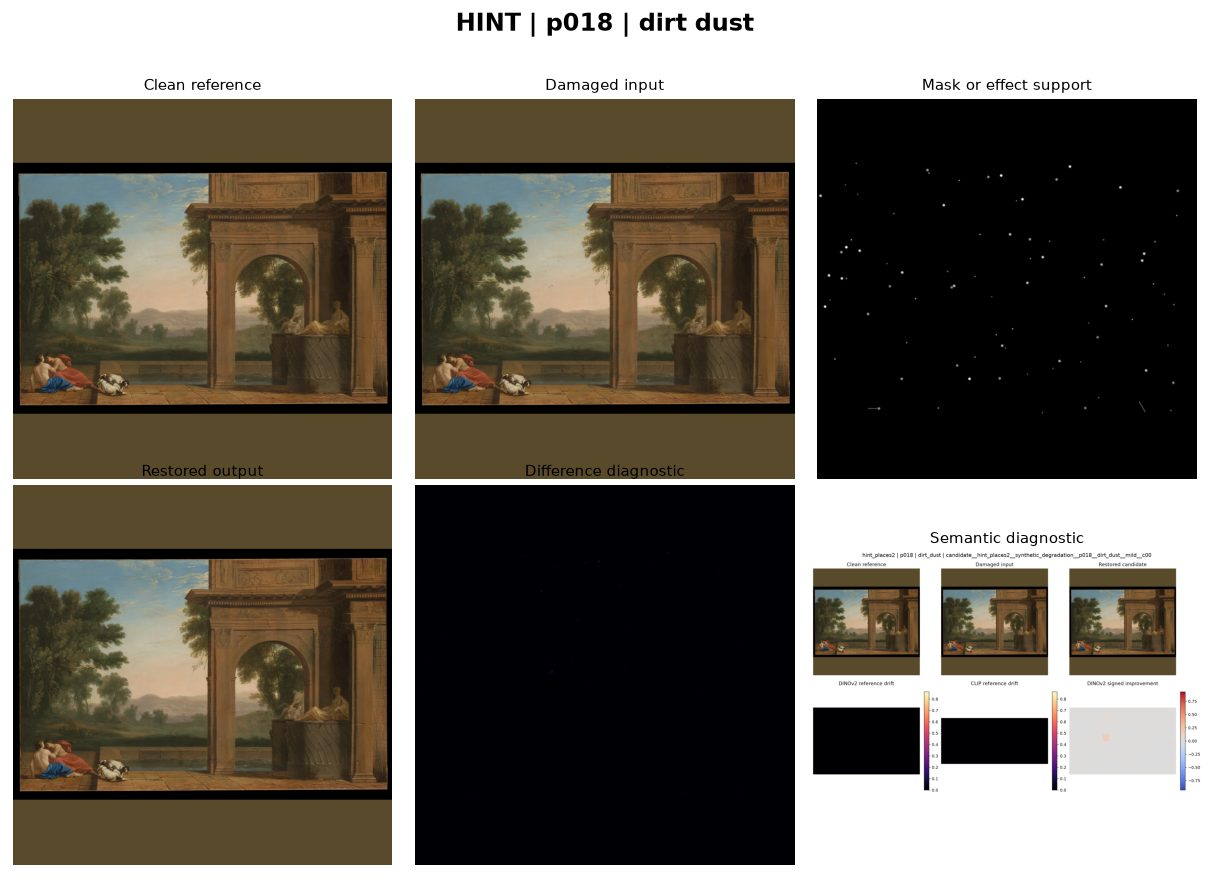
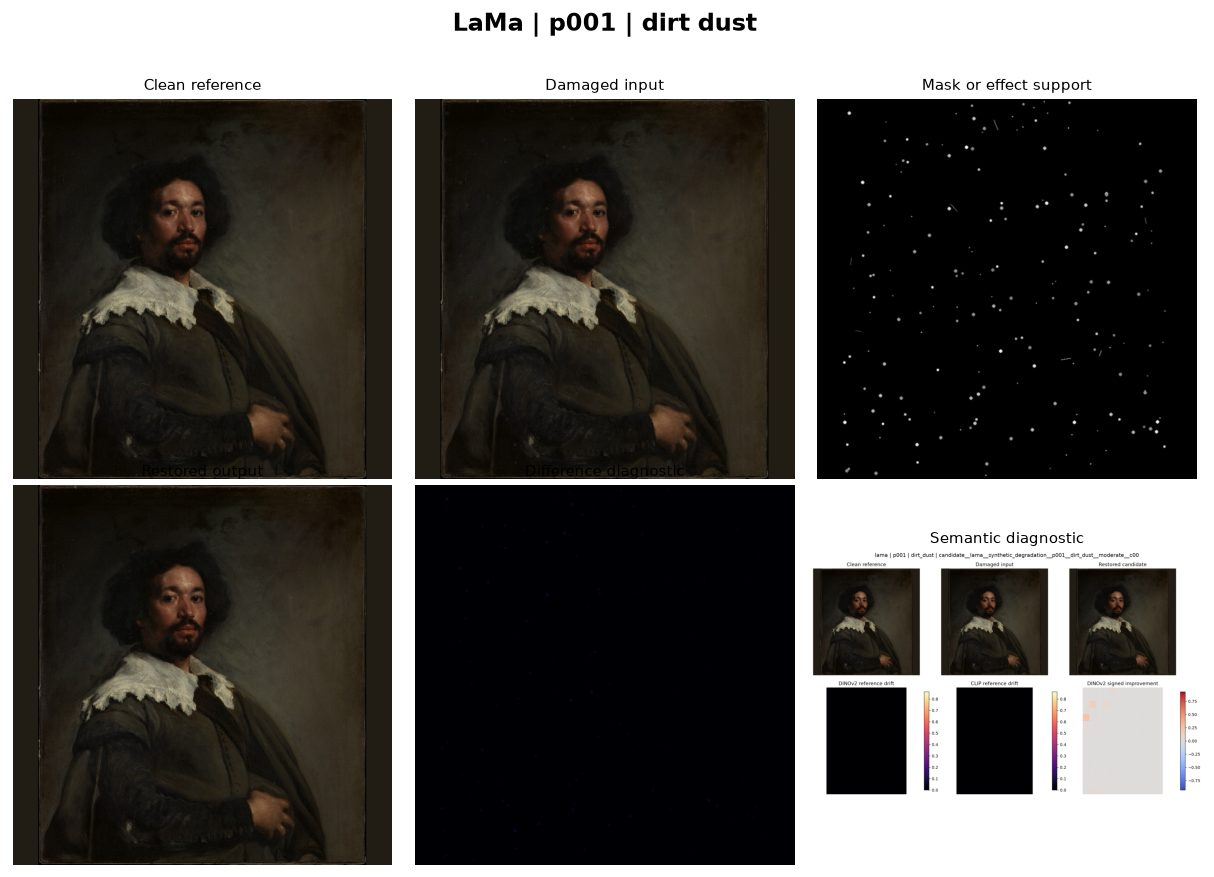
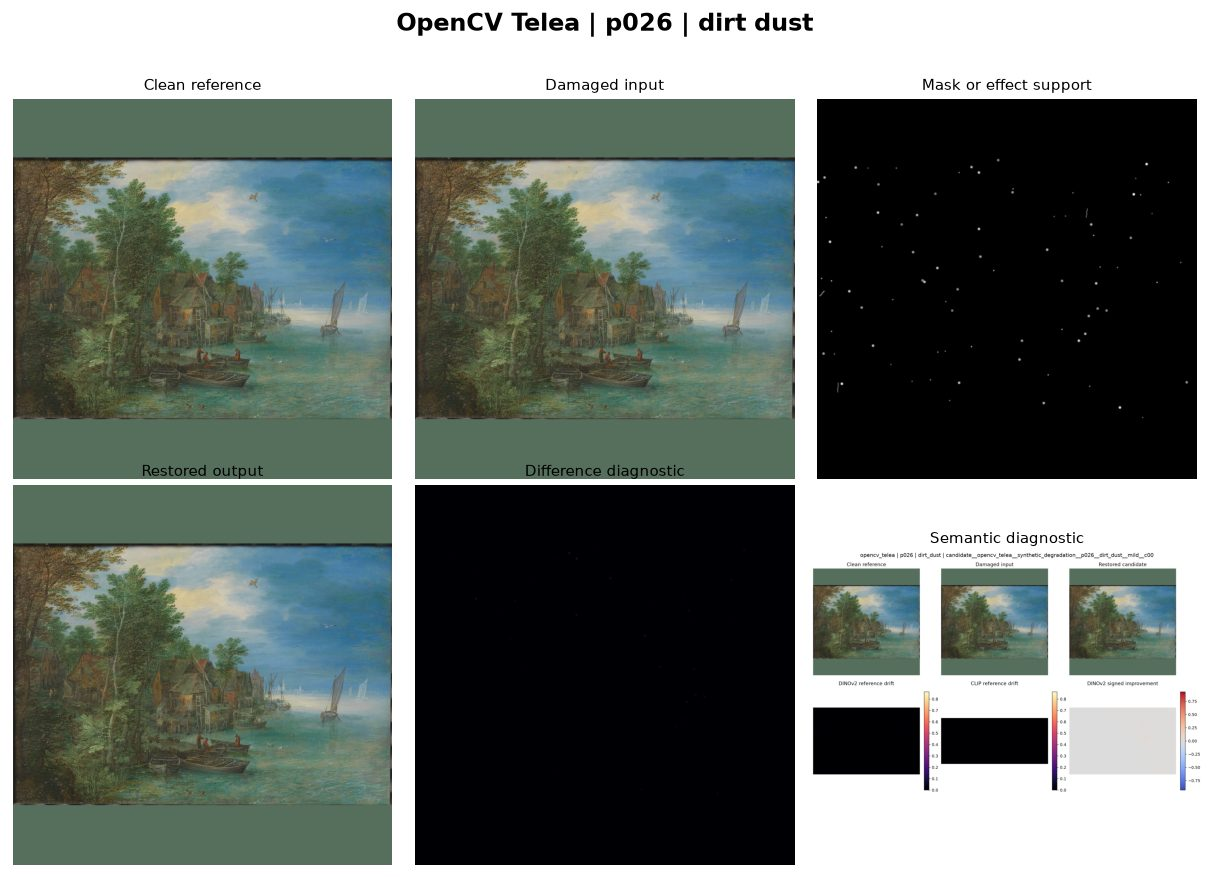
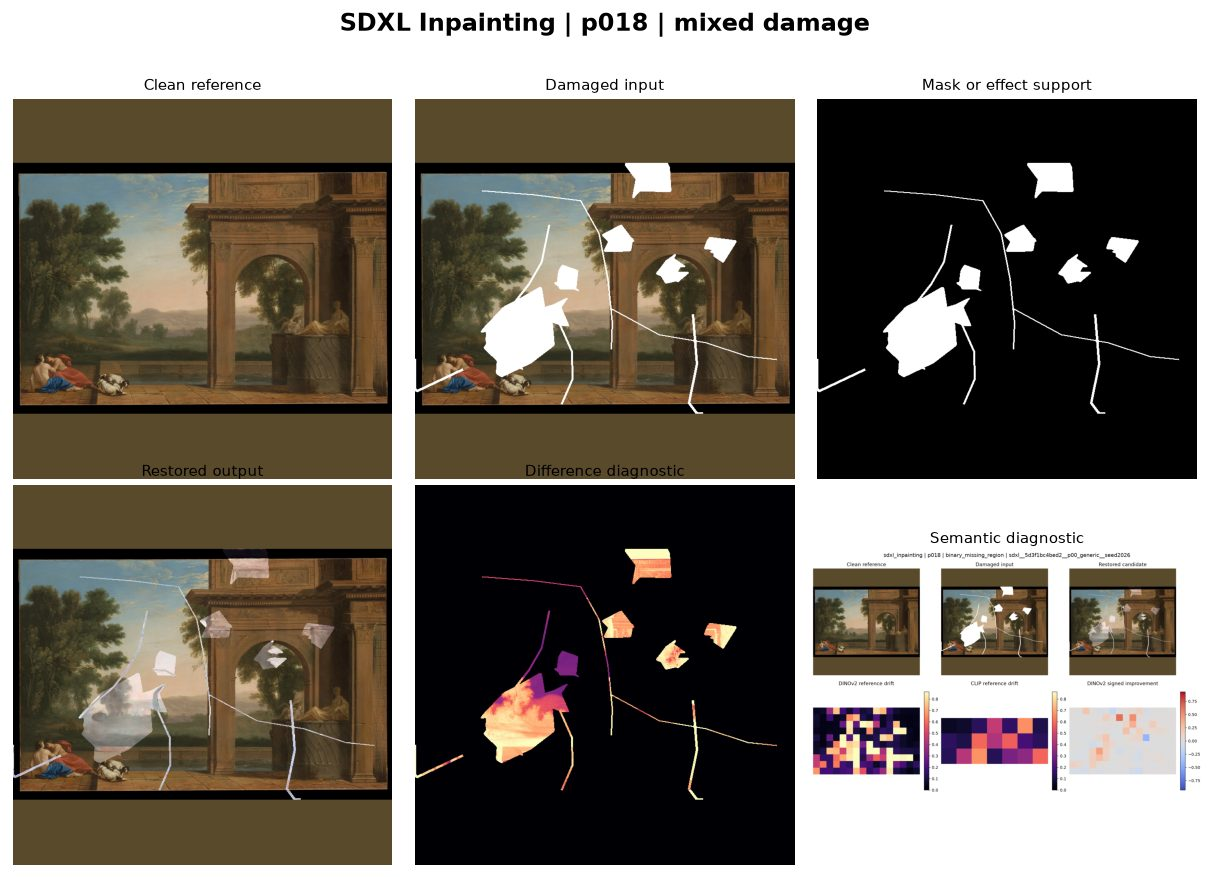
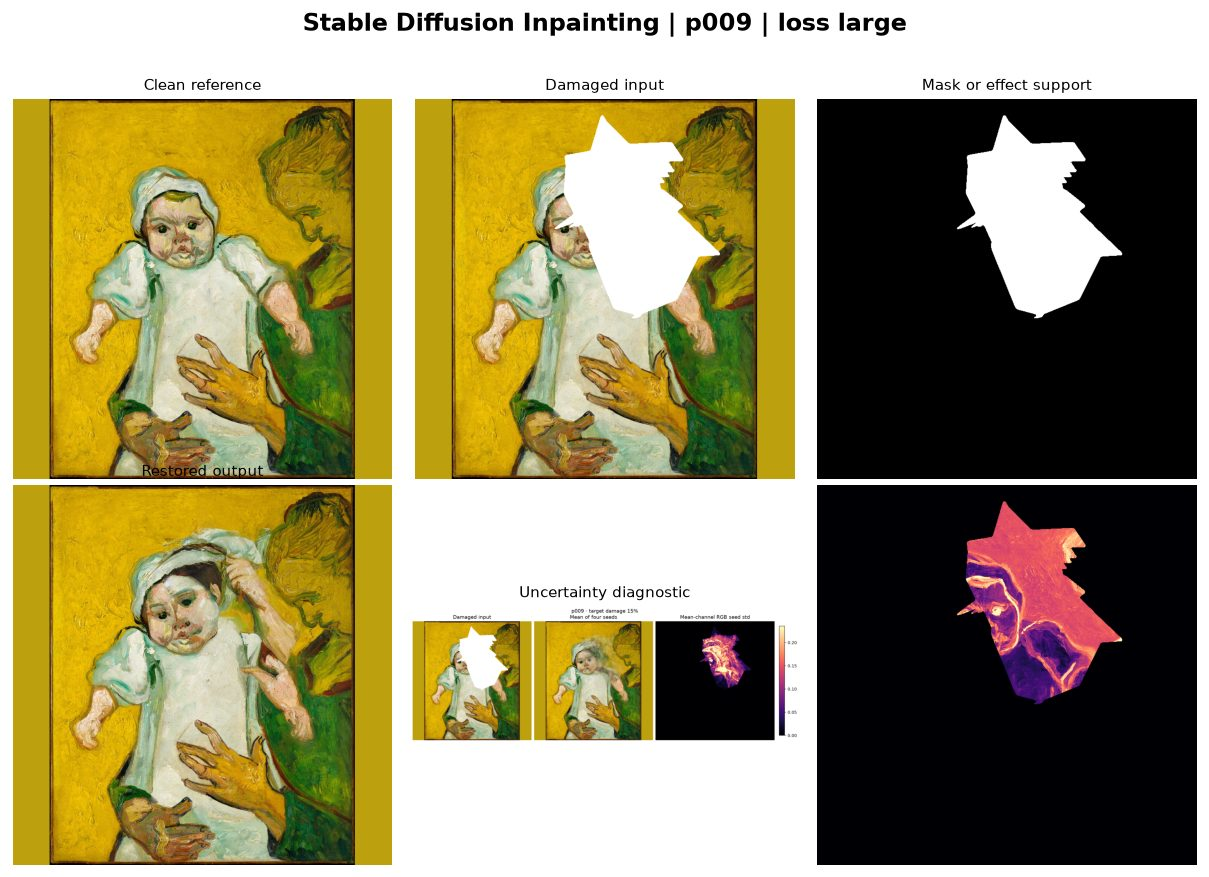
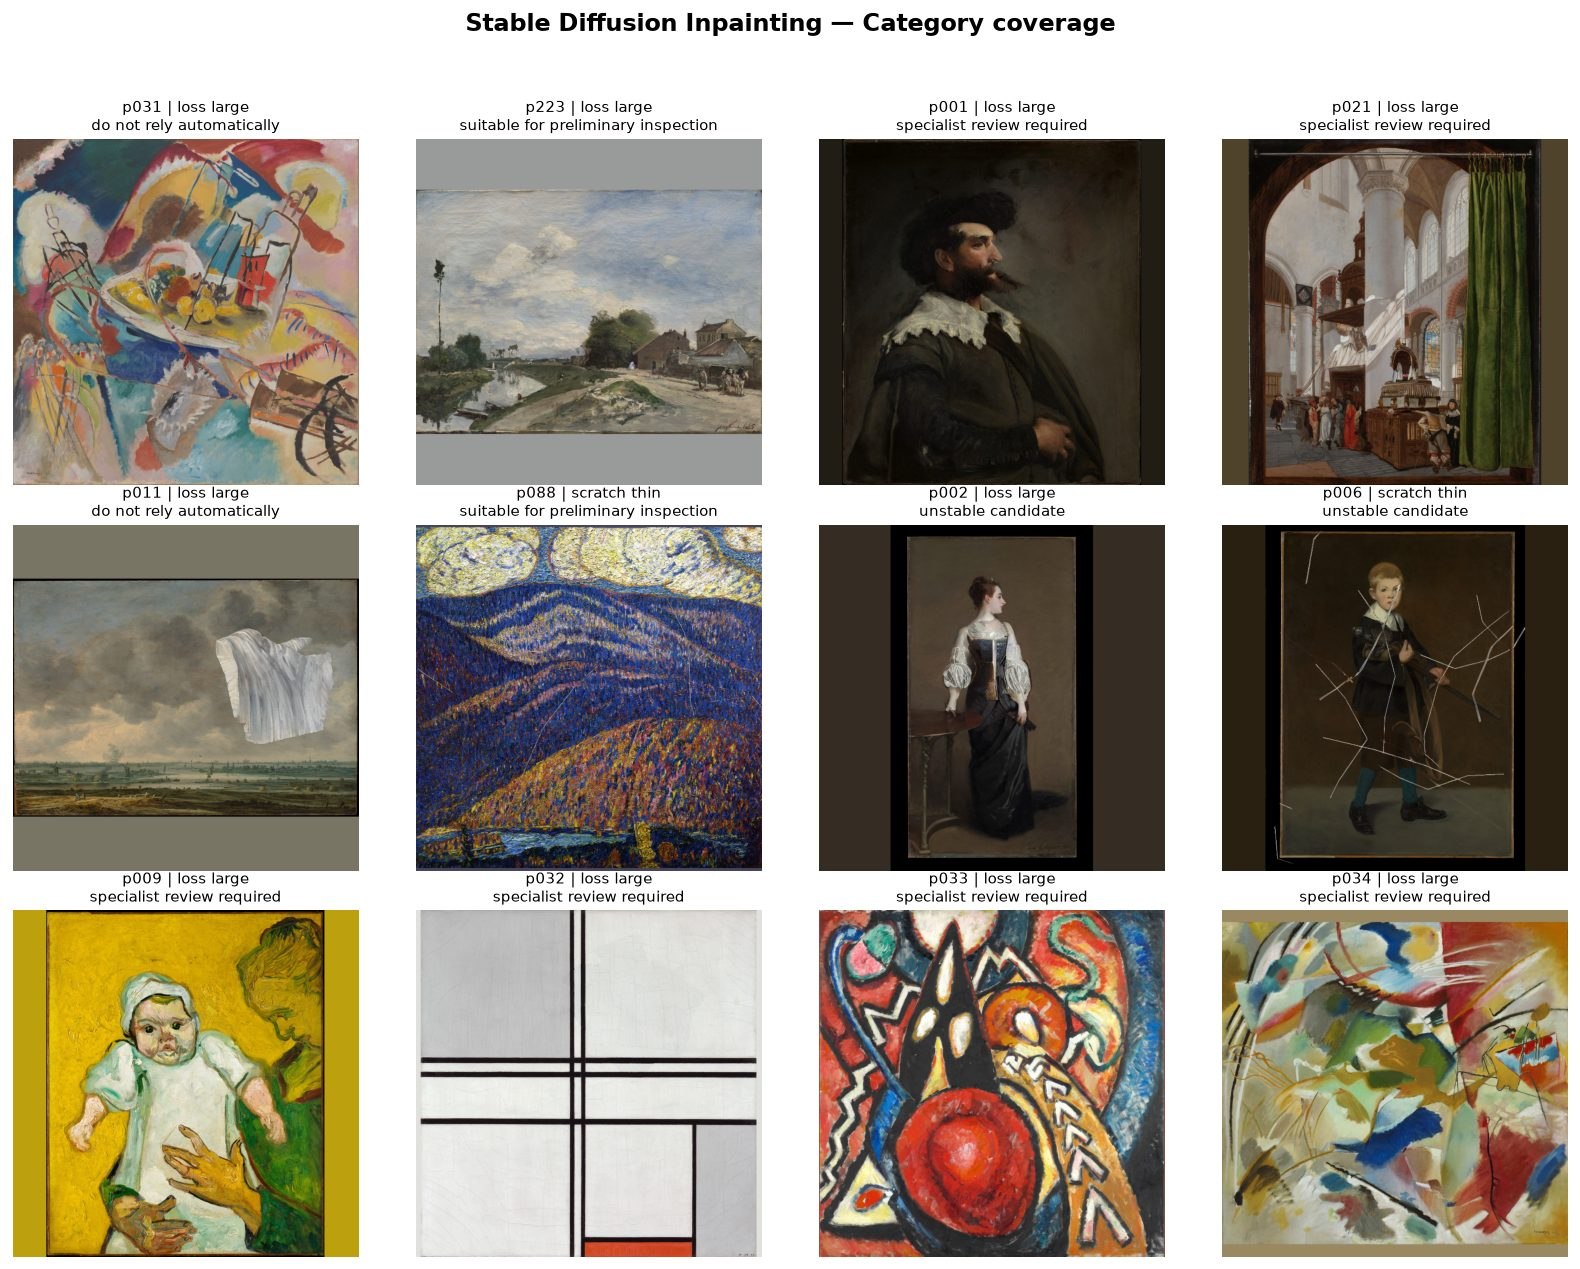

,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 9 representative and atlas assets complete.
Validation checks: 7
Blocking failures: 0
Representative panels: 40
Visual atlases: 10
Representative diagnostic tiles: 78
Atlas tiles: 107
Canonical files written: 0


In [26]:
for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["representative_panel_assets"] = (
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "selection_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["visual_atlas_assets"] = (
        VISUAL_ATLAS_ASSETS.loc[
            VISUAL_ATLAS_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "atlas_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )


# ---------------------------------------------------------------------------
# Expected and observed representative-panel counts
# ---------------------------------------------------------------------------

expected_representative_counts = {
    model_id: int(
        spec[
            "representative_panel_count"
        ]
    )
    for model_id, spec
    in MODEL_SPECS.items()
}

observed_representative_counts = (
    REPRESENTATIVE_PANEL_ASSETS.groupby(
        "model_id"
    )["selection_id"]
    .size()
    .astype(int)
    .to_dict()
)

expected_representative_total = sum(
    expected_representative_counts.values()
)


# ---------------------------------------------------------------------------
# Expected and observed atlas counts
# ---------------------------------------------------------------------------

expected_atlas_asset_counts = {
    model_id: int(
        spec[
            "visual_atlas_count"
        ]
    )
    for model_id, spec
    in MODEL_SPECS.items()
}

observed_atlas_counts = (
    VISUAL_ATLAS_ASSETS.groupby(
        "model_id"
    )["atlas_asset_id"]
    .size()
    .astype(int)
    .to_dict()
)

expected_atlas_total = sum(
    expected_atlas_asset_counts.values()
)


# ---------------------------------------------------------------------------
# Representative diagnostic applicability
# ---------------------------------------------------------------------------

applicable_representative_assets = (
    REPRESENTATIVE_PANEL_ASSETS.loc[
        REPRESENTATIVE_PANEL_ASSETS[
            "diagnostic_applicability"
        ].eq("applicable")
    ]
)

exempt_representative_assets = (
    REPRESENTATIVE_PANEL_ASSETS.loc[
        REPRESENTATIVE_PANEL_ASSETS[
            "diagnostic_applicability"
        ].ne("applicable")
    ]
)

representative_diagnostics_ok = bool(
    len(
        applicable_representative_assets
    )
    == 39
    and len(
        exempt_representative_assets
    )
    == 1
    and applicable_representative_assets[
        "diagnostic_tile_count"
    ].eq(2).all()
    and exempt_representative_assets[
        "diagnostic_tile_count"
    ].eq(0).all()
)


# ---------------------------------------------------------------------------
# Embedded payload integrity
# ---------------------------------------------------------------------------

representative_payload_mask = (
    REPRESENTATIVE_PANEL_ASSETS[
        "data_uri"
    ]
    .astype(str)
    .str.startswith(
        "data:image/jpeg;base64,"
    )
    & REPRESENTATIVE_PANEL_ASSETS[
        "image_size_bytes"
    ].gt(5000)
)

atlas_payload_mask = (
    VISUAL_ATLAS_ASSETS[
        "data_uri"
    ]
    .astype(str)
    .str.startswith(
        "data:image/jpeg;base64,"
    )
    & VISUAL_ATLAS_ASSETS[
        "image_size_bytes"
    ].gt(5000)
)

representative_payload_count = int(
    representative_payload_mask.sum()
)

atlas_payload_count = int(
    atlas_payload_mask.sum()
)

representative_payloads_ok = bool(
    representative_payload_count
    == len(
        REPRESENTATIVE_PANEL_ASSETS
    )
    == 40
)

atlas_payloads_ok = bool(
    atlas_payload_count
    == len(
        VISUAL_ATLAS_ASSETS
    )
    == 10
)


# ---------------------------------------------------------------------------
# Atlas tile populations
# ---------------------------------------------------------------------------

observed_atlas_tile_counts = {
    (
        str(row["model_id"]),
        str(row["atlas_id"]),
    ): int(
        row["tile_count"]
    )
    for row in (
        VISUAL_ATLAS_ASSETS.to_dict(
            "records"
        )
    )
}

expected_atlas_tile_counts = {
    (
        str(model_id),
        str(atlas_id),
    ): int(
        len(atlas_rows)
    )
    for (
        model_id,
        atlas_id,
    ), atlas_rows in (
        ATLAS_SELECTIONS.groupby(
            [
                "model_id",
                "atlas_id",
            ]
        )
    )
}

observed_atlas_tile_total = int(
    VISUAL_ATLAS_ASSETS[
        "tile_count"
    ].sum()
)

expected_atlas_tile_total = int(
    len(
        ATLAS_SELECTIONS
    )
)


# ---------------------------------------------------------------------------
# Complete report visual-density calculation
# ---------------------------------------------------------------------------

visual_density_records = []

for model_id, spec in (
    MODEL_SPECS.items()
):
    analytical_assets = (
        ANALYTICAL_VIEW_ASSETS.loc[
            ANALYTICAL_VIEW_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
    )

    representative_assets = (
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
    )

    atlas_assets = (
        VISUAL_ATLAS_ASSETS.loc[
            VISUAL_ATLAS_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
    )

    embedded_images = (
        len(analytical_assets)
        + len(representative_assets)
        + len(atlas_assets)
    )

    embedded_tiles = int(
        analytical_assets[
            "tile_count"
        ].sum()
        + representative_assets[
            "tile_count"
        ].sum()
        + atlas_assets[
            "tile_count"
        ].sum()
    )

    visual_density_records.append(
        {
            "model_id": model_id,
            "analytical_images": len(
                analytical_assets
            ),
            "representative_images": len(
                representative_assets
            ),
            "atlas_images": len(
                atlas_assets
            ),
            "embedded_images": (
                embedded_images
            ),
            "minimum_embedded_images": int(
                spec[
                    "minimum_embedded_image_count"
                ]
            ),
            "embedded_tiles": (
                embedded_tiles
            ),
            "minimum_embedded_tiles": int(
                spec[
                    "minimum_embedded_tile_count"
                ]
            ),
            "image_count_passed": (
                embedded_images
                >= int(
                    spec[
                        "minimum_embedded_image_count"
                    ]
                )
            ),
            "tile_count_passed": (
                embedded_tiles
                >= int(
                    spec[
                        "minimum_embedded_tile_count"
                    ]
                )
            ),
        }
    )

REPORT_VISUAL_DENSITY = pd.DataFrame(
    visual_density_records
)


# ---------------------------------------------------------------------------
# Validation checks
# ---------------------------------------------------------------------------

add_check(
    stage=BATCH_9_STAGE,
    check_id="representative_asset_count_contract",
    description=(
        "Every model retains its exact approved number "
        "of representative panels."
    ),
    expected={
        "by_model": (
            expected_representative_counts
        ),
        "total": 40,
    },
    observed={
        "by_model": (
            observed_representative_counts
        ),
        "total": int(
            len(
                REPRESENTATIVE_PANEL_ASSETS
            )
        ),
    },
    passed=(
        observed_representative_counts
        == expected_representative_counts
        and expected_representative_total
        == 40
        and len(
            REPRESENTATIVE_PANEL_ASSETS
        )
        == 40
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="representative_diagnostic_contract",
    description=(
        "All 39 diagnostic-applicable representatives "
        "contain two diagnostic tiles and the single "
        "zero-control representative remains exempt."
    ),
    expected={
        "applicable_with_two": 39,
        "exempt_with_zero": 1,
        "diagnostic_tiles": 78,
    },
    observed={
        "applicable_with_two": int(
            applicable_representative_assets[
                "diagnostic_tile_count"
            ].eq(2).sum()
        ),
        "exempt_with_zero": int(
            exempt_representative_assets[
                "diagnostic_tile_count"
            ].eq(0).sum()
        ),
        "diagnostic_tiles": int(
            REPRESENTATIVE_PANEL_ASSETS[
                "diagnostic_tile_count"
            ].sum()
        ),
    },
    passed=representative_diagnostics_ok,
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="visual_atlas_count_contract",
    description=(
        "Each of the five models retains exactly "
        "two visual atlases."
    ),
    expected={
        "by_model": (
            expected_atlas_asset_counts
        ),
        "total": 10,
    },
    observed={
        "by_model": (
            observed_atlas_counts
        ),
        "total": int(
            len(
                VISUAL_ATLAS_ASSETS
            )
        ),
    },
    passed=(
        observed_atlas_counts
        == expected_atlas_asset_counts
        and expected_atlas_total
        == 10
        and len(
            VISUAL_ATLAS_ASSETS
        )
        == 10
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="visual_atlas_tile_contract",
    description=(
        "Every atlas contains its exact deterministic "
        "source-tile population."
    ),
    expected={
        "by_atlas": {
            "|".join(key): value
            for key, value
            in expected_atlas_tile_counts.items()
        },
        "total": 107,
    },
    observed={
        "by_atlas": {
            "|".join(key): value
            for key, value
            in observed_atlas_tile_counts.items()
        },
        "total": (
            observed_atlas_tile_total
        ),
    },
    passed=(
        observed_atlas_tile_counts
        == expected_atlas_tile_counts
        and expected_atlas_tile_total
        == 107
        and observed_atlas_tile_total
        == 107
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="visual_asset_payloads",
    description=(
        "All representative and atlas assets are "
        "non-empty embedded JPEG data URIs."
    ),
    expected={
        "representative_panels": 40,
        "visual_atlases": 10,
    },
    observed={
        "representative_panels": (
            representative_payload_count
        ),
        "visual_atlases": (
            atlas_payload_count
        ),
    },
    passed=(
        representative_payloads_ok
        and atlas_payloads_ok
    ),
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="complete_visual_density",
    description=(
        "Analytical views, representative panels and "
        "atlases meet every model's approved visual density."
    ),
    expected=True,
    observed=(
        REPORT_VISUAL_DENSITY.to_dict(
            "records"
        )
    ),
    passed=bool(
        REPORT_VISUAL_DENSITY[
            "image_count_passed"
        ].all()
        and REPORT_VISUAL_DENSITY[
            "tile_count_passed"
        ].all()
    ),
)


# ---------------------------------------------------------------------------
# Confirm that no canonical outputs were prematurely persisted
# ---------------------------------------------------------------------------

output_files_after_batch_9 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_9_STAGE,
    check_id="batch_9_has_no_persistence",
    description=(
        "Representative and atlas generation creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_9
    ),
    passed=not output_files_after_batch_9,
)


# ---------------------------------------------------------------------------
# Visual QA
# ---------------------------------------------------------------------------

display(
    REPORT_VISUAL_DENSITY
)

qa_representatives = (
    REPRESENTATIVE_PANEL_ASSETS.sort_values(
        [
            "model_id",
            "selection_order",
        ],
        kind="stable",
    )
    .groupby(
        "model_id",
        sort=False,
    )
    .head(1)
)

qa_atlas = (
    VISUAL_ATLAS_ASSETS.loc[
        VISUAL_ATLAS_ASSETS[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & VISUAL_ATLAS_ASSETS[
            "atlas_id"
        ].eq(
            "category_coverage"
        )
    ]
    .head(1)
)

display(
    HTML(
        "<h3>Batch 9 representative-panel QA</h3>"
        + "".join(
            qa_representatives[
                "html_fragment"
            ].astype(str)
        )
        + "<h3>Batch 9 atlas QA</h3>"
        + "".join(
            qa_atlas[
                "html_fragment"
            ].astype(str)
        )
    )
)


# ---------------------------------------------------------------------------
# Batch summary
# ---------------------------------------------------------------------------

BATCH_9_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_9_ROWS = (
    BATCH_9_VALIDATION.loc[
        BATCH_9_VALIDATION[
            "validation_stage"
        ].eq(BATCH_9_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_9_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_9_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_9_ROWS.loc[
        ~BATCH_9_ROWS["passed"]
    ]
)

print(
    "Batch 9 representative and atlas assets complete."
)
print(
    "Validation checks: "
    f"{len(BATCH_9_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Representative panels: "
    f"{len(REPRESENTATIVE_PANEL_ASSETS):,}"
)
print(
    "Visual atlases: "
    f"{len(VISUAL_ATLAS_ASSETS):,}"
)
print(
    "Representative diagnostic tiles: "
    f"{int(REPRESENTATIVE_PANEL_ASSETS['diagnostic_tile_count'].sum()):,}"
)
print(
    "Atlas tiles: "
    f"{int(VISUAL_ATLAS_ASSETS['tile_count'].sum()):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_9):,}"
)

VALIDATION.raise_for_blocking()

## Batch 10 — Numerical summaries and conclusion registry

This batch:

- extracts report-ready numerical facts from validated upstream evidence;
- preserves Notebook 26's existing family-balanced ranks and bootstrap stability result;
- summarizes damage-size confidence-interval interpretations already supported by Notebook 23;
- summarizes synthetic-degradation directions without comparing incompatible metric scales;
- summarizes candidate-level trustworthiness flags and recommendation categories;
- distinguishes observed runtime from the transparent 300-painting projection;
- constructs one evidence-backed conclusion record for every approved report section;
- places direct better, worse, or inconclusive interpretations beside their limitations;
- links each major conclusion to RQ1, RQ2, RQ3, or an approved thesis extension.

Counts, filtering, formatting, and presentation wording are report-only transformations. This batch does not calculate a new metric, statistical test, composite score, scientific ranking, or canonical output.

In [29]:
BATCH_10_STAGE = "batch_10_numerical_summaries"

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_10_STAGE,
)

STATISTICAL_RESULTS = TABLES[
    "statistical_results_path"
]

RANKING_STABILITY = TABLES[
    "ranking_stability_path"
]

FAILURE_ASSIGNMENTS = TABLES[
    "failure_assignments_path"
]

TRUSTWORTHINESS_FLAGS = TABLES[
    "trustworthiness_flags_path"
]

COMPUTE_SCALABILITY = TABLES[
    "compute_scalability_path"
]


def parse_json_list(value) -> list[str]:
    """Return a normalized list from one persisted JSON-list field."""
    if isinstance(value, list):
        return [
            str(item)
            for item in value
        ]

    if value is None or (
        isinstance(value, float)
        and pd.isna(value)
    ):
        return []

    text_value = str(value).strip()

    if not text_value:
        return []

    parsed = json.loads(text_value)

    if not isinstance(parsed, list):
        raise TypeError(
            "Expected a JSON list, received "
            f"{type(parsed).__name__}."
        )

    return [
        str(item)
        for item in parsed
    ]


def analytical_rows(
    model_id: str,
    view_key: str,
) -> pd.DataFrame:
    """Return one already-validated analytical display table."""
    view_id = view_id_lookup[
        (
            model_id,
            view_key,
        )
    ]

    return ANALYTICAL_VIEW_DATA[
        view_id
    ].copy()


CORE_BASELINE_RANKS = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "baseline_rank"
        )
        & RANKING_STABILITY[
            "analysis_family_id"
        ].astype(str).eq(
            "all_nonzero_core_family_balanced"
        )
        & RANKING_STABILITY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

CORE_BOOTSTRAP_STABILITY = (
    RANKING_STABILITY.loc[
        RANKING_STABILITY[
            "ranking_kind"
        ].astype(str).eq(
            "bootstrap_winner_stability"
        )
        & RANKING_STABILITY[
            "analysis_family_id"
        ].astype(str).eq(
            "painting_cluster_bootstrap"
        )
        & RANKING_STABILITY[
            "status"
        ].astype(str).eq("ok")
    ]
    .copy()
)

SUMMARY_RECORDS = []

for model_id, model_spec in MODEL_SPECS.items():
    card = (
        MODEL_CARDS.loc[
            MODEL_CARDS[
                "model_id"
            ].astype(str).eq(model_id)
        ]
        .iloc[0]
    )

    context = (
        MODEL_CONTEXT_SUMMARY.loc[
            MODEL_CONTEXT_SUMMARY[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
    )

    overall_rows = analytical_rows(
        model_id,
        "overall_quality",
    )

    local_rows = analytical_rows(
        model_id,
        "texture_colour_seam",
    )

    semantic_rows = analytical_rows(
        model_id,
        "semantic_structural",
    )

    degradation_rows_for_model = (
        analytical_rows(
            model_id,
            "synthetic_degradation",
        )
    )

    if model_id != "sdxl_inpainting":
        damage_rows_for_model = (
            analytical_rows(
                model_id,
                "damage_size",
            )
        )

        damage_ci_lower = pd.to_numeric(
            damage_rows_for_model[
                "ci_lower"
            ],
            errors="raise",
        )

        damage_ci_upper = pd.to_numeric(
            damage_rows_for_model[
                "ci_upper"
            ],
            errors="raise",
        )

        damage_worse_count = int(
            damage_ci_lower.gt(0).sum()
        )

        damage_improved_count = int(
            damage_ci_upper.lt(0).sum()
        )

        damage_inconclusive_count = int(
            (
                damage_ci_lower.le(0)
                & damage_ci_upper.ge(0)
            ).sum()
        )
    else:
        damage_rows_for_model = pd.DataFrame()
        damage_worse_count = 0
        damage_improved_count = 0
        damage_inconclusive_count = 0

    overall_ranks = pd.to_numeric(
        overall_rows[
            "aggregate_rank"
        ],
        errors="raise",
    )

    local_ranks = pd.to_numeric(
        local_rows[
            "aggregate_rank"
        ],
        errors="raise",
    )

    semantic_ranks = pd.to_numeric(
        semantic_rows[
            "aggregate_rank"
        ],
        errors="raise",
    )

    degradation_estimates = pd.to_numeric(
        degradation_rows_for_model[
            "estimate"
        ],
        errors="raise",
    )

    model_flags = (
        TRUSTWORTHINESS_FLAGS.loc[
            TRUSTWORTHINESS_FLAGS[
                "model_id"
            ].astype(str).eq(model_id)
        ]
        .copy()
    )

    triggered_flags = (
        model_flags.loc[
            model_flags[
                "flag_status"
            ].astype(str).eq(
                "triggered"
            )
        ]
    )

    critical_flags = (
        triggered_flags.loc[
            triggered_flags[
                "flag_severity"
            ].astype(str).eq(
                "critical"
            )
        ]
    )

    warning_flags = (
        triggered_flags.loc[
            triggered_flags[
                "flag_severity"
            ].astype(str).eq(
                "warning"
            )
        ]
    )

    recommendation_counts = (
        EXPLANATION_CASES.loc[
            EXPLANATION_CASES[
                "model_id"
            ].astype(str).eq(model_id),
            "recommendation_category",
        ]
        .fillna("not_recorded")
        .astype(str)
        .value_counts()
        .sort_index()
        .astype(int)
        .to_dict()
    )

    observed_compute = (
        COMPUTE_SCALABILITY.loc[
            COMPUTE_SCALABILITY[
                "model_id"
            ].astype(str).eq(model_id)
            & COMPUTE_SCALABILITY[
                "scenario_id"
            ].astype(str).eq(
                "observed_overall_all"
            )
            & COMPUTE_SCALABILITY[
                "record_type"
            ].astype(str).eq(
                "observed"
            )
        ]
        .iloc[0]
    )

    if (
        model_id
        == "sdxl_inpainting"
    ):
        projection_scenario_id = (
            "projected_300_sdxl_full_design"
        )
        projection_scale_factor = 1.0
    else:
        projection_scenario_id = (
            "projected_600_current_design_mix"
        )
        projection_scale_factor = 0.5

    projection_rows = (
        COMPUTE_SCALABILITY.loc[
            COMPUTE_SCALABILITY[
                "model_id"
            ].astype(str).eq(model_id)
            & COMPUTE_SCALABILITY[
                "scenario_id"
            ].astype(str).eq(
                projection_scenario_id
            )
            & COMPUTE_SCALABILITY[
                "record_type"
            ].astype(str).eq(
                "projection"
            )
            & COMPUTE_SCALABILITY[
                "status"
            ].astype(str).eq("ok")
        ]
    )

    if len(
        projection_rows
    ) != 1:
        raise RuntimeError(
            "Expected exactly one applicable compute "
            "projection for "
            f"{model_id}, found "
            f"{len(projection_rows)}."
        )

    canonical_projection = (
        projection_rows.iloc[0].copy()
    )

    for projection_column in [
        "runtime_lower_seconds",
        "runtime_central_seconds",
        "runtime_upper_seconds",
        "projected_output_storage_bytes",
    ]:
        canonical_projection[
            projection_column
        ] = (
            float(
                canonical_projection[
                    projection_column
                ]
            )
            * projection_scale_factor
        )

    rank_rows = (
        CORE_BASELINE_RANKS.loc[
            CORE_BASELINE_RANKS[
                "model_id"
            ].astype(str).eq(model_id)
        ]
    )

    bootstrap_rows = (
        CORE_BOOTSTRAP_STABILITY.loc[
            CORE_BOOTSTRAP_STABILITY[
                "model_id"
            ].astype(str).eq(model_id)
        ]
    )

    if len(rank_rows) == 1:
        baseline_rank = float(
            pd.to_numeric(
                rank_rows.iloc[0][
                    "baseline_rank"
                ],
                errors="raise",
            )
        )
    else:
        baseline_rank = np.nan

    if len(bootstrap_rows) == 1:
        bootstrap_winner_frequency = float(
            pd.to_numeric(
                bootstrap_rows.iloc[0][
                    "winner_frequency"
                ],
                errors="raise",
            )
        )

        bootstrap_resamples = int(
            float(
                bootstrap_rows.iloc[0][
                    "bootstrap_resamples"
                ]
            )
        )
    else:
        bootstrap_winner_frequency = np.nan
        bootstrap_resamples = 0

    if (
        model_id
        == "stable_diffusion_inpainting"
    ):
        uncertainty_rows = analytical_rows(
            model_id,
            "uncertainty_prompt_stability",
        )

        uncertainty_scope_counts = (
            uncertainty_rows[
                "uncertainty_scope"
            ]
            .astype(str)
            .value_counts()
            .sort_index()
            .astype(int)
            .to_dict()
        )

        uncertainty_prompt_counts = (
            uncertainty_rows[
                "prompt_variant_id"
            ]
            .astype(str)
            .value_counts()
            .sort_index()
            .astype(int)
            .to_dict()
        )

        uncertainty_group_count = int(
            uncertainty_rows[
                "uncertainty_group_id"
            ].nunique()
        )
    else:
        uncertainty_scope_counts = {}
        uncertainty_prompt_counts = {}
        uncertainty_group_count = 0

    SUMMARY_RECORDS.append(
        {
            "model_id": model_id,
            "display_name": (
                model_spec[
                    "display_name"
                ]
            ),
            "evaluation_status": (
                model_spec[
                    "evaluation_status"
                ]
            ),
            "painting_count": int(
                context[
                    "painting_count"
                ]
            ),
            "case_count": int(
                context[
                    "case_count"
                ]
            ),
            "candidate_count": int(
                context[
                    "candidate_count"
                ]
            ),
            "explanation_catalog_count": int(
                context[
                    "explanation_catalog_count"
                ]
            ),
            "quality_population_id": str(
                overall_rows.iloc[0][
                    "population_id"
                ]
            ),
            "quality_anchor_count": int(
                len(overall_rows)
            ),
            "quality_first_rank_count": int(
                overall_ranks.eq(1).sum()
            ),
            "local_first_rank_count": int(
                local_ranks.eq(1).sum()
            ),
            "semantic_first_rank_count": int(
                semantic_ranks.eq(1).sum()
            ),
            "family_balanced_baseline_rank": (
                baseline_rank
            ),
            "bootstrap_winner_frequency": (
                bootstrap_winner_frequency
            ),
            "bootstrap_resamples": (
                bootstrap_resamples
            ),
            "damage_size_anchor_count": int(
                len(
                    damage_rows_for_model
                )
            ),
            "damage_size_worse_count": (
                damage_worse_count
            ),
            "damage_size_improved_count": (
                damage_improved_count
            ),
            "damage_size_inconclusive_count": (
                damage_inconclusive_count
            ),
            "degradation_summary_count": int(
                len(
                    degradation_rows_for_model
                )
            ),
            "degradation_adverse_count": int(
                degradation_estimates.gt(0).sum()
            ),
            "degradation_opposite_count": int(
                degradation_estimates.lt(0).sum()
            ),
            "uncertainty_group_count": (
                uncertainty_group_count
            ),
            "uncertainty_scope_counts_json": json.dumps(
                uncertainty_scope_counts,
                sort_keys=True,
            ),
            "uncertainty_prompt_counts_json": json.dumps(
                uncertainty_prompt_counts,
                sort_keys=True,
            ),
            "flag_catalog_candidate_count": int(
                model_flags[
                    "candidate_id"
                ].nunique()
            ),
            "triggered_flag_candidate_count": int(
                triggered_flags[
                    "candidate_id"
                ].nunique()
            ),
            "critical_flag_candidate_count": int(
                critical_flags[
                    "candidate_id"
                ].nunique()
            ),
            "warning_flag_candidate_count": int(
                warning_flags[
                    "candidate_id"
                ].nunique()
            ),
            "recommendation_counts_json": json.dumps(
                recommendation_counts,
                sort_keys=True,
            ),
            "observed_total_runtime_seconds": float(
                observed_compute[
                    "total_runtime_seconds"
                ]
            ),
            "observed_mean_runtime_seconds": float(
                observed_compute[
                    "mean_runtime_seconds"
                ]
            ),
            "observed_p95_runtime_seconds": float(
                observed_compute[
                    "p95_runtime_seconds"
                ]
            ),
            "observed_throughput_candidates_per_second": float(
                observed_compute[
                    "throughput_candidates_per_second"
                ]
            ),
            "projected_300_runtime_lower_seconds": float(
                canonical_projection[
                    "runtime_lower_seconds"
                ]
            ),
            "projected_300_runtime_central_seconds": float(
                canonical_projection[
                    "runtime_central_seconds"
                ]
            ),
            "projected_300_runtime_upper_seconds": float(
                canonical_projection[
                    "runtime_upper_seconds"
                ]
            ),
            "projected_300_storage_mib": float(
                canonical_projection[
                    "projected_output_storage_bytes"
                ]
            )
            / (1024 ** 2),
            "strengths_json": json.dumps(
                parse_json_list(
                    card[
                        "strengths_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "weaknesses_json": json.dumps(
                parse_json_list(
                    card[
                        "weaknesses_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "intended_uses_json": json.dumps(
                parse_json_list(
                    card[
                        "intended_uses_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "excluded_uses_json": json.dumps(
                parse_json_list(
                    card[
                        "excluded_uses_json"
                    ]
                ),
                ensure_ascii=False,
            ),
            "known_limitations_json": json.dumps(
                parse_json_list(
                    card[
                        "known_limitations_json"
                    ]
                ),
                ensure_ascii=False,
            ),
        }
    )

REPORT_NUMERICAL_SUMMARY = pd.DataFrame(
    SUMMARY_RECORDS
)

display(
    REPORT_NUMERICAL_SUMMARY[
        [
            "model_id",
            "painting_count",
            "case_count",
            "candidate_count",
            "quality_first_rank_count",
            "family_balanced_baseline_rank",
            "damage_size_worse_count",
            "damage_size_inconclusive_count",
            "triggered_flag_candidate_count",
            "observed_mean_runtime_seconds",
            "projected_300_runtime_central_seconds",
        ]
    ]
)

print("Report numerical summaries created.")
print(
    "Model summaries: "
    f"{len(REPORT_NUMERICAL_SUMMARY):,}"
)
print(
    "Core baseline ranks: "
    f"{len(CORE_BASELINE_RANKS):,}"
)
print(
    "Bootstrap stability rows: "
    f"{len(CORE_BOOTSTRAP_STABILITY):,}"
)

,model_id,painting_count,case_count,candidate_count,quality_first_rank_count,family_balanced_baseline_rank,damage_size_worse_count,damage_size_inconclusive_count,triggered_flag_candidate_count,observed_mean_runtime_seconds,projected_300_runtime_central_seconds
0,opencv_telea,300,2620,2620,1,3.0,10,1,2512,0.552191,1322.110781
1,lama,300,2620,2620,10,1.0,10,1,2355,1.362781,3462.590310
2,hint_places2,300,2620,2620,0,2.0,10,1,2458,6.116698,15865.913000
3,stable_diffusion_inpainting,300,2620,8520,0,4.0,7,4,5995,8.419904,71608.716049
4,sdxl_inpainting,19,24,24,0,NaN,0,0,24,199.518875,462883.790000


Report numerical summaries created.
Model summaries: 5
Core baseline ranks: 4
Bootstrap stability rows: 4


In [35]:
SECTION_ORDER = {
    section_id: section_order
    for section_order, section_id
    in enumerate(
        REPORT_POLICY[
            "required_section_ids"
        ],
        start=1,
    )
}

CONCLUSION_RECORDS = []


def add_conclusion(
    *,
    model_id: str,
    section_id: str,
    facts: list[str],
    conclusion: str,
    limitation: str,
    rq_alignment: str,
    source_keys: list[str],
    assertion_direction: str,
) -> None:
    """Register one evidence-backed report section."""
    CONCLUSION_RECORDS.append(
        {
            "model_id": model_id,
            "section_order": (
                SECTION_ORDER[
                    section_id
                ]
            ),
            "section_id": section_id,
            "fact_bullets_json": json.dumps(
                facts,
                ensure_ascii=False,
            ),
            "conclusion": conclusion,
            "nearby_limitation": limitation,
            "rq_alignment": rq_alignment,
            "source_input_keys_json": json.dumps(
                sorted(
                    set(source_keys)
                )
            ),
            "assertion_direction": (
                assertion_direction
            ),
            "status": "ok",
            "issue": "",
        }
    )


rank_labels = {
    1: "first",
    2: "second",
    3: "third",
    4: "fourth",
}

for summary in (
    REPORT_NUMERICAL_SUMMARY.to_dict(
        "records"
    )
):
    model_id = str(
        summary["model_id"]
    )

    display_name = str(
        summary["display_name"]
    )

    is_sdxl = (
        model_id
        == "sdxl_inpainting"
    )

    is_stable_diffusion = (
        model_id
        == "stable_diffusion_inpainting"
    )

    strengths = parse_json_list(
        summary["strengths_json"]
    )

    weaknesses = parse_json_list(
        summary["weaknesses_json"]
    )

    intended_uses = parse_json_list(
        summary["intended_uses_json"]
    )

    excluded_uses = parse_json_list(
        summary["excluded_uses_json"]
    )

    limitations = parse_json_list(
        summary[
            "known_limitations_json"
        ]
    )

    recommendations = json.loads(
        summary[
            "recommendation_counts_json"
        ]
    )

    methodological_role = str(
        MODEL_CARDS.loc[
            MODEL_CARDS[
                "model_id"
            ].eq(model_id),
            "methodological_role",
        ].iloc[0]
    ).replace(
        "_",
        " ",
    )

    applicability_rows = (
        APPLICABILITY_MATRIX.loc[
            APPLICABILITY_MATRIX[
                "model_id"
            ].eq(model_id)
        ]
    )

    applicable_count = int(
        applicability_rows[
            "applicability_status"
        ]
        .astype(str)
        .str.startswith(
            "applicable"
        )
        .sum()
    )

    diagnostic_tile_count = int(
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id),
            "diagnostic_tile_count",
        ].sum()
    )

    if is_sdxl:
        overall_conclusion = (
            "SDXL produced technically valid results "
            "for its bounded 35-case branch. Its "
            "complete-population position remains "
            "inconclusive because it was not evaluated "
            "across the full controlled population."
        )
        overall_direction = (
            "bounded_inconclusive"
        )
        rank_fact = (
            "No complete-scope family-balanced rank "
            "was assigned to SDXL."
        )
    else:
        baseline_rank = int(
            float(
                summary[
                    "family_balanced_baseline_rank"
                ]
            )
        )

        rank_label = rank_labels[
            baseline_rank
        ]

        rank_fact = (
            f"Family-balanced baseline rank: "
            f"{baseline_rank} of four full-scope "
            "methods."
        )

        if baseline_rank == 1:
            overall_conclusion = (
                f"{display_name} ranked first among "
                "the four full-scope methods and "
                "remained the winner throughout the "
                "5,000 painting-cluster bootstrap "
                "replicates."
            )
            overall_direction = "better"
        elif baseline_rank == 4:
            overall_conclusion = (
                f"{display_name} ranked fourth among "
                "the four full-scope methods under "
                "the approved family-balanced "
                "evaluation."
            )
            overall_direction = "worse"
        else:
            overall_conclusion = (
                f"{display_name} ranked "
                f"{rank_label} among the four "
                "full-scope methods. It performed "
                "better than some comparators and "
                "worse than others."
            )
            overall_direction = "mixed"

    if is_sdxl:
        damage_facts = [
            (
                "Damage-size sensitivity and "
                "mask-robustness extensions were not "
                "evaluated for SDXL."
            ),
            (
                "Its bounded branch contains "
                f"{summary['candidate_count']} "
                "completed candidates."
            ),
        ]
        damage_conclusion = (
            "SDXL damage sensitivity remains "
            "inconclusive. Its bounded evidence "
            "supports feasibility inspection rather "
            "than complete-population comparison."
        )
        damage_direction = "inconclusive"
    else:
        damage_facts = [
            (
                "Damage-size deterioration was "
                f"supported on "
                f"{summary['damage_size_worse_count']} "
                "of 11 anchors."
            ),
            (
                f"{summary['damage_size_inconclusive_count']} "
                "of 11 intervals crossed zero and "
                "remain inconclusive."
            ),
            (
                "The focused damage-size, mask and "
                "degradation cohorts contain 35 "
                "paintings balanced across the five "
                "visual categories."
            ),
        ]
        damage_conclusion = (
            f"Larger damage made {display_name} worse "
            f"on {summary['damage_size_worse_count']} "
            "anchors whose intervals remained above "
            "zero. Other anchors remain inconclusive."
        )
        damage_direction = "mixed"

    if is_stable_diffusion:
        uncertainty_facts = [
            (
                f"{summary['uncertainty_group_count']} "
                "complete four-seed uncertainty groups "
                "were retained."
            ),
            (
                "These comprise 780 canonical "
                "prompt-specific groups and 245 "
                "damage-size groups."
            ),
        ]
        uncertainty_conclusion = (
            "Stable Diffusion supports empirical "
            "repeated-seed disagreement analysis. "
            "Lower disagreement may indicate greater "
            "stability, but does not prove correctness."
        )
        uncertainty_direction = "applicable"
    elif is_sdxl:
        uncertainty_facts = [
            (
                "Only one SDXL seed was executed for "
                "each completed bounded case."
            ),
            (
                "Repeated-seed uncertainty was "
                "therefore not assigned."
            ),
        ]
        uncertainty_conclusion = (
            "SDXL uncertainty remains inconclusive "
            "because repeated-seed evidence is absent."
        )
        uncertainty_direction = "inconclusive"
    else:
        uncertainty_facts = [
            (
                f"{display_name} is deterministic "
                "under the evaluated configuration."
            ),
            (
                "Repeated-seed diffusion uncertainty "
                "is therefore not applicable."
            ),
        ]
        uncertainty_conclusion = (
            f"{display_name} is exactly repeatable "
            "under the recorded configuration. This "
            "does not imply better restoration quality."
        )
        uncertainty_direction = (
            "not_applicable_deterministic"
        )

    local_first_count = int(
        summary[
            "local_first_rank_count"
        ]
    )

    semantic_first_count = int(
        summary[
            "semantic_first_rank_count"
        ]
    )

    mean_runtime = float(
        summary[
            "observed_mean_runtime_seconds"
        ]
    )

    projected_hours = (
        float(
            summary[
                "projected_300_runtime_central_seconds"
            ]
        )
        / 3600.0
    )

    fastest_mean = float(
        REPORT_NUMERICAL_SUMMARY[
            "observed_mean_runtime_seconds"
        ].min()
    )

    if np.isclose(
        mean_runtime,
        fastest_mean,
    ):
        compute_conclusion = (
            f"{display_name} had the lowest observed "
            "mean runtime among the five evaluated "
            "methods."
        )
        compute_direction = "better"
    elif is_sdxl:
        compute_conclusion = (
            "SDXL had the greatest local compute "
            "burden. Its 300-painting runtime remains "
            "a projection rather than an executed run."
        )
        compute_direction = "worse"
    else:
        compute_conclusion = (
            f"{display_name} was slower than the "
            "fastest evaluated method. This is a "
            "compute disadvantage, not a quality "
            "conclusion."
        )
        compute_direction = "worse"

    common_limit = (
        "Visual plausibility is not equivalent to "
        "historical or restoration trustworthiness. "
        "Better or worse metric-defined outcomes do "
        "not establish historical correctness. Any "
        "unsupported implication remains inconclusive."
    )

    section_payloads = {
        "executive-summary": {
            "facts": [
                (
                    "Evaluation status: "
                    f"{summary['evaluation_status']}."
                ),
                (
                    f"Coverage: "
                    f"{summary['painting_count']} "
                    "paintings, "
                    f"{summary['case_count']} cases "
                    "and "
                    f"{summary['candidate_count']} "
                    "candidates."
                ),
            ],
            "conclusion": overall_conclusion,
            "limitation": common_limit,
            "rq": (
                "RQ1, RQ2 and RQ3: quality, "
                "conditional behaviour and bounded "
                "human-review support."
            ),
            "sources": [
                "model_cards_path",
                "ranking_stability_path",
                "compute_scalability_path",
            ],
            "direction": overall_direction,
        },
        "method-identity": {
            "facts": [
                (
                    "Methodological role: "
                    f"{methodological_role}."
                ),
                (
                    "Strengths: "
                    + "; ".join(strengths)
                    + "."
                ),
                (
                    "Weaknesses: "
                    + "; ".join(weaknesses)
                    + "."
                ),
            ],
            "conclusion": (
                f"{display_name} should be interpreted "
                "within its declared methodological "
                "role rather than as an autonomous "
                "restoration authority."
            ),
            "limitation": common_limit,
            "rq": (
                "RQ3: establishes the method's role "
                "inside a human-centred workflow."
            ),
            "sources": [
                "model_cards_path",
            ],
            "direction": "scoped_use",
        },
        "coverage-applicability": {
            "facts": [
                (
                    f"{applicable_count} of "
                    f"{len(applicability_rows)} "
                    "declared evidence components are "
                    "applicable."
                ),
                (
                    "The explanation catalogue contains "
                    f"{summary['explanation_catalog_count']} "
                    "candidates for this method."
                ),
            ],
            "conclusion": (
                (
                    "Coverage supports full-scope "
                    "controlled comparison."
                )
                if not is_sdxl
                else (
                    "Coverage supports bounded SDXL "
                    "feasibility analysis only."
                )
            ),
            "limitation": (
                "Unavailable evidence is marked as "
                "not applicable rather than treated "
                "as a zero or a poor score."
            ),
            "rq": (
                "RQ1 and RQ2: declares the population "
                "to which each conclusion applies."
            ),
            "sources": [
                "model_eligibility_path",
                "explanation_cases_path",
                "model_cards_path",
            ],
            "direction": (
                "complete_scope"
                if not is_sdxl
                else "partial_scope"
            ),
        },
        "overall-quality": {
            "facts": [
                (
                    "First-place transparent quality "
                    "anchors: "
                    f"{summary['quality_first_rank_count']} "
                    "of 11."
                ),
                rank_fact,
            ],
            "conclusion": overall_conclusion,
            "limitation": common_limit,
            "rq": (
                "RQ1: compares restoration quality "
                "using complementary evidence."
            ),
            "sources": [
                "model_comparison_path",
                "ranking_stability_path",
                "statistical_results_path",
            ],
            "direction": overall_direction,
        },
        "damage-and-experiments": {
            "facts": damage_facts,
            "conclusion": damage_conclusion,
            "limitation": (
                "Focused experiments use controlled "
                "35-painting cohorts. Metric-native "
                "slope magnitudes are not directly "
                "interchangeable."
            ),
            "rq": (
                "RQ2: evaluates damage size, mask "
                "geometry and synthetic degradation."
            ),
            "sources": [
                "damage_size_analysis_path",
                "mask_robustness_path",
                "degradation_analysis_path",
            ],
            "direction": damage_direction,
        },
        "texture-colour-seam": {
            "facts": [
                (
                    "First-place local anchors: "
                    f"{local_first_count} of three."
                ),
                (
                    "The anchors cover texture error, "
                    "masked colour difference and "
                    "boundary-seam mismatch."
                ),
            ],
            "conclusion": (
                f"{display_name} ranked first on "
                f"{local_first_count} of the three "
                "local evidence anchors."
            ),
            "limitation": (
                "Texture, colour and seam measurements "
                "represent different failure modes and "
                "use different scales."
            ),
            "rq": (
                "RQ1: evaluates localized defects "
                "missed by global similarity."
            ),
            "sources": [
                "model_comparison_path",
                "local_consistency_path",
                "local_map_manifest_path",
            ],
            "direction": "mixed",
        },
        "semantic-structural": {
            "facts": [
                (
                    "First-place semantic or structural "
                    "anchors: "
                    f"{semantic_first_count} of three."
                ),
                (
                    "Evidence covers local DINO "
                    "similarity, structural affinity and "
                    "structural SSIM."
                ),
            ],
            "conclusion": (
                f"{display_name} ranked first on "
                f"{semantic_first_count} of the three "
                "semantic and structural anchors."
            ),
            "limitation": (
                "Feature agreement does not establish "
                "iconographic correctness, artist "
                "intent or historical truth."
            ),
            "rq": (
                "RQ1 and the semantic/XAI extension: "
                "evaluates local structure and feature "
                "agreement."
            ),
            "sources": [
                "model_comparison_path",
                "semantic_metrics_path",
                "semantic_map_manifest_path",
            ],
            "direction": "mixed",
        },
        "uncertainty-prompt-stability": {
            "facts": uncertainty_facts,
            "conclusion": uncertainty_conclusion,
            "limitation": (
                "Empirical disagreement is not "
                "calibrated confidence and does not "
                "measure historical correctness."
            ),
            "rq": (
                "RQ2: distinguishes stochastic "
                "sensitivity from restoration quality."
            ),
            "sources": [
                "canonical_uncertainty_path",
                "damage_size_uncertainty_path",
                "model_cards_path",
            ],
            "direction": uncertainty_direction,
        },
        "representative-successes-failures": {
            "facts": [
                (
                    f"{MODEL_SPECS[model_id]['representative_panel_count']} "
                    "deterministically selected panels "
                    "are embedded."
                ),
                (
                    "Recommendation counts: "
                    + ", ".join(
                        (
                            key.replace(
                                "_",
                                " ",
                            )
                            + "="
                            + str(value)
                        )
                        for key, value
                        in sorted(
                            recommendations.items()
                        )
                    )
                    + "."
                ),
            ],
            "conclusion": (
                "The selected panels expose both "
                "comparatively better and worse cases "
                "without replacing the complete "
                "candidate catalogue."
            ),
            "limitation": (
                "Representative cases are illustrative "
                "and are not additional independent "
                "observations."
            ),
            "rq": (
                "RQ3: makes model behaviour auditable "
                "through selected cases."
            ),
            "sources": [
                "explanation_cases_path",
                "case_neighbors_path",
            ],
            "direction": "illustrative",
        },
        "difference-explanation-maps": {
            "facts": [
                (
                    f"{diagnostic_tile_count} "
                    "diagnostic-map tiles are embedded."
                ),
                (
                    "Maps originate from validated "
                    "spatial, local, uncertainty and "
                    "semantic manifests where applicable."
                ),
            ],
            "conclusion": (
                "Diagnostic maps localize where a "
                "restoration changed or failed more "
                "clearly than scalar measurements alone."
            ),
            "limitation": (
                "Map colour and intensity remain "
                "specific to each diagnostic definition."
            ),
            "rq": (
                "RQ3: supports localized human review "
                "rather than opaque acceptance."
            ),
            "sources": [
                "spatial_map_manifest_path",
                "local_map_manifest_path",
                "uncertainty_map_manifest_path",
                "semantic_map_manifest_path",
            ],
            "direction": "diagnostic_support",
        },
        "failure-taxonomy-flags": {
            "facts": [
                (
                    "Flag catalogue candidates: "
                    f"{summary['flag_catalog_candidate_count']}."
                ),
                (
                    "Candidates with at least one "
                    "triggered flag: "
                    f"{summary['triggered_flag_candidate_count']}."
                ),
                (
                    "Critical-flag candidates: "
                    f"{summary['critical_flag_candidate_count']}; "
                    "warning-flag candidates: "
                    f"{summary['warning_flag_candidate_count']}."
                ),
            ],
            "conclusion": (
                "Flags identify candidates requiring "
                "review; they are screening signals "
                "rather than final conservation verdicts."
            ),
            "limitation": (
                "Some flag families are unavailable or "
                "partially supported for particular "
                "candidate populations."
            ),
            "rq": (
                "RQ3: converts diagnostic patterns "
                "into auditable review actions."
            ),
            "sources": [
                "failure_assignments_path",
                "trustworthiness_flags_path",
                "flag_stability_path",
            ],
            "direction": "review_required",
        },
        "compute-scalability": {
            "facts": [
                (
                    "Observed mean runtime: "
                    f"{mean_runtime:.3f} seconds per "
                    "candidate."
                ),
                (
                    "Observed p95 runtime: "
                    f"{summary['observed_p95_runtime_seconds']:.3f} "
                    "seconds."
                ),
                (
                    "Projected central 300-painting "
                    "runtime: "
                    f"{projected_hours:.2f} hours."
                ),
            ],
            "conclusion": compute_conclusion,
            "limitation": (
                "Observed timings describe one "
                "workstation. Projected values are not "
                "executed runtime measurements."
            ),
            "rq": (
                "RQ1–RQ3 reproducibility extension: "
                "evaluates practical scaling feasibility."
            ),
            "sources": [
                "model_cards_path",
                "compute_scalability_path",
            ],
            "direction": compute_direction,
        },
        "decision-support": {
            "facts": [
                (
                    "Intended uses: "
                    + "; ".join(intended_uses)
                    + "."
                ),
                (
                    "Main strengths: "
                    + "; ".join(strengths)
                    + "."
                ),
                (
                    "Main weaknesses: "
                    + "; ".join(weaknesses)
                    + "."
                ),
            ],
            "conclusion": (
                f"{display_name} is best used within "
                "its declared role and with comparison "
                "against references, diagnostics, flags "
                "and human judgement."
            ),
            "limitation": (
                "The report supports prioritization "
                "and inspection; it does not authorize "
                "physical conservation treatment."
            ),
            "rq": (
                "RQ3: translates evidence into bounded "
                "human-review support."
            ),
            "sources": [
                "model_cards_path",
                "trustworthiness_flags_path",
                "explanation_cases_path",
            ],
            "direction": "conditional_use",
        },
        "limitations": {
            "facts": [
                (
                    "Excluded uses: "
                    + "; ".join(excluded_uses)
                    + "."
                ),
                (
                    f"{len(limitations)} persisted "
                    "limitations are retained from the "
                    "model card."
                ),
            ],
            "conclusion": (
                "The evidence identifies comparatively "
                "better and worse metric-defined "
                "behaviour. Historical authenticity and "
                "physical conservation suitability "
                "remain inconclusive."
            ),
            "limitation": common_limit,
            "rq": (
                "RQ1, RQ2 and RQ3: defines what the "
                "evaluation does and does not establish."
            ),
            "sources": [
                "model_cards_path",
                "artworks_path",
                "case_registry_path",
            ],
            "direction": "bounded_claim",
        },
        "reproducibility-provenance": {
            "facts": [
                (
                    "The report traces evidence to "
                    "validated Notebooks 09–30 and "
                    "their run manifests."
                ),
                (
                    "All required report images are "
                    "embedded without external local "
                    "image dependencies."
                ),
                (
                    "Observed and projected compute "
                    "records remain separated."
                ),
            ],
            "conclusion": (
                "The evidence trail makes model "
                "comparisons auditable and leaves "
                "unsupported questions explicitly "
                "inconclusive."
            ),
            "limitation": (
                "Reproduction still depends on the "
                "recorded weights, environment and "
                "source dataset."
            ),
            "rq": (
                "RQ1, RQ2 and RQ3 reproducibility "
                "extension."
            ),
            "sources": [
                "model_cards_path",
                "compute_scalability_path",
                "ranking_stability_path",
            ],
            "direction": "traceable",
        },
    }

    expected_sections = list(
        REPORT_POLICY[
            "required_section_ids"
        ]
    )

    if (
        list(
            section_payloads
        )
        != expected_sections
    ):
        raise RuntimeError(
            "Conclusion payload order does not match "
            "the approved report-section contract."
        )

    for section_id in expected_sections:
        payload = section_payloads[
            section_id
        ]

        add_conclusion(
            model_id=model_id,
            section_id=section_id,
            facts=payload["facts"],
            conclusion=payload[
                "conclusion"
            ],
            limitation=payload[
                "limitation"
            ],
            rq_alignment=payload["rq"],
            source_keys=payload[
                "sources"
            ],
            assertion_direction=payload[
                "direction"
            ],
        )


REPORT_CONCLUSION_REGISTRY = (
    pd.DataFrame(
        CONCLUSION_RECORDS
    )
    .sort_values(
        [
            "model_id",
            "section_order",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

for model_id in MODEL_SPECS:
    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["numerical_summary"] = (
        REPORT_NUMERICAL_SUMMARY.loc[
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
        .to_dict()
    )

    MODEL_EVIDENCE_PACKETS[
        model_id
    ]["conclusion_registry"] = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "section_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

display(
    REPORT_CONCLUSION_REGISTRY[
        [
            "model_id",
            "section_order",
            "section_id",
            "assertion_direction",
            "conclusion",
        ]
    ]
)

print(
    "Section-level conclusion registry created."
)
print(
    "Conclusion rows: "
    f"{len(REPORT_CONCLUSION_REGISTRY):,}"
)

,model_id,section_order,section_id,assertion_direction,conclusion
0,hint_places2,1,executive-summary,mixed,HINT ranked second among the four full-scope methods. It performed better than some comparators and worse than others.
1,hint_places2,2,method-identity,scoped_use,HINT should be interpreted within its declared methodological role rather than as an autonomous restoration authority.
2,hint_places2,3,coverage-applicability,complete_scope,Coverage supports full-scope controlled comparison.
3,hint_places2,4,overall-quality,mixed,HINT ranked second among the four full-scope methods. It performed better than some comparators and worse than others.
4,hint_places2,5,damage-and-experiments,mixed,Larger damage made HINT worse on 10 anchors whose intervals remained above zero. Other anchors remain inconclusive.
...,...,...,...,...,...
70,stable_diffusion_inpainting,11,failure-taxonomy-flags,review_required,Flags identify candidates requiring review; they are screening signals rather than final conservation verdicts.
71,stable_diffusion_inpainting,12,compute-scalability,worse,"Stable Diffusion Inpainting was slower than the fastest evaluated method. This is a compute disadvantage, not a quality conclusion."
72,stable_diffusion_inpainting,13,decision-support,conditional_use,"Stable Diffusion Inpainting is best used within its declared role and with comparison against references, diagnostics, flags and human judgement."
73,stable_diffusion_inpainting,14,limitations,bounded_claim,The evidence identifies comparatively better and worse metric-defined behaviour. Historical authenticity and physical conservation suitability remain inconclusive.


Section-level conclusion registry created.
Conclusion rows: 75


In [37]:
# Reset Batch 10 and any later report-validation stages so this
# validation cell remains safe after a downstream rerun or failure.
for validation_stage_to_reset in [
    BATCH_10_STAGE,
    "batch_11_report_assembly",
    "rendered_report",
]:
    VALIDATION = reset_validation_stage(
        VALIDATION,
        validation_stage_to_reset,
    )

expected_section_ids = list(
    REPORT_POLICY[
        "required_section_ids"
    ]
)

section_contract_failures = []

for model_id in MODEL_SPECS:
    model_registry = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "section_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    observed_section_ids = (
        model_registry[
            "section_id"
        ]
        .astype(str)
        .tolist()
    )

    if (
        observed_section_ids
        != expected_section_ids
    ):
        section_contract_failures.append(
            {
                "model_id": model_id,
                "expected": (
                    expected_section_ids
                ),
                "observed": (
                    observed_section_ids
                ),
            }
        )


required_registry_columns = [
    "fact_bullets_json",
    "conclusion",
    "nearby_limitation",
    "rq_alignment",
    "source_input_keys_json",
    "assertion_direction",
    "status",
]

missing_registry_values = {
    column: int(
        REPORT_CONCLUSION_REGISTRY[
            column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )
    for column
    in required_registry_columns
}

invalid_json_rows = []

for row in (
    REPORT_CONCLUSION_REGISTRY.to_dict(
        "records"
    )
):
    try:
        facts = json.loads(
            row[
                "fact_bullets_json"
            ]
        )

        source_keys = json.loads(
            row[
                "source_input_keys_json"
            ]
        )

        if (
            not isinstance(facts, list)
            or len(facts) == 0
            or not isinstance(
                source_keys,
                list,
            )
            or len(source_keys) == 0
        ):
            invalid_json_rows.append(
                {
                    "model_id": (
                        row["model_id"]
                    ),
                    "section_id": (
                        row["section_id"]
                    ),
                    "issue": (
                        "empty_or_non_list_json"
                    ),
                }
            )
    except Exception as error:
        invalid_json_rows.append(
            {
                "model_id": (
                    row["model_id"]
                ),
                "section_id": (
                    row["section_id"]
                ),
                "issue": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }
        )


language_contract = {}

for model_id in MODEL_SPECS:
    model_rows = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
        ]
    )

    model_text = " ".join(
        model_rows[
            [
                "conclusion",
                "nearby_limitation",
                "rq_alignment",
            ]
        ]
        .fillna("")
        .astype(str)
        .to_numpy()
        .ravel()
        .tolist()
    ).lower()

    language_contract[
        model_id
    ] = {
        "better": (
            "better"
            in model_text
        ),
        "worse": (
            "worse"
            in model_text
        ),
        "inconclusive": (
            "inconclusive"
            in model_text
        ),
        "limitation": (
            model_rows[
                "nearby_limitation"
            ]
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
            .all()
        ),
        "rq1": (
            "rq1"
            in model_text
        ),
        "rq2": (
            "rq2"
            in model_text
        ),
        "rq3": (
            "rq3"
            in model_text
        ),
    }

language_contract_passed = all(
    all(
        result.values()
    )
    for result
    in language_contract.values()
)

report_narrative_text = " ".join(
    REPORT_CONCLUSION_REGISTRY[
        [
            "fact_bullets_json",
            "conclusion",
            "nearby_limitation",
        ]
    ]
    .fillna("")
    .astype(str)
    .to_numpy()
    .ravel()
    .tolist()
).lower()

prohibited_term_hits = {
    prohibited_term: int(
        report_narrative_text.count(
            str(
                prohibited_term
            ).lower()
        )
    )
    for prohibited_term
    in REPORT_POLICY[
        "prohibited_terms"
    ]
}


numerical_finite_columns = [
    "painting_count",
    "case_count",
    "candidate_count",
    "quality_anchor_count",
    "quality_first_rank_count",
    "triggered_flag_candidate_count",
    "observed_total_runtime_seconds",
    "observed_mean_runtime_seconds",
    "observed_p95_runtime_seconds",
    "projected_300_runtime_lower_seconds",
    "projected_300_runtime_central_seconds",
    "projected_300_runtime_upper_seconds",
    "projected_300_storage_mib",
]

numerical_matrix = (
    REPORT_NUMERICAL_SUMMARY[
        numerical_finite_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
    .to_numpy(
        dtype=float
    )
)

numerical_values_finite = bool(
    np.isfinite(
        numerical_matrix
    ).all()
)


expected_core_ranks = {
    "lama": 1.0,
    "hint_places2": 2.0,
    "opencv_telea": 3.0,
    "stable_diffusion_inpainting": 4.0,
}

core_rank_contract = (
    REPORT_NUMERICAL_SUMMARY.loc[
        REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].isin(
            expected_core_ranks
        ),
        [
            "model_id",
            "family_balanced_baseline_rank",
            "bootstrap_resamples",
        ],
    ]
    .set_index(
        "model_id"
    )
)

observed_core_ranks = (
    pd.to_numeric(
        core_rank_contract[
            "family_balanced_baseline_rank"
        ],
        errors="raise",
    )
    .astype(float)
    .to_dict()
)

core_rank_contract_passed = bool(
    observed_core_ranks
    == expected_core_ranks
    and pd.to_numeric(
        core_rank_contract[
            "bootstrap_resamples"
        ],
        errors="raise",
    )
    .eq(5000)
    .all()
)


core_damage_summary = (
    REPORT_NUMERICAL_SUMMARY.loc[
        REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].isin(
            expected_core_ranks
        )
    ]
    .copy()
)

core_damage_summary[
    "classified_interval_count"
] = (
    pd.to_numeric(
        core_damage_summary[
            "damage_size_worse_count"
        ],
        errors="raise",
    )
    + pd.to_numeric(
        core_damage_summary[
            "damage_size_improved_count"
        ],
        errors="raise",
    )
    + pd.to_numeric(
        core_damage_summary[
            "damage_size_inconclusive_count"
        ],
        errors="raise",
    )
)

damage_interval_arithmetic_ok = bool(
    len(
        core_damage_summary
    )
    == 4
    and core_damage_summary[
        "classified_interval_count"
    ]
    .eq(11)
    .all()
)


add_check(
    stage=BATCH_10_STAGE,
    check_id="numerical_summary_contract",
    description=(
        "Exactly one report-ready numerical summary "
        "exists for every evaluated model."
    ),
    expected={
        "models": 5,
        "finite_required_values": True,
    },
    observed={
        "models": int(
            len(
                REPORT_NUMERICAL_SUMMARY
            )
        ),
        "unique_models": int(
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].nunique()
        ),
        "finite_required_values": (
            numerical_values_finite
        ),
    },
    passed=bool(
        len(
            REPORT_NUMERICAL_SUMMARY
        )
        == 5
        and REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].nunique()
        == 5
        and numerical_values_finite
    ),
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="preserved_core_rank_contract",
    description=(
        "The report retains Notebook 26's four-model "
        "family-balanced ranks and 5,000-replicate "
        "painting-cluster bootstrap scope."
    ),
    expected={
        "ranks": expected_core_ranks,
        "bootstrap_resamples": 5000,
    },
    observed={
        "ranks": observed_core_ranks,
        "bootstrap_resamples": (
            core_rank_contract[
                "bootstrap_resamples"
            ].to_dict()
        ),
    },
    passed=core_rank_contract_passed,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="damage_interval_arithmetic",
    description=(
        "Every full-scope model's eleven damage-size "
        "intervals are classified exactly once."
    ),
    expected={
        model_id: 11
        for model_id
        in expected_core_ranks
    },
    observed={
        str(row["model_id"]): int(
            row[
                "classified_interval_count"
            ]
        )
        for row in (
            core_damage_summary.to_dict(
                "records"
            )
        )
    },
    passed=damage_interval_arithmetic_ok,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="conclusion_registry_row_contract",
    description=(
        "Every model has one conclusion for each of "
        "the fifteen approved report sections."
    ),
    expected={
        "models": 5,
        "sections_per_model": 15,
        "total_rows": 75,
    },
    observed={
        "models": int(
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].nunique()
        ),
        "section_counts": (
            REPORT_CONCLUSION_REGISTRY.groupby(
                "model_id"
            )[
                "section_id"
            ]
            .nunique()
            .astype(int)
            .to_dict()
        ),
        "total_rows": int(
            len(
                REPORT_CONCLUSION_REGISTRY
            )
        ),
    },
    passed=bool(
        len(
            REPORT_CONCLUSION_REGISTRY
        )
        == 75
        and REPORT_CONCLUSION_REGISTRY[
            "model_id"
        ].nunique()
        == 5
        and REPORT_CONCLUSION_REGISTRY.groupby(
            "model_id"
        )[
            "section_id"
        ]
        .nunique()
        .eq(15)
        .all()
    ),
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="conclusion_section_order",
    description=(
        "Every model retains the approved report "
        "section order."
    ),
    expected=0,
    observed=len(
        section_contract_failures
    ),
    passed=(
        len(
            section_contract_failures
        )
        == 0
    ),
    details={
        "failures": (
            section_contract_failures
        )
    },
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="conclusion_evidence_completeness",
    description=(
        "Every conclusion retains facts, an assertion, "
        "a nearby limitation, RQ alignment and sources."
    ),
    expected={
        column: 0
        for column
        in required_registry_columns
    },
    observed=missing_registry_values,
    passed=bool(
        all(
            count == 0
            for count
            in missing_registry_values.values()
        )
        and len(
            invalid_json_rows
        )
        == 0
    ),
    details={
        "invalid_json_rows": (
            invalid_json_rows
        )
    },
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="report_language_contract",
    description=(
        "Each model narrative contains bounded better, "
        "worse and inconclusive language, limitations "
        "and RQ1–RQ3 alignment."
    ),
    expected=True,
    observed=language_contract,
    passed=language_contract_passed,
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="prohibited_report_terms",
    description=(
        "No mock markers or prohibited overclaiming "
        "language enters the conclusion registry."
    ),
    expected={
        term: 0
        for term
        in REPORT_POLICY[
            "prohibited_terms"
        ]
    },
    observed=prohibited_term_hits,
    passed=all(
        count == 0
        for count
        in prohibited_term_hits.values()
    ),
)

output_files_after_batch_10 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_10_STAGE,
    check_id="batch_10_has_no_persistence",
    description=(
        "Numerical and narrative construction creates "
        "no Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_10
    ),
    passed=(
        len(
            output_files_after_batch_10
        )
        == 0
    ),
)

display(
    REPORT_NUMERICAL_SUMMARY[
        [
            "model_id",
            "quality_first_rank_count",
            "family_balanced_baseline_rank",
            "bootstrap_winner_frequency",
            "damage_size_worse_count",
            "damage_size_inconclusive_count",
            "degradation_adverse_count",
            "triggered_flag_candidate_count",
            "observed_mean_runtime_seconds",
        ]
    ]
)

BATCH_10_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_10_ROWS = (
    BATCH_10_VALIDATION.loc[
        BATCH_10_VALIDATION[
            "validation_stage"
        ].eq(BATCH_10_STAGE)
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_10_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_10_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_10_ROWS.loc[
        ~BATCH_10_ROWS[
            "passed"
        ]
    ]
)

print(
    "Batch 10 numerical summaries and "
    "conclusions complete."
)
print(
    "Validation checks: "
    f"{len(BATCH_10_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Numerical summaries: "
    f"{len(REPORT_NUMERICAL_SUMMARY):,}"
)
print(
    "Conclusion records: "
    f"{len(REPORT_CONCLUSION_REGISTRY):,}"
)
print(
    "Sections per model: "
    f"{REPORT_CONCLUSION_REGISTRY.groupby('model_id')['section_id'].nunique().to_dict()}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_10):,}"
)

VALIDATION.raise_for_blocking()

,model_id,quality_first_rank_count,family_balanced_baseline_rank,bootstrap_winner_frequency,damage_size_worse_count,damage_size_inconclusive_count,degradation_adverse_count,triggered_flag_candidate_count,observed_mean_runtime_seconds
0,opencv_telea,1,3.0,0.0,10,1,10,2512,0.552191
1,lama,10,1.0,1.0,10,1,11,2355,1.362781
2,hint_places2,0,2.0,0.0,10,1,13,2458,6.116698
3,stable_diffusion_inpainting,0,4.0,0.0,7,4,19,5995,8.419904
4,sdxl_inpainting,0,NaN,NaN,0,0,0,24,199.518875


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Batch 10 numerical summaries and conclusions complete.
Validation checks: 9
Blocking failures: 0
Numerical summaries: 5
Conclusion records: 75
Sections per model: {'hint_places2': 15, 'lama': 15, 'opencv_telea': 15, 'sdxl_inpainting': 15, 'stable_diffusion_inpainting': 15}
Canonical files written: 0


## Batch 11 — In-memory report assembly and validation

This batch:

- converts the approved 75-row conclusion registry into five final model-report narratives;
- preserves the approved executive-summary-plus-fourteen-section order;
- preserves the 39-row mock-to-final traceability contract;
- embeds every analytical figure, representative panel and visual atlas exactly once;
- places experiment atlases beside damage evidence and category atlases beside representative cases;
- divides representative panels between success/failure inspection and localized diagnostic inspection;
- includes concise numerical facts, scoped conclusions and nearby limitations;
- includes RQ1, RQ2 and RQ3 alignment throughout every report;
- distinguishes the four complete-scope methods from the bounded SDXL branch;
- embeds observed and projected compute evidence while keeping them clearly separated;
- renders a compact notebook QA preview;
- validates all five self-contained HTML reports in memory.

This batch does not write canonical reports or other output files. Persistence, reload validation, manifests and final completion occur in Batch 12.

In [32]:
import html as html_module
import re


def escape_html(value) -> str:
    """Escape one display value for report HTML."""
    return html_module.escape(
        str(value)
    )


def display_label(value) -> str:
    """Convert one canonical identifier into a readable label."""
    return (
        str(value)
        .replace("_", " ")
        .strip()
        .title()
    )


def list_html(
    values,
    *,
    css_class: str = "",
) -> str:
    """Render a compact escaped bullet list."""
    normalized = [
        str(value).strip()
        for value in values
        if str(value).strip()
    ]

    class_attribute = (
        f' class="{escape_html(css_class)}"'
        if css_class
        else ""
    )

    return (
        f"<ul{class_attribute}>"
        + "".join(
            f"<li>{escape_html(value)}</li>"
            for value in normalized
        )
        + "</ul>"
    )


def table_html(
    frame: pd.DataFrame,
    *,
    columns: list[str] | None = None,
    rename: dict[str, str] | None = None,
) -> str:
    """Render one report table with escaped values."""
    display_frame = frame.copy()

    if columns is not None:
        display_frame = (
            display_frame[
                columns
            ].copy()
        )

    if rename:
        display_frame = (
            display_frame.rename(
                columns=rename
            )
        )

    return display_frame.to_html(
        index=False,
        escape=True,
        border=0,
        classes="report-table",
        justify="left",
    )


def metric_card_html(
    label: str,
    value,
    note: str = "",
) -> str:
    """Render one executive-summary metric card."""
    note_html = (
        f"<small>{escape_html(note)}</small>"
        if note
        else ""
    )

    return (
        '<div class="metric-card">'
        f"<strong>{escape_html(label)}</strong>"
        f'<span class="metric-value">{escape_html(value)}</span>'
        f"{note_html}"
        "</div>"
    )


def conclusion_row(
    model_id: str,
    section_id: str,
) -> pd.Series:
    """Return one validated section conclusion."""
    matches = (
        REPORT_CONCLUSION_REGISTRY.loc[
            REPORT_CONCLUSION_REGISTRY[
                "model_id"
            ].eq(model_id)
            & REPORT_CONCLUSION_REGISTRY[
                "section_id"
            ].eq(section_id)
        ]
    )

    if len(matches) != 1:
        raise ValueError(
            "Expected one conclusion row for "
            f"{model_id}/{section_id}; "
            f"observed {len(matches)}."
        )

    return matches.iloc[0]


def finding_html(
    model_id: str,
    section_id: str,
) -> str:
    """Render facts, assertion, nearby limitation, and thesis alignment."""
    row = conclusion_row(
        model_id,
        section_id,
    )

    facts = json.loads(
        row[
            "fact_bullets_json"
        ]
    )

    return (
        '<div class="section-question">'
        "<strong>Thesis alignment:</strong> "
        f"{escape_html(row['rq_alignment'])}"
        "</div>"
        '<div class="finding-facts">'
        "<h3>What the evidence shows</h3>"
        f"{list_html(facts)}"
        "</div>"
        '<div class="conclusion">'
        "<strong>Conclusion:</strong> "
        f"{escape_html(row['conclusion'])}"
        "</div>"
        '<div class="limitation">'
        "<strong>Limitation:</strong> "
        f"{escape_html(row['nearby_limitation'])}"
        "</div>"
    )


def json_list_field(
    row: pd.Series,
    column: str,
) -> list[str]:
    """Read a JSON-list field from one canonical model-card row."""
    return parse_json_list(
        row[column]
    )


def format_seconds(
    value,
) -> str:
    """Format seconds for readable report display."""
    numeric_value = float(value)

    if numeric_value < 60:
        return (
            f"{numeric_value:.3f} seconds"
        )

    if numeric_value < 3600:
        return (
            f"{numeric_value / 60:.2f} minutes"
        )

    return (
        f"{numeric_value / 3600:.2f} hours"
    )


def source_details_html(
    source_paths: list[str],
) -> str:
    """Render complete source paths without dominating the report."""
    return (
        "<details>"
        "<summary>"
        f"Show all {len(source_paths)} canonical source artifacts"
        "</summary>"
        f"{list_html(source_paths)}"
        "</details>"
    )


print("Batch 11 report HTML helpers initialized.")

Batch 11 report HTML helpers initialized.


In [38]:
REPORT_SECTION_HTML = {}
MODEL_REPORT_HTML = {}
REPORT_ASSET_ASSIGNMENTS = {}

for model_id, model_spec in (
    MODEL_SPECS.items()
):
    summary = (
        REPORT_NUMERICAL_SUMMARY.loc[
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
    )

    card = (
        MODEL_CARDS.loc[
            MODEL_CARDS[
                "model_id"
            ].eq(model_id)
        ]
        .iloc[0]
    )

    applicability = (
        APPLICABILITY_MATRIX.loc[
            APPLICABILITY_MATRIX[
                "model_id"
            ].eq(model_id)
        ]
        .copy()
        .sort_values(
            "evidence_component",
            kind="stable",
        )
    )

    applicability[
        "evidence_component"
    ] = applicability[
        "evidence_component"
    ].map(display_label)

    applicability[
        "applicability_status"
    ] = applicability[
        "applicability_status"
    ].map(
        lambda value: (
            str(value)
            .replace("_", " ")
        )
    )

    analytical_assets = (
        ANALYTICAL_VIEW_ASSETS.loc[
            ANALYTICAL_VIEW_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "view_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    representative_assets = (
        REPRESENTATIVE_PANEL_ASSETS.loc[
            REPRESENTATIVE_PANEL_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "selection_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    atlas_assets = (
        VISUAL_ATLAS_ASSETS.loc[
            VISUAL_ATLAS_ASSETS[
                "model_id"
            ].eq(model_id)
        ]
        .sort_values(
            "atlas_order",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    section_visuals = {
        section_id: []
        for section_id
        in REPORT_SECTION_IDS
    }

    asset_assignment_records = []

    for asset in (
        analytical_assets.to_dict(
            "records"
        )
    ):
        section_id = str(
            asset[
                "section_id"
            ]
        )

        section_visuals[
            section_id
        ].append(
            str(
                asset[
                    "html_fragment"
                ]
            )
        )

        asset_assignment_records.append(
            {
                "asset_id": (
                    asset[
                        "view_id"
                    ]
                ),
                "asset_role": (
                    "analytical_view"
                ),
                "section_id": (
                    section_id
                ),
                "tile_count": int(
                    asset[
                        "tile_count"
                    ]
                ),
            }
        )

    representative_split = (
        len(
            representative_assets
        )
        + 1
    ) // 2

    for row_index, asset in enumerate(
        representative_assets.to_dict(
            "records"
        )
    ):
        if row_index < representative_split:
            section_id = (
                "representative-successes-failures"
            )
        else:
            section_id = (
                "difference-explanation-maps"
            )

        section_visuals[
            section_id
        ].append(
            str(
                asset[
                    "html_fragment"
                ]
            )
        )

        asset_assignment_records.append(
            {
                "asset_id": (
                    asset[
                        "selection_id"
                    ]
                ),
                "asset_role": (
                    "representative_panel"
                ),
                "section_id": (
                    section_id
                ),
                "tile_count": int(
                    asset[
                        "tile_count"
                    ]
                ),
            }
        )

    for asset in (
        atlas_assets.to_dict(
            "records"
        )
    ):
        if (
            str(
                asset[
                    "atlas_id"
                ]
            )
            == "category_coverage"
        ):
            section_id = (
                "representative-successes-failures"
            )
        else:
            section_id = (
                "damage-and-experiments"
            )

        section_visuals[
            section_id
        ].append(
            str(
                asset[
                    "html_fragment"
                ]
            )
        )

        asset_assignment_records.append(
            {
                "asset_id": (
                    asset[
                        "atlas_asset_id"
                    ]
                ),
                "asset_role": (
                    "visual_atlas"
                ),
                "section_id": (
                    section_id
                ),
                "tile_count": int(
                    asset[
                        "tile_count"
                    ]
                ),
            }
        )

    REPORT_ASSET_ASSIGNMENTS[
        model_id
    ] = pd.DataFrame(
        asset_assignment_records
    )

    strengths = json_list_field(
        card,
        "strengths_json",
    )

    weaknesses = json_list_field(
        card,
        "weaknesses_json",
    )

    intended_uses = json_list_field(
        card,
        "intended_uses_json",
    )

    excluded_uses = json_list_field(
        card,
        "excluded_uses_json",
    )

    known_limitations = json_list_field(
        card,
        "known_limitations_json",
    )

    executive_cards = "".join(
        [
            metric_card_html(
                "Evaluation status",
                summary[
                    "evaluation_status"
                ],
                (
                    "Complete scope"
                    if model_id
                    != "sdxl_inpainting"
                    else "Bounded partial scope"
                ),
            ),
            metric_card_html(
                "Paintings",
                int(
                    summary[
                        "painting_count"
                    ]
                ),
                (
                    f"{int(summary['case_count'])} cases"
                ),
            ),
            metric_card_html(
                "Candidates",
                int(
                    summary[
                        "candidate_count"
                    ]
                ),
                (
                    f"{int(summary['explanation_catalog_count'])} "
                    "with explanation-catalog coverage"
                ),
            ),
            metric_card_html(
                "First-place anchors",
                (
                    f"{int(summary['quality_first_rank_count'])}/11"
                ),
                (
                    summary[
                        "quality_population_id"
                    ]
                ),
            ),
            metric_card_html(
                "Mean runtime",
                (
                    f"{float(summary['observed_mean_runtime_seconds']):.3f} s"
                ),
                "Recorded local system",
            ),
            metric_card_html(
                "Flagged candidates",
                (
                    f"{int(summary['triggered_flag_candidate_count'])}/"
                    f"{int(summary['flag_catalog_candidate_count'])}"
                ),
                "At least one triggered trustworthiness flag",
            ),
        ]
    )

    method_identity_table = pd.DataFrame(
        [
            {
                "Field": "Model family",
                "Value": display_label(
                    card[
                        "model_family"
                    ]
                ),
            },
            {
                "Field": "Methodological role",
                "Value": display_label(
                    card[
                        "methodological_role"
                    ]
                ),
            },
            {
                "Field": "Implementation",
                "Value": str(
                    card[
                        "implementation"
                    ]
                ),
            },
            {
                "Field": "Model identifier",
                "Value": str(
                    card[
                        "model_identifier"
                    ]
                ),
            },
            {
                "Field": "Deterministic",
                "Value": str(
                    card[
                        "deterministic"
                    ]
                ),
            },
            {
                "Field": "Prompt dependent",
                "Value": str(
                    card[
                        "prompt_dependent"
                    ]
                ),
            },
            {
                "Field": "Execution device",
                "Value": str(
                    card[
                        "execution_device"
                    ]
                ),
            },
            {
                "Field": "Precision",
                "Value": str(
                    card[
                        "precision"
                    ]
                ),
            },
        ]
    )

    recommendation_counts = json.loads(
        summary[
            "recommendation_counts_json"
        ]
    )

    recommendation_table = pd.DataFrame(
        [
            {
                "Recommendation": (
                    display_label(
                        recommendation
                    )
                ),
                "Candidates": int(
                    count
                ),
            }
            for recommendation, count
            in sorted(
                recommendation_counts.items()
            )
        ]
    )

    compute_table = pd.DataFrame(
        [
            {
                "Evidence": (
                    "Observed complete evaluated run"
                ),
                "Population": (
                    f"{int(summary['painting_count'])} paintings / "
                    f"{int(summary['candidate_count'])} candidates"
                ),
                "Runtime": format_seconds(
                    summary[
                        "observed_total_runtime_seconds"
                    ]
                ),
                "Status": "executed",
            },
            {
                "Evidence": (
                    "300-painting canonical-primary projection"
                ),
                "Population": (
                    "300 paintings / 1,500 candidates"
                ),
                "Runtime": (
                    format_seconds(
                        summary[
                            "projected_300_runtime_central_seconds"
                        ]
                    )
                    + " central estimate"
                ),
                "Status": (
                    "projection, not executed"
                ),
            },
        ]
    )

    source_paths = sorted(
        {
            source_path
            for payload in (
                MODEL_EVIDENCE_PACKETS[
                    model_id
                ][
                    "section_evidence"
                ][
                    "source_paths_json"
                ]
            )
            for source_path in json.loads(
                payload
            )
        }
    )

    upstream_run_table = pd.DataFrame(
        [
            {
                "Notebook": (
                    notebook_id
                ),
                "Run ID": (
                    manifest.get(
                        "run_id",
                        ""
                    )
                ),
                "Completed": (
                    manifest.get(
                        "completion_gate_passed",
                        False,
                    )
                ),
            }
            for notebook_id, manifest
            in sorted(
                MANIFESTS.items()
            )
        ]
    )

    sections = {}

    sections[
        "executive-summary"
    ] = (
        '<p class="report-lead">'
        f"This standalone report evaluates "
        f"<strong>{escape_html(model_spec['display_name'])}</strong> "
        "using validated restoration, metric, robustness, "
        "uncertainty, failure, explanation, and compute evidence."
        "</p>"
        '<div class="metric-grid">'
        f"{executive_cards}"
        "</div>"
        + finding_html(
            model_id,
            "executive-summary",
        )
    )

    sections[
        "method-identity"
    ] = (
        "<p>"
        "This section defines what the evaluated method is, "
        "what role it can reasonably serve, and where that "
        "role ends."
        "</p>"
        + table_html(
            method_identity_table
        )
        + "<h3>Intended uses</h3>"
        + list_html(
            intended_uses
        )
        + "<h3>Excluded uses</h3>"
        + list_html(
            excluded_uses
        )
        + finding_html(
            model_id,
            "method-identity",
        )
    )

    sections[
        "coverage-applicability"
    ] = (
        "<p>"
        "Applicability labels are preserved rather than "
        "turning missing or unsupported evidence into zero values."
        "</p>"
        + table_html(
            applicability,
            columns=[
                "evidence_component",
                "applicability_status",
            ],
            rename={
                "evidence_component": (
                    "Evidence component"
                ),
                "applicability_status": (
                    "Applicability"
                ),
            },
        )
        + finding_html(
            model_id,
            "coverage-applicability",
        )
    )

    sections[
        "overall-quality"
    ] = (
        "<p>"
        "Eleven transparent quality anchors combine classical, "
        "perceptual, feature, spatial, local, semantic, and "
        "structural evidence. Lower plotted rank is better."
        "</p>"
        + finding_html(
            model_id,
            "overall-quality",
        )
        + "".join(
            section_visuals[
                "overall-quality"
            ]
        )
    )

    sections[
        "damage-and-experiments"
    ] = (
        "<p>"
        "This section keeps damage-size sensitivity, mask "
        "robustness, and synthetic-degradation evidence separate. "
        "Positive adverse slopes indicate worse restoration "
        "behaviour under the stated exposure."
        "</p>"
        + finding_html(
            model_id,
            "damage-and-experiments",
        )
        + "".join(
            section_visuals[
                "damage-and-experiments"
            ]
        )
    )

    sections[
        "texture-colour-seam"
    ] = (
        "<p>"
        "Local texture, colour, and seam diagnostics test whether "
        "a plausible-looking repair remains visibly inconsistent "
        "near or inside the restored region."
        "</p>"
        + finding_html(
            model_id,
            "texture-colour-seam",
        )
        + "".join(
            section_visuals[
                "texture-colour-seam"
            ]
        )
    )

    sections[
        "semantic-structural"
    ] = (
        "<p>"
        "Semantic and structural measurements test local content "
        "and organization beyond pixel similarity. They remain "
        "proxies rather than proof of historical meaning."
        "</p>"
        + finding_html(
            model_id,
            "semantic-structural",
        )
        + "".join(
            section_visuals[
                "semantic-structural"
            ]
        )
    )

    sections[
        "uncertainty-prompt-stability"
    ] = (
        "<p>"
        "Uncertainty is treated as empirical repeated-seed "
        "variability only. Deterministic methods and insufficient "
        "seed coverage are reported as not applicable."
        "</p>"
        + finding_html(
            model_id,
            "uncertainty-prompt-stability",
        )
        + "".join(
            section_visuals[
                "uncertainty-prompt-stability"
            ]
        )
    )

    sections[
        "representative-successes-failures"
    ] = (
        "<p>"
        "The following deterministic selection includes both "
        "stronger and weaker cases. The category atlas broadens "
        "coverage beyond the larger individual panels."
        "</p>"
        + table_html(
            recommendation_table
        )
        + finding_html(
            model_id,
            "representative-successes-failures",
        )
        + '<div class="visual-grid">'
        + "".join(
            section_visuals[
                "representative-successes-failures"
            ]
        )
        + "</div>"
    )

    sections[
        "difference-explanation-maps"
    ] = (
        "<p>"
        "These panels pair restored outputs with available "
        "difference, uncertainty, semantic, texture, colour, "
        "seam, or boundary diagnostics. Bright or intense regions "
        "must be interpreted using each map's stated scale."
        "</p>"
        + finding_html(
            model_id,
            "difference-explanation-maps",
        )
        + '<div class="visual-grid">'
        + "".join(
            section_visuals[
                "difference-explanation-maps"
            ]
        )
        + "</div>"
    )

    sections[
        "failure-taxonomy-flags"
    ] = (
        "<p>"
        "Failure categories describe observed metric-defined "
        "patterns. Trustworthiness flags convert supported "
        "patterns into auditable review actions."
        "</p>"
        + table_html(
            recommendation_table
        )
        + finding_html(
            model_id,
            "failure-taxonomy-flags",
        )
    )

    sections[
        "compute-scalability"
    ] = (
        "<p>"
        "Observed execution evidence and the transparent "
        "300-painting projection are shown separately."
        "</p>"
        + table_html(
            compute_table
        )
        + finding_html(
            model_id,
            "compute-scalability",
        )
    )

    sections[
        "decision-support"
    ] = (
        '<div class="two-column">'
        "<div>"
        "<h3>Strengths</h3>"
        f"{list_html(strengths)}"
        "</div>"
        "<div>"
        "<h3>Weaknesses</h3>"
        f"{list_html(weaknesses)}"
        "</div>"
        "</div>"
        + finding_html(
            model_id,
            "decision-support",
        )
    )

    sections[
        "limitations"
    ] = (
        "<p>"
        "The limitations below are retained from the canonical "
        "model card and evidence contract."
        "</p>"
        + list_html(
            known_limitations
        )
        + finding_html(
            model_id,
            "limitations",
        )
    )

    sections[
        "reproducibility-provenance"
    ] = (
        "<p>"
        "The report uses completed Notebook 09–30 manifests, "
        "declared source artifacts, deterministic report "
        "selection, and embedded images."
        "</p>"
        "<details>"
        "<summary>"
        "Show all 22 upstream completed run identifiers"
        "</summary>"
        + table_html(
            upstream_run_table
        )
        + "</details>"
        + source_details_html(
            source_paths
        )
        + finding_html(
            model_id,
            "reproducibility-provenance",
        )
    )

    REPORT_SECTION_HTML[
        model_id
    ] = sections

    model_record = {
        "model_id": model_id,
        "display_name": (
            model_spec[
                "display_name"
            ]
        ),
        "evaluation_status": (
            model_spec[
                "evaluation_status"
            ]
        ),
    }

    report_html = (
        render_model_report_html(
            model_record,
            sections,
            config=REPORT_CONFIG,
        )
    )

    # Add report-specific presentation styles without changing
    # the helper-controlled document structure.
    report_html = report_html.replace(
        "</style>",
        """
.metric-card{border:1px solid #d9e0ea;border-radius:.45rem;padding:.8rem;background:#f8fafc}
.metric-card strong{display:block;color:#526077;font-size:.84rem;text-transform:uppercase;letter-spacing:.04em}
.metric-value{display:block;font-size:1.45rem;font-weight:700;margin:.15rem 0}
.metric-card small{display:block;color:#667085}
.report-lead{font-size:1.08rem}
.section-question{margin:.8rem 0;padding:.6rem .8rem;background:#f5f7fb;border-radius:.35rem}
.finding-facts h3{margin-bottom:.25rem}
.two-column{display:grid;grid-template-columns:repeat(auto-fit,minmax(260px,1fr));gap:1rem}
details{margin:1rem 0;padding:.65rem;border:1px solid #d9e0ea;border-radius:.35rem}
summary{cursor:pointer;font-weight:650}
</style>
""",
        1,
    )

    MODEL_REPORT_HTML[
        model_id
    ] = report_html

print("All model reports assembled in memory.")
print(
    "Reports: "
    f"{len(MODEL_REPORT_HTML):,}"
)
print(
    "Sections: "
    f"{sum(len(value) for value in REPORT_SECTION_HTML.values()):,}"
)

All model reports assembled in memory.
Reports: 5
Sections: 75


,model_id,section_count,analytical_view_count,representative_panel_count,visual_atlas_count,embedded_image_count,embedded_tile_count,assigned_asset_count,assigned_tile_count,size_mib
0,opencv_telea,15,6,8,2,16,76,16,76,2.415665
1,lama,15,6,8,2,16,76,16,76,2.512098
2,hint_places2,15,6,8,2,16,74,16,74,2.371450
3,stable_diffusion_inpainting,15,7,10,2,19,92,19,92,3.143771
4,sdxl_inpainting,15,4,6,2,12,56,12,56,1.919114


,validation_stage,check_id,check_description,severity,expected,observed,passed,details



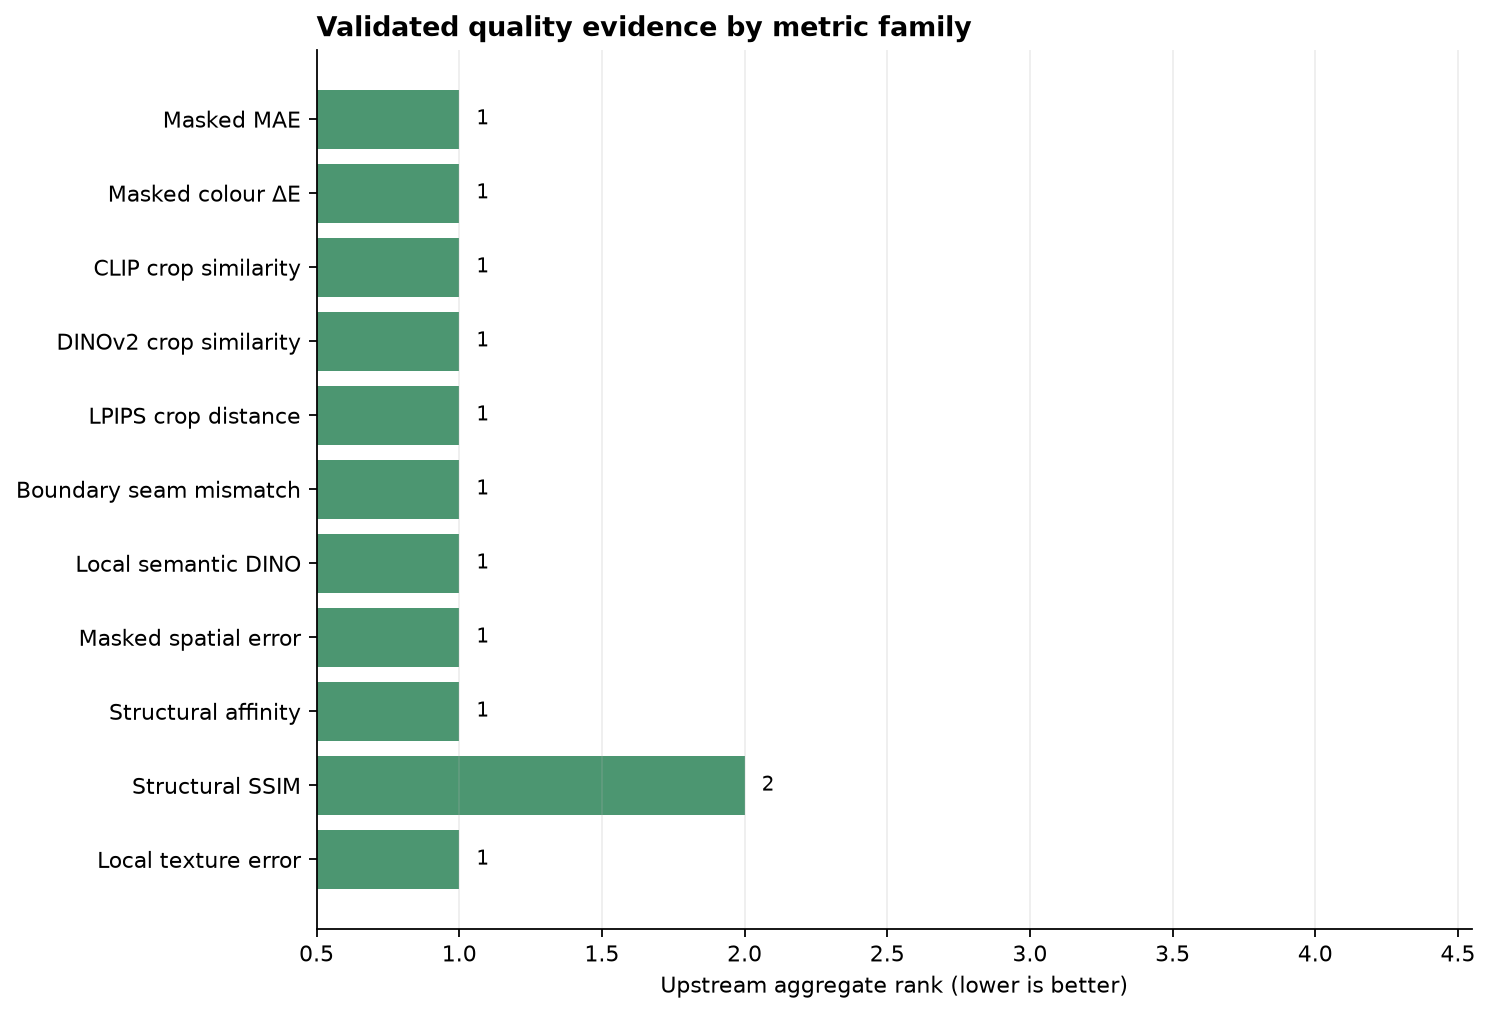

Batch 11 in-memory report assembly complete.
Validation checks: 55
Blocking failures: 0
Warning failures: 0
Reports assembled: 5
Embedded images: 79
Embedded tiles: 374
Canonical files written: 0


In [39]:
VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_11_STAGE
    if "BATCH_11_STAGE" in globals()
    else "batch_11_report_assembly",
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "rendered_report",
)

BATCH_11_STAGE = (
    "batch_11_report_assembly"
)

REPORT_VALIDATION_PARTS = []
render_summary_records = []

for model_id, report_html in (
    MODEL_REPORT_HTML.items()
):
    helper_checks = (
        validate_model_report_html(
            report_html,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

    REPORT_VALIDATION_PARTS.append(
        helper_checks
    )

    asset_assignments = (
        REPORT_ASSET_ASSIGNMENTS[
            model_id
        ]
    )

    section_ids = re.findall(
        r'<section\s+id="([^"]+)"',
        report_html,
        flags=re.IGNORECASE,
    )

    analytical_count = (
        report_html.count(
            'data-report-role="analytical_view"'
        )
    )

    representative_count = (
        report_html.count(
            'data-report-role="representative_panel"'
        )
    )

    atlas_count = (
        report_html.count(
            'data-report-role="visual_atlas"'
        )
    )

    embedded_image_count = (
        report_html.count(
            "<img "
        )
    )

    tile_counts = [
        int(value)
        for value in re.findall(
            r'data-tile-count="(\d+)"',
            report_html,
        )
    ]

    render_summary_records.append(
        {
            "model_id": model_id,
            "section_count": len(
                section_ids
            ),
            "analytical_view_count": (
                analytical_count
            ),
            "representative_panel_count": (
                representative_count
            ),
            "visual_atlas_count": (
                atlas_count
            ),
            "embedded_image_count": (
                embedded_image_count
            ),
            "embedded_tile_count": int(
                sum(
                    tile_counts
                )
            ),
            "assigned_asset_count": int(
                len(
                    asset_assignments
                )
            ),
            "assigned_tile_count": int(
                asset_assignments[
                    "tile_count"
                ].sum()
            ),
            "size_mib": (
                len(
                    report_html.encode(
                        "utf-8"
                    )
                )
                / (1024 ** 2)
            ),
        }
    )

MODEL_REPORT_VALIDATION = pd.concat(
    REPORT_VALIDATION_PARTS,
    ignore_index=True,
)

extend_helper_checks(
    MODEL_REPORT_VALIDATION,
    description_prefix=(
        "In-memory rendered model report"
    ),
)

REPORT_RENDER_SUMMARY = pd.DataFrame(
    render_summary_records
)

expected_asset_counts = {
    model_id: (
        int(
            MODEL_SPECS[
                model_id
            ][
                "analytical_view_count"
            ]
        )
        + int(
            MODEL_SPECS[
                model_id
            ][
                "representative_panel_count"
            ]
        )
        + int(
            MODEL_SPECS[
                model_id
            ][
                "visual_atlas_count"
            ]
        )
    )
    for model_id in MODEL_SPECS
}

observed_asset_counts = (
    REPORT_RENDER_SUMMARY.set_index(
        "model_id"
    )[
        "assigned_asset_count"
    ]
    .astype(int)
    .to_dict()
)

report_keys_ok = (
    set(
        MODEL_REPORT_HTML
    )
    == set(
        MODEL_SPECS
    )
    and set(
        REPORT_SECTION_HTML
    )
    == set(
        MODEL_SPECS
    )
)

section_maps_ok = all(
    list(
        REPORT_SECTION_HTML[
            model_id
        ]
    )
    == REPORT_SECTION_IDS
    and all(
        str(fragment).strip()
        for fragment in (
            REPORT_SECTION_HTML[
                model_id
            ].values()
        )
    )
    for model_id in MODEL_SPECS
)

asset_assignment_ok = bool(
    observed_asset_counts
    == expected_asset_counts
    and all(
        REPORT_ASSET_ASSIGNMENTS[
            model_id
        ][
            "asset_id"
        ].nunique()
        == len(
            REPORT_ASSET_ASSIGNMENTS[
                model_id
            ]
        )
        for model_id in MODEL_SPECS
    )
)

traceability_ready = bool(
    len(
        MOCK_TRACEABILITY
    )
    == EXPECTED[
        "traceability_rows"
    ]
    == 39
    and MOCK_TRACEABILITY[
        "status"
    ].eq("ok").all()
    and MOCK_TRACEABILITY[
        "implementation_status"
    ].isin(
        {
            "preserved",
            "upgraded_additively",
            "approved_deviation",
        }
    ).all()
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="in_memory_report_identity",
    description=(
        "Exactly one in-memory report and section map "
        "exists for every approved model."
    ),
    expected=sorted(
        MODEL_SPECS
    ),
    observed={
        "reports": sorted(
            MODEL_REPORT_HTML
        ),
        "section_maps": sorted(
            REPORT_SECTION_HTML
        ),
    },
    passed=report_keys_ok,
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="report_section_content_contract",
    description=(
        "Every report retains all fifteen approved "
        "non-empty sections in exact order."
    ),
    expected={
        model_id: (
            REPORT_SECTION_IDS
        )
        for model_id in MODEL_SPECS
    },
    observed={
        model_id: list(
            REPORT_SECTION_HTML[
                model_id
            ]
        )
        for model_id in MODEL_SPECS
    },
    passed=section_maps_ok,
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="report_asset_assignment_contract",
    description=(
        "Every analytical figure, representative panel, "
        "and visual atlas is embedded exactly once."
    ),
    expected=expected_asset_counts,
    observed=observed_asset_counts,
    passed=asset_assignment_ok,
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="mock_traceability_ready",
    description=(
        "All 39 approved mock roles remain ready for "
        "final persisted-report traceability."
    ),
    expected={
        "rows": 39,
        "statuses": [
            "preserved",
            "upgraded_additively",
            "approved_deviation",
        ],
    },
    observed={
        "rows": int(
            len(
                MOCK_TRACEABILITY
            )
        ),
        "implementation_statuses": sorted(
            MOCK_TRACEABILITY[
                "implementation_status"
            ].astype(str).unique()
        ),
    },
    passed=traceability_ready,
)

output_files_after_batch_11 = sorted(
    path
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
)

add_check(
    stage=BATCH_11_STAGE,
    check_id="batch_11_has_no_persistence",
    description=(
        "In-memory report assembly creates no "
        "Notebook 31 output files."
    ),
    expected=0,
    observed=len(
        output_files_after_batch_11
    ),
    passed=(
        len(
            output_files_after_batch_11
        )
        == 0
    ),
)

display(
    REPORT_RENDER_SUMMARY
)

BATCH_11_VALIDATION = (
    VALIDATION.to_dataframe()
)

BATCH_11_ROWS = (
    BATCH_11_VALIDATION.loc[
        BATCH_11_VALIDATION[
            "validation_stage"
        ].isin(
            {
                BATCH_11_STAGE,
                "rendered_report",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_11_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_11_ROWS[
            "passed"
        ]
    ).sum()
)

warning_failures = int(
    (
        BATCH_11_ROWS[
            "severity"
        ].eq("warning")
        & ~BATCH_11_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_11_ROWS.loc[
        ~BATCH_11_ROWS[
            "passed"
        ]
    ]
)

preview_style = """
<style>
.n31-preview{font-family:system-ui,sans-serif;line-height:1.5;color:#172033}
.n31-preview .metric-grid{display:grid;grid-template-columns:repeat(3,minmax(180px,1fr));gap:.7rem}
.n31-preview .metric-card{border:1px solid #d9e0ea;padding:.7rem;background:#f8fafc}
.n31-preview .metric-value{display:block;font-size:1.3rem;font-weight:700}
.n31-preview .conclusion{border-left:5px solid #176b4d;background:#edf9f4;padding:.8rem;margin:.8rem 0}
.n31-preview .limitation{border-left:5px solid #955d13;background:#fff6e8;padding:.8rem;margin:.8rem 0}
.n31-preview .report-visual{border:1px solid #d9e0ea;padding:.7rem}
.n31-preview .report-visual img{max-width:100%;height:auto}
.n31-preview table{border-collapse:collapse;width:100%}
.n31-preview th,.n31-preview td{border:1px solid #d9e0ea;padding:.4rem}
</style>
"""

preview_html = (
    preview_style
    + '<div class="n31-preview">'
    + "<h2>Batch 11 report QA — LaMa</h2>"
    + REPORT_SECTION_HTML[
        "lama"
    ][
        "executive-summary"
    ]
    + "<h2>Overall quality section</h2>"
    + REPORT_SECTION_HTML[
        "lama"
    ][
        "overall-quality"
    ]
    + "</div>"
)

display(
    HTML(
        preview_html
    )
)

print("Batch 11 in-memory report assembly complete.")
print(
    "Validation checks: "
    f"{len(BATCH_11_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{warning_failures:,}"
)
print(
    "Reports assembled: "
    f"{len(MODEL_REPORT_HTML):,}"
)
print(
    "Embedded images: "
    f"{int(REPORT_RENDER_SUMMARY['embedded_image_count'].sum()):,}"
)
print(
    "Embedded tiles: "
    f"{int(REPORT_RENDER_SUMMARY['embedded_tile_count'].sum()):,}"
)
print(
    "Canonical files written: "
    f"{len(output_files_after_batch_11):,}"
)

VALIDATION.raise_for_blocking()

## Batch 12 — Persistence, manifests and completion gate

This final batch:

- writes five standalone self-contained HTML model reports;
- builds and writes the normalized five-row report index;
- reloads every report and validates its structure, evidence language, visual density and portability;
- verifies every Notebook 31 roadmap responsibility;
- writes the consolidated validation table;
- registers seven canonical report and validation artifacts;
- writes the completed run manifest;
- reloads all nine canonical files;
- validates artifact and manifest checksums;
- rejects temporary, undeclared, missing or extra files;
- enforces the final zero-blocking and zero-warning completion gate.

Notebook 31 remains a report-only presentation layer and creates no new scientific evidence.

In [40]:
BATCH_12_PERSISTENCE_STAGE = (
    "batch_12_report_persistence"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_12_PERSISTENCE_STAGE,
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "rendered_report",
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    "report_index",
)

GENERATED_AT_UTC = utc_now_iso()

for model_id, report_html in (
    MODEL_REPORT_HTML.items()
):
    atomic_write_text(
        report_html,
        MODEL_REPORT_PATHS[
            model_id
        ],
    )

inventory_path_values = (
    INVENTORY[
        "relative_path"
    ]
    .fillna("")
    .astype(str)
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)

inventory_checksum_lookup = {
    str(relative_path): str(
        checksum
    )
    for relative_path, checksum
    in zip(
        inventory_path_values,
        INVENTORY[
            "hash_value"
        ].fillna("").astype(str),
    )
    if str(relative_path).strip()
    and str(checksum).strip()
}

upstream_run_ids = {
    notebook_id: str(
        manifest.get(
            "run_id",
            "",
        )
    )
    for notebook_id, manifest
    in sorted(
        MANIFESTS.items()
    )
}

report_index_records = []

for model_id in MODEL_SPECS:
    section_evidence = (
        MODEL_EVIDENCE_PACKETS[
            model_id
        ][
            "section_evidence"
        ]
    )

    source_artifact_paths = sorted(
        {
            source_path
            for payload in (
                section_evidence[
                    "source_paths_json"
                ]
            )
            for source_path in json.loads(
                payload
            )
        }
    )

    source_checksums = {
        relative_path: (
            inventory_checksum_lookup.get(
                relative_path,
                "",
            )
        )
        for relative_path
        in source_artifact_paths
    }

    missing_source_checksums = [
        relative_path
        for relative_path, checksum
        in source_checksums.items()
        if not str(checksum).strip()
    ]

    if missing_source_checksums:
        source_checksums.update(
            {
                relative_path: sha256_file(
                    PROJECT_ROOT
                    / relative_path
                )
                for relative_path
                in missing_source_checksums
            }
        )

    representative_candidate_ids = (
        REPRESENTATIVE_SELECTIONS.loc[
            REPRESENTATIVE_SELECTIONS[
                "model_id"
            ].eq(model_id),
            "candidate_id",
        ]
        .astype(str)
        .tolist()
    )

    report_index_records.append(
        build_report_index_row(
            MODEL_REPORT_PATHS[
                model_id
            ],
            project_root=PROJECT_ROOT,
            model_id=model_id,
            representative_candidate_ids=(
                representative_candidate_ids
            ),
            source_artifact_paths=(
                source_artifact_paths
            ),
            source_checksums=(
                source_checksums
            ),
            upstream_run_ids=(
                upstream_run_ids
            ),
            generated_at_utc=(
                GENERATED_AT_UTC
            ),
            config=REPORT_CONFIG,
        )
    )

REPORT_INDEX = pd.DataFrame(
    report_index_records,
    columns=REPORT_INDEX_COLUMNS,
)

report_index_checks = (
    validate_report_index(
        REPORT_INDEX,
        config=REPORT_CONFIG,
    )
)

extend_helper_checks(
    report_index_checks,
    description_prefix=(
        "Persisted report-index contract"
    ),
)

atomic_write_csv(
    REPORT_INDEX,
    OUTPUT_PATHS[
        "report_index"
    ],
)

PERSISTED_REPORT_INDEX = pd.read_csv(
    OUTPUT_PATHS[
        "report_index"
    ],
    keep_default_na=False,
)

PERSISTED_REPORT_HTML = {
    model_id: (
        MODEL_REPORT_PATHS[
            model_id
        ].read_text(
            encoding="utf-8-sig"
        )
    )
    for model_id in MODEL_SPECS
}

persisted_report_check_parts = []

for model_id, report_html in (
    PERSISTED_REPORT_HTML.items()
):
    persisted_report_check_parts.append(
        validate_model_report_html(
            report_html,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

PERSISTED_REPORT_CHECKS = pd.concat(
    persisted_report_check_parts,
    ignore_index=True,
)

extend_helper_checks(
    PERSISTED_REPORT_CHECKS,
    description_prefix=(
        "Persisted standalone model report"
    ),
)

reloaded_report_index_checks = (
    validate_report_index(
        PERSISTED_REPORT_INDEX,
        config=REPORT_CONFIG,
    )
)

reloaded_report_index_failures = int(
    (
        ~reloaded_report_index_checks[
            "passed"
        ].astype(bool)
        & reloaded_report_index_checks[
            "severity"
        ].eq("blocking")
    ).sum()
)

report_roundtrip_failures = [
    model_id
    for model_id in MODEL_SPECS
    if (
        PERSISTED_REPORT_HTML[
            model_id
        ]
        != MODEL_REPORT_HTML[
            model_id
        ]
    )
]

persisted_primary_files = {
    path.resolve()
    for path in (
        *MODEL_REPORT_PATHS.values(),
        OUTPUT_PATHS[
            "report_index"
        ],
    )
    if path.is_file()
}

expected_primary_files = {
    path.resolve()
    for path in (
        *MODEL_REPORT_PATHS.values(),
        OUTPUT_PATHS[
            "report_index"
        ],
    )
}

temporary_files_after_reports = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in OUTPUT_ROOT.rglob("*")
    if (
        path.is_file()
        and (
            ".tmp"
            in path.name.casefold()
            or ".building"
            in path.name.casefold()
            or path.suffix.casefold()
            in {
                ".temp",
                ".part",
                ".partial",
            }
            or path.name.startswith(
                "."
            )
        )
    )
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="report_html_roundtrip",
    description=(
        "Every persisted HTML report exactly matches "
        "its validated in-memory document."
    ),
    expected=[],
    observed=(
        report_roundtrip_failures
    ),
    passed=(
        len(
            report_roundtrip_failures
        )
        == 0
    ),
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="reloaded_report_index_contract",
    description=(
        "The reloaded five-row report index retains "
        "its complete canonical schema and density."
    ),
    expected={
        "rows": 5,
        "blocking_failures": 0,
    },
    observed={
        "rows": int(
            len(
                PERSISTED_REPORT_INDEX
            )
        ),
        "blocking_failures": (
            reloaded_report_index_failures
        ),
    },
    passed=bool(
        len(
            PERSISTED_REPORT_INDEX
        )
        == 5
        and reloaded_report_index_failures
        == 0
    ),
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="primary_persisted_file_set",
    description=(
        "The five reports and report index are the "
        "exact six primary persisted files at this stage."
    ),
    expected=sorted(
        path.relative_to(
            PROJECT_ROOT
        ).as_posix()
        for path
        in expected_primary_files
    ),
    observed=sorted(
        path.relative_to(
            PROJECT_ROOT
        ).as_posix()
        for path
        in persisted_primary_files
    ),
    passed=(
        persisted_primary_files
        == expected_primary_files
    ),
)

add_check(
    stage=BATCH_12_PERSISTENCE_STAGE,
    check_id="report_persistence_temporary_files",
    description=(
        "Report persistence leaves no temporary or "
        "partially written files."
    ),
    expected=[],
    observed=(
        temporary_files_after_reports
    ),
    passed=(
        len(
            temporary_files_after_reports
        )
        == 0
    ),
)

display(
    PERSISTED_REPORT_INDEX[
        [
            "model_id",
            "evaluation_status",
            "size_bytes",
            "section_count",
            "embedded_image_count",
            "embedded_tile_count",
            "analytical_view_count",
            "representative_panel_count",
            "visual_atlas_count",
            "self_contained",
            "status",
        ]
    ]
)

BATCH_12_PERSISTENCE_ROWS = (
    VALIDATION.to_dataframe()
)

BATCH_12_PERSISTENCE_ROWS = (
    BATCH_12_PERSISTENCE_ROWS.loc[
        BATCH_12_PERSISTENCE_ROWS[
            "validation_stage"
        ].isin(
            {
                BATCH_12_PERSISTENCE_STAGE,
                "rendered_report",
                "report_index",
            }
        )
    ]
    .reset_index(drop=True)
)

blocking_failures = int(
    (
        BATCH_12_PERSISTENCE_ROWS[
            "severity"
        ].eq("blocking")
        & ~BATCH_12_PERSISTENCE_ROWS[
            "passed"
        ]
    ).sum()
)

warning_failures = int(
    (
        BATCH_12_PERSISTENCE_ROWS[
            "severity"
        ].eq("warning")
        & ~BATCH_12_PERSISTENCE_ROWS[
            "passed"
        ]
    ).sum()
)

display(
    BATCH_12_PERSISTENCE_ROWS.loc[
        ~BATCH_12_PERSISTENCE_ROWS[
            "passed"
        ]
    ]
)

print("Reports and report index persisted and reloaded.")
print(
    "Validation checks: "
    f"{len(BATCH_12_PERSISTENCE_ROWS):,}"
)
print(
    "Blocking failures: "
    f"{blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{warning_failures:,}"
)
print(
    "Reports: "
    f"{len(PERSISTED_REPORT_HTML):,}"
)
print(
    "Report-index rows: "
    f"{len(PERSISTED_REPORT_INDEX):,}"
)

VALIDATION.raise_for_blocking()

,model_id,evaluation_status,size_bytes,section_count,embedded_image_count,embedded_tile_count,analytical_view_count,representative_panel_count,visual_atlas_count,self_contained,status
0,opencv_telea,fully_evaluated,2533008,15,16,76,6,8,2,True,ok
1,lama,fully_evaluated,2634126,15,16,76,6,8,2,True,ok
2,hint_places2,fully_evaluated,2486646,15,16,74,6,8,2,True,ok
3,stable_diffusion_inpainting,fully_evaluated,3296483,15,19,92,7,10,2,True,ok
4,sdxl_inpainting,partial_evaluation,2012337,15,12,56,4,6,2,True,ok


,validation_stage,check_id,check_description,severity,expected,observed,passed,details


Reports and report index persisted and reloaded.
Validation checks: 61
Blocking failures: 0
Warning failures: 0
Reports: 5
Report-index rows: 5


In [41]:
BATCH_12_FINAL_STAGE = (
    "batch_12_final_traceability"
)

VALIDATION = reset_validation_stage(
    VALIDATION,
    BATCH_12_FINAL_STAGE,
)

roadmap_records = []


def add_roadmap_record(
    responsibility_id: str,
    responsibility: str,
    *,
    expected,
    observed,
    passed: bool,
    evidence: str,
) -> None:
    """Register one Notebook 31 roadmap responsibility."""
    roadmap_records.append(
        {
            "responsibility_id": (
                responsibility_id
            ),
            "responsibility": (
                responsibility
            ),
            "expected": expected,
            "observed": observed,
            "passed": bool(
                passed
            ),
            "evidence": evidence,
        }
    )


full_scope_model_ids = [
    "opencv_telea",
    "lama",
    "hint_places2",
    "stable_diffusion_inpainting",
]

deterministic_model_ids = [
    "opencv_telea",
    "lama",
    "hint_places2",
]


method_identity_model_count = int(
    REPORT_CONCLUSION_REGISTRY.loc[
        REPORT_CONCLUSION_REGISTRY[
            "section_id"
        ].eq(
            "method-identity"
        ),
        "model_id",
    ].nunique()
)

quality_row_count = int(
    sum(
        len(
            analytical_rows(
                model_id,
                "overall_quality",
            )
        )
        for model_id in MODEL_SPECS
    )
)

full_scope_damage_row_count = int(
    sum(
        len(
            analytical_rows(
                model_id,
                "damage_size",
            )
        )
        for model_id
        in full_scope_model_ids
    )
)

full_scope_mask_row_count = int(
    sum(
        len(
            analytical_rows(
                model_id,
                "mask_robustness",
            )
        )
        for model_id
        in full_scope_model_ids
    )
)

full_scope_degradation_row_count = int(
    sum(
        len(
            analytical_rows(
                model_id,
                "synthetic_degradation",
            )
        )
        for model_id
        in full_scope_model_ids
    )
)

sdxl_degradation_row_count = int(
    len(
        analytical_rows(
            "sdxl_inpainting",
            "synthetic_degradation",
        )
    )
)

local_row_count = int(
    sum(
        len(
            analytical_rows(
                model_id,
                "texture_colour_seam",
            )
        )
        for model_id in MODEL_SPECS
    )
)

semantic_structural_row_count = int(
    sum(
        len(
            analytical_rows(
                model_id,
                "semantic_structural",
            )
        )
        for model_id in MODEL_SPECS
    )
)

stable_diffusion_uncertainty_groups = int(
    REPORT_NUMERICAL_SUMMARY.loc[
        REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        ),
        "uncertainty_group_count",
    ].iloc[0]
)

deterministic_uncertainty_statuses = {
    model_id: applicability_lookup[
        (
            model_id,
            "repeated_seed_uncertainty",
        )
    ]
    for model_id
    in deterministic_model_ids
}

sdxl_uncertainty_status = (
    applicability_lookup[
        (
            "sdxl_inpainting",
            "repeated_seed_uncertainty",
        )
    ]
)

representative_panel_count = int(
    len(
        REPRESENTATIVE_PANEL_ASSETS
    )
)

visual_atlas_count = int(
    len(
        VISUAL_ATLAS_ASSETS
    )
)

embedded_tile_count = int(
    PERSISTED_REPORT_INDEX[
        "embedded_tile_count"
    ].sum()
)

flag_model_count = int(
    REPORT_NUMERICAL_SUMMARY.loc[
        REPORT_NUMERICAL_SUMMARY[
            "flag_catalog_candidate_count"
        ].gt(0),
        "model_id",
    ].nunique()
)

observed_compute_model_count = int(
    COMPUTE_SCALABILITY.loc[
        COMPUTE_SCALABILITY[
            "scenario_id"
        ].astype(str).eq(
            "observed_overall_all"
        )
        & COMPUTE_SCALABILITY[
            "record_type"
        ].astype(str).eq(
            "observed"
        )
        & COMPUTE_SCALABILITY[
            "status"
        ].astype(str).eq("ok"),
        "model_id",
    ].nunique()
)

applicable_projection_mask = (
    (
        COMPUTE_SCALABILITY[
            "model_id"
        ].astype(str).isin(
            full_scope_model_ids
        )
        & COMPUTE_SCALABILITY[
            "scenario_id"
        ].astype(str).eq(
            "projected_600_current_design_mix"
        )
    )
    | (
        COMPUTE_SCALABILITY[
            "model_id"
        ].astype(str).eq(
            "sdxl_inpainting"
        )
        & COMPUTE_SCALABILITY[
            "scenario_id"
        ].astype(str).eq(
            "projected_300_sdxl_full_design"
        )
    )
)

applicable_projection_model_count = int(
    COMPUTE_SCALABILITY.loc[
        applicable_projection_mask
        & COMPUTE_SCALABILITY[
            "record_type"
        ].astype(str).eq(
            "projection"
        )
        & COMPUTE_SCALABILITY[
            "status"
        ].astype(str).eq("ok"),
        "model_id",
    ].nunique()
)

decision_limit_model_count = int(
    REPORT_CONCLUSION_REGISTRY.loc[
        REPORT_CONCLUSION_REGISTRY[
            "section_id"
        ].isin(
            {
                "decision-support",
                "limitations",
            }
        )
    ]
    .groupby(
        "model_id"
    )[
        "section_id"
    ]
    .nunique()
    .eq(2)
    .sum()
)

external_image_dependencies = int(
    sum(
        report_html.count(
            'src="../'
        )
        + report_html.count(
            'src="outputs/'
        )
        for report_html
        in PERSISTED_REPORT_HTML.values()
    )
)


add_roadmap_record(
    "five_parameterized_reports",
    "One standalone report per approved model",
    expected=5,
    observed=len(
        PERSISTED_REPORT_HTML
    ),
    passed=(
        len(
            PERSISTED_REPORT_HTML
        )
        == 5
    ),
    evidence=(
        "Five self-contained HTML model reports, "
        "including the full-scope HINT report and "
        "bounded SDXL report."
    ),
)

add_roadmap_record(
    "method_card_summary",
    (
        "Method identity, role, strengths, "
        "weaknesses and uses"
    ),
    expected=5,
    observed=(
        method_identity_model_count
    ),
    passed=(
        method_identity_model_count
        == 5
    ),
    evidence=(
        "Notebook 30 model cards and the "
        "method-identity section of every report."
    ),
)

add_roadmap_record(
    "coverage_and_applicability",
    (
        "Eligible scope and model-specific "
        "applicability"
    ),
    expected=35,
    observed=len(
        APPLICABILITY_MATRIX
    ),
    passed=bool(
        len(
            APPLICABILITY_MATRIX
        )
        == 35
        and APPLICABILITY_MATRIX[
            "status"
        ].eq("ok").all()
    ),
    evidence=(
        "Seven applicability components across "
        "five evaluated methods."
    ),
)

add_roadmap_record(
    "quality_evidence",
    (
        "Classical, LPIPS, feature, spatial and "
        "comparative quality evidence"
    ),
    expected=55,
    observed=quality_row_count,
    passed=bool(
        quality_row_count
        == 55
        and all(
            len(
                analytical_rows(
                    model_id,
                    "overall_quality",
                )
            )
            == 11
            for model_id in MODEL_SPECS
        )
    ),
    evidence=(
        "Eleven transparent quality anchors for "
        "each of five model reports."
    ),
)

add_roadmap_record(
    "damage_and_robustness",
    (
        "Damage size, mask robustness and "
        "synthetic-degradation evidence"
    ),
    expected={
        "full_scope_damage_rows": 44,
        "full_scope_mask_rows": 44,
        "full_scope_degradation_rows": 132,
        "sdxl_degradation_rows": 11,
    },
    observed={
        "full_scope_damage_rows": (
            full_scope_damage_row_count
        ),
        "full_scope_mask_rows": (
            full_scope_mask_row_count
        ),
        "full_scope_degradation_rows": (
            full_scope_degradation_row_count
        ),
        "sdxl_degradation_rows": (
            sdxl_degradation_row_count
        ),
    },
    passed=bool(
        full_scope_damage_row_count
        == 44
        and full_scope_mask_row_count
        == 44
        and full_scope_degradation_row_count
        == 132
        and sdxl_degradation_row_count
        == 11
    ),
    evidence=(
        "Notebook 23–25 controlled-300 "
        "analytical views."
    ),
)

add_roadmap_record(
    "local_semantic_structural",
    (
        "Texture, colour, seam, semantic and "
        "structural evidence"
    ),
    expected={
        "local_rows": 15,
        "semantic_structural_rows": 15,
    },
    observed={
        "local_rows": (
            local_row_count
        ),
        "semantic_structural_rows": (
            semantic_structural_row_count
        ),
    },
    passed=bool(
        local_row_count
        == 15
        and semantic_structural_row_count
        == 15
    ),
    evidence=(
        "Notebook 17 and Notebook 20 evidence "
        "integrated through Notebook 21."
    ),
)

add_roadmap_record(
    "uncertainty_and_prompt_scope",
    (
        "Diffusion uncertainty and prompt "
        "applicability"
    ),
    expected={
        "stable_diffusion_groups": 1025,
        "deterministic_models": (
            "not_applicable"
        ),
        "sdxl": (
            "insufficient_seed_coverage"
        ),
    },
    observed={
        "stable_diffusion_groups": (
            stable_diffusion_uncertainty_groups
        ),
        "deterministic_models": (
            deterministic_uncertainty_statuses
        ),
        "sdxl": (
            sdxl_uncertainty_status
        ),
    },
    passed=bool(
        stable_diffusion_uncertainty_groups
        == 1025
        and all(
            status
            == (
                "not_applicable_"
                "deterministic_method"
            )
            for status
            in deterministic_uncertainty_statuses.values()
        )
        and sdxl_uncertainty_status
        == (
            "not_applicable_"
            "insufficient_seed_coverage"
        )
    ),
    evidence=(
        "780 canonical and 245 damage-size "
        "Stable Diffusion uncertainty groups."
    ),
)

add_roadmap_record(
    "representative_and_explanation_evidence",
    (
        "Representative successes, failures, "
        "maps and atlases"
    ),
    expected={
        "representative_panels": 40,
        "visual_atlases": 10,
        "embedded_tiles": 374,
    },
    observed={
        "representative_panels": (
            representative_panel_count
        ),
        "visual_atlases": (
            visual_atlas_count
        ),
        "embedded_tiles": (
            embedded_tile_count
        ),
    },
    passed=bool(
        representative_panel_count
        == 40
        and visual_atlas_count
        == 10
        and embedded_tile_count
        == 374
    ),
    evidence=(
        "Deterministic five-model report "
        "selections and embedded diagnostics."
    ),
)

add_roadmap_record(
    "failure_taxonomy_and_flags",
    (
        "Failure taxonomy and triggered "
        "trustworthiness flags"
    ),
    expected=5,
    observed=flag_model_count,
    passed=bool(
        flag_model_count
        == 5
        and REPORT_NUMERICAL_SUMMARY[
            "triggered_flag_candidate_count"
        ].gt(0).all()
    ),
    evidence=(
        "Notebook 27 failure-taxonomy and "
        "trustworthiness evidence."
    ),
)

add_roadmap_record(
    "compute_and_scalability",
    (
        "Observed compute and transparent "
        "scaling projections"
    ),
    expected={
        "models": 5,
        "observed_models": 5,
        "applicable_projection_models": 5,
    },
    observed={
        "models": int(
            REPORT_NUMERICAL_SUMMARY[
                "model_id"
            ].nunique()
        ),
        "observed_models": (
            observed_compute_model_count
        ),
        "applicable_projection_models": (
            applicable_projection_model_count
        ),
    },
    passed=bool(
        REPORT_NUMERICAL_SUMMARY[
            "model_id"
        ].nunique()
        == 5
        and observed_compute_model_count
        == 5
        and applicable_projection_model_count
        == 5
    ),
    evidence=(
        "Notebook 30 observed runtime records, "
        "current-design scaling and bounded-to-full "
        "SDXL projection."
    ),
)

add_roadmap_record(
    "limitations_and_decision_support",
    (
        "Known limitations and bounded "
        "human-review actions"
    ),
    expected=5,
    observed=(
        decision_limit_model_count
    ),
    passed=(
        decision_limit_model_count
        == 5
    ),
    evidence=(
        "Model-card limitations and paired "
        "decision-support and limitation sections."
    ),
)

add_roadmap_record(
    "mock_fidelity_and_portability",
    (
        "Approved mock fidelity and standalone "
        "portability"
    ),
    expected={
        "traceability_rows": 39,
        "external_dependencies": 0,
        "reports": 5,
    },
    observed={
        "traceability_rows": int(
            len(
                MOCK_TRACEABILITY
            )
        ),
        "external_dependencies": (
            external_image_dependencies
        ),
        "reports": int(
            len(
                PERSISTED_REPORT_HTML
            )
        ),
    },
    passed=bool(
        len(
            MOCK_TRACEABILITY
        )
        == 39
        and external_image_dependencies
        == 0
        and len(
            PERSISTED_REPORT_HTML
        )
        == 5
        and all(
            'src="data:image/'
            in report_html
            for report_html
            in PERSISTED_REPORT_HTML.values()
        )
    ),
    evidence=(
        "Mock traceability and self-contained "
        "five-report HTML validation."
    ),
)

add_roadmap_record(
    "report_only_evidence_policy",
    (
        "No new scientific evidence, ranking, "
        "metric or statistical test"
    ),
    expected=False,
    observed=(
        EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
    ),
    passed=(
        EVIDENCE_POLICY[
            "creates_new_scientific_evidence"
        ]
        is False
    ),
    evidence=(
        "Presentation-only filtering, formatting "
        "and report assembly."
    ),
)


ROADMAP_TRACEABILITY = pd.DataFrame(
    roadmap_records
)

roadmap_failures = int(
    (
        ~ROADMAP_TRACEABILITY[
            "passed"
        ].astype(bool)
    ).sum()
)

add_check(
    stage=BATCH_12_FINAL_STAGE,
    check_id=(
        "roadmap_responsibility_completion"
    ),
    description=(
        "Every Notebook 31 roadmap responsibility "
        "has explicit passing evidence."
    ),
    expected=0,
    observed=roadmap_failures,
    passed=(
        roadmap_failures
        == 0
    ),
    details={
        "failures": (
            ROADMAP_TRACEABILITY.loc[
                ~ROADMAP_TRACEABILITY[
                    "passed"
                ]
            ].to_dict("records")
        )
    },
)

invalid_mock_status_count = int(
    (
        ~MOCK_TRACEABILITY[
            "implementation_status"
        ].isin(
            {
                "preserved",
                "upgraded_additively",
                "approved_deviation",
            }
        )
    ).sum()
)

unexplained_deviation_count = int(
    (
        MOCK_TRACEABILITY[
            "implementation_status"
        ].eq(
            "approved_deviation"
        )
        & MOCK_TRACEABILITY[
            "deviation_reason"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    ).sum()
)

add_check(
    stage=BATCH_12_FINAL_STAGE,
    check_id=(
        "mock_traceability_final_contract"
    ),
    description=(
        "All 39 approved mock roles remain "
        "represented without an unexplained "
        "structural deviation."
    ),
    expected={
        "rows": 39,
        "invalid_statuses": 0,
        "unexplained_deviations": 0,
    },
    observed={
        "rows": int(
            len(
                MOCK_TRACEABILITY
            )
        ),
        "invalid_statuses": (
            invalid_mock_status_count
        ),
        "unexplained_deviations": (
            unexplained_deviation_count
        ),
    },
    passed=bool(
        len(
            MOCK_TRACEABILITY
        )
        == 39
        and invalid_mock_status_count
        == 0
        and unexplained_deviation_count
        == 0
    ),
)

pre_manifest_validation = (
    VALIDATION.to_dataframe()
)

pre_manifest_blocking_failures = int(
    (
        pre_manifest_validation[
            "severity"
        ].eq("blocking")
        & ~pre_manifest_validation[
            "passed"
        ]
    ).sum()
)

pre_manifest_warning_failures = int(
    (
        pre_manifest_validation[
            "severity"
        ].eq("warning")
        & ~pre_manifest_validation[
            "passed"
        ]
    ).sum()
)

add_check(
    stage=BATCH_12_FINAL_STAGE,
    check_id="pre_manifest_validation_gate",
    description=(
        "All scientific, report, portability, and "
        "traceability checks pass before manifest writing."
    ),
    expected={
        "blocking_failures": 0,
        "warning_failures": 0,
    },
    observed={
        "blocking_failures": (
            pre_manifest_blocking_failures
        ),
        "warning_failures": (
            pre_manifest_warning_failures
        ),
    },
    passed=bool(
        pre_manifest_blocking_failures
        == 0
        and pre_manifest_warning_failures
        == 0
    ),
)

VALIDATION.raise_for_blocking()

FINAL_VALIDATION = (
    VALIDATION.to_dataframe()
)

atomic_write_csv(
    FINAL_VALIDATION,
    OUTPUT_PATHS[
        "validation"
    ],
)

artifact_record_payloads = []

for model_id, report_path in (
    MODEL_REPORT_PATHS.items()
):
    artifact_record_payloads.append(
        build_artifact_record(
            artifact_key=(
                f"model_report_{model_id}"
            ),
            producer_notebook=(
                SETTINGS[
                    "notebook_id"
                ]
            ),
            path=report_path,
            artifact_type=(
                "standalone_html_report"
            ),
            artifact_role=(
                "model_specific_evaluation_report"
            ),
            schema_version=(
                "model_report_html.v1"
            ),
            dataset_scope=(
                SETTINGS[
                    "dataset_scope"
                ]
            ),
            project_root=(
                PROJECT_ROOT
            ),
        )
    )

artifact_record_payloads.extend(
    [
        build_artifact_record(
            artifact_key="report_index",
            producer_notebook=(
                SETTINGS[
                    "notebook_id"
                ]
            ),
            path=OUTPUT_PATHS[
                "report_index"
            ],
            artifact_type="csv",
            artifact_role=(
                "model_report_registry"
            ),
            schema_version=(
                REPORT_INDEX_SCHEMA_VERSION
            ),
            dataset_scope=(
                SETTINGS[
                    "dataset_scope"
                ]
            ),
            row_count=len(
                PERSISTED_REPORT_INDEX
            ),
            project_root=(
                PROJECT_ROOT
            ),
        ),
        build_artifact_record(
            artifact_key="validation",
            producer_notebook=(
                SETTINGS[
                    "notebook_id"
                ]
            ),
            path=OUTPUT_PATHS[
                "validation"
            ],
            artifact_type="csv",
            artifact_role=(
                "consolidated_validation_evidence"
            ),
            schema_version=(
                "validation_checks.v1"
            ),
            dataset_scope=(
                SETTINGS[
                    "dataset_scope"
                ]
            ),
            row_count=len(
                FINAL_VALIDATION
            ),
            project_root=(
                PROJECT_ROOT
            ),
        ),
    ]
)

FINAL_ARTIFACT_RECORDS = (
    artifact_records_dataframe(
        artifact_record_payloads
    )
)

atomic_write_csv(
    FINAL_ARTIFACT_RECORDS,
    OUTPUT_PATHS[
        "artifacts"
    ],
)

manifest_input_records = []

for input_key, input_path in (
    sorted(
        INPUT_PATHS.items()
    )
):
    relative_path = (
        input_path.relative_to(
            PROJECT_ROOT
        ).as_posix()
    )

    checksum = (
        inventory_checksum_lookup.get(
            relative_path,
            "",
        )
    )

    if not checksum:
        checksum = sha256_file(
            input_path
        )

    manifest_input_records.append(
        {
            "input_key": input_key,
            "relative_path": (
                relative_path
            ),
            "checksum": checksum,
        }
    )

manifest_output_records = [
    {
        "artifact_key": (
            f"model_report_{model_id}"
        ),
        "relative_path": (
            MODEL_REPORT_PATHS[
                model_id
            ]
            .relative_to(
                PROJECT_ROOT
            )
            .as_posix()
        ),
        "artifact_type": (
            "standalone_html_report"
        ),
    }
    for model_id in MODEL_SPECS
]

manifest_output_records.extend(
    [
        {
            "artifact_key": (
                "report_index"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "report_index"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "csv",
        },
        {
            "artifact_key": (
                "run_manifest"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "run_manifest"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "json",
        },
        {
            "artifact_key": (
                "artifacts"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "artifacts"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "csv",
        },
        {
            "artifact_key": (
                "validation"
            ),
            "relative_path": (
                OUTPUT_PATHS[
                    "validation"
                ]
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "artifact_type": "csv",
        },
    ]
)

configuration_paths = [
    CONFIG_PATH,
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_paths,
        PROJECT_ROOT,
    )
)

RUN_COMPLETED_AT_UTC = utc_now_iso()

observed_counts = {
    "model_count": int(
        len(
            MODEL_SPECS
        )
    ),
    "report_count": int(
        len(
            PERSISTED_REPORT_HTML
        )
    ),
    "report_index_rows": int(
        len(
            PERSISTED_REPORT_INDEX
        )
    ),
    "section_rows": int(
        len(
            REPORT_CONCLUSION_REGISTRY
        )
    ),
    "mock_traceability_rows": int(
        len(
            MOCK_TRACEABILITY
        )
    ),
    "analytical_views": int(
        len(
            ANALYTICAL_VIEW_ASSETS
        )
    ),
    "representative_panels": int(
        len(
            REPRESENTATIVE_PANEL_ASSETS
        )
    ),
    "visual_atlases": int(
        len(
            VISUAL_ATLAS_ASSETS
        )
    ),
    "embedded_images": int(
        PERSISTED_REPORT_INDEX[
            "embedded_image_count"
        ].sum()
    ),
    "embedded_tiles": int(
        PERSISTED_REPORT_INDEX[
            "embedded_tile_count"
        ].sum()
    ),
    "artifact_records": int(
        len(
            FINAL_ARTIFACT_RECORDS
        )
    ),
    "validation_rows": int(
        len(
            FINAL_VALIDATION
        )
    ),
    "roadmap_responsibilities": int(
        len(
            ROADMAP_TRACEABILITY
        )
    ),
    "physical_output_files": int(
        EXPECTED[
            "physical_output_files"
        ]
    ),
}

FINAL_RUN_MANIFEST = build_run_manifest(
    notebook_id=SETTINGS[
        "notebook_id"
    ],
    notebook_name=SETTINGS[
        "notebook_stem"
    ],
    origin=(
        "Consolidates Existing Notebooks "
        "13, 19, and 26"
    ),
    run_status="completed",
    started_at_utc=(
        RUN_STARTED_AT_UTC
    ),
    completed_at_utc=(
        RUN_COMPLETED_AT_UTC
    ),
    inventory_run_id=str(
        INVENTORY_RUN[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": (
            SETTINGS[
                "dataset_id"
            ]
        ),
        "dataset_version": (
            SETTINGS[
                "dataset_version"
            ]
        ),
        "dataset_scope": (
            SETTINGS[
                "dataset_scope"
            ]
        ),
        "configuration_version": (
            REPORT_CONFIG[
                "config_version"
            ]
        ),
        "configuration_schema_version": (
            CONFIG_SCHEMA_VERSION
        ),
        "report_index_schema_version": (
            REPORT_INDEX_SCHEMA_VERSION
        ),
        "mock_traceability_schema_version": (
            TRACEABILITY_SCHEMA_VERSION
        ),
        "upstream_run_ids": (
            upstream_run_ids
        ),
    },
    configuration_paths=[
        path.relative_to(
            PROJECT_ROOT
        ).as_posix()
        for path in configuration_paths
    ],
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions={
        "model_report_generation": (
            MODULE_VERSION
        ),
        "report_index_schema": (
            REPORT_INDEX_SCHEMA_VERSION
        ),
        "selection_schema": (
            SELECTION_SCHEMA_VERSION
        ),
        "traceability_schema": (
            TRACEABILITY_SCHEMA_VERSION
        ),
    },
    inputs=manifest_input_records,
    outputs=manifest_output_records,
    expected_counts=dict(
        EXPECTED
    ),
    observed_counts=(
        observed_counts
    ),
    validation_summary=(
        VALIDATION.summary()
    ),
    known_limitations=list(
        SETTINGS[
            "known_limitations"
        ]
    ),
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "matplotlib",
        "Pillow",
        "PyYAML",
    ),
    hardware={
        "analysis_mode": (
            "presentation_only_model_report_generation"
        ),
        "restoration_inference_performed": (
            False
        ),
        "new_metric_computation_performed": (
            False
        ),
        "new_statistical_test_performed": (
            False
        ),
        "self_contained_html": (
            True
        ),
    },
)

FINAL_RUN_MANIFEST.update(
    {
        "validation_status": (
            "passed"
        ),
        "refactor_status": (
            "refactored"
        ),
        "completion_gate_passed": (
            True
        ),
        "creates_new_scientific_evidence": (
            False
        ),
        "output_checksums": {
            str(
                record[
                    "artifact_key"
                ]
            ): str(
                record[
                    "checksum"
                ]
            )
            for record in (
                FINAL_ARTIFACT_RECORDS
                .to_dict("records")
            )
        },
        "artifact_manifest_checksum": (
            sha256_file(
                OUTPUT_PATHS[
                    "artifacts"
                ]
            )
        ),
        "roadmap_requirement_count": int(
            len(
                ROADMAP_TRACEABILITY
            )
        ),
        "roadmap_traceability_failures": (
            roadmap_failures
        ),
        "report_contract": {
            "format": (
                "self_contained_html"
            ),
            "report_count": int(
                len(
                    PERSISTED_REPORT_HTML
                )
            ),
            "sections_per_report": int(
                len(
                    REPORT_SECTION_IDS
                )
            ),
            "mock_traceability_rows": int(
                len(
                    MOCK_TRACEABILITY
                )
            ),
            "embedded_image_count": int(
                PERSISTED_REPORT_INDEX[
                    "embedded_image_count"
                ].sum()
            ),
            "embedded_tile_count": int(
                PERSISTED_REPORT_INDEX[
                    "embedded_tile_count"
                ].sum()
            ),
            "external_image_dependencies": (
                0
            ),
        },
    }
)

atomic_write_text(
    json.dumps(
        FINAL_RUN_MANIFEST,
        indent=2,
        ensure_ascii=False,
    )
    + "\n",
    OUTPUT_PATHS[
        "run_manifest"
    ],
)

display(
    ROADMAP_TRACEABILITY
)

display(
    FINAL_ARTIFACT_RECORDS
)

print("Final validation, artifacts, and run manifest written.")
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION):,}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_RECORDS):,}"
)
print(
    "Roadmap responsibilities: "
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Roadmap failures: "
    f"{roadmap_failures:,}"
)

,responsibility_id,responsibility,expected,observed,passed,evidence
0,five_parameterized_reports,One standalone report per approved model,5,5,True,"Five self-contained HTML model reports, including the full-scope HINT report and bounded SDXL report."
1,method_card_summary,"Method identity, role, strengths, weaknesses and uses",5,5,True,Notebook 30 model cards and the method-identity section of every report.
2,coverage_and_applicability,Eligible scope and model-specific applicability,35,35,True,Seven applicability components across five evaluated methods.
3,quality_evidence,"Classical, LPIPS, feature, spatial and comparative quality evidence",55,55,True,Eleven transparent quality anchors for each of five model reports.
4,damage_and_robustness,"Damage size, mask robustness and synthetic-degradation evidence","{'full_scope_damage_rows': 44, 'full_scope_mask_rows': 44, 'full_scope_degradation_rows': 132, 'sdxl_degradation_rows': 11}","{'full_scope_damage_rows': 44, 'full_scope_mask_rows': 44, 'full_scope_degradation_rows': 132, 'sdxl_degradation_rows': 11}",True,Notebook 23–25 controlled-300 analytical views.
5,local_semantic_structural,"Texture, colour, seam, semantic and structural evidence","{'local_rows': 15, 'semantic_structural_rows': 15}","{'local_rows': 15, 'semantic_structural_rows': 15}",True,Notebook 17 and Notebook 20 evidence integrated through Notebook 21.
6,uncertainty_and_prompt_scope,Diffusion uncertainty and prompt applicability,"{'stable_diffusion_groups': 1025, 'deterministic_models': 'not_applicable', 'sdxl': 'insufficient_seed_coverage'}","{'stable_diffusion_groups': 1025, 'deterministic_models': {'opencv_telea': 'not_applicable_deterministic_method', 'lama': 'not_applicable_deterministic_method', 'hint_places2':...",True,780 canonical and 245 damage-size Stable Diffusion uncertainty groups.
7,representative_and_explanation_evidence,"Representative successes, failures, maps and atlases","{'representative_panels': 40, 'visual_atlases': 10, 'embedded_tiles': 374}","{'representative_panels': 40, 'visual_atlases': 10, 'embedded_tiles': 374}",True,Deterministic five-model report selections and embedded diagnostics.
8,failure_taxonomy_and_flags,Failure taxonomy and triggered trustworthiness flags,5,5,True,Notebook 27 failure-taxonomy and trustworthiness evidence.
9,compute_and_scalability,Observed compute and transparent scaling projections,"{'models': 5, 'observed_models': 5, 'applicable_projection_models': 5}","{'models': 5, 'observed_models': 5, 'applicable_projection_models': 5}",True,"Notebook 30 observed runtime records, current-design scaling and bounded-to-full SDXL projection."


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_0778a711ea9e656271ff,model_report_opencv_telea,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/opencv_telea.html,html,controlled_300,,model_report_html.v1,,1,2533008,3049da7e1a3233826f86727526610cdeff699331e09cb5addaa89e28b85a9624,passed
1,artifact_3915e026d0fa6227890f,model_report_lama,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/lama.html,html,controlled_300,,model_report_html.v1,,1,2634126,0ee00e76a6406effca6366a1d1e341c9a2b9be19065f7001b4f3a7af574904e9,passed
2,artifact_b7dbd166eb45040e0ca9,model_report_hint_places2,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/hint_places2.html,html,controlled_300,,model_report_html.v1,,1,2486646,c5976cbd1c827bb5c0b01344ccc584db640603160adc3996963b68607c4aeb51,passed
3,artifact_328a1eb9478d067a591c,model_report_stable_diffusion_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,html,controlled_300,,model_report_html.v1,,1,3296483,32a495902552443196ac5a8029832a099c1c41d4f18231ca6dfa7c262bd3b7d9,passed
4,artifact_99e5eda7f71d0dd94622,model_report_sdxl_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/sdxl_inpainting.html,html,controlled_300,,model_report_html.v1,,1,2012337,8470561ed70de0ab6b54f2a6a3246036bd42a8cf412df5e6ce3a39844504954b,passed
5,artifact_9e93a94124f687777179,report_index,31,csv,model_report_registry,outputs/31_model_report_generation/data/report_index.csv,csv,controlled_300,,model_report_index.v1,5,1,79307,204d21bd07c1f11668154a2f19724b295d6264265beff67761ceb6d6de90d887,passed
6,artifact_659278384e39f0b98ba6,validation,31,csv,consolidated_validation_evidence,outputs/31_model_report_generation/validation/checks.csv,csv,controlled_300,,validation_checks.v1,346,1,116210,2d60e6649637c6028015e9b94acb927edc20ea832a28ba2a387d2c97c8e1f26a,passed


Final validation, artifacts, and run manifest written.
Validation rows: 346
Artifact records: 7
Roadmap responsibilities: 13
Roadmap failures: 0


In [42]:
FINAL_REPORT_INDEX = pd.read_csv(
    OUTPUT_PATHS[
        "report_index"
    ],
    keep_default_na=False,
)

FINAL_VALIDATION_RELOADED = (
    pd.read_csv(
        OUTPUT_PATHS[
            "validation"
        ],
        keep_default_na=False,
    )
)

FINAL_ARTIFACT_MANIFEST = (
    pd.read_csv(
        OUTPUT_PATHS[
            "artifacts"
        ],
        keep_default_na=False,
    )
)

with OUTPUT_PATHS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    FINAL_RELOADED_RUN_MANIFEST = (
        json.load(handle)
    )

FINAL_REPORT_TEXTS = {
    model_id: (
        MODEL_REPORT_PATHS[
            model_id
        ].read_text(
            encoding="utf-8-sig"
        )
    )
    for model_id in MODEL_SPECS
}

final_report_check_parts = []

for model_id, report_text in (
    FINAL_REPORT_TEXTS.items()
):
    checks = (
        validate_model_report_html(
            report_text,
            model_id=model_id,
            config=REPORT_CONFIG,
        )
    )

    checks.insert(
        0,
        "model_id",
        model_id,
    )

    final_report_check_parts.append(
        checks
    )

FINAL_REPORT_CONTRACT = pd.concat(
    final_report_check_parts,
    ignore_index=True,
)

FINAL_REPORT_INDEX_CONTRACT = (
    validate_report_index(
        FINAL_REPORT_INDEX,
        config=REPORT_CONFIG,
    )
)

final_passed_values = (
    FINAL_VALIDATION_RELOADED[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("true")
)

final_blocking_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("blocking")
    ).sum()
)

final_warning_failures = int(
    (
        ~final_passed_values
        & FINAL_VALIDATION_RELOADED[
            "severity"
        ]
        .astype(str)
        .str.strip()
        .str.casefold()
        .eq("warning")
    ).sum()
)

expected_final_files = {
    path.resolve()
    for path
    in CANONICAL_FILE_PATHS
}

observed_final_files = {
    path.resolve()
    for path in OUTPUT_ROOT.rglob("*")
    if path.is_file()
}

final_temporary_files = sorted(
    path.relative_to(
        PROJECT_ROOT
    ).as_posix()
    for path in observed_final_files
    if (
        ".tmp"
        in path.name.casefold()
        or ".building"
        in path.name.casefold()
        or path.suffix.casefold()
        in {
            ".temp",
            ".part",
            ".partial",
        }
        or path.name.startswith(
            "."
        )
    )
)

artifact_checksum_failures = []
manifest_checksum_failures = []

for record in (
    FINAL_ARTIFACT_MANIFEST.to_dict(
        "records"
    )
):
    artifact_key = str(
        record[
            "artifact_key"
        ]
    )

    artifact_path = (
        PROJECT_ROOT
        / str(
            record[
                "relative_path"
            ]
        )
    )

    observed_checksum = (
        sha256_file(
            artifact_path
        )
    )

    expected_checksum = str(
        record[
            "checksum"
        ]
    )

    if (
        observed_checksum
        != expected_checksum
    ):
        artifact_checksum_failures.append(
            artifact_key
        )

    manifest_checksum = (
        FINAL_RELOADED_RUN_MANIFEST[
            "output_checksums"
        ].get(
            artifact_key
        )
    )

    if (
        manifest_checksum
        != expected_checksum
    ):
        manifest_checksum_failures.append(
            artifact_key
        )

final_report_contract_failures = int(
    (
        ~FINAL_REPORT_CONTRACT[
            "passed"
        ].astype(bool)
        & FINAL_REPORT_CONTRACT[
            "severity"
        ].eq("blocking")
    ).sum()
)

final_report_warning_failures = int(
    (
        ~FINAL_REPORT_CONTRACT[
            "passed"
        ].astype(bool)
        & FINAL_REPORT_CONTRACT[
            "severity"
        ].eq("warning")
    ).sum()
)

final_index_contract_failures = int(
    (
        ~FINAL_REPORT_INDEX_CONTRACT[
            "passed"
        ].astype(bool)
        & FINAL_REPORT_INDEX_CONTRACT[
            "severity"
        ].eq("blocking")
    ).sum()
)

manifest_completion_valid = bool(
    FINAL_RELOADED_RUN_MANIFEST[
        "run_status"
    ]
    == "completed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "validation_status"
    ]
    == "passed"
    and FINAL_RELOADED_RUN_MANIFEST[
        "refactor_status"
    ]
    == "refactored"
    and FINAL_RELOADED_RUN_MANIFEST[
        "completion_gate_passed"
    ]
    is True
    and FINAL_RELOADED_RUN_MANIFEST[
        "creates_new_scientific_evidence"
    ]
    is False
)

final_failures = []

if (
    observed_final_files
    != expected_final_files
):
    final_failures.append(
        "physical output file set"
    )

if len(
    observed_final_files
) != int(
    EXPECTED[
        "physical_output_files"
    ]
):
    final_failures.append(
        "physical output file count"
    )

if len(
    FINAL_REPORT_INDEX
) != int(
    EXPECTED[
        "report_index_rows"
    ]
):
    final_failures.append(
        "report-index row count"
    )

if len(
    FINAL_ARTIFACT_MANIFEST
) != int(
    EXPECTED[
        "artifact_records"
    ]
):
    final_failures.append(
        "artifact-record count"
    )

if final_temporary_files:
    final_failures.append(
        "temporary files"
    )

if final_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if final_warning_failures:
    final_failures.append(
        "warning validation failures"
    )

if final_report_contract_failures:
    final_failures.append(
        "standalone report contract"
    )

if final_report_warning_failures:
    final_failures.append(
        "standalone report size warning"
    )

if final_index_contract_failures:
    final_failures.append(
        "report-index contract"
    )

if artifact_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if manifest_checksum_failures:
    final_failures.append(
        "run-manifest output checksums"
    )

if (
    FINAL_RELOADED_RUN_MANIFEST[
        "artifact_manifest_checksum"
    ]
    != sha256_file(
        OUTPUT_PATHS[
            "artifacts"
        ]
    )
):
    final_failures.append(
        "artifact-manifest checksum"
    )

if (
    int(
        FINAL_RELOADED_RUN_MANIFEST[
            "validation_summary"
        ][
            "check_count"
        ]
    )
    != len(
        FINAL_VALIDATION_RELOADED
    )
):
    final_failures.append(
        "run-manifest validation count"
    )

if len(
    FINAL_RELOADED_RUN_MANIFEST[
        "outputs"
    ]
) != int(
    EXPECTED[
        "physical_output_files"
    ]
):
    final_failures.append(
        "run-manifest output count"
    )

if not manifest_completion_valid:
    final_failures.append(
        "run-manifest completion status"
    )

if not ROADMAP_TRACEABILITY[
    "passed"
].astype(bool).all():
    final_failures.append(
        "roadmap traceability"
    )

if len(
    MOCK_TRACEABILITY
) != int(
    EXPECTED[
        "traceability_rows"
    ]
):
    final_failures.append(
        "mock traceability"
    )

completion_diagnostics = pd.DataFrame(
    [
        {
            "contract": (
                "persisted_validation_blocking"
            ),
            "failures": (
                final_blocking_failures
            ),
        },
        {
            "contract": (
                "persisted_validation_warning"
            ),
            "failures": (
                final_warning_failures
            ),
        },
        {
            "contract": (
                "standalone_reports"
            ),
            "failures": (
                final_report_contract_failures
            ),
        },
        {
            "contract": (
                "report_size_warnings"
            ),
            "failures": (
                final_report_warning_failures
            ),
        },
        {
            "contract": (
                "report_index"
            ),
            "failures": (
                final_index_contract_failures
            ),
        },
        {
            "contract": (
                "artifact_checksums"
            ),
            "failures": len(
                artifact_checksum_failures
            ),
        },
        {
            "contract": (
                "manifest_checksums"
            ),
            "failures": len(
                manifest_checksum_failures
            ),
        },
        {
            "contract": (
                "roadmap_traceability"
            ),
            "failures": int(
                (
                    ~ROADMAP_TRACEABILITY[
                        "passed"
                    ].astype(bool)
                ).sum()
            ),
        },
    ]
)

if final_failures:
    display(
        completion_diagnostics
    )

    raise RuntimeError(
        "Notebook 31 completion gate failed: "
        + ", ".join(
            final_failures
        )
    )

final_stage_summary = (
    FINAL_VALIDATION_RELOADED.groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(str)
                .str.strip()
                .str.casefold()
                .eq("true")
                .sum()
            ),
        ),
    )
)

final_output_records = []

for output_path in sorted(
    expected_final_files,
    key=lambda path: (
        path.as_posix()
    ),
):
    final_output_records.append(
        {
            "relative_path": (
                output_path
                .relative_to(
                    PROJECT_ROOT
                )
                .as_posix()
            ),
            "size_bytes": int(
                output_path.stat().st_size
            ),
            "sha256": sha256_file(
                output_path
            ),
        }
    )

FINAL_OUTPUT_SUMMARY = pd.DataFrame(
    final_output_records
)

display(
    final_stage_summary
)

display(
    completion_diagnostics
)

display(
    FINAL_REPORT_INDEX
)

display(
    FINAL_ARTIFACT_MANIFEST
)

display(
    ROADMAP_TRACEABILITY
)

display(
    FINAL_OUTPUT_SUMMARY
)

report_links = "".join(
    (
        '<li><a target="_blank" href="'
        + escape_html(
            (
                Path("..")
                / MODEL_REPORT_PATHS[
                    model_id
                ].relative_to(
                    PROJECT_ROOT
                    / "notebooks"
                )
                if False
                else MODEL_REPORT_PATHS[
                    model_id
                ].relative_to(
                    PROJECT_ROOT
                )
            ).as_posix()
        )
        + '">'
        + escape_html(
            MODEL_SPECS[
                model_id
            ][
                "display_name"
            ]
        )
        + "</a></li>"
    )
    for model_id in MODEL_SPECS
)

display(
    HTML(
        "<h3>Persisted standalone reports</h3>"
        "<ul>"
        + report_links
        + "</ul>"
    )
)

print("Notebook 31 completion gate passed.")
print(
    "Reports: "
    f"{len(FINAL_REPORT_INDEX):,}"
)
print(
    "Validation rows: "
    f"{len(FINAL_VALIDATION_RELOADED):,}"
)
print(
    "Blocking failures: "
    f"{final_blocking_failures:,}"
)
print(
    "Warning failures: "
    f"{final_warning_failures:,}"
)
print(
    "Physical files: "
    f"{len(observed_final_files):,}/"
    f"{EXPECTED['physical_output_files']}"
)
print(
    "Artifact records: "
    f"{len(FINAL_ARTIFACT_MANIFEST):,}/"
    f"{EXPECTED['artifact_records']}"
)
print(
    "Roadmap responsibilities passed: "
    f"{int(ROADMAP_TRACEABILITY['passed'].astype(bool).sum()):,}/"
    f"{len(ROADMAP_TRACEABILITY):,}"
)
print(
    "Mock traceability rows: "
    f"{len(MOCK_TRACEABILITY):,}"
)
print(
    "Run status: "
    f"{FINAL_RELOADED_RUN_MANIFEST['run_status']}"
)
print(
    "Completion gate: "
    f"{FINAL_RELOADED_RUN_MANIFEST['completion_gate_passed']}"
)
print("Notebook 31 is complete.")

,validation_stage,checks,passed
0,applicability,2,2
1,batch_10_numerical_summaries,9,9
2,batch_11_report_assembly,5,5
3,batch_12_final_traceability,3,3
4,batch_12_report_persistence,4,4
5,batch_1_preflight,18,18
6,batch_2_input_loading,13,13
7,batch_3_model_normalization,14,14
8,batch_4_representative_selection,13,13
9,batch_5_report_evidence_packets,7,7


,contract,failures
0,persisted_validation_blocking,0
1,persisted_validation_warning,0
2,standalone_reports,0
3,report_size_warnings,0
4,report_index,0
5,artifact_checksums,0
6,manifest_checksums,0
7,roadmap_traceability,0


,report_id,model_id,display_name,evaluation_status,report_path,report_sha256,size_bytes,section_count,embedded_image_count,embedded_tile_count,analytical_view_count,representative_panel_count,visual_atlas_count,representative_candidate_ids_json,source_artifact_paths_json,source_checksums_json,upstream_run_ids_json,mock_traceability_status,self_contained,generated_at_utc,schema_version,status,issue
0,report_39c768100b4260c669d9,opencv_telea,OpenCV Telea,fully_evaluated,outputs/31_model_report_generation/reports/opencv_telea.html,3049da7e1a3233826f86727526610cdeff699331e09cb5addaa89e28b85a9624,2533008,15,16,76,6,8,2,"[""candidate__opencv_telea__synthetic_degradation__p026__dirt_dust__mild__c00"",""candidate__opencv_telea__synthetic_degradation__p001__dirt_dust__moderate__c00"",""candidate__openc...","[""config/evaluation/evidence_coverage.yaml"",""docs/evidence_dependency_audit.md"",""outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv"",""outputs/09_openc...","{""config/evaluation/evidence_coverage.yaml"":""360a860c76abd290c3fb7c2a0a1338b047e3f285ebdf7936c8ba9918ea184552"",""docs/evidence_dependency_audit.md"":""34f08a9549420021e0fd73362b03...","{""09"":""run_350786ea88014b67b0cf9efec7fac23c"",""10"":""run_6f81083a17804d36b1495e4932db4e03"",""11"":""run_4385124a0cca4d758d357de654a33f13"",""12"":""run_1f7af9d329354a56b4275c4af3cd3f75""...",passed,True,2026-09-25T12:50:30.341792Z,model_report_index.v1,ok,
1,report_e00443c76cfe2be97aa8,lama,LaMa,fully_evaluated,outputs/31_model_report_generation/reports/lama.html,0ee00e76a6406effca6366a1d1e341c9a2b9be19065f7001b4f3a7af574904e9,2634126,15,16,76,6,8,2,"[""candidate__lama__synthetic_degradation__p001__dirt_dust__moderate__c00"",""candidate__lama__synthetic_degradation__p039__dirt_dust__moderate__c00"",""candidate__lama__damage_size...","[""config/evaluation/evidence_coverage.yaml"",""docs/evidence_dependency_audit.md"",""outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv"",""outputs/09_openc...","{""config/evaluation/evidence_coverage.yaml"":""360a860c76abd290c3fb7c2a0a1338b047e3f285ebdf7936c8ba9918ea184552"",""docs/evidence_dependency_audit.md"":""34f08a9549420021e0fd73362b03...","{""09"":""run_350786ea88014b67b0cf9efec7fac23c"",""10"":""run_6f81083a17804d36b1495e4932db4e03"",""11"":""run_4385124a0cca4d758d357de654a33f13"",""12"":""run_1f7af9d329354a56b4275c4af3cd3f75""...",passed,True,2026-09-25T12:50:30.341792Z,model_report_index.v1,ok,
2,report_a59ca3638653ad109b21,hint_places2,HINT,fully_evaluated,outputs/31_model_report_generation/reports/hint_places2.html,c5976cbd1c827bb5c0b01344ccc584db640603160adc3996963b68607c4aeb51,2486646,15,16,74,6,8,2,"[""candidate__hint_places2__synthetic_degradation__p018__dirt_dust__mild__c00"",""candidate__hint_places2__synthetic_degradation__p001__dirt_dust__mild__c00"",""candidate__hint_plac...","[""config/evaluation/evidence_coverage.yaml"",""docs/evidence_dependency_audit.md"",""outputs/08_experiment_contracts_and_region_policy/data/model_eligibility.csv"",""outputs/09_openc...","{""config/evaluation/evidence_coverage.yaml"":""360a860c76abd290c3fb7c2a0a1338b047e3f285ebdf7936c8ba9918ea184552"",""docs/evidence_dependency_audit.md"":""34f08a9549420021e0fd73362b03...","{""09"":""run_350786ea88014b67b0cf9efec7fac23c"",""10"":""run_6f81083a17804d36b1495e4932db4e03"",""11"":""run_4385124a0cca4d758d357de654a33f13"",""12"":""run_1f7af9d329354a56b4275c4af3cd3f75""...",passed,True,2026-09-25T12:50:30.341792Z,model_report_index.v1,ok,
3,report_84195ff5afdd8b50f43b,stable_diffusion_inpainting,Stable Diffusion Inpainting,fully_evaluated,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,32a495902552443196ac5a8029832a099c1c41d4f18231ca6dfa7c262bd3b7d9,3296483,15,19,92,7,10,2,"[""sd15__p00__s2026__eaac0ed31a1c"",""sd15__p00__s2026__29ff258ff921"",""sd15__p05__s2026__6354bf56b275"",""sd15__p00__s2027__0fbbd50f5ca6"",""sd15__p00__s2026__9c54abbc36c9"",""sd15__p00...","[""config/evaluation

,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_0778a711ea9e656271ff,model_report_opencv_telea,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/opencv_telea.html,html,controlled_300,,model_report_html.v1,,1,2533008,3049da7e1a3233826f86727526610cdeff699331e09cb5addaa89e28b85a9624,passed
1,artifact_3915e026d0fa6227890f,model_report_lama,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/lama.html,html,controlled_300,,model_report_html.v1,,1,2634126,0ee00e76a6406effca6366a1d1e341c9a2b9be19065f7001b4f3a7af574904e9,passed
2,artifact_b7dbd166eb45040e0ca9,model_report_hint_places2,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/hint_places2.html,html,controlled_300,,model_report_html.v1,,1,2486646,c5976cbd1c827bb5c0b01344ccc584db640603160adc3996963b68607c4aeb51,passed
3,artifact_328a1eb9478d067a591c,model_report_stable_diffusion_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,html,controlled_300,,model_report_html.v1,,1,3296483,32a495902552443196ac5a8029832a099c1c41d4f18231ca6dfa7c262bd3b7d9,passed
4,artifact_99e5eda7f71d0dd94622,model_report_sdxl_inpainting,31,standalone_html_report,model_specific_evaluation_report,outputs/31_model_report_generation/reports/sdxl_inpainting.html,html,controlled_300,,model_report_html.v1,,1,2012337,8470561ed70de0ab6b54f2a6a3246036bd42a8cf412df5e6ce3a39844504954b,passed
5,artifact_9e93a94124f687777179,report_index,31,csv,model_report_registry,outputs/31_model_report_generation/data/report_index.csv,csv,controlled_300,,model_report_index.v1,5,1,79307,204d21bd07c1f11668154a2f19724b295d6264265beff67761ceb6d6de90d887,passed
6,artifact_659278384e39f0b98ba6,validation,31,csv,consolidated_validation_evidence,outputs/31_model_report_generation/validation/checks.csv,csv,controlled_300,,validation_checks.v1,346,1,116210,2d60e6649637c6028015e9b94acb927edc20ea832a28ba2a387d2c97c8e1f26a,passed


,responsibility_id,responsibility,expected,observed,passed,evidence
0,five_parameterized_reports,One standalone report per approved model,5,5,True,"Five self-contained HTML model reports, including the full-scope HINT report and bounded SDXL report."
1,method_card_summary,"Method identity, role, strengths, weaknesses and uses",5,5,True,Notebook 30 model cards and the method-identity section of every report.
2,coverage_and_applicability,Eligible scope and model-specific applicability,35,35,True,Seven applicability components across five evaluated methods.
3,quality_evidence,"Classical, LPIPS, feature, spatial and comparative quality evidence",55,55,True,Eleven transparent quality anchors for each of five model reports.
4,damage_and_robustness,"Damage size, mask robustness and synthetic-degradation evidence","{'full_scope_damage_rows': 44, 'full_scope_mask_rows': 44, 'full_scope_degradation_rows': 132, 'sdxl_degradation_rows': 11}","{'full_scope_damage_rows': 44, 'full_scope_mask_rows': 44, 'full_scope_degradation_rows': 132, 'sdxl_degradation_rows': 11}",True,Notebook 23–25 controlled-300 analytical views.
5,local_semantic_structural,"Texture, colour, seam, semantic and structural evidence","{'local_rows': 15, 'semantic_structural_rows': 15}","{'local_rows': 15, 'semantic_structural_rows': 15}",True,Notebook 17 and Notebook 20 evidence integrated through Notebook 21.
6,uncertainty_and_prompt_scope,Diffusion uncertainty and prompt applicability,"{'stable_diffusion_groups': 1025, 'deterministic_models': 'not_applicable', 'sdxl': 'insufficient_seed_coverage'}","{'stable_diffusion_groups': 1025, 'deterministic_models': {'opencv_telea': 'not_applicable_deterministic_method', 'lama': 'not_applicable_deterministic_method', 'hint_places2':...",True,780 canonical and 245 damage-size Stable Diffusion uncertainty groups.
7,representative_and_explanation_evidence,"Representative successes, failures, maps and atlases","{'representative_panels': 40, 'visual_atlases': 10, 'embedded_tiles': 374}","{'representative_panels': 40, 'visual_atlases': 10, 'embedded_tiles': 374}",True,Deterministic five-model report selections and embedded diagnostics.
8,failure_taxonomy_and_flags,Failure taxonomy and triggered trustworthiness flags,5,5,True,Notebook 27 failure-taxonomy and trustworthiness evidence.
9,compute_and_scalability,Observed compute and transparent scaling projections,"{'models': 5, 'observed_models': 5, 'applicable_projection_models': 5}","{'models': 5, 'observed_models': 5, 'applicable_projection_models': 5}",True,"Notebook 30 observed runtime records, current-design scaling and bounded-to-full SDXL projection."


,relative_path,size_bytes,sha256
0,outputs/31_model_report_generation/data/report_index.csv,79307,204d21bd07c1f11668154a2f19724b295d6264265beff67761ceb6d6de90d887
1,outputs/31_model_report_generation/manifests/artifacts.csv,2244,4875efc72c4dbb4c54ddd883e0dc6b64e8e09260bfc1424d2e7b0d03e433b5df
2,outputs/31_model_report_generation/manifests/run_manifest.json,24757,05f8b385b57bee7f198689c6cccb0253ab143f8dc9d161ae54ec7411398930f0
3,outputs/31_model_report_generation/reports/hint_places2.html,2486646,c5976cbd1c827bb5c0b01344ccc584db640603160adc3996963b68607c4aeb51
4,outputs/31_model_report_generation/reports/lama.html,2634126,0ee00e76a6406effca6366a1d1e341c9a2b9be19065f7001b4f3a7af574904e9
5,outputs/31_model_report_generation/reports/opencv_telea.html,2533008,3049da7e1a3233826f86727526610cdeff699331e09cb5addaa89e28b85a9624
6,outputs/31_model_report_generation/reports/sdxl_inpainting.html,2012337,8470561ed70de0ab6b54f2a6a3246036bd42a8cf412df5e6ce3a39844504954b
7,outputs/31_model_report_generation/reports/stable_diffusion_inpainting.html,3296483,32a495902552443196ac5a8029832a099c1c41d4f18231ca6dfa7c262bd3b7d9
8,outputs/31_model_report_generation/validation/checks.csv,116210,2d60e6649637c6028015e9b94acb927edc20ea832a28ba2a387d2c97c8e1f26a


Notebook 31 completion gate passed.
Reports: 5
Validation rows: 346
Blocking failures: 0
Warning failures: 0
Physical files: 9/9
Artifact records: 7/7
Roadmap responsibilities passed: 13/13
Mock traceability rows: 39
Run status: completed
Completion gate: True
Notebook 31 is complete.
